# Regime-Aware Tactical Asset Allocation

This notebook implements the empirical workflow used in the report. The objective is to test whether forecasted equity and bond regimes improve monthly allocation across equity, bond, and cash after transaction costs.

The workflow has three stages:

1. estimate realised regime labels with statistical jump-model teachers;
2. forecast next-month regime probabilities with supervised student models;
3. map forecast probabilities into long-only portfolio weights and article-ready outputs.

The notebook is written as a reproducible research file. Code cells perform the data construction, estimation, forecasting, allocation, and export steps; Markdown cells describe the empirical object produced by each block.


## Data, Return Series, and Predictor Construction

This block builds the empirical data layer. It aligns daily and monthly market data, constructs equity and bond excess-return series, creates teacher features, and prepares lagged macro-financial predictors for the student models.

The teacher features use realised asset-return information because they define the historical regime labels. The student predictors are lagged macro-financial variables because they are used for out-of-sample next-month forecasting. This separation keeps the realised label construction distinct from the prediction problem.

Main outputs from this block include:

- daily equity teacher features;
- monthly bond teacher features;
- aligned excess-return panels;
- macro-financial predictor panels;
- diagnostic plots for raw, z-score, and smoothed predictor transformations.


C:\Users\marce\AppData\Local\Temp\ipykernel_29540\4248346531.py:821: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  out["date"] = pd.to_datetime(out["date"], errors="coerce")
C:\Users\marce\AppData\Local\Temp\ipykernel_29540\4248346531.py:821: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  out["date"] = pd.to_datetime(out["date"], errors="coerce")
C:\Users\marce\AppData\Local\Temp\ipykernel_29540\4248346531.py:475: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[z_col] = causal_roll

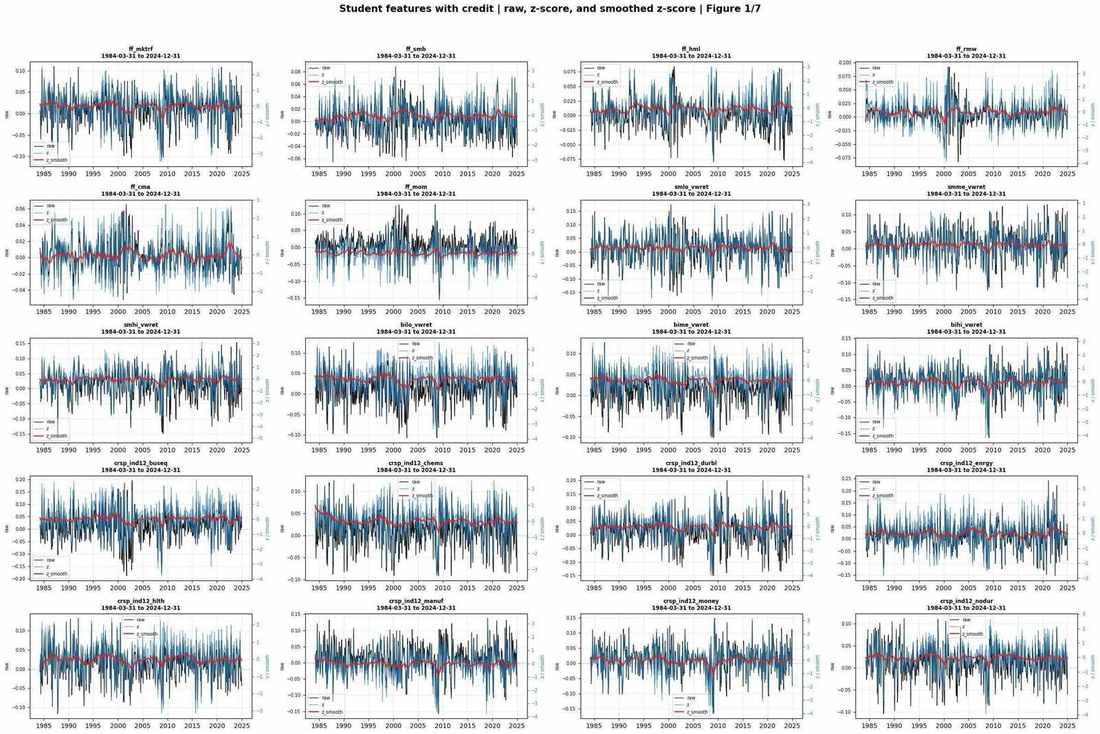

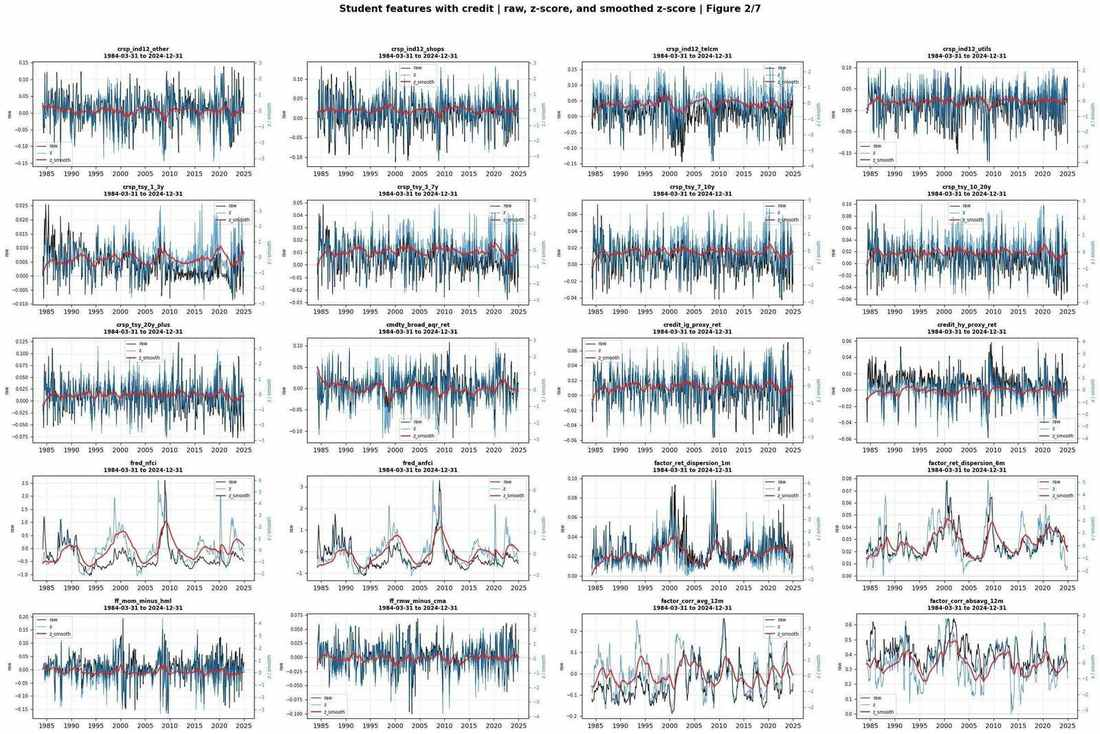

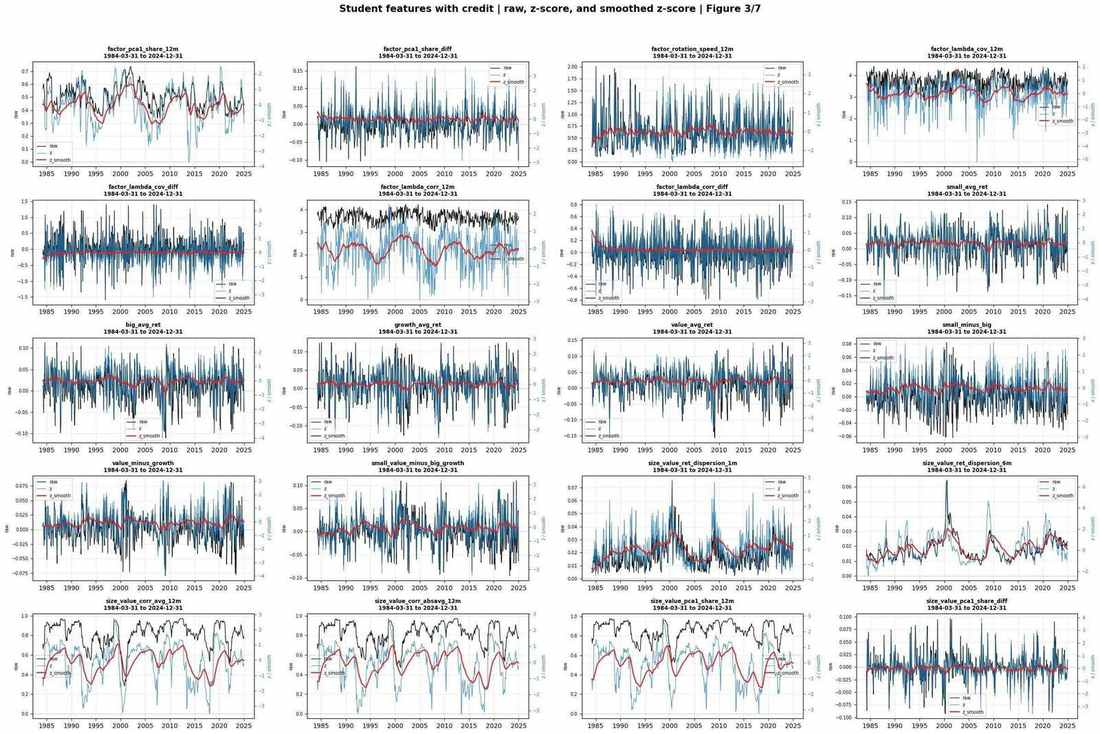

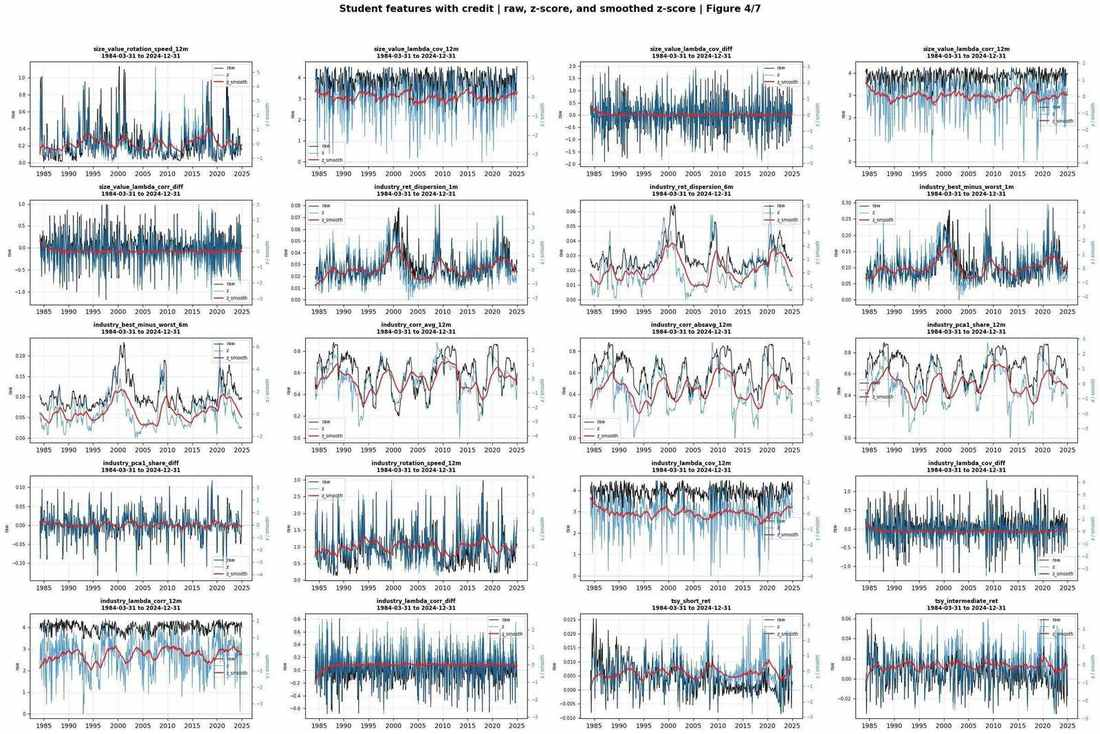

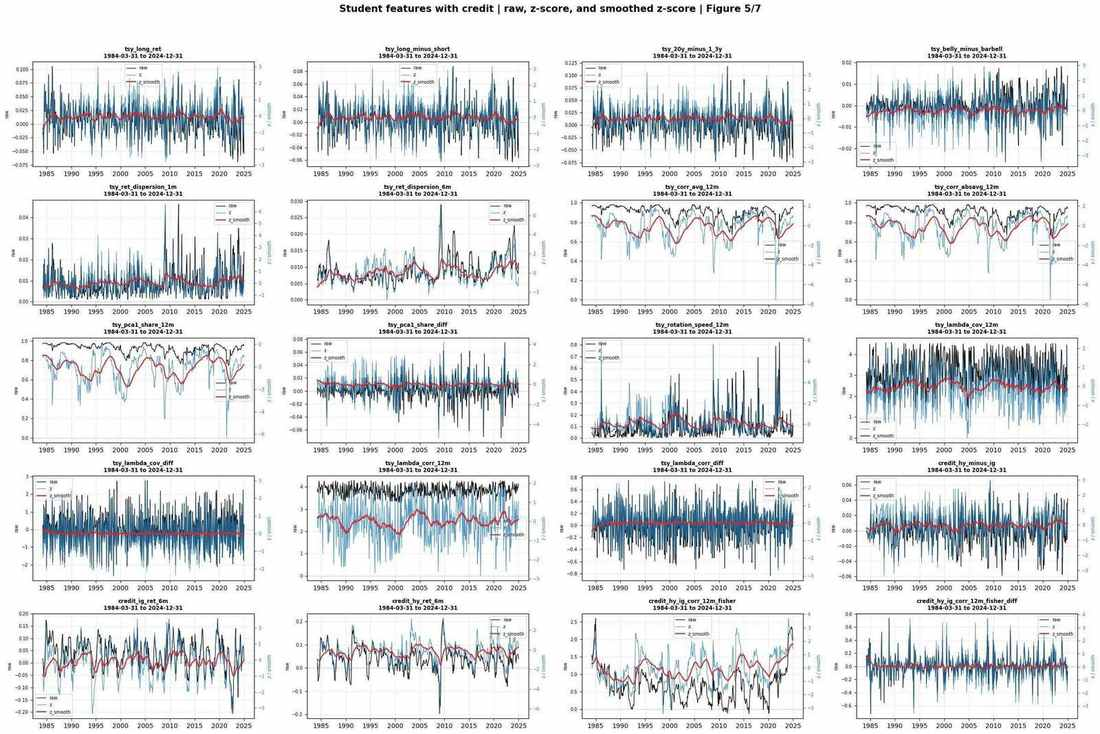

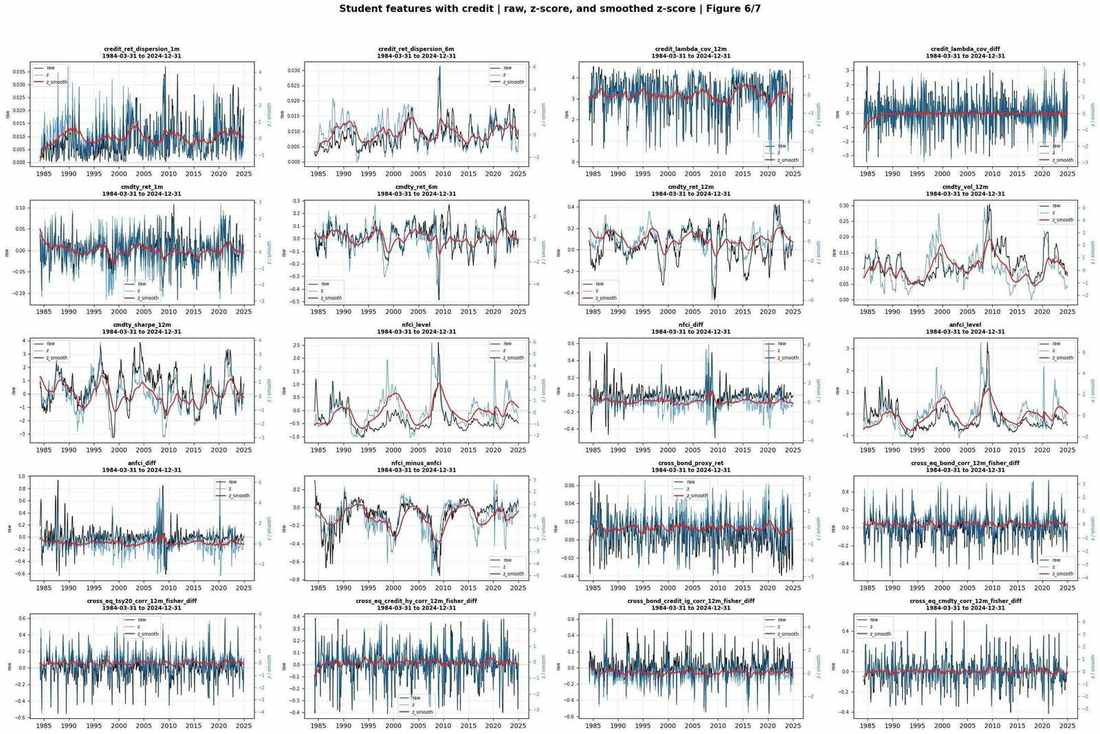

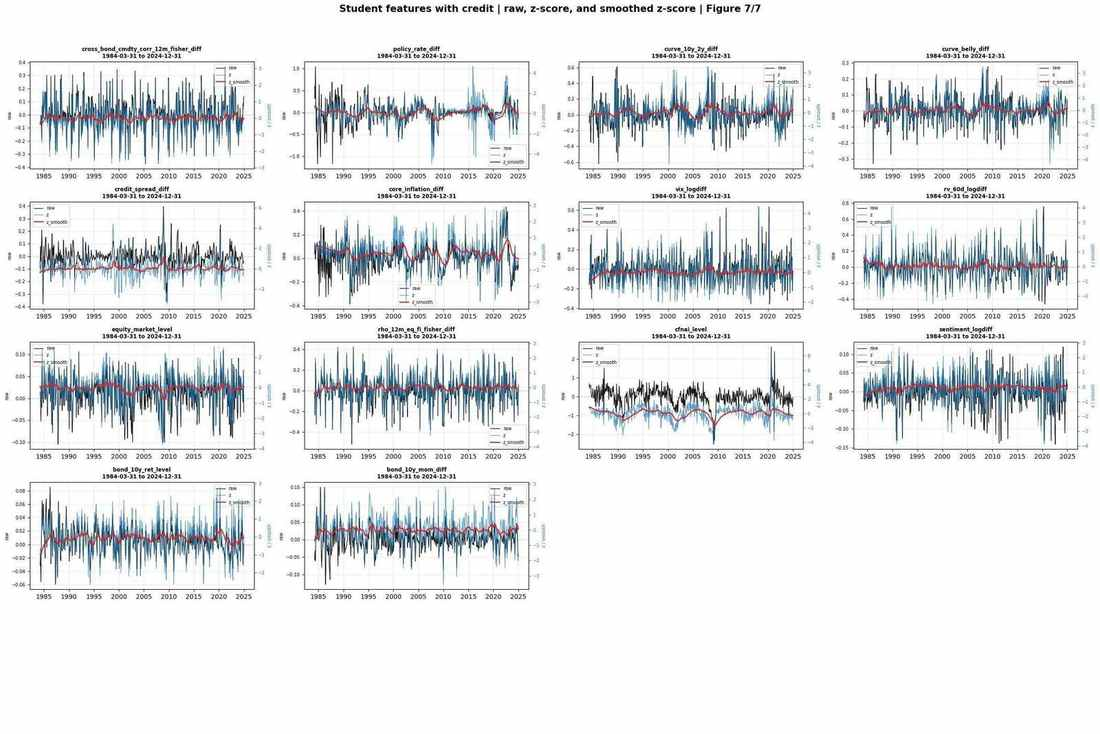

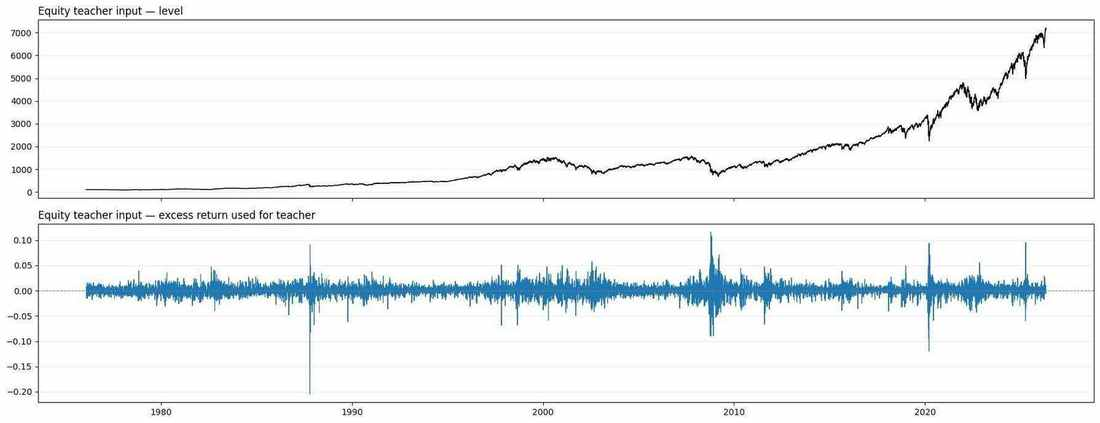

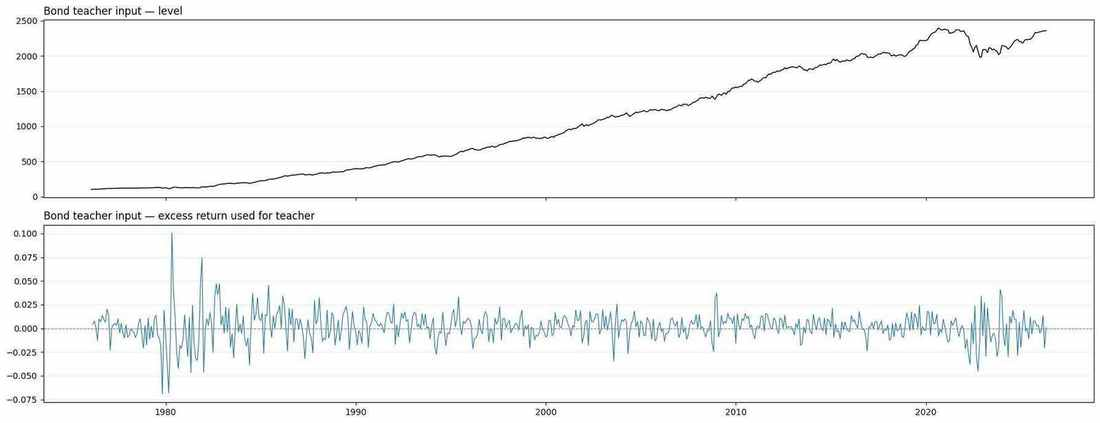

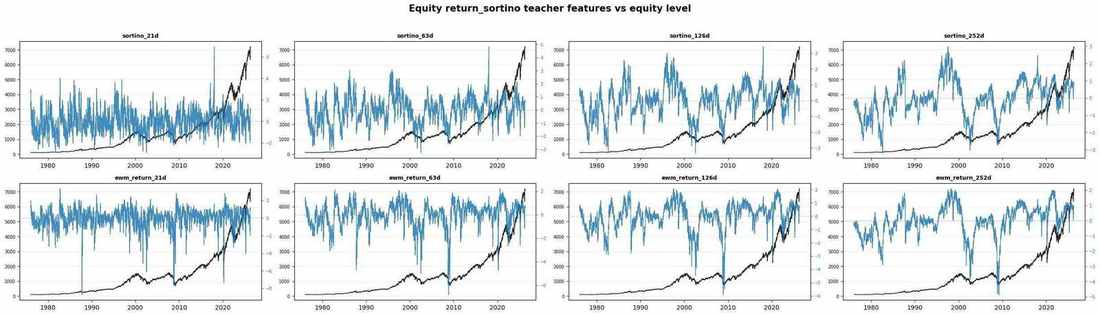

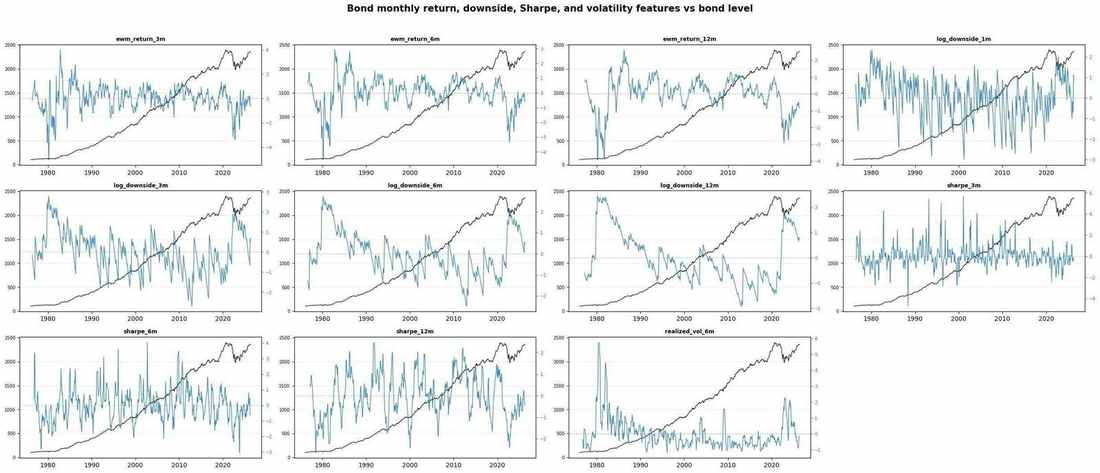

In [1]:
import time
import math
import os
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from pathlib import Path
import matplotlib.pyplot as plt


# Teacher and student feature construction

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
TEACHER_FEATURE_OUTPUT_DIR = OUTPUT_DIR / "teacher_features"
TEACHER_LABEL_OUTPUT_DIR = OUTPUT_DIR / "teacher_labels"
MAJORITY_VOTE_OUTPUT_DIR = OUTPUT_DIR / "majority_vote"
STUDENT_PREDICTION_OUTPUT_DIR = OUTPUT_DIR / "student_prediction"
ALLOCATION_OUTPUT_DIR = OUTPUT_DIR / "allocation"
FIGURE_DIR = PROJECT_DIR / "paper" / "figs"

for directory in [
    PROCESSED_DATA_DIR,
    TEACHER_FEATURE_OUTPUT_DIR,
    TEACHER_LABEL_OUTPUT_DIR,
    MAJORITY_VOTE_OUTPUT_DIR,
    STUDENT_PREDICTION_OUTPUT_DIR,
    ALLOCATION_OUTPUT_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

BASE_DIR = PROJECT_DIR

MKT_PATH = RAW_DATA_DIR / "Raw Market Structure Panel.csv"
CMDTY_PATH = RAW_DATA_DIR / "Monthly Commodity Index Levels.xlsx"
MODEL_PANEL_PATH = RAW_DATA_DIR / "Monthly Model Panel from 1970-01.parquet"

OUT_WITH_CREDIT = PROCESSED_DATA_DIR / "Market Structure Panel with Credit.csv"
OUT_WO_CREDIT = PROCESSED_DATA_DIR / "Market Structure Panel without Credit.csv"

STUDENT_WITH_CREDIT_PATH = PROCESSED_DATA_DIR / "Student Feature Panel with Credit.csv"
STUDENT_WO_CREDIT_PATH = PROCESSED_DATA_DIR / "Student Feature Panel without Credit.csv"

DAILY_DATA_PATH = RAW_DATA_DIR / "Daily Bloomberg Total Return Indices.xlsx"

TEACHER_DAILY_FEATURES_PATH = PROCESSED_DATA_DIR / "Daily Teacher Features.csv"
TEACHER_MONTHLY_FEATURES_PATH = PROCESSED_DATA_DIR / "Monthly Teacher Features.csv"
TEACHER_FEATURE_INVENTORY_PATH = PROCESSED_DATA_DIR / "Teacher Feature Inventory.csv"
TEACHER_DATA_AVAILABILITY_PATH = PROCESSED_DATA_DIR / "Teacher Data Availability.csv"

TEACHER_EQUITY_DAILY_FEATURES_PKL = TEACHER_FEATURE_OUTPUT_DIR / "teacher_Equity Daily Return and Sortino Features.pkl"
TEACHER_BOND_MONTHLY_FEATURES_PKL = TEACHER_FEATURE_OUTPUT_DIR / "teacher_Bond Monthly Return Downside Sharpe and Volatility Features.pkl"
TEACHER_EQUITY_MONTHLY_EXCESS_RETURNS_PKL = TEACHER_FEATURE_OUTPUT_DIR / "teacher_equity_monthly_excess_returns.pkl"
TEACHER_DAILY_PANELS_PKL = TEACHER_FEATURE_OUTPUT_DIR / "teacher_daily_panels.pkl"
TEACHER_MONTHLY_PANELS_PKL = TEACHER_FEATURE_OUTPUT_DIR / "teacher_monthly_panels.pkl"
TEACHER_FEATURE_OBJECTS_MANIFEST_PATH = TEACHER_FEATURE_OUTPUT_DIR / "teacher_feature_objects_manifest.csv"


FRED_API_KEY = os.getenv("FRED_API_KEY", "")
BASE_OBS = "https://api.stlouisfed.org/fred/series/observations"

EPS = 1e-12

WINSOR_WINDOW = 120
WINSOR_MIN_PERIODS = 60
WINSOR_Q_LOW = 0.01
WINSOR_Q_HIGH = 0.99

EXPECTED_FINAL_FEATURE_COUNT = 134

Z_WINDOW = 60
Z_MIN_PERIODS = 36
Z_EPS = 1e-12
Z_SMOOTH_HALFLIFE = 12

RUN_GRID_PLOTS = True

PLOT_START_DATE = None
PLOT_END_DATE = None

N_COLS = 4
N_ROWS = 5
FIGSIZE = (24, 16)

USE_TWIN_AXIS = True

RAW_COLOR = "black"
Z_COLOR = "tab:blue"
SMOOTH_COLOR = "tab:red"

RAW_LINEWIDTH = 1.0
Z_LINEWIDTH = 0.9
SMOOTH_LINEWIDTH = 1.8

RAW_ALPHA = 0.90
Z_ALPHA = 0.75
SMOOTH_ALPHA = 0.95

SHOW_LEGEND = True

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 300)
pd.set_option("display.max_rows", 500)


TEACHER_FEATURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Helper functions

def force_month_end(x):
    return pd.to_datetime(x, errors="coerce").dt.to_period("M").dt.to_timestamp("M")



def fred_obs(series_id, clean_name):
    params = {
        "series_id": series_id,
        "api_key": FRED_API_KEY,
        "file_type": "json",
        "observation_start": "1900-01-01",
    }

    r = requests.get(BASE_OBS, params=params, timeout=30)
    out = pd.DataFrame(r.json().get("observations", []))

    out = out[["date", "value"]].copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out[clean_name] = pd.to_numeric(out["value"].replace(".", pd.NA), errors="coerce")

    return out[["date", clean_name]].dropna(subset=["date"])


def to_month_end_last_available(df, value_col):
    tmp = df.copy()
    tmp["month_end"] = force_month_end(tmp["date"])

    return (
        tmp.sort_values(["month_end", "date"])
           .groupby("month_end", as_index=False)
           .tail(1)
           [["month_end", value_col]]
           .sort_values("month_end")
           .reset_index(drop=True)
    )


def yahoo_download_robust(ticker, start="1970-01-01", max_tries=3):
    errors = []

    for i in range(max_tries):
        try:
            raw = yf.download(
                ticker,
                start=start,
                interval="1d",
                auto_adjust=False,
                progress=False,
                threads=False,
            )

            if raw is not None and not raw.empty:
                return raw

            errors.append(f"download start={start} returned empty, try={i + 1}")
            time.sleep(2)

        except Exception as e:
            errors.append(f"download start={start} failed, try={i + 1}: {repr(e)}")
            time.sleep(2)

    for i in range(max_tries):
        try:
            raw = yf.download(
                ticker,
                period="max",
                interval="1d",
                auto_adjust=False,
                progress=False,
                threads=False,
            )

            if raw is not None and not raw.empty:
                raw = raw.loc[pd.to_datetime(raw.index) >= pd.to_datetime(start)].copy()
                if not raw.empty:
                    return raw

            errors.append(f"download period=max returned empty after start filter, try={i + 1}")
            time.sleep(2)

        except Exception as e:
            errors.append(f"download period=max failed, try={i + 1}: {repr(e)}")
            time.sleep(2)

    try:
        raw = yf.Ticker(ticker).history(
            start=start,
            interval="1d",
            auto_adjust=False,
            actions=False,
        )

        if raw is not None and not raw.empty:
            return raw

        errors.append("Ticker.history returned empty")

    except Exception as e:
        errors.append(f"Ticker.history failed: {repr(e)}")

    return raw if "raw" in locals() else pd.DataFrame()


def yahoo_monthly_adjusted_return(ticker, ret_col, start="1970-01-01"):
    raw = yahoo_download_robust(ticker=ticker, start=start)

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    d = raw[["Adj Close"]].copy()
    d = d.rename(columns={"Adj Close": "adj_close"})
    d = d.reset_index()

    date_col = "Date" if "Date" in d.columns else d.columns[0]
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d["month_end"] = force_month_end(d[date_col])

    monthly_level = (
        d.dropna(subset=["month_end", "adj_close"])
         .sort_values(date_col)
         .groupby("month_end", as_index=False)
         .last()[["month_end", "adj_close"]]
         .sort_values("month_end")
         .reset_index(drop=True)
    )

    monthly_level[ret_col] = monthly_level["adj_close"].pct_change()

    return monthly_level[["month_end", ret_col]]


def _row_dispersion(df, cols):
    return df[cols].std(axis=1, ddof=0)


def _row_best_minus_worst(df, cols):
    return df[cols].max(axis=1) - df[cols].min(axis=1)


def _roll_sum(s, w):
    return pd.to_numeric(s, errors="coerce").rolling(w, min_periods=w).sum()


def _roll_mean(s, w):
    return pd.to_numeric(s, errors="coerce").rolling(w, min_periods=w).mean()


def _roll_std(s, w):
    return pd.to_numeric(s, errors="coerce").rolling(w, min_periods=w).std(ddof=0)


def _diff1(s):
    return pd.to_numeric(s, errors="coerce").diff()


def _log_diff1(s):
    s = pd.to_numeric(s, errors="coerce")
    return np.log(s.where(s > 0)).diff()


def _safe_fisher_corr(rho):
    rho = pd.to_numeric(rho, errors="coerce").clip(-0.999, 0.999)
    return 0.5 * np.log((1.0 + rho) / (1.0 - rho))


def _rolling_corr_fisher_diff(df, x_col, y_col, window=12):
    rho = df[x_col].rolling(window, min_periods=window).corr(df[y_col])
    fisher = _safe_fisher_corr(rho)
    return fisher.diff()


def _rolling_pairwise_corr_stats(df, cols, window=12, prefix=None):
    avg_corr = pd.Series(np.nan, index=df.index)
    absavg_corr = pd.Series(np.nan, index=df.index)
    pca1_share = pd.Series(np.nan, index=df.index)
    rotation_speed = pd.Series(np.nan, index=df.index)

    prev_corr = None
    X = df[cols].copy()

    for i in range(len(df)):
        if i + 1 < window:
            continue

        block = X.iloc[i + 1 - window:i + 1].dropna()

        if len(block) < window:
            prev_corr = None
            continue

        corr = block.corr().to_numpy(dtype=float)

        if not np.isfinite(corr).all():
            prev_corr = None
            continue

        n = corr.shape[0]

        if n < 2:
            prev_corr = None
            continue

        upper = corr[np.triu_indices(n, k=1)]

        avg_corr.iloc[i] = np.nanmean(upper)
        absavg_corr.iloc[i] = np.nanmean(np.abs(upper))

        try:
            eigvals = np.linalg.eigvalsh(corr)
            eigvals = np.maximum(eigvals, 0.0)
            denom = eigvals.sum()
            pca1_share.iloc[i] = eigvals[-1] / denom if denom > EPS else np.nan
        except Exception:
            pca1_share.iloc[i] = np.nan

        if prev_corr is not None and prev_corr.shape == corr.shape:
            rotation_speed.iloc[i] = np.linalg.norm(corr - prev_corr, ord="fro")

        prev_corr = corr.copy()

    return {
        f"{prefix}_corr_avg_12m": avg_corr,
        f"{prefix}_corr_absavg_12m": absavg_corr,
        f"{prefix}_pca1_share_12m": pca1_share,
        f"{prefix}_pca1_share_diff": pca1_share.diff(),
        f"{prefix}_rotation_speed_12m": rotation_speed,
    }


def _lambda_f_series(df, cols, window=12, prefix=None, include_corr=True):
    lam_cov = pd.Series(np.nan, index=df.index)
    lam_corr = pd.Series(np.nan, index=df.index)

    X = df[cols].copy()

    prev_cov = None
    prev_corr = None

    for i in range(len(df)):
        if i + 1 < window:
            continue

        block = X.iloc[i + 1 - window:i + 1].dropna()

        if len(block) < window:
            prev_cov = None
            prev_corr = None
            continue

        cov = block.cov().to_numpy(dtype=float)
        corr = block.corr().to_numpy(dtype=float)

        if not np.isfinite(cov).all():
            prev_cov = None
            prev_corr = None
            continue

        if include_corr and not np.isfinite(corr).all():
            prev_cov = None
            prev_corr = None
            continue

        if prev_cov is not None and prev_cov.shape == cov.shape:
            dF = cov - prev_cov
            comm = cov @ dF - dF @ cov
            denom = np.linalg.norm(cov, ord="fro") * np.linalg.norm(dF, ord="fro")

            if denom > EPS:
                lam_cov.iloc[i] = np.log1p(
                    100.0 * np.linalg.norm(comm, ord="fro") / denom
                )

        if include_corr:
            if prev_corr is not None and prev_corr.shape == corr.shape:
                dF = corr - prev_corr
                comm = corr @ dF - dF @ corr
                denom = np.linalg.norm(corr, ord="fro") * np.linalg.norm(dF, ord="fro")

                if denom > EPS:
                    lam_corr.iloc[i] = np.log1p(
                        100.0 * np.linalg.norm(comm, ord="fro") / denom
                    )

        prev_cov = cov.copy()
        prev_corr = corr.copy() if include_corr else None

    out = {
        f"{prefix}_lambda_cov_12m": lam_cov,
        f"{prefix}_lambda_cov_diff": lam_cov.diff(),
    }

    if include_corr:
        out[f"{prefix}_lambda_corr_12m"] = lam_corr
        out[f"{prefix}_lambda_corr_diff"] = lam_corr.diff()

    return out


def _require_cols(df, cols, block_name):
    return None


def rolling_winsorize_series(
    s,
    window=120,
    min_periods=60,
    q_low=0.01,
    q_high=0.99,
):
    x = pd.to_numeric(s, errors="coerce")

    lo = (
        x.shift(1)
         .rolling(window=window, min_periods=min_periods)
         .quantile(q_low)
    )

    hi = (
        x.shift(1)
         .rolling(window=window, min_periods=min_periods)
         .quantile(q_high)
    )

    out = x.copy()
    valid_band = lo.notna() & hi.notna() & x.notna()

    out.loc[valid_band] = np.minimum(
        np.maximum(x.loc[valid_band], lo.loc[valid_band]),
        hi.loc[valid_band],
    )

    return out


def causal_rolling_zscore(
    s,
    window=60,
    min_periods=36,
    eps=1e-12,
):
    x = pd.to_numeric(s, errors="coerce")

    mu = (
        x.shift(1)
         .rolling(window=window, min_periods=min_periods)
         .mean()
    )

    sig = (
        x.shift(1)
         .rolling(window=window, min_periods=min_periods)
         .std(ddof=0)
    )

    return (x - mu) / (sig + eps)


def add_z_and_smooth(panel, output_date_col="date"):
    out = panel.copy()

    out["month_end"] = pd.to_datetime(out["month_end"]) + pd.offsets.MonthEnd(0)

    out = (
        out.sort_values("month_end")
           .drop_duplicates("month_end", keep="last")
           .reset_index(drop=True)
    )

    raw_feature_cols = [c for c in out.columns if c != "month_end"]

    for c in raw_feature_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    z_cols = []

    for c in raw_feature_cols:
        z_col = f"{c}_z"
        out[z_col] = causal_rolling_zscore(
            out[c],
            window=Z_WINDOW,
            min_periods=Z_MIN_PERIODS,
            eps=Z_EPS,
        )
        z_cols.append(z_col)

    smooth_cols = []

    for z_col in z_cols:
        smooth_col = f"{z_col}_smooth"
        out[smooth_col] = (
            out[z_col]
            .ewm(
                halflife=Z_SMOOTH_HALFLIFE,
                adjust=False,
                min_periods=1,
            )
            .mean()
        )
        smooth_cols.append(smooth_col)

    final_cols = ["month_end"] + raw_feature_cols + z_cols + smooth_cols
    out = out[final_cols].copy()

    complete_cols = raw_feature_cols + z_cols + smooth_cols
    complete_mask = out[complete_cols].notna().all(axis=1)

    out = (
        out.loc[complete_mask]
           .rename(columns={"month_end": output_date_col})
           .reset_index(drop=True)
    )

    return out, raw_feature_cols, z_cols, smooth_cols



def plot_raw_z_smooth_grid(
    input_df,
    panel_name,
    plot_start_date=None,
    plot_end_date=None,
    n_cols=4,
    n_rows=5,
    figsize=(24, 16),
    use_twin_axis=True,
):
    plot_df = input_df.copy()

    plot_df["date"] = pd.to_datetime(plot_df["date"]) + pd.offsets.MonthEnd(0)

    plot_df = (
        plot_df.sort_values("date")
               .drop_duplicates("date", keep="last")
               .reset_index(drop=True)
    )

    if plot_start_date is not None:
        plot_df = plot_df.loc[plot_df["date"] >= pd.Timestamp(plot_start_date)].copy()

    if plot_end_date is not None:
        plot_df = plot_df.loc[plot_df["date"] <= pd.Timestamp(plot_end_date)].copy()

    all_cols = [c for c in plot_df.columns if c != "date"]

    raw_feature_cols = [
        c for c in all_cols
        if not c.endswith("_z")
        and not c.endswith("_z_smooth")
        and f"{c}_z" in plot_df.columns
        and f"{c}_z_smooth" in plot_df.columns
    ]

    plots_per_fig = n_cols * n_rows
    n_figs = math.ceil(len(raw_feature_cols) / plots_per_fig)


    for fig_id in range(n_figs):
        chunk = raw_feature_cols[
            fig_id * plots_per_fig : (fig_id + 1) * plots_per_fig
        ]

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=figsize,
            sharex=False,
        )

        axes = np.asarray(axes).reshape(-1)

        for ax, base_col in zip(axes, chunk):
            z_col = f"{base_col}_z"
            smooth_col = f"{base_col}_z_smooth"

            temp = plot_df[["date", base_col, z_col, smooth_col]].copy()

            temp[base_col] = pd.to_numeric(temp[base_col], errors="coerce")
            temp[z_col] = pd.to_numeric(temp[z_col], errors="coerce")
            temp[smooth_col] = pd.to_numeric(temp[smooth_col], errors="coerce")

            raw_temp = temp[["date", base_col]].dropna()
            z_temp = temp[["date", z_col]].dropna()
            smooth_temp = temp[["date", smooth_col]].dropna()

            if raw_temp.empty and z_temp.empty and smooth_temp.empty:
                ax.set_title(f"{base_col}\nno data", fontsize=8.5, fontweight="bold")
                ax.axis("off")
                continue

            if use_twin_axis:
                ax_z = ax.twinx()

                if not raw_temp.empty:
                    ax.plot(
                        raw_temp["date"],
                        raw_temp[base_col],
                        color=RAW_COLOR,
                        lw=RAW_LINEWIDTH,
                        alpha=RAW_ALPHA,
                        label="raw",
                    )

                if not z_temp.empty:
                    ax_z.plot(
                        z_temp["date"],
                        z_temp[z_col],
                        color=Z_COLOR,
                        lw=Z_LINEWIDTH,
                        alpha=Z_ALPHA,
                        label="z",
                    )

                if not smooth_temp.empty:
                    ax_z.plot(
                        smooth_temp["date"],
                        smooth_temp[smooth_col],
                        color=SMOOTH_COLOR,
                        lw=SMOOTH_LINEWIDTH,
                        alpha=SMOOTH_ALPHA,
                        label="z_smooth",
                    )

                ax.axhline(0.0, color="gray", lw=0.7, ls="--", alpha=0.45)
                ax_z.axhline(0.0, color="gray", lw=0.7, ls=":", alpha=0.35)

                ax.tick_params(axis="y", labelsize=7, colors=RAW_COLOR)
                ax_z.tick_params(axis="y", labelsize=7, colors=Z_COLOR)

                ax.set_ylabel("raw", fontsize=7, color=RAW_COLOR)
                ax_z.set_ylabel("z / smooth", fontsize=7, color=Z_COLOR)

                if SHOW_LEGEND:
                    lines_1, labels_1 = ax.get_legend_handles_labels()
                    lines_2, labels_2 = ax_z.get_legend_handles_labels()

                    ax.legend(
                        lines_1 + lines_2,
                        labels_1 + labels_2,
                        fontsize=7,
                        loc="best",
                        frameon=True,
                    )

            else:
                if not raw_temp.empty:
                    ax.plot(
                        raw_temp["date"],
                        raw_temp[base_col],
                        color=RAW_COLOR,
                        lw=RAW_LINEWIDTH,
                        alpha=RAW_ALPHA,
                        label="raw",
                    )

                if not z_temp.empty:
                    ax.plot(
                        z_temp["date"],
                        z_temp[z_col],
                        color=Z_COLOR,
                        lw=Z_LINEWIDTH,
                        alpha=Z_ALPHA,
                        label="z",
                    )

                if not smooth_temp.empty:
                    ax.plot(
                        smooth_temp["date"],
                        smooth_temp[smooth_col],
                        color=SMOOTH_COLOR,
                        lw=SMOOTH_LINEWIDTH,
                        alpha=SMOOTH_ALPHA,
                        label="z_smooth",
                    )

                ax.axhline(0.0, color="gray", lw=0.7, ls="--", alpha=0.45)

                if SHOW_LEGEND:
                    ax.legend(fontsize=7, loc="best", frameon=True)

            valid_any = temp[[base_col, z_col, smooth_col]].notna().any(axis=1)

            if valid_any.any():
                first_valid = temp.loc[valid_any, "date"].min().date()
                last_valid = temp.loc[valid_any, "date"].max().date()
                subtitle = f"{first_valid} to {last_valid}"
            else:
                subtitle = "no data"

            ax.set_title(
                f"{base_col}\n{subtitle}",
                fontsize=8.5,
                fontweight="bold",
            )

            ax.grid(True, alpha=0.25)

        for ax in axes[len(chunk):]:
            ax.axis("off")

        fig.suptitle(
            f"{panel_name} | raw, z-score, and smoothed z-score | Figure {fig_id + 1}/{n_figs}",
            fontsize=15,
            fontweight="bold",
            y=0.995,
        )

        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()


# Teacher feature construction

TEACHER_EPS = 1e-12
TEACHER_STD_DDOF = 0

CURRENT_DATE = pd.Timestamp("2026-05-19")
FINALIZED_MONTH_END = (
    CURRENT_DATE.to_period("M").to_timestamp("M") - pd.offsets.MonthEnd(1)
)

EQUITY_START_MODE = "bond_start"

EQUITY_RETURN_SORTINO_FEATURES = [
    "sortino_21d",
    "sortino_63d",
    "sortino_126d",
    "sortino_252d",
    "ewm_return_21d",
    "ewm_return_63d",
    "ewm_return_126d",
    "ewm_return_252d",
]


EQUITY_ALL_TEACHER_FEATURES = EQUITY_RETURN_SORTINO_FEATURES.copy()

BOND_MONTHLY_TEACHER_FEATURES = [
    "ewm_return_3m",
    "ewm_return_6m",
    "ewm_return_12m",
    "log_downside_1m",
    "log_downside_3m",
    "log_downside_6m",
    "log_downside_12m",
    "sharpe_3m",
    "sharpe_6m",
    "sharpe_12m",
    "realized_vol_6m",
]

TEACHER_NON_FEATURE_COLS = {
    "date",
    "asset",
    "teacher_panel",
    "feature_group",
    "source_frequency",
    "label_source",
    "feature_source",
    "excess_return",
    "excess_return_source",
    "n_daily_obs",
}

def safe_min_date(s):
    s = pd.to_datetime(s, errors="coerce").dropna()
    return pd.NaT if s.empty else s.min()


def safe_max_date(s):
    s = pd.to_datetime(s, errors="coerce").dropna()
    return pd.NaT if s.empty else s.max()


def date_or_nat(x):
    if pd.isna(x):
        return pd.NaT
    return pd.Timestamp(x).date()


def infer_dense_daily_start(dates, calendar_window_days=31, min_obs_in_window=10):
    dt = (
        pd.Series(pd.to_datetime(dates, errors="coerce"))
        .dropna()
        .sort_values()
        .reset_index(drop=True)
    )

    if dt.empty:
        return pd.NaT

    values = dt.to_numpy(dtype="datetime64[ns]")
    flags = []

    for current in values:
        left = np.searchsorted(
            values,
            current - np.timedelta64(calendar_window_days, "D"),
            side="left",
        )
        right = np.searchsorted(
            values,
            current + np.timedelta64(calendar_window_days, "D"),
            side="right",
        )
        flags.append((right - left) >= min_obs_in_window)

    flags = pd.Series(flags)

    if not flags.any():
        return pd.NaT

    return pd.Timestamp(values[int(flags.idxmax())])


def parse_bloomberg_index_sheet(path, sheet_name, asset, level_col=None):
    raw = pd.read_excel(path, sheet_name=sheet_name)

    date_col = raw.columns[0]
    level_col = raw.columns[1] if level_col is None else level_col

    out = raw[[date_col, level_col]].copy()
    out = out.rename(columns={date_col: "date", level_col: "index_level"})

    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["index_level"] = pd.to_numeric(out["index_level"], errors="coerce")

    out = (
        out.dropna(subset=["date", "index_level"])
        .sort_values("date")
        .drop_duplicates("date", keep="last")
        .reset_index(drop=True)
    )

    dense_start = infer_dense_daily_start(out["date"])

    out["asset"] = asset
    out["month_end"] = force_month_end(out["date"])
    out["calendar_gap_days"] = out["date"].diff().dt.days
    out["raw_return"] = out["index_level"].pct_change()
    out.loc[out["calendar_gap_days"].gt(7), "raw_return"] = np.nan

    if pd.notna(dense_start):
        out["is_dense_daily_region"] = out["date"].ge(dense_start)
    else:
        out["is_dense_daily_region"] = False

    return out, dense_start


def load_monthly_rf_for_teacher(model_panel_path):
    mp = pd.read_parquet(model_panel_path)

    rf = mp[["date", "rf"]].copy()
    rf["month_end"] = force_month_end(rf["date"])
    rf["rf"] = pd.to_numeric(rf["rf"], errors="coerce")

    return (
        rf[["month_end", "rf"]]
        .dropna(subset=["month_end"])
        .sort_values("month_end")
        .drop_duplicates("month_end", keep="last")
        .reset_index(drop=True)
    )


def attach_daily_rf(asset_daily, rf_monthly):
    out = asset_daily.copy()
    out["month_end"] = force_month_end(out["date"])
    out = out.merge(rf_monthly, on="month_end", how="left")

    n_days = (
        out.groupby("month_end")["date"]
        .transform("count")
        .astype(float)
        .replace(0.0, np.nan)
    )

    out["rf_available"] = out["rf"].notna()

    out["rf_daily"] = np.where(
        out["rf"].notna(),
        np.power(1.0 + out["rf"].astype(float), 1.0 / n_days) - 1.0,
        0.0,
    )

    out["excess_return"] = out["raw_return"] - out["rf_daily"]

    out["excess_return_source"] = np.where(
        out["rf_available"],
        "monthly_rf_compounded_to_daily",
        "raw_return_rf_missing_zero",
    )

    return out


def build_monthly_return_panel_from_levels(asset_levels, rf_monthly):
    monthly = (
        asset_levels.dropna(subset=["month_end", "index_level"])
        .sort_values(["month_end", "date"])
        .groupby("month_end", as_index=False)
        .tail(1)
        [["month_end", "asset", "index_level"]]
        .sort_values("month_end")
        .reset_index(drop=True)
    )

    monthly["raw_return"] = monthly["index_level"].pct_change()

    monthly = monthly.merge(rf_monthly, on="month_end", how="left")
    monthly["rf_available"] = monthly["rf"].notna()
    monthly["rf_monthly"] = monthly["rf"].fillna(0.0)
    monthly["excess_return"] = monthly["raw_return"] - monthly["rf_monthly"]

    monthly["excess_return_source"] = np.where(
        monthly["rf_available"],
        "monthly_rf",
        "raw_return_rf_missing_zero",
    )

    monthly = monthly.rename(columns={"month_end": "date"})

    return monthly.sort_values("date").reset_index(drop=True)


def ewm_halflife(s, h, min_periods=None):
    if min_periods is None:
        min_periods = int(h)

    alpha = 1.0 - np.exp(np.log(0.5) / float(h))
    return (
        pd.to_numeric(s, errors="coerce")
        .ewm(alpha=alpha, adjust=False, min_periods=int(min_periods))
        .mean()
    )


def compound_return(ret):
    r = pd.Series(ret).dropna().astype(float)
    return float(np.prod(1.0 + r) - 1.0) if len(r) else np.nan


def build_equity_daily_teacher_features(daily_df):
    base = daily_df[["date", "asset", "excess_return", "excess_return_source"]].copy()
    base["asset"] = "equity"
    base = base.sort_values("date").reset_index(drop=True)

    r = pd.to_numeric(base["excess_return"], errors="coerce")
    neg = r.clip(upper=0.0)
    feat = pd.DataFrame(index=base.index)

    for h in [21, 63, 126, 252]:
        avg = ewm_halflife(r, h, min_periods=h)
        downside = np.sqrt(ewm_halflife(neg.pow(2), h, min_periods=h))
        feat[f"sortino_{h}d"] = avg / (downside + TEACHER_EPS)
        feat[f"ewm_return_{h}d"] = avg

    out = pd.concat(
        [
            base.reset_index(drop=True),
            feat[EQUITY_RETURN_SORTINO_FEATURES].reset_index(drop=True),
        ],
        axis=1,
    )

    out["teacher_panel"] = "equity_daily_return_sortino"
    out["feature_group"] = "return_sortino"
    out["source_frequency"] = "daily"
    out["label_source"] = "daily_sjm"
    out["feature_source"] = "daily"

    cols = [
        "date",
        "asset",
        "teacher_panel",
        "feature_group",
        "source_frequency",
        "label_source",
        "feature_source",
        "excess_return",
        "excess_return_source",
    ] + EQUITY_RETURN_SORTINO_FEATURES

    return out[cols].sort_values("date").reset_index(drop=True)

def build_bond_monthly_teacher_features(monthly_df):
    base = monthly_df[["date", "asset", "excess_return", "excess_return_source"]].copy()
    base["asset"] = "bond"
    base = base.sort_values("date").reset_index(drop=True)

    r = pd.to_numeric(base["excess_return"], errors="coerce")
    neg = r.clip(upper=0.0)

    feat = pd.DataFrame(index=base.index)

    for h in [1, 3, 6, 12]:
        avg_ewm = ewm_halflife(r, h)
        downside = np.sqrt(ewm_halflife(neg.pow(2), h))
        feat[f"log_downside_{h}m"] = np.log(downside + TEACHER_EPS)

        if h in [3, 6, 12]:
            feat[f"ewm_return_{h}m"] = avg_ewm

            mean_h = r.rolling(h, min_periods=h).mean()
            vol_h = r.rolling(h, min_periods=h).std(ddof=TEACHER_STD_DDOF)
            feat[f"sharpe_{h}m"] = mean_h / (vol_h + TEACHER_EPS)

    feat["realized_vol_6m"] = (
        r.rolling(6, min_periods=6).std(ddof=TEACHER_STD_DDOF)
    )

    out = pd.concat(
        [
            base.reset_index(drop=True),
            feat[BOND_MONTHLY_TEACHER_FEATURES].reset_index(drop=True),
        ],
        axis=1,
    )

    out["teacher_panel"] = "bond_monthly_return_downside_sharpe_vol"
    out["feature_group"] = "return_downside_sharpe_vol"
    out["source_frequency"] = "monthly"
    out["label_source"] = "monthly_sjm"
    out["feature_source"] = "monthly_only"
    out["n_daily_obs"] = np.nan

    cols = [
        "date",
        "asset",
        "teacher_panel",
        "feature_group",
        "source_frequency",
        "label_source",
        "feature_source",
        "excess_return",
        "excess_return_source",
        "n_daily_obs",
    ] + BOND_MONTHLY_TEACHER_FEATURES

    return out[cols].sort_values("date").reset_index(drop=True)


def build_equity_monthly_excess_returns_from_daily(equity_daily_features):
    out = (
        equity_daily_features.assign(month_end=force_month_end(equity_daily_features["date"]))
        .groupby("month_end", as_index=False)
        .agg(
            eq_excess=("excess_return", compound_return),
            n_daily_obs=("date", "count"),
        )
        .rename(columns={"month_end": "date"})
        .sort_values("date")
        .reset_index(drop=True)
    )

    return out


def clean_teacher_panel(df, feature_cols):
    out = df.copy()

    for c in feature_cols + ["excess_return"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce").replace([np.inf, -np.inf], np.nan)

    return out



# Teacher features

rf_monthly_teacher = load_monthly_rf_for_teacher(MODEL_PANEL_PATH)

spx_levels, spx_dense_start = parse_bloomberg_index_sheet(
    DAILY_DATA_PATH,
    sheet_name="Sheet1",
    asset="equity",
)

agg_levels, agg_dense_start = parse_bloomberg_index_sheet(
    DAILY_DATA_PATH,
    sheet_name="LBUSTRUU",
    asset="bond",
)

TEACHER_PROJECT_START = pd.Timestamp(agg_levels["date"].min())

spx_levels_full_history = spx_levels.sort_values("date").reset_index(drop=True).copy()

if EQUITY_START_MODE == "bond_start":
    spx_levels = (
        spx_levels_full_history.loc[spx_levels_full_history["date"] >= TEACHER_PROJECT_START]
        .sort_values("date")
        .reset_index(drop=True)
    )

    spx_levels["month_end"] = force_month_end(spx_levels["date"])
    spx_levels["calendar_gap_days"] = spx_levels["date"].diff().dt.days
    spx_levels["raw_return"] = spx_levels["index_level"].pct_change()
    spx_levels.loc[spx_levels["calendar_gap_days"].gt(7), "raw_return"] = np.nan
    spx_levels["is_dense_daily_region"] = True

else:
    spx_levels = spx_levels_full_history.copy()

spx_daily_all_full_history = attach_daily_rf(spx_levels_full_history.copy(), rf_monthly_teacher)
spx_daily_full_history = (
    spx_daily_all_full_history.loc[spx_daily_all_full_history["is_dense_daily_region"]]
    .dropna(subset=["raw_return"])
    .sort_values("date")
    .reset_index(drop=True)
)

spx_daily_all = attach_daily_rf(spx_levels.copy(), rf_monthly_teacher)
agg_daily_all = attach_daily_rf(agg_levels.copy(), rf_monthly_teacher)

spx_daily = (
    spx_daily_all.loc[spx_daily_all["is_dense_daily_region"]]
    .dropna(subset=["raw_return"])
    .sort_values("date")
    .reset_index(drop=True)
)

agg_daily = (
    agg_daily_all.loc[agg_daily_all["is_dense_daily_region"]]
    .dropna(subset=["raw_return"])
    .sort_values("date")
    .reset_index(drop=True)
)

spx_monthly = build_monthly_return_panel_from_levels(spx_levels, rf_monthly_teacher)
agg_monthly = build_monthly_return_panel_from_levels(agg_levels, rf_monthly_teacher)

teacher_data_availability = pd.DataFrame([
    {
        "asset": name,
        "level_obs": int(len(levels)),
        "level_first_date": date_or_nat(levels["date"].min()),
        "level_last_date": date_or_nat(levels["date"].max()),
        "dense_daily_start": date_or_nat(dense_start),
        "daily_obs_used": int(len(daily)),
        "daily_first_date": date_or_nat(safe_min_date(daily["date"])),
        "daily_last_date": date_or_nat(safe_max_date(daily["date"])),
        "monthly_obs": int(len(monthly)),
        "monthly_first_date": date_or_nat(safe_min_date(monthly["date"])),
        "monthly_last_date": date_or_nat(safe_max_date(monthly["date"])),
        "rf_available_daily_pct": float(daily["rf_available"].mean()) if len(daily) else np.nan,
        "rf_available_monthly_pct": float(monthly["rf_available"].mean()) if len(monthly) else np.nan,
    }
    for name, levels, dense_start, daily, monthly in [
        ("equity", spx_levels, spx_dense_start, spx_daily, spx_monthly),
        ("bond", agg_levels, agg_dense_start, agg_daily, agg_monthly),
    ]
])

equity_teacher = build_equity_daily_teacher_features(spx_daily_full_history)

equity_teacher = (
    equity_teacher
    .loc[
        (equity_teacher["date"] >= TEACHER_PROJECT_START)
        & (equity_teacher["date"] <= FINALIZED_MONTH_END)
    ]
    .reset_index(drop=True)
)

equity_teacher = clean_teacher_panel(equity_teacher, EQUITY_RETURN_SORTINO_FEATURES)

equity_monthly_returns = build_equity_monthly_excess_returns_from_daily(equity_teacher)

bond_teacher = build_bond_monthly_teacher_features(agg_monthly)

bond_teacher = (
    bond_teacher
    .loc[bond_teacher["date"] <= FINALIZED_MONTH_END]
    .sort_values("date")
    .drop_duplicates("date", keep="last")
    .reset_index(drop=True)
)

bond_feature_cols = [c for c in BOND_MONTHLY_TEACHER_FEATURES if c in bond_teacher.columns]

bond_teacher[bond_feature_cols] = (
    bond_teacher[bond_feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

for c in bond_feature_cols:
    valid_idx = bond_teacher.index[bond_teacher[c].notna()]
    if len(valid_idx) > 0:
        bond_teacher.loc[valid_idx[0], c] = np.nan

log_eps_value = float(np.log(TEACHER_EPS))
log_downside_cols = [c for c in bond_feature_cols if c.startswith("log_downside_")]

for c in log_downside_cols:
    for idx in bond_teacher.index:
        x = bond_teacher.loc[idx, c]
        if pd.isna(x):
            continue
        if np.isclose(float(x), log_eps_value, atol=1e-10, rtol=0.0):
            bond_teacher.loc[idx, c] = np.nan
            continue
        break

bond_teacher = clean_teacher_panel(bond_teacher, BOND_MONTHLY_TEACHER_FEATURES)

teacher_daily_panels = {
    ("equity", "return_sortino", "daily_sjm"): equity_teacher.copy(),
}

teacher_monthly_panels = {
    ("bond", "return_downside_sharpe_vol", "monthly_sjm"): bond_teacher.copy(),
}

daily_teacher_features = (
    pd.concat(teacher_daily_panels.values(), axis=0, ignore_index=True, sort=False)
    .sort_values(["asset", "feature_group", "label_source", "date"])
    .reset_index(drop=True)
)

monthly_teacher_features = (
    pd.concat(teacher_monthly_panels.values(), axis=0, ignore_index=True, sort=False)
    .sort_values(["asset", "feature_group", "label_source", "date"])
    .reset_index(drop=True)
)

teacher_feature_inventory = pd.DataFrame([
    {
        "object": "equity_teacher",
        "asset": "equity",
        "teacher_panel": "equity_daily_return_sortino",
        "feature_group": "return_sortino",
        "source_frequency": "daily",
        "label_source": "daily_sjm",
        "feature_source": "daily",
        "n_rows": int(len(equity_teacher)),
        "n_features": int(len(EQUITY_RETURN_SORTINO_FEATURES)),
        "complete_rows": int(equity_teacher[EQUITY_RETURN_SORTINO_FEATURES + ["excess_return"]].notna().all(axis=1).sum()),
        "first_date": date_or_nat(safe_min_date(equity_teacher["date"])),
        "last_date": date_or_nat(safe_max_date(equity_teacher["date"])),
        "avg_feature_missing_pct": float(equity_teacher[EQUITY_RETURN_SORTINO_FEATURES].isna().mean().mean()),
    },
    {
        "object": "bond_teacher",
        "asset": "bond",
        "teacher_panel": "bond_monthly_return_downside_sharpe_vol",
        "feature_group": "return_downside_sharpe_vol",
        "source_frequency": "monthly",
        "label_source": "monthly_sjm",
        "feature_source": "monthly_only",
        "n_rows": int(len(bond_teacher)),
        "n_features": int(len(BOND_MONTHLY_TEACHER_FEATURES)),
        "complete_rows": int(bond_teacher[BOND_MONTHLY_TEACHER_FEATURES + ["excess_return"]].notna().all(axis=1).sum()),
        "first_date": date_or_nat(safe_min_date(bond_teacher["date"])),
        "last_date": date_or_nat(safe_max_date(bond_teacher["date"])),
        "avg_feature_missing_pct": float(bond_teacher[BOND_MONTHLY_TEACHER_FEATURES].isna().mean().mean()),
    },
    {
        "object": "equity_monthly_returns",
        "asset": "equity",
        "teacher_panel": "equity_monthly_return_alignment",
        "feature_group": "monthly_return_alignment",
        "source_frequency": "monthly",
        "label_source": "return_alignment",
        "feature_source": "daily_compounded",
        "n_rows": int(len(equity_monthly_returns)),
        "n_features": 0,
        "complete_rows": int(equity_monthly_returns[["eq_excess"]].notna().all(axis=1).sum()),
        "first_date": date_or_nat(safe_min_date(equity_monthly_returns["date"])),
        "last_date": date_or_nat(safe_max_date(equity_monthly_returns["date"])),
        "avg_feature_missing_pct": np.nan,
    },
])


bond_feature_source_inventory = (
    bond_teacher
    .groupby("feature_source", dropna=False)
    .agg(
        n_months=("date", "count"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        complete_rows=(
            "date",
            lambda z: int(
                bond_teacher.loc[z.index, BOND_MONTHLY_TEACHER_FEATURES + ["excess_return"]]
                .notna()
                .all(axis=1)
                .sum()
            ),
        ),
    )
    .reset_index()
)

daily_teacher_features.to_csv(TEACHER_DAILY_FEATURES_PATH, index=False)
monthly_teacher_features.to_csv(TEACHER_MONTHLY_FEATURES_PATH, index=False)
teacher_feature_inventory.to_csv(TEACHER_FEATURE_INVENTORY_PATH, index=False)
teacher_data_availability.to_csv(TEACHER_DATA_AVAILABILITY_PATH, index=False)

equity_teacher.to_pickle(TEACHER_EQUITY_DAILY_FEATURES_PKL)
bond_teacher.to_pickle(TEACHER_BOND_MONTHLY_FEATURES_PKL)
equity_monthly_returns.to_pickle(TEACHER_EQUITY_MONTHLY_EXCESS_RETURNS_PKL)
pd.to_pickle(teacher_daily_panels, TEACHER_DAILY_PANELS_PKL)
pd.to_pickle(teacher_monthly_panels, TEACHER_MONTHLY_PANELS_PKL)

teacher_feature_objects_manifest = pd.DataFrame([
    {
        "object": "equity_teacher",
        "path": str(TEACHER_EQUITY_DAILY_FEATURES_PKL),
        "shape": str(equity_teacher.shape),
    },
    {
        "object": "bond_teacher",
        "path": str(TEACHER_BOND_MONTHLY_FEATURES_PKL),
        "shape": str(bond_teacher.shape),
    },
    {
        "object": "equity_monthly_returns",
        "path": str(TEACHER_EQUITY_MONTHLY_EXCESS_RETURNS_PKL),
        "shape": str(equity_monthly_returns.shape),
    },
    {
        "object": "teacher_daily_panels",
        "path": str(TEACHER_DAILY_PANELS_PKL),
        "shape": str(len(teacher_daily_panels)),
    },
    {
        "object": "teacher_monthly_panels",
        "path": str(TEACHER_MONTHLY_PANELS_PKL),
        "shape": str(len(teacher_monthly_panels)),
    },
    {
        "object": "daily_teacher_features",
        "path": str(TEACHER_DAILY_FEATURES_PATH),
        "shape": str(daily_teacher_features.shape),
    },
    {
        "object": "monthly_teacher_features",
        "path": str(TEACHER_MONTHLY_FEATURES_PATH),
        "shape": str(monthly_teacher_features.shape),
    },
    {
        "object": "teacher_feature_inventory",
        "path": str(TEACHER_FEATURE_INVENTORY_PATH),
        "shape": str(teacher_feature_inventory.shape),
    },
    {
        "object": "teacher_data_availability",
        "path": str(TEACHER_DATA_AVAILABILITY_PATH),
        "shape": str(teacher_data_availability.shape),
    },
])

teacher_feature_objects_manifest.to_csv(TEACHER_FEATURE_OBJECTS_MANIFEST_PATH, index=False)



# Raw input panel

mkt = pd.read_csv(MKT_PATH)
mkt["month_end"] = force_month_end(mkt["month_end"])

mkt_cols = [
    "ff_mktrf", "ff_smb", "ff_hml", "ff_rmw", "ff_cma", "ff_mom",
    "smlo_vwret", "smme_vwret", "smhi_vwret",
    "bilo_vwret", "bime_vwret", "bihi_vwret",
    "crsp_ind12_buseq", "crsp_ind12_chems", "crsp_ind12_durbl",
    "crsp_ind12_enrgy", "crsp_ind12_hlth", "crsp_ind12_manuf",
    "crsp_ind12_money", "crsp_ind12_nodur", "crsp_ind12_other",
    "crsp_ind12_shops", "crsp_ind12_telcm", "crsp_ind12_utils",
    "crsp_tsy_1_3y", "crsp_tsy_3_7y", "crsp_tsy_7_10y",
    "crsp_tsy_10_20y", "crsp_tsy_20y_plus",
]

_require_cols(mkt, mkt_cols, "mkt_struct_panel.csv")

mkt = mkt[["month_end"] + mkt_cols].copy()

for c in mkt_cols:
    mkt[c] = pd.to_numeric(mkt[c], errors="coerce")

mkt = (
    mkt.sort_values("month_end")
       .drop_duplicates("month_end", keep="last")
       .reset_index(drop=True)
)

cmdty = pd.read_excel(
    CMDTY_PATH,
    sheet_name="Commodities for the Long Run",
    header=10,
)

cmdty = cmdty.dropna(axis=0, how="all").dropna(axis=1, how="all")
cmdty = cmdty.rename(columns={cmdty.columns[0]: "month_end"})
cmdty = cmdty.rename(columns={
    "Excess return of equal-weight commodities portfolio": "cmdty_broad_aqr_ret",
})

cmdty["month_end"] = force_month_end(cmdty["month_end"])
cmdty = cmdty[cmdty["month_end"].notna()].copy()
cmdty["cmdty_broad_aqr_ret"] = pd.to_numeric(cmdty["cmdty_broad_aqr_ret"], errors="coerce")

cmdty = (
    cmdty[["month_end", "cmdty_broad_aqr_ret"]]
    .sort_values("month_end")
    .drop_duplicates("month_end", keep="last")
    .reset_index(drop=True)
)

x = cmdty["cmdty_broad_aqr_ret"]

cmdty["cmdty_ret_1m"] = x
cmdty["cmdty_ret_6m"] = x.rolling(6, min_periods=6).sum()
cmdty["cmdty_ret_12m"] = x.rolling(12, min_periods=12).sum()
cmdty["cmdty_vol_12m"] = x.rolling(12, min_periods=12).std() * np.sqrt(12)

cmdty["cmdty_sharpe_12m"] = (
    x.rolling(12, min_periods=12).mean()
    / (x.rolling(12, min_periods=12).std() + EPS)
    * np.sqrt(12)
)

cmdty_cols = [
    "cmdty_broad_aqr_ret",
    "cmdty_ret_1m",
    "cmdty_ret_6m",
    "cmdty_ret_12m",
    "cmdty_vol_12m",
    "cmdty_sharpe_12m",
]

cmdty = cmdty[["month_end"] + cmdty_cols].copy()

raw_aligned = (
    mkt.merge(cmdty, on="month_end", how="outer")
       .sort_values("month_end")
       .reset_index(drop=True)
)

FRED_SERIES = {
    "fred_nfci": "NFCI",
    "fred_anfci": "ANFCI",
}

fred_monthly = None

for clean_name, series_id in FRED_SERIES.items():
    raw = fred_obs(series_id, clean_name)
    monthly = to_month_end_last_available(raw, clean_name)

    if fred_monthly is None:
        fred_monthly = monthly
    else:
        fred_monthly = fred_monthly.merge(monthly, on="month_end", how="outer")

fred_monthly = (
    fred_monthly.sort_values("month_end")
                .drop_duplicates("month_end", keep="last")
                .reset_index(drop=True)
)

CREDIT_TICKERS = {
    "credit_ig_proxy_ret": "VWESX",
    "credit_hy_proxy_ret": "VWEHX",
}

credit_parts = []

for ret_col, ticker in CREDIT_TICKERS.items():
    credit_parts.append(
        yahoo_monthly_adjusted_return(
            ticker=ticker,
            ret_col=ret_col,
            start="1970-01-01",
        )
    )

credit_monthly = credit_parts[0]

for part in credit_parts[1:]:
    credit_monthly = credit_monthly.merge(part, on="month_end", how="outer")

credit_monthly = (
    credit_monthly.sort_values("month_end")
                  .drop_duplicates("month_end", keep="last")
                  .reset_index(drop=True)
)

model_panel = pd.read_parquet(MODEL_PANEL_PATH)

model_panel = model_panel.copy()
model_panel["month_end"] = force_month_end(model_panel["date"])

model_raw_cols = [
    "raw_DGS1",
    "derived_slope_10y_2y_wrds",
    "derived_belly_slope",
    "credit_spread_baa_aaa",
    "CORESTICKM159SFRBATL",
    "VIXCLSx",
    "rv_60d",
    "vwretd",
    "sprtrn_sp500",
    "rf",
    "agg_ret",
    "CFNAI",
    "UMCSENTx",
    "bond_10y_ret",
    "bond_10y_mom_12m",
]

_require_cols(model_panel, model_raw_cols, "model_panel_start_1970_01_31.parquet")

model_raw = model_panel[["month_end"] + model_raw_cols].copy()

for c in model_raw_cols:
    model_raw[c] = pd.to_numeric(model_raw[c], errors="coerce")

model_raw = (
    model_raw.sort_values("month_end")
             .drop_duplicates("month_end", keep="last")
             .reset_index(drop=True)
)

external_cols = list(CREDIT_TICKERS.keys()) + list(FRED_SERIES.keys())

raw_aligned_final = (
    raw_aligned
    .drop(columns=[c for c in external_cols + model_raw_cols if c in raw_aligned.columns], errors="ignore")
    .merge(credit_monthly, on="month_end", how="left")
    .merge(fred_monthly, on="month_end", how="left")
    .merge(model_raw, on="month_end", how="left")
    .sort_values("month_end")
    .drop_duplicates("month_end", keep="last")
    .reset_index(drop=True)
)

for c in raw_aligned_final.columns:
    if c != "month_end":
        raw_aligned_final[c] = pd.to_numeric(raw_aligned_final[c], errors="coerce")


# Market-structure features

mkt_raw = raw_aligned_final.copy()

factor_cols = [
    "ff_mktrf", "ff_smb", "ff_hml", "ff_rmw", "ff_cma", "ff_mom",
]

size_value_cols = [
    "smlo_vwret", "smme_vwret", "smhi_vwret",
    "bilo_vwret", "bime_vwret", "bihi_vwret",
]

industry_cols = sorted([c for c in mkt_raw.columns if c.startswith("crsp_ind12_")])

treasury_cols = [
    "crsp_tsy_1_3y",
    "crsp_tsy_3_7y",
    "crsp_tsy_7_10y",
    "crsp_tsy_10_20y",
    "crsp_tsy_20y_plus",
]

credit_cols = [
    "credit_ig_proxy_ret",
    "credit_hy_proxy_ret",
]

commodity_cols = [
    "cmdty_broad_aqr_ret",
]

financial_conditions_cols = [
    "fred_nfci",
    "fred_anfci",
]

legacy_source_cols = [
    "sprtrn_sp500",
    "agg_ret",
    "rf",
    "raw_DGS1",
    "derived_slope_10y_2y_wrds",
    "derived_belly_slope",
    "credit_spread_baa_aaa",
    "CORESTICKM159SFRBATL",
    "VIXCLSx",
    "rv_60d",
    "vwretd",
    "CFNAI",
    "UMCSENTx",
    "bond_10y_ret",
    "bond_10y_mom_12m",
]

for block_name, cols in [
    ("factor_cols", factor_cols),
    ("size_value_cols", size_value_cols),
    ("industry_cols", industry_cols),
    ("treasury_cols", treasury_cols),
    ("credit_cols", credit_cols),
    ("commodity_cols", commodity_cols),
    ("financial_conditions_cols", financial_conditions_cols),
    ("legacy_source_cols", legacy_source_cols),
]:
    _require_cols(mkt_raw, cols, block_name)

d = {}

d["factor_ret_dispersion_1m"] = _row_dispersion(mkt_raw, factor_cols)
d["factor_ret_dispersion_6m"] = _roll_mean(d["factor_ret_dispersion_1m"], 6)
d["ff_mom_minus_hml"] = mkt_raw["ff_mom"] - mkt_raw["ff_hml"]
d["ff_rmw_minus_cma"] = mkt_raw["ff_rmw"] - mkt_raw["ff_cma"]
d.update(_rolling_pairwise_corr_stats(mkt_raw, factor_cols, window=12, prefix="factor"))
d.update(_lambda_f_series(mkt_raw, factor_cols, window=12, prefix="factor", include_corr=True))

d["small_avg_ret"] = mkt_raw[["smlo_vwret", "smme_vwret", "smhi_vwret"]].mean(axis=1)
d["big_avg_ret"] = mkt_raw[["bilo_vwret", "bime_vwret", "bihi_vwret"]].mean(axis=1)
d["growth_avg_ret"] = mkt_raw[["smlo_vwret", "bilo_vwret"]].mean(axis=1)
d["value_avg_ret"] = mkt_raw[["smhi_vwret", "bihi_vwret"]].mean(axis=1)
d["small_minus_big"] = d["small_avg_ret"] - d["big_avg_ret"]
d["value_minus_growth"] = d["value_avg_ret"] - d["growth_avg_ret"]
d["small_value_minus_big_growth"] = mkt_raw["smhi_vwret"] - mkt_raw["bilo_vwret"]
d["size_value_ret_dispersion_1m"] = _row_dispersion(mkt_raw, size_value_cols)
d["size_value_ret_dispersion_6m"] = _roll_mean(d["size_value_ret_dispersion_1m"], 6)
d.update(_rolling_pairwise_corr_stats(mkt_raw, size_value_cols, window=12, prefix="size_value"))
d.update(_lambda_f_series(mkt_raw, size_value_cols, window=12, prefix="size_value", include_corr=True))

d["industry_ret_dispersion_1m"] = _row_dispersion(mkt_raw, industry_cols)
d["industry_ret_dispersion_6m"] = _roll_mean(d["industry_ret_dispersion_1m"], 6)
d["industry_best_minus_worst_1m"] = _row_best_minus_worst(mkt_raw, industry_cols)
d["industry_best_minus_worst_6m"] = _roll_mean(d["industry_best_minus_worst_1m"], 6)
d.update(_rolling_pairwise_corr_stats(mkt_raw, industry_cols, window=12, prefix="industry"))
d.update(_lambda_f_series(mkt_raw, industry_cols, window=12, prefix="industry", include_corr=True))

d["tsy_short_ret"] = mkt_raw["crsp_tsy_1_3y"]
d["tsy_intermediate_ret"] = mkt_raw[["crsp_tsy_3_7y", "crsp_tsy_7_10y"]].mean(axis=1)
d["tsy_long_ret"] = mkt_raw[["crsp_tsy_10_20y", "crsp_tsy_20y_plus"]].mean(axis=1)
d["tsy_long_minus_short"] = d["tsy_long_ret"] - d["tsy_short_ret"]
d["tsy_20y_minus_1_3y"] = mkt_raw["crsp_tsy_20y_plus"] - mkt_raw["crsp_tsy_1_3y"]
d["tsy_belly_minus_barbell"] = (
    mkt_raw[["crsp_tsy_3_7y", "crsp_tsy_7_10y"]].mean(axis=1)
    - mkt_raw[["crsp_tsy_1_3y", "crsp_tsy_20y_plus"]].mean(axis=1)
)
d["tsy_ret_dispersion_1m"] = _row_dispersion(mkt_raw, treasury_cols)
d["tsy_ret_dispersion_6m"] = _roll_mean(d["tsy_ret_dispersion_1m"], 6)
d.update(_rolling_pairwise_corr_stats(mkt_raw, treasury_cols, window=12, prefix="tsy"))
d.update(_lambda_f_series(mkt_raw, treasury_cols, window=12, prefix="tsy", include_corr=True))

d["credit_hy_minus_ig"] = mkt_raw["credit_hy_proxy_ret"] - mkt_raw["credit_ig_proxy_ret"]
d["credit_ig_ret_6m"] = _roll_sum(mkt_raw["credit_ig_proxy_ret"], 6)
d["credit_hy_ret_6m"] = _roll_sum(mkt_raw["credit_hy_proxy_ret"], 6)
d["credit_hy_ig_corr_12m_fisher"] = _safe_fisher_corr(
    mkt_raw["credit_hy_proxy_ret"].rolling(12, min_periods=12).corr(mkt_raw["credit_ig_proxy_ret"])
)
d["credit_hy_ig_corr_12m_fisher_diff"] = d["credit_hy_ig_corr_12m_fisher"].diff()
d["credit_ret_dispersion_1m"] = _row_dispersion(mkt_raw, credit_cols)
d["credit_ret_dispersion_6m"] = _roll_mean(d["credit_ret_dispersion_1m"], 6)
d.update(_lambda_f_series(mkt_raw, credit_cols, window=12, prefix="credit", include_corr=False))

d["cmdty_ret_1m"] = mkt_raw["cmdty_broad_aqr_ret"]
d["cmdty_ret_6m"] = _roll_sum(mkt_raw["cmdty_broad_aqr_ret"], 6)
d["cmdty_ret_12m"] = _roll_sum(mkt_raw["cmdty_broad_aqr_ret"], 12)
d["cmdty_vol_12m"] = _roll_std(mkt_raw["cmdty_broad_aqr_ret"], 12) * np.sqrt(12.0)

cmdty_roll_mean_12 = _roll_mean(mkt_raw["cmdty_broad_aqr_ret"], 12)
cmdty_roll_std_12 = _roll_std(mkt_raw["cmdty_broad_aqr_ret"], 12)

d["cmdty_sharpe_12m"] = (
    cmdty_roll_mean_12
    / (cmdty_roll_std_12 + EPS)
    * np.sqrt(12.0)
)

d["nfci_level"] = mkt_raw["fred_nfci"]
d["nfci_diff"] = mkt_raw["fred_nfci"].diff()
d["anfci_level"] = mkt_raw["fred_anfci"]
d["anfci_diff"] = mkt_raw["fred_anfci"].diff()
d["nfci_minus_anfci"] = mkt_raw["fred_nfci"] - mkt_raw["fred_anfci"]

d["cross_bond_proxy_ret"] = mkt_raw[treasury_cols].mean(axis=1)

tmp_cross = pd.concat(
    [
        mkt_raw,
        pd.DataFrame({"cross_bond_proxy_ret": d["cross_bond_proxy_ret"]}, index=mkt_raw.index),
    ],
    axis=1,
)

d["cross_eq_bond_corr_12m_fisher_diff"] = _rolling_corr_fisher_diff(
    tmp_cross, "ff_mktrf", "cross_bond_proxy_ret", window=12
)
d["cross_eq_tsy20_corr_12m_fisher_diff"] = _rolling_corr_fisher_diff(
    tmp_cross, "ff_mktrf", "crsp_tsy_20y_plus", window=12
)
d["cross_eq_credit_hy_corr_12m_fisher_diff"] = _rolling_corr_fisher_diff(
    tmp_cross, "ff_mktrf", "credit_hy_proxy_ret", window=12
)
d["cross_bond_credit_ig_corr_12m_fisher_diff"] = _rolling_corr_fisher_diff(
    tmp_cross, "cross_bond_proxy_ret", "credit_ig_proxy_ret", window=12
)
d["cross_eq_cmdty_corr_12m_fisher_diff"] = _rolling_corr_fisher_diff(
    tmp_cross, "ff_mktrf", "cmdty_broad_aqr_ret", window=12
)
d["cross_bond_cmdty_corr_12m_fisher_diff"] = _rolling_corr_fisher_diff(
    tmp_cross, "cross_bond_proxy_ret", "cmdty_broad_aqr_ret", window=12
)

equity_excess = mkt_raw["sprtrn_sp500"] - mkt_raw["rf"]
bond_excess = mkt_raw["agg_ret"] - mkt_raw["rf"]

rho_raw = equity_excess.rolling(12, min_periods=12).corr(bond_excess)
rho_fisher = _safe_fisher_corr(rho_raw)

d["policy_rate_diff"] = _diff1(mkt_raw["raw_DGS1"])
d["curve_10y_2y_diff"] = _diff1(mkt_raw["derived_slope_10y_2y_wrds"])
d["curve_belly_diff"] = _diff1(mkt_raw["derived_belly_slope"])
d["credit_spread_diff"] = _diff1(mkt_raw["credit_spread_baa_aaa"])
d["core_inflation_diff"] = _diff1(mkt_raw["CORESTICKM159SFRBATL"])
d["vix_logdiff"] = _log_diff1(mkt_raw["VIXCLSx"])
d["rv_60d_logdiff"] = _log_diff1(mkt_raw["rv_60d"])
d["equity_market_level"] = mkt_raw["vwretd"]
d["rho_12m_eq_fi_fisher_diff"] = rho_fisher.diff()
d["cfnai_level"] = mkt_raw["CFNAI"]
d["sentiment_logdiff"] = _log_diff1(mkt_raw["UMCSENTx"])
d["bond_10y_ret_level"] = mkt_raw["bond_10y_ret"]
d["bond_10y_mom_diff"] = _diff1(mkt_raw["bond_10y_mom_12m"])

derived_df = pd.DataFrame(d, index=mkt_raw.index)

raw_cols_to_drop = [c for c in derived_df.columns if c in mkt_raw.columns and c != "month_end"]

mkt_struct_panel_intermediate = pd.concat(
    [
        mkt_raw.drop(columns=raw_cols_to_drop, errors="ignore"),
        derived_df,
    ],
    axis=1,
).copy()

mkt_struct_panel_intermediate = (
    mkt_struct_panel_intermediate
    .sort_values("month_end")
    .drop_duplicates("month_end", keep="last")
    .reset_index(drop=True)
)


# Final base-feature panels

SOURCE_ONLY_COLS = [
    "CFNAI",
    "CORESTICKM159SFRBATL",
    "UMCSENTx",
    "VIXCLSx",
    "agg_ret",
    "bond_10y_mom_12m",
    "bond_10y_ret",
    "credit_spread_baa_aaa",
    "derived_belly_slope",
    "derived_slope_10y_2y_wrds",
    "raw_DGS1",
    "rf",
    "rv_60d",
    "sprtrn_sp500",
    "vwretd",
]

mkt_struct_panel_pre_winsor = (
    mkt_struct_panel_intermediate
    .drop(columns=SOURCE_ONLY_COLS)
    .sort_values("month_end")
    .drop_duplicates("month_end", keep="last")
    .reset_index(drop=True)
)

feature_cols = [c for c in mkt_struct_panel_pre_winsor.columns if c != "month_end"]

mkt_struct_panel_merged_full_history = mkt_struct_panel_pre_winsor.copy()

winsor_rows = []

for c in feature_cols:
    before = pd.to_numeric(mkt_struct_panel_merged_full_history[c], errors="coerce")

    after = rolling_winsorize_series(
        before,
        window=WINSOR_WINDOW,
        min_periods=WINSOR_MIN_PERIODS,
        q_low=WINSOR_Q_LOW,
        q_high=WINSOR_Q_HIGH,
    )

    changed = before.notna() & after.notna() & (before != after)

    winsor_rows.append({
        "variable": c,
        "n_obs": int(before.notna().sum()),
        "n_winsorized": int(changed.sum()),
        "winsorized_pct": float(changed.mean()),
        "min_before": float(before.min(skipna=True)) if before.notna().any() else np.nan,
        "max_before": float(before.max(skipna=True)) if before.notna().any() else np.nan,
        "min_after": float(after.min(skipna=True)) if after.notna().any() else np.nan,
        "max_after": float(after.max(skipna=True)) if after.notna().any() else np.nan,
    })

    mkt_struct_panel_merged_full_history[c] = after

winsor_report = (
    pd.DataFrame(winsor_rows)
    .sort_values(["n_winsorized", "variable"], ascending=[False, True])
    .reset_index(drop=True)
)

with_credit_feature_cols = [c for c in mkt_struct_panel_merged_full_history.columns if c != "month_end"]
complete_with_credit = mkt_struct_panel_merged_full_history[with_credit_feature_cols].notna().all(axis=1)

first_with_credit = mkt_struct_panel_merged_full_history.loc[complete_with_credit, "month_end"].iloc[0]
last_with_credit = mkt_struct_panel_merged_full_history.loc[complete_with_credit, "month_end"].iloc[-1]

mkt_struct_panel_merged = (
    mkt_struct_panel_merged_full_history
    .loc[
        (mkt_struct_panel_merged_full_history["month_end"] >= first_with_credit)
        & (mkt_struct_panel_merged_full_history["month_end"] <= last_with_credit)
    ]
    .copy()
    .reset_index(drop=True)
)

mkt_struct_panel_merged.to_csv(OUT_WITH_CREDIT, index=False)

CREDIT_FEATURE_COLS_TO_DROP = [
    "credit_ig_proxy_ret",
    "credit_hy_proxy_ret",
    "credit_hy_minus_ig",
    "credit_ig_ret_6m",
    "credit_hy_ret_6m",
    "credit_hy_ig_corr_12m_fisher",
    "credit_hy_ig_corr_12m_fisher_diff",
    "credit_ret_dispersion_1m",
    "credit_ret_dispersion_6m",
    "credit_lambda_cov_12m",
    "credit_lambda_cov_diff",
    "cross_eq_credit_hy_corr_12m_fisher_diff",
    "cross_bond_credit_ig_corr_12m_fisher_diff",
]

wo_credit_full_history = (
    mkt_struct_panel_merged_full_history
    .drop(columns=CREDIT_FEATURE_COLS_TO_DROP)
    .copy()
)

wo_credit_feature_cols = [c for c in wo_credit_full_history.columns if c != "month_end"]
complete_wo_credit = wo_credit_full_history[wo_credit_feature_cols].notna().all(axis=1)

first_wo_credit = wo_credit_full_history.loc[complete_wo_credit, "month_end"].iloc[0]
last_wo_credit = wo_credit_full_history.loc[complete_wo_credit, "month_end"].iloc[-1]

mkt_struct_panel_merged_wo_credit = (
    wo_credit_full_history
    .loc[
        (wo_credit_full_history["month_end"] >= first_wo_credit)
        & (wo_credit_full_history["month_end"] <= last_wo_credit)
    ]
    .copy()
    .reset_index(drop=True)
)

mkt_struct_panel_merged_wo_credit.to_csv(OUT_WO_CREDIT, index=False)


# Student panels

student_ensemble_feature_panel, raw_cols_credit, z_cols_credit, smooth_cols_credit = add_z_and_smooth(
    mkt_struct_panel_merged,
    output_date_col="date",
)
student_ensemble_feature_panel.to_csv(STUDENT_WITH_CREDIT_PATH, index=False)

student_ensemble_feature_panel_wo_credit, raw_cols_wo_credit, z_cols_wo_credit, smooth_cols_wo_credit = add_z_and_smooth(
    mkt_struct_panel_merged_wo_credit,
    output_date_col="date",
)
student_ensemble_feature_panel_wo_credit.to_csv(STUDENT_WO_CREDIT_PATH, index=False)

plot_raw_z_smooth_grid(
    input_df=student_ensemble_feature_panel,
    panel_name="Student features with credit",
    plot_start_date=PLOT_START_DATE,
    plot_end_date=PLOT_END_DATE,
    n_cols=N_COLS,
    n_rows=N_ROWS,
    figsize=FIGSIZE,
    use_twin_axis=USE_TWIN_AXIS,
)


# Teacher feature plots against asset levels

EQUITY_RETURN_SORTINO_FEATURES_PLOT = [
    "sortino_21d",
    "sortino_63d",
    "sortino_126d",
    "sortino_252d",
    "ewm_return_21d",
    "ewm_return_63d",
    "ewm_return_126d",
    "ewm_return_252d",
]


BOND_MONTHLY_TEACHER_FEATURES_PLOT = [
    "ewm_return_3m",
    "ewm_return_6m",
    "ewm_return_12m",
    "log_downside_1m",
    "log_downside_3m",
    "log_downside_6m",
    "log_downside_12m",
    "sharpe_3m",
    "sharpe_6m",
    "sharpe_12m",
    "realized_vol_6m",
]


def plot_month_end(s):
    return pd.to_datetime(s, errors="coerce").dt.to_period("M").dt.to_timestamp("M")


def z_for_plot(s):
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    sd = x.std(skipna=True, ddof=0)

    if not np.isfinite(sd) or sd <= 1e-12:
        return x * np.nan

    return (x - x.mean(skipna=True)) / sd


def make_equity_level_for_plot():
    level = spx_levels[["date", "index_level"]].copy()
    level["date"] = pd.to_datetime(level["date"], errors="coerce")
    level["level"] = pd.to_numeric(level["index_level"], errors="coerce")

    return (
        level[["date", "level"]]
        .dropna(subset=["date", "level"])
        .sort_values("date")
        .drop_duplicates("date", keep="last")
        .reset_index(drop=True)
    )


def make_bond_level_for_plot():
    level = agg_levels[["date", "index_level"]].copy()
    level["date"] = plot_month_end(level["date"])
    level["level"] = pd.to_numeric(level["index_level"], errors="coerce")

    return (
        level[["date", "level"]]
        .dropna(subset=["date", "level"])
        .sort_values("date")
        .drop_duplicates("date", keep="last")
        .reset_index(drop=True)
    )


def plot_return_and_level(df, level_df, title_txt, frequency):
    x = df[["date", "excess_return"]].copy()
    x["date"] = pd.to_datetime(x["date"], errors="coerce")
    x["excess_return"] = pd.to_numeric(x["excess_return"], errors="coerce")
    x = x.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

    level = level_df.copy()
    level["date"] = pd.to_datetime(level["date"], errors="coerce")
    level["level"] = pd.to_numeric(level["level"], errors="coerce")
    level = level.dropna(subset=["date", "level"]).sort_values("date").drop_duplicates("date", keep="last")

    if frequency == "daily":
        plot_df = x.merge(level, on="date", how="left")
    else:
        x["date"] = plot_month_end(x["date"])
        level["date"] = plot_month_end(level["date"])
        plot_df = x.merge(level, on="date", how="left")

    fig, axes = plt.subplots(2, 1, figsize=(18, 7), sharex=True)

    axes[0].plot(plot_df["date"], plot_df["level"], color="black", linewidth=1.1)
    axes[0].set_title(title_txt + " — level", loc="left", fontsize=12)
    axes[0].grid(axis="y", alpha=0.25)

    axes[1].plot(plot_df["date"], plot_df["excess_return"], color="tab:blue", linewidth=0.85)
    axes[1].axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
    axes[1].set_title(title_txt + " — excess return used for teacher", loc="left", fontsize=12)
    axes[1].grid(axis="y", alpha=0.25)

    fig.tight_layout()
    plt.show()


def plot_feature_grid_against_level(df, features, level_df, title_txt, frequency):
    x = df[["date"] + features].copy()
    x["date"] = pd.to_datetime(x["date"], errors="coerce")
    x = x.sort_values("date").reset_index(drop=True)

    level = level_df.copy()
    level["date"] = pd.to_datetime(level["date"], errors="coerce")
    level["level"] = pd.to_numeric(level["level"], errors="coerce")
    level = level.dropna(subset=["date", "level"]).sort_values("date").drop_duplicates("date", keep="last")

    if frequency == "daily":
        plot_df = x.merge(level, on="date", how="left")
    else:
        x["date"] = plot_month_end(x["date"])
        level["date"] = plot_month_end(level["date"])
        plot_df = x.merge(level, on="date", how="left")

    ncols = 4
    nrows = int(math.ceil(len(features) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(6.2 * ncols, 3.6 * nrows),
        squeeze=False,
    )

    axes = axes.flatten()

    for ax, feature in zip(axes, features):
        temp = plot_df[["date", "level", feature]].copy()
        temp[feature] = pd.to_numeric(temp[feature], errors="coerce")
        temp["feature_z"] = z_for_plot(temp[feature])

        ax.plot(temp["date"], temp["level"], color="black", linewidth=1.0, alpha=0.85)
        ax.set_title(feature, fontsize=9, fontweight="bold")
        ax.grid(axis="y", alpha=0.25)
        ax.tick_params(axis="y", labelsize=7, colors="black")

        ax2 = ax.twinx()
        ax2.plot(temp["date"], temp["feature_z"], color="tab:blue", linewidth=1.0, alpha=0.85)
        ax2.axhline(0.0, color="gray", linewidth=0.7, linestyle="--", alpha=0.55)
        ax2.tick_params(axis="y", labelsize=7, colors="tab:blue")

    for ax in axes[len(features):]:
        ax.axis("off")

    fig.suptitle(title_txt, fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


equity_level_plot = make_equity_level_for_plot()
bond_level_plot = make_bond_level_for_plot()

plot_return_and_level(
    equity_teacher,
    equity_level_plot,
    "Equity teacher input",
    frequency="daily",
)

plot_return_and_level(
    bond_teacher,
    bond_level_plot,
    "Bond teacher input",
    frequency="monthly",
)

plot_feature_grid_against_level(
    equity_teacher,
    EQUITY_RETURN_SORTINO_FEATURES_PLOT,
    equity_level_plot,
    "Equity return_sortino teacher features vs equity level",
    frequency="daily",
)


plot_feature_grid_against_level(
    bond_teacher,
    BOND_MONTHLY_TEACHER_FEATURES_PLOT,
    bond_level_plot,
    "Bond monthly return, downside, Sharpe, and volatility features vs bond level",
    frequency="monthly",
)


## Teacher Regime Labels

This block estimates the Independent teacher labels. Equity and bond regimes are fitted separately with two-state statistical jump models. The equity teacher uses daily equity excess-return features, while the bond teacher uses monthly bond excess-return features.

For each asset, the code fits standard mean-centre paths and robust medoid-centre paths across jump-penalty grids. Raw fitted states are ordered by realised in-sample Sharpe ratio, so the higher-Sharpe state is labelled favourable. The final monthly teacher label is the majority vote across fitted teacher paths.

The diagnostics produced here check whether the labels are suitable supervised targets. They report regime persistence, state-conditional returns, crisis-window behaviour, vote strength, and feature separation.


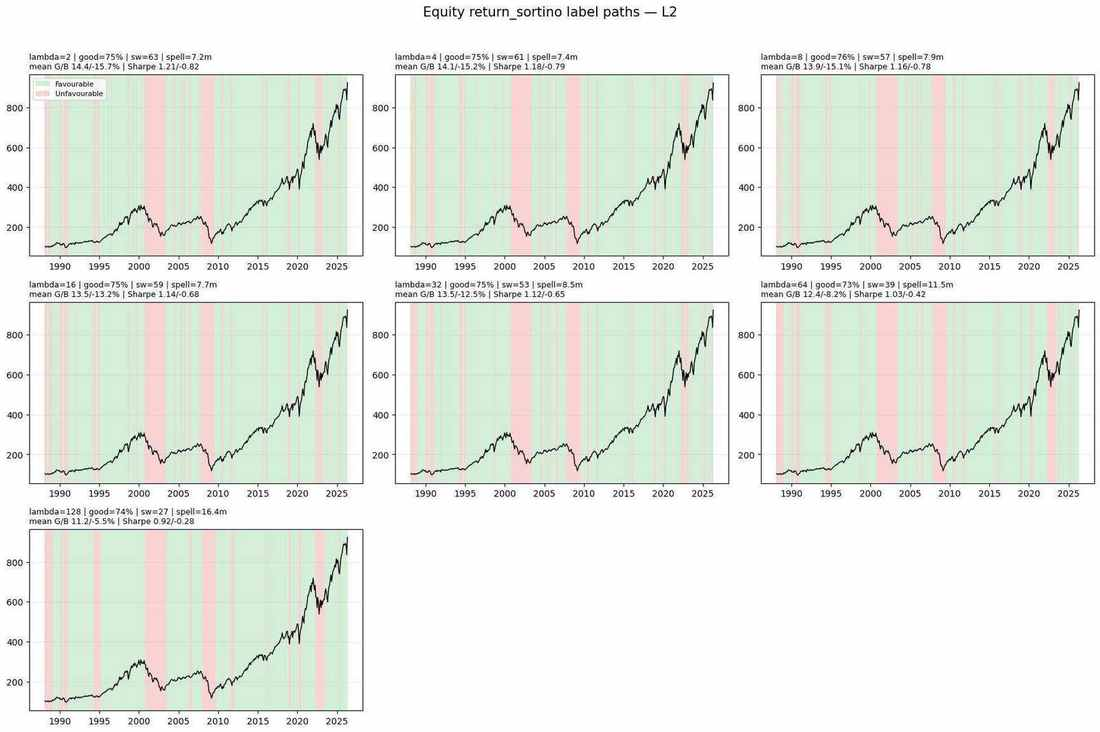

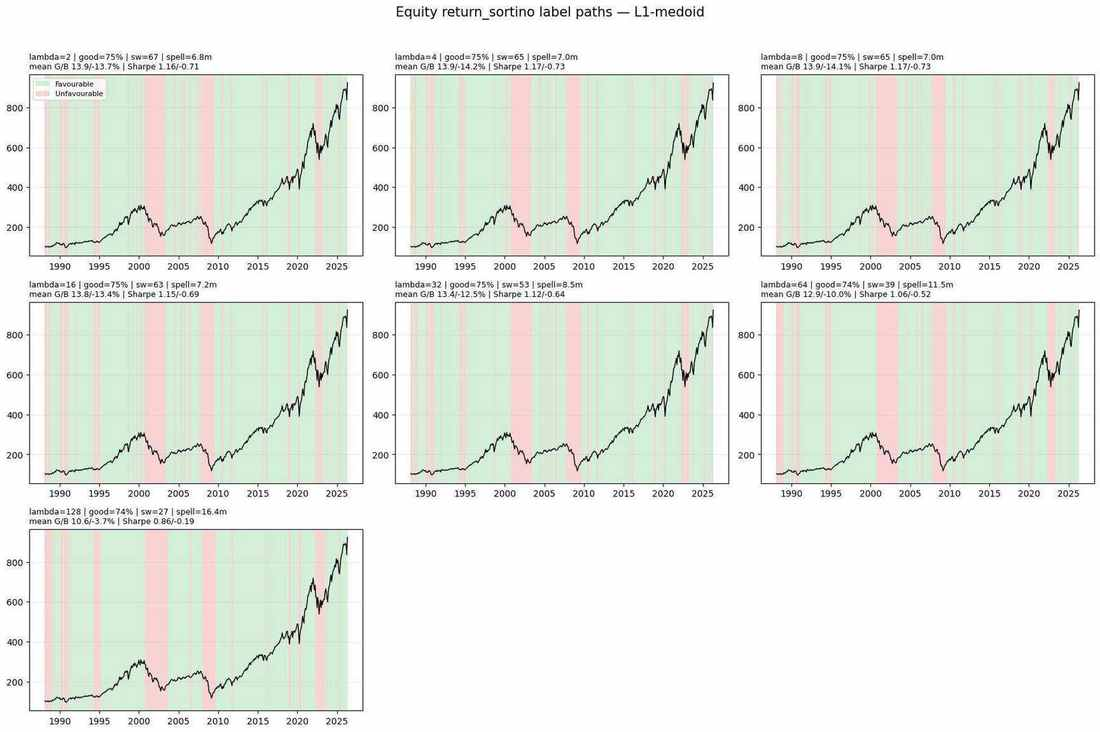

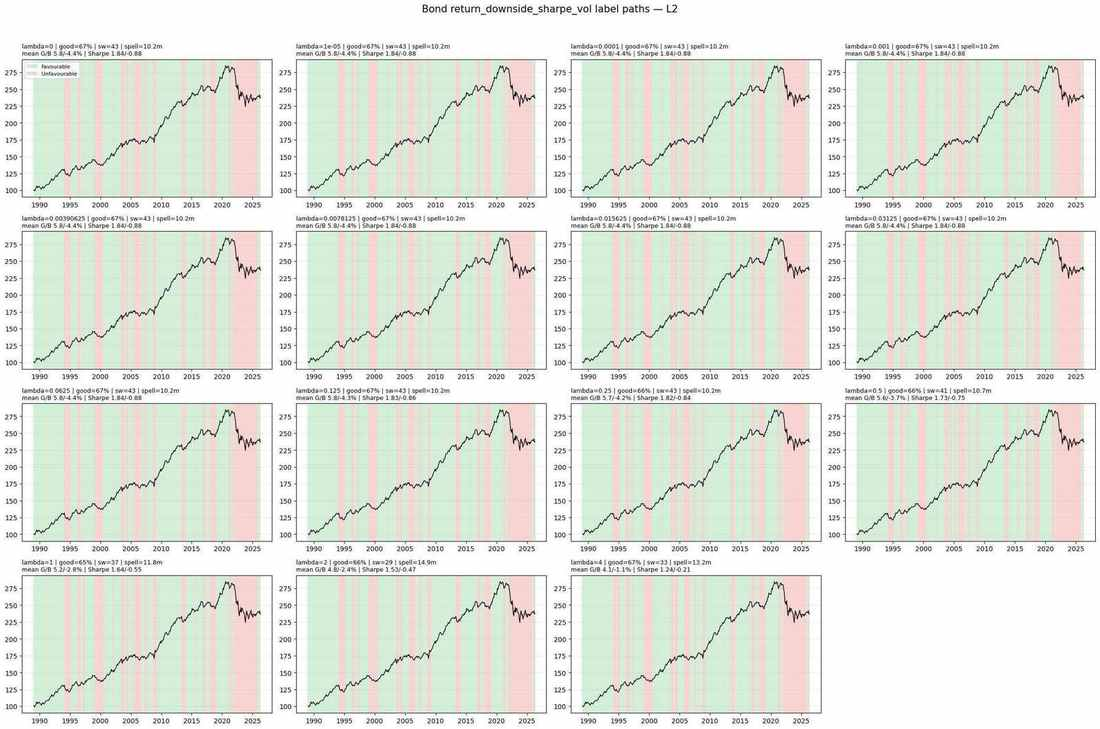

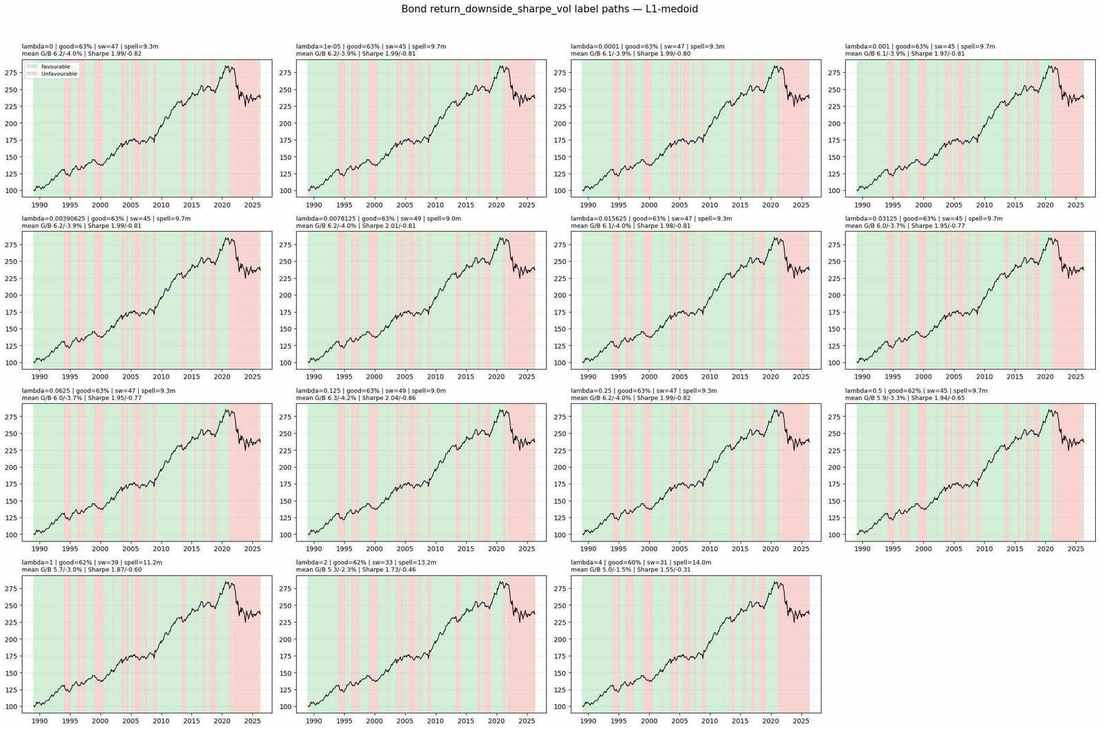

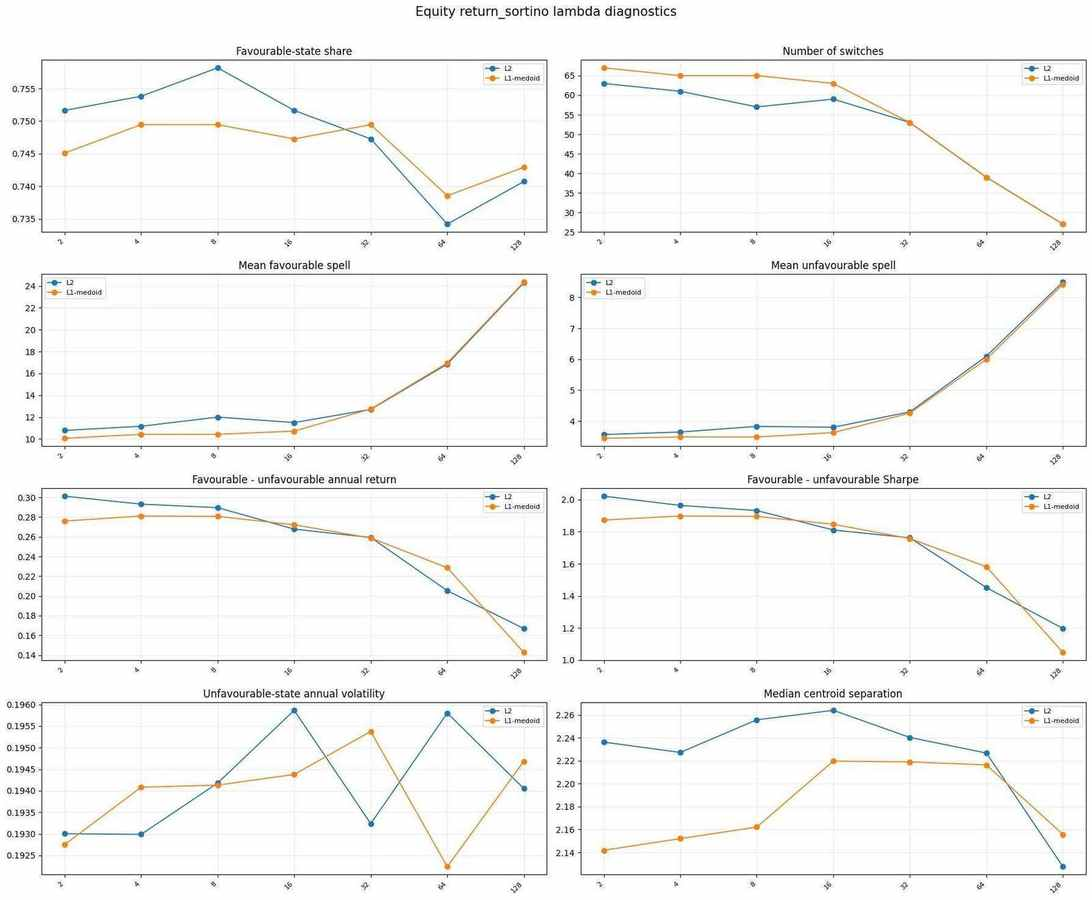

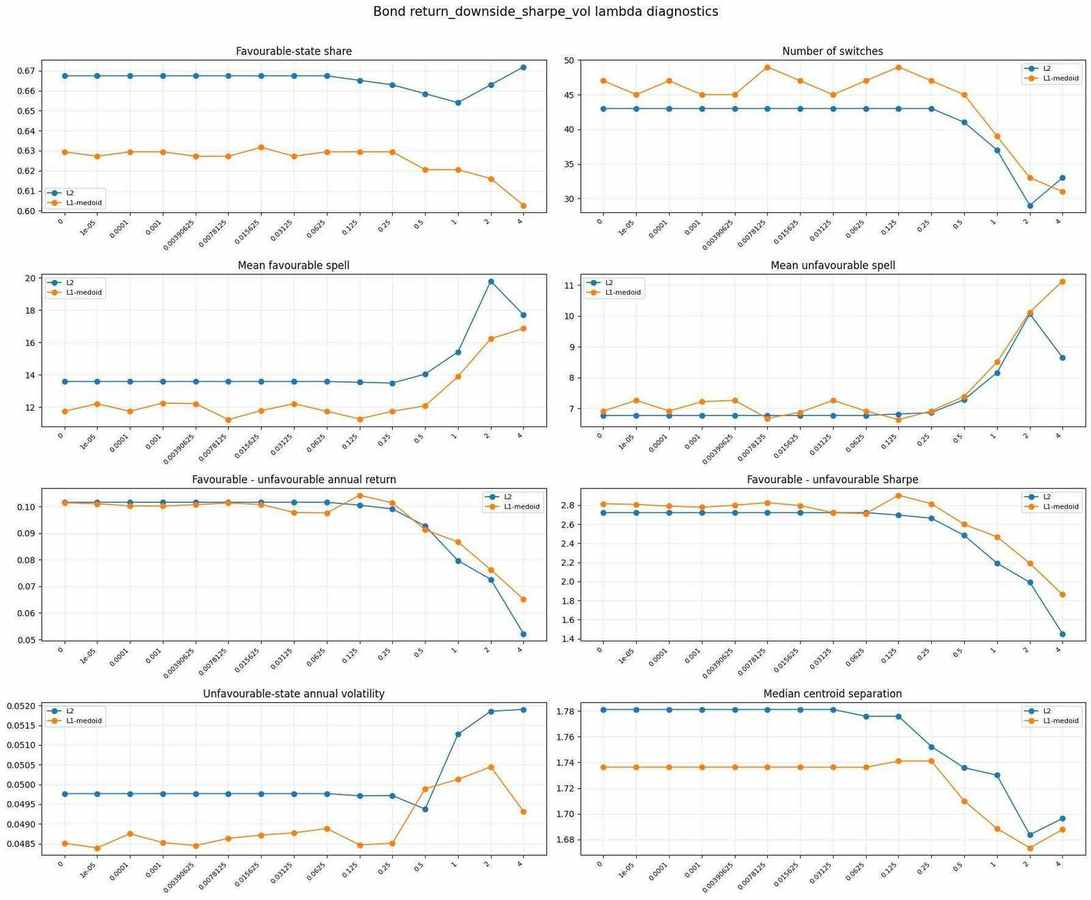

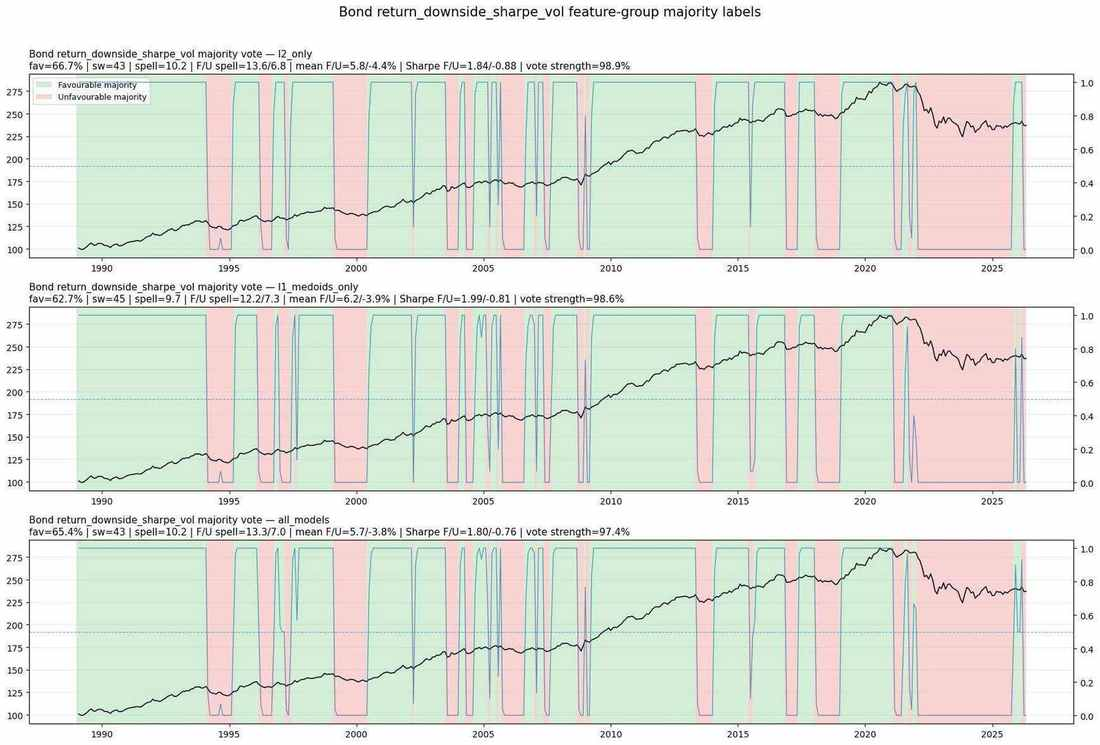

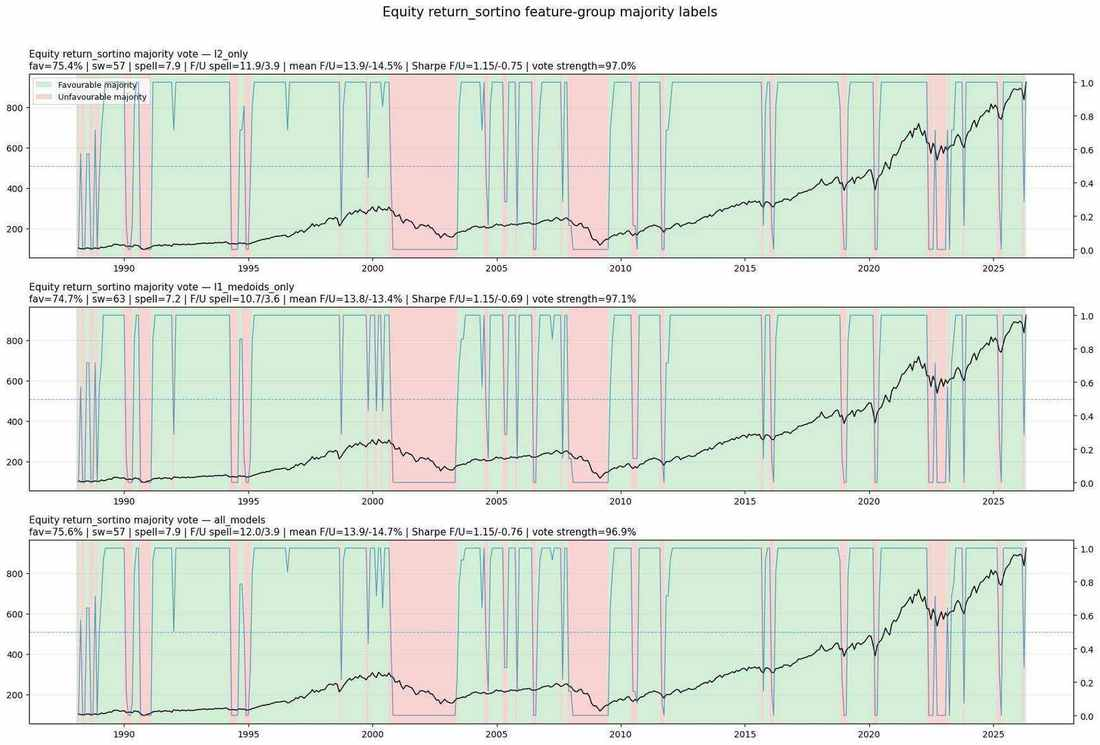

In [2]:
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from numba import njit

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 900)
pd.set_option("display.width", 760)
pd.set_option("display.max_rows", 4000)
pd.set_option("display.float_format", lambda x: f"{x:0.6f}")

EPS = 1e-12
RANDOM_SEED = 123
DAILY_INITIAL_YEARS = 12
MONTHLY_INITIAL_MONTHS = 144
STANDARDIZE_CLIP_SIGMA = 3.0
MAX_CD_ITER = 100
N_INIT = 5

EQUITY_LAMBDA_GRID = [2, 4, 8, 16, 32, 64, 128]
BOND_LAMBDA_GRID = [0, 1e-5, 1e-4, 0.001, 0.00390625, 0.0078125, 0.015625, 0.03125, 0.0625, 0.125, 0.25, 0.5, 1, 2, 4]
MODEL_FAMILIES = ["standard_l2_jump_model", "robust_l1_medoids_jump_model"]
MODEL_LABELS = {"standard_l2_jump_model": "L2", "robust_l1_medoids_jump_model": "L1-medoid"}
MODEL_SHORT_NAME = {"standard_l2_jump_model": "l2", "robust_l1_medoids_jump_model": "l1med"}
MAJORITY_SCOPES = {
    "all_models": None,
    "l2_only": ["standard_l2_jump_model"],
    "l1_medoids_only": ["robust_l1_medoids_jump_model"],
}

MODEL_VARIANT = "independent_teacher_feature_group_majority"
BOND_FEATURE_GROUP = "return_downside_sharpe_vol"
MODEL_OUTPUT_DIR = TEACHER_LABEL_OUTPUT_DIR
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_LABEL_PATH_PLOTS = True
RUN_LAMBDA_DIAGNOSTIC_PLOTS = True
RUN_MAJORITY_VOTE_PLOTS = True

STATE_COLORS = {1: "#b7e4bd", 0: "#f5b5b5"}

CRISIS_WINDOWS = [
    ("1990 recession", "1990-07-31", "1991-03-31"),
    ("1994 bond shock", "1994-01-31", "1994-12-31"),
    ("1998 LTCM-like", "1998-07-31", "1998-10-31"),
    ("Dot-com bust", "2000-03-31", "2002-10-31"),
    ("GFC", "2007-10-31", "2009-03-31"),
    ("Euro sovereign 2011", "2011-05-31", "2011-12-31"),
    ("Covid crash", "2020-02-29", "2020-04-30"),
    ("Inflation 2022", "2022-01-31", "2022-12-31"),
    ("Recent 2024-2026", "2024-01-31", "2026-04-30"),
]

NON_FEATURE_COLS = {
    "date", "month_end", "asset", "teacher_panel", "source_frequency",
    "feature_source", "label_source", "feature_group", "excess_return",
    "excess_return_source", "n_daily_obs", "asset_excess", "asset_excess_from_features",
    "feature_panel_excess", "eq_excess", "bd_excess", "level", "state", "prob",
    "vote_prob", "vote_strength", "n_teachers", "majority_scope", "majority_state",
    "vote_margin", "unanimous", "tie", "mean_teacher_prob", "min_teacher_state",
    "max_teacher_state", "variant", "model_variant", "path_id", "model_family", "lambda",
    "fit_end_date", "n_train_obs", "n_obs_in_month", "raw_state_mapped_to_good",
    "mapping_metric",
}


def month_end(s):
    return pd.to_datetime(s, errors="coerce").dt.to_period("M").dt.to_timestamp("M")


def safe_first_date(s):
    s = pd.to_datetime(s, errors="coerce").dropna()
    return pd.NaT if s.empty else s.min()


def safe_last_date(s):
    s = pd.to_datetime(s, errors="coerce").dropna()
    return pd.NaT if s.empty else s.max()


def feature_cols(df):
    return [c for c in df.columns if c not in NON_FEATURE_COLS and pd.api.types.is_numeric_dtype(df[c])]


def sanitize_float_for_col(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "none"
    return f"{float(x):g}".replace("-", "m").replace(".", "p")


def sanitize_name(x):
    return (
        str(x)
        .replace(" ", "_")
        .replace("-", "_")
        .replace("|", "_")
        .replace(".", "p")
        .replace("(", "")
        .replace(")", "")
        .replace("/", "_")
        .replace(":", "_")
        .lower()
    )


def path_id(asset, feature_group, model_family, lam):
    prefix = {"equity": "eq", "bond": "bd"}.get(asset, asset)
    model_short = MODEL_SHORT_NAME.get(model_family, model_family)
    return "_".join([
        prefix,
        sanitize_name(feature_group),
        sanitize_name(model_short),
        f"lam{sanitize_float_for_col(lam)}",
    ])


def annualization_factor(freq):
    return 252.0 if freq == "daily" else 12.0


def compound_return(ret):
    r = pd.Series(ret).dropna().astype(float)
    return float(np.prod(1.0 + r) - 1.0) if len(r) else np.nan


def count_switches(state):
    s = pd.Series(state).dropna().astype(int).reset_index(drop=True)
    return 0 if len(s) <= 1 else int((s != s.shift(1)).sum() - 1)


def spell_lengths(state):
    s = pd.Series(state).dropna().astype(int).reset_index(drop=True)
    if len(s) == 0:
        return []
    run_id = (s != s.shift(1)).cumsum()
    return [(int(g.iloc[0]), int(len(g))) for _, g in s.groupby(run_id)]


def mean_spell_length(state):
    spells = spell_lengths(state)
    return float(np.mean([n for _, n in spells])) if spells else np.nan


def mean_spell_length_for_state(state, target_state):
    vals = [n for st, n in spell_lengths(state) if st == int(target_state)]
    return float(np.mean(vals)) if vals else np.nan


def current_spell(state):
    s = pd.Series(state).dropna().astype(int).reset_index(drop=True)
    if len(s) == 0:
        return np.nan, np.nan
    last_state = int(s.iloc[-1])
    n = 1
    for i in range(len(s) - 2, -1, -1):
        if int(s.iloc[i]) == last_state:
            n += 1
        else:
            break
    return last_state, n


def transition_stats(state):
    s = pd.Series(state).dropna().astype(int).reset_index(drop=True)
    if len(s) < 2:
        return {
            "p_bad_bad": np.nan,
            "p_bad_good": np.nan,
            "p_good_bad": np.nan,
            "p_good_good": np.nan,
            "expected_duration_bad": np.nan,
            "expected_duration_good": np.nan,
        }
    prev = s.shift(1).iloc[1:].astype(int)
    curr = s.iloc[1:].astype(int)

    def p(i, j):
        den = int((prev == i).sum())
        return np.nan if den == 0 else float(((prev == i) & (curr == j)).sum() / den)

    p00, p01, p10, p11 = p(0, 0), p(0, 1), p(1, 0), p(1, 1)
    return {
        "p_bad_bad": p00,
        "p_bad_good": p01,
        "p_good_bad": p10,
        "p_good_good": p11,
        "expected_duration_bad": 1.0 / max(1.0 - p00, EPS) if np.isfinite(p00) else np.nan,
        "expected_duration_good": 1.0 / max(1.0 - p11, EPS) if np.isfinite(p11) else np.nan,
    }


def ann_mean(r, ann_factor=12.0):
    x = pd.Series(r).dropna().astype(float)
    return float(ann_factor * x.mean()) if len(x) else np.nan


def ann_vol(r, ann_factor=12.0):
    x = pd.Series(r).dropna().astype(float)
    return float(np.sqrt(ann_factor) * x.std(ddof=1)) if len(x) >= 3 else np.nan


def ann_sharpe(r, ann_factor=12.0):
    x = pd.Series(r).dropna().astype(float)
    if len(x) < 3:
        return np.nan
    sd = x.std(ddof=1)
    return np.nan if not np.isfinite(sd) or sd < EPS else float(np.sqrt(ann_factor) * x.mean() / sd)


def downside_ann(r, ann_factor=12.0):
    x = pd.Series(r).dropna().astype(float)
    return float(np.sqrt(ann_factor) * np.sqrt(np.mean(np.minimum(x, 0.0) ** 2))) if len(x) >= 3 else np.nan


def cvar(r, q=0.01):
    x = pd.Series(r).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    cutoff = x.quantile(q)
    tail = x.loc[x <= cutoff]
    return float(tail.mean()) if len(tail) else np.nan


def max_drawdown(r):
    x = pd.Series(r).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    wealth = (1.0 + x.fillna(0.0)).cumprod()
    return float((wealth / wealth.cummax() - 1.0).min())


def feature_block(feature):
    f = str(feature).lower()
    if "log_downside" in f or "downside" in f or "tail" in f:
        return "downside_risk"
    if "sharpe" in f or "sortino" in f:
        return "risk_adjusted_return"
    if "realized_vol" in f or "vol_" in f or f.startswith("vol") or "_vol" in f:
        return "volatility"
    if "ewm_return" in f or "return" in f or "mean" in f:
        return "return_trend"
    return "other"


def date_span_edges(dates):
    d = pd.to_datetime(pd.Series(dates), errors="coerce")
    p = d.dt.to_period("M")
    return p.dt.start_time, p.dt.end_time


def add_state_background_runs(ax, df, date_col="date", state_col="state"):
    x = df[[date_col, state_col]].dropna().copy()
    x[date_col] = pd.to_datetime(x[date_col], errors="coerce")
    x[state_col] = x[state_col].astype(int)
    x = x.sort_values(date_col).reset_index(drop=True)
    left, right = date_span_edges(x[date_col])
    x["left"] = left
    x["right"] = right
    x["run_id"] = (x[state_col] != x[state_col].shift(1)).cumsum()
    ymin, ymax = ax.get_ylim()
    for _, g in x.groupby("run_id", sort=True):
        st = int(g[state_col].iloc[0])
        ax.axvspan(
            g["left"].iloc[0],
            g["right"].iloc[-1],
            facecolor=STATE_COLORS[st],
            alpha=0.60,
            edgecolor="none",
            linewidth=0,
            zorder=0,
        )
    ax.set_ylim(ymin, ymax)


@njit(cache=False)
def dp_path_numba(loss, jump_lambda):
    n = loss.shape[0]
    V = np.empty((n, 2))
    back = np.empty((n, 2), dtype=np.int64)
    V[0, 0] = loss[0, 0]
    V[0, 1] = loss[0, 1]
    back[0, 0] = 0
    back[0, 1] = 1
    for t in range(1, n):
        for s in range(2):
            stay = V[t - 1, s]
            switch = V[t - 1, 1 - s] + jump_lambda
            if stay <= switch:
                V[t, s] = loss[t, s] + stay
                back[t, s] = s
            else:
                V[t, s] = loss[t, s] + switch
                back[t, s] = 1 - s
    path = np.empty(n, dtype=np.int64)
    path[n - 1] = 0 if V[n - 1, 0] <= V[n - 1, 1] else 1
    for t in range(n - 2, -1, -1):
        path[t] = back[t + 1, path[t + 1]]
    return path, V[n - 1, path[n - 1]]


def dp_path(loss, jump_lambda):
    return dp_path_numba(np.asarray(loss, dtype=np.float64), float(jump_lambda))


def clip_and_standardize_train(X):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0)
    sd = np.nanstd(X, axis=0, ddof=0)
    sd = np.where(~np.isfinite(sd) | (sd < EPS), 1.0, sd)
    lo = mu - STANDARDIZE_CLIP_SIGMA * sd
    hi = mu + STANDARDIZE_CLIP_SIGMA * sd
    Xc = np.minimum(np.maximum(X, lo), hi)
    Xs = (Xc - mu) / sd
    return np.where(np.isfinite(Xs), Xs, 0.0), mu, sd, lo, hi


def valid_complete_panel(panel, feats):
    x = panel.copy()
    x["date"] = pd.to_datetime(x["date"], errors="coerce")
    x = (
        x.sort_values("date")
        .drop_duplicates("date", keep="last")
        .reset_index(drop=True)
        .replace([np.inf, -np.inf], np.nan)
    )
    return x.loc[x[feats + ["excess_return"]].notna().all(axis=1)].reset_index(drop=True).copy()


def refit_end_positions(df, freq):
    if freq == "daily":
        t = df.copy()
        t["month_end"] = month_end(t["date"])
        return sorted(t.groupby("month_end", as_index=False).tail(1).index.to_numpy(dtype=int).tolist())
    return list(range(len(df)))


def training_allowed(end_date, first_date, freq):
    end_date = pd.Timestamp(end_date)
    first_date = pd.Timestamp(first_date)
    if freq == "daily":
        return end_date >= first_date + pd.DateOffset(years=DAILY_INITIAL_YEARS)
    return (end_date.to_period("M") - first_date.to_period("M")).n >= MONTHLY_INITIAL_MONTHS - 1


def min_train_obs(freq):
    return int(252 * DAILY_INITIAL_YEARS) if freq == "daily" else int(MONTHLY_INITIAL_MONTHS)


def init_labels(X, rng, asset_ret=None, method="kmeans"):
    if method == "kmeans":
        lab = KMeans(n_clusters=2, n_init=10, random_state=int(rng.integers(1, 10_000_000))).fit_predict(X)
        if len(np.unique(lab)) == 2:
            return lab
    if method == "quantile_ret" and asset_ret is not None:
        r = pd.Series(asset_ret).astype(float).fillna(0.0).to_numpy()
        lab = (r > np.nanmedian(r)).astype(int)
        if len(np.unique(lab)) == 2:
            return lab
    lab = rng.integers(0, 2, size=X.shape[0])
    if len(np.unique(lab)) == 2:
        return lab
    lab[: len(lab) // 2] = 0
    lab[len(lab) // 2 :] = 1
    return lab


def mean_centers(X, labels):
    glob = np.nanmean(X, axis=0)
    centers = np.zeros((2, X.shape[1]))
    for k in [0, 1]:
        centers[k] = glob if not (labels == k).any() else np.nanmean(X[labels == k], axis=0)
    return np.where(np.isfinite(centers), centers, 0.0)


def nearest_to_l1_median_centers(X, labels):
    glob = np.nanmedian(X, axis=0)
    centers = np.zeros((2, X.shape[1]))
    for k in [0, 1]:
        Xk = X[labels == k]
        if len(Xk) == 0:
            centers[k] = glob
        else:
            med = np.nanmedian(Xk, axis=0)
            centers[k] = Xk[int(np.argmin(np.sum(np.abs(Xk - med), axis=1)))]
    return np.where(np.isfinite(centers), centers, 0.0)


def l2_loss(X, centers):
    return np.column_stack([
        0.5 * np.sum((X - centers[0]) ** 2, axis=1),
        0.5 * np.sum((X - centers[1]) ** 2, axis=1),
    ])


def l1_loss(X, centers):
    return np.column_stack([
        np.sum(np.abs(X - centers[0]), axis=1),
        np.sum(np.abs(X - centers[1]), axis=1),
    ])


def center_distance(centers):
    return np.nan if centers is None else float(np.linalg.norm(centers[1] - centers[0]))


def fit_jump_model(X, jump_lambda, asset_ret, seed, kind):
    rng = np.random.default_rng(seed)
    best = None
    methods = ["kmeans", "quantile_ret", "random"]
    for i in range(N_INIT):
        labels = init_labels(X, rng, asset_ret, methods[i % len(methods)])
        centers = mean_centers(X, labels) if kind == "l2" else nearest_to_l1_median_centers(X, labels)
        last = None
        for _ in range(MAX_CD_ITER):
            loss = l2_loss(X, centers) if kind == "l2" else l1_loss(X, centers)
            path, _ = dp_path(loss, jump_lambda)
            if last is not None and np.array_equal(path, last):
                break
            last = path.copy()
            centers = mean_centers(X, path) if kind == "l2" else nearest_to_l1_median_centers(X, path)
        loss = l2_loss(X, centers) if kind == "l2" else l1_loss(X, centers)
        path, _ = dp_path(loss, jump_lambda)
        data_loss = float(np.sum(loss[np.arange(len(path)), path]))
        jump_loss = float(jump_lambda * np.sum(path[1:] != path[:-1]))
        cand = {
            "labels": path,
            "centers": centers,
            "obj": data_loss + jump_loss,
            "data_loss": data_loss,
            "jump_loss": jump_loss,
            "center_dist": center_distance(centers),
        }
        if best is None or cand["obj"] < best["obj"]:
            best = cand
    return best


def bcss_from_labels(X, labels):
    glob = np.nanmean(X, axis=0)
    b = np.zeros(X.shape[1])
    labels = np.asarray(labels, dtype=int)
    for k in [0, 1]:
        m = labels == k
        if m.any():
            b += int(m.sum()) * (np.nanmean(X[m], axis=0) - glob) ** 2
    return np.where(np.isfinite(b), b, 0.0)


def map_raw_state_to_good(labels, ret, freq):
    labels = np.asarray(labels, dtype=int)
    ret = np.asarray(ret, dtype=float)
    ann = annualization_factor(freq)
    stats = {}
    for k in [0, 1]:
        rk = pd.Series(ret[labels == k]).dropna().astype(float)
        stats[f"raw_state{k}_n"] = int(len(rk))
        stats[f"raw_state{k}_ann_mean"] = ann_mean(rk, ann)
        stats[f"raw_state{k}_ann_vol"] = ann_vol(rk, ann)
        stats[f"raw_state{k}_ann_sharpe"] = ann_sharpe(rk, ann)
        stats[f"raw_state{k}_ann_downside"] = downside_ann(rk, ann)
    s0, s1 = stats["raw_state0_ann_sharpe"], stats["raw_state1_ann_sharpe"]
    if np.isfinite(s0) and np.isfinite(s1) and abs(s0 - s1) > 1e-10:
        good = 0 if s0 >= s1 else 1
        metric = "higher_realized_sharpe"
    else:
        m0, m1 = stats["raw_state0_ann_mean"], stats["raw_state1_ann_mean"]
        good = 0 if np.isfinite(m0) and np.isfinite(m1) and m0 >= m1 else 1
        metric = "higher_realized_mean_fallback"
    stats.update({"raw_state_mapped_to_good": int(good), "mapping_metric": metric})
    return int(good), stats


def centroid_diagnostics(X, labels, feats, raw_good, meta):
    labels = np.asarray(labels, dtype=int)
    raw_bad = 1 - int(raw_good)
    glob = np.nanmean(X, axis=0)
    bcss = bcss_from_labels(X, labels)
    rows = []
    for j, f in enumerate(feats):
        xb = X[labels == raw_bad, j]
        xg = X[labels == raw_good, j]
        cb = float(np.nanmean(xb)) if len(xb) else np.nan
        cg = float(np.nanmean(xg)) if len(xg) else np.nan
        sb = float(np.nanstd(xb, ddof=0)) if len(xb) else np.nan
        sg = float(np.nanstd(xg, ddof=0)) if len(xg) else np.nan
        gap = cg - cb
        sep = abs(gap) / (np.sqrt(0.5 * ((sb if np.isfinite(sb) else 0) ** 2 + (sg if np.isfinite(sg) else 0) ** 2)) + EPS)
        rows.append({
            **meta,
            "feature": f,
            "centroid_bad": cb,
            "centroid_good": cg,
            "gap_good_minus_bad": gap,
            "abs_gap": abs(gap),
            "within_bad_std": sb,
            "within_good_std": sg,
            "centroid_separation_ratio": sep,
            "BCSS": float(bcss[j]),
            "global_mean_scaled": float(glob[j]),
        })
    return rows


def fit_one_teacher_path(panel, asset, feature_group, model_family, lam):
    panel = panel.copy()
    panel["asset"] = asset
    panel["feature_group"] = feature_group
    freq = str(panel["source_frequency"].dropna().iloc[0])
    label_source = f"{asset}_{feature_group}_{freq}_sjm"
    panel["label_source"] = label_source
    feats = feature_cols(panel)
    df = valid_complete_panel(panel, feats)
    first = pd.Timestamp(df["date"].min())
    minobs = min_train_obs(freq)
    positions = refit_end_positions(df, freq)
    pid = path_id(asset, feature_group, model_family, lam)
    monthly_rows = []
    log_rows = []
    centroid_rows = []
    last_fit = None
    t0 = time.time()

    for end_pos in positions:
        end = pd.Timestamp(df.loc[end_pos, "date"])
        if not training_allowed(end, first, freq):
            continue
        tr = df.iloc[: end_pos + 1].copy()
        if len(tr) < minobs:
            continue

        X, mu, sd, lo, hi = clip_and_standardize_train(tr[feats].to_numpy(float))
        ret = tr["excess_return"].to_numpy(float)
        seed = RANDOM_SEED + int(abs(hash((asset, feature_group, model_family, float(lam), str(end)))) % 1_000_000)
        fit = fit_jump_model(X, float(lam), ret, seed, "l2" if model_family == "standard_l2_jump_model" else "l1")
        labels = np.asarray(fit["labels"], dtype=int)
        raw_good, stats = map_raw_state_to_good(labels, ret, freq)
        good = (labels == raw_good).astype(float)
        current = end.to_period("M").to_timestamp("M")

        if freq == "daily":
            mm = month_end(tr["date"]).eq(current).to_numpy()
            prob = float(np.nanmean(good[mm]))
            state = float(prob >= 0.5)
            asset_excess = compound_return(tr.loc[mm, "excess_return"])
            nobs = int(mm.sum())
            feature_source = "daily"
            n_daily_obs = np.nan
        else:
            prob = float(good[-1])
            state = prob
            asset_excess = float(tr["excess_return"].iloc[-1])
            nobs = 1
            feature_source = str(tr["feature_source"].iloc[-1]) if "feature_source" in tr.columns else "monthly"
            n_daily_obs = float(tr["n_daily_obs"].iloc[-1]) if "n_daily_obs" in tr.columns and pd.notna(tr["n_daily_obs"].iloc[-1]) else np.nan

        monthly_rows.append({
            "date": current,
            "asset": asset,
            "feature_group": feature_group,
            "model_family": model_family,
            "lambda": float(lam),
            "label_source": label_source,
            "source_frequency": freq,
            "path_id": pid,
            "state": state,
            "prob": prob,
            "asset_excess": asset_excess,
            "n_obs_in_month": nobs,
            "n_train_obs": len(tr),
            "fit_end_date": end,
            "raw_state_mapped_to_good": int(raw_good),
            "mapping_metric": stats["mapping_metric"],
            "feature_source": feature_source,
            "n_daily_obs": n_daily_obs,
        })
        last_fit = fit, X, tr, labels, raw_good, stats

    monthly_df = (
        pd.DataFrame(monthly_rows)
        .sort_values("date")
        .drop_duplicates(["date", "path_id"], keep="last")
        .reset_index(drop=True)
        if monthly_rows
        else pd.DataFrame()
    )

    meta = {
        "path_id": pid,
        "asset": asset,
        "feature_group": feature_group,
        "model_family": model_family,
        "lambda": float(lam),
        "label_source": label_source,
        "source_frequency": freq,
    }

    if last_fit is not None:
        fit, X, tr, labels, raw_good, stats = last_fit
        centroid_rows = centroid_diagnostics(X, labels, feats, raw_good, meta)
        log_rows.append({
            **meta,
            "n_feature_cols": len(feats),
            "n_monthly_labels": len(monthly_df),
            "first_label_date": safe_first_date(monthly_df["date"]) if len(monthly_df) else pd.NaT,
            "last_label_date": safe_last_date(monthly_df["date"]) if len(monthly_df) else pd.NaT,
            "last_n_train_obs": len(tr),
            "last_obj": fit.get("obj", np.nan),
            "last_data_loss": fit.get("data_loss", np.nan),
            "last_jump_loss": fit.get("jump_loss", np.nan),
            "last_center_dist": fit.get("center_dist", np.nan),
            "raw_state_mapped_to_good_last": int(raw_good),
            "mapping_metric_last": stats["mapping_metric"],
            "elapsed_seconds": time.time() - t0,
        })

    return monthly_df, pd.DataFrame(log_rows), pd.DataFrame(centroid_rows)


def prepare_teacher_panel(df, asset, feature_group, source_frequency):
    x = df.copy()
    x["date"] = pd.to_datetime(x["date"], errors="coerce")
    x["asset"] = asset
    x["feature_group"] = feature_group
    x["source_frequency"] = source_frequency
    x["label_source"] = f"{asset}_{feature_group}_{source_frequency}_sjm"
    return x.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)


equity_teacher = prepare_teacher_panel(
    equity_teacher,
    asset="equity",
    feature_group="return_sortino",
    source_frequency="daily",
)

bond_teacher = prepare_teacher_panel(
    bond_teacher,
    asset="bond",
    feature_group=BOND_FEATURE_GROUP,
    source_frequency="monthly",
)

teacher_feature_sets = {
    ("equity", "return_sortino"): EQUITY_RETURN_SORTINO_FEATURES,
    ("bond", BOND_FEATURE_GROUP): BOND_MONTHLY_TEACHER_FEATURES,
}

teacher_panel_registry = {
    ("equity", "return_sortino"): equity_teacher.copy(),
    ("bond", BOND_FEATURE_GROUP): bond_teacher.copy(),
}

for key, feats in teacher_feature_sets.items():
    panel = teacher_panel_registry[key].copy()
    for c in feats + ["excess_return"]:
        panel[c] = pd.to_numeric(panel[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
    teacher_panel_registry[key] = panel

equity_teacher = teacher_panel_registry[("equity", "return_sortino")].copy()
bond_teacher = teacher_panel_registry[("bond", BOND_FEATURE_GROUP)].copy()

teacher_daily_panels = {
    ("equity", "return_sortino", "daily_sjm"): equity_teacher.copy(),
}

teacher_monthly_panels = {
    ("bond", BOND_FEATURE_GROUP, "monthly_sjm"): bond_teacher.copy(),
}

model_specs = []
for model_family in MODEL_FAMILIES:
    for (asset, feature_group), panel in teacher_panel_registry.items():
        lambda_grid = EQUITY_LAMBDA_GRID if asset == "equity" else BOND_LAMBDA_GRID
        for lam in lambda_grid:
            model_specs.append((panel.copy(), asset, feature_group, model_family, float(lam)))

label_parts = []
log_parts = []
centroid_parts = []


for panel, asset, feature_group, model_family, lam in model_specs:
    monthly_df, fit_log_df, centroid_df = fit_one_teacher_path(
        panel=panel,
        asset=asset,
        feature_group=feature_group,
        model_family=model_family,
        lam=lam,
    )
    if len(monthly_df):
        monthly_df = monthly_df.copy()
        monthly_df["model_variant"] = MODEL_VARIANT
        label_parts.append(monthly_df)
    if len(fit_log_df):
        fit_log_df = fit_log_df.copy()
        fit_log_df["model_variant"] = MODEL_VARIANT
        log_parts.append(fit_log_df)
    if len(centroid_df):
        centroid_df = centroid_df.copy()
        centroid_df["model_variant"] = MODEL_VARIANT
        centroid_parts.append(centroid_df)

teacher_monthly_labels_long = pd.concat(label_parts, ignore_index=True, sort=False)
teacher_fit_log = pd.concat(log_parts, ignore_index=True, sort=False)
teacher_centroid_feature_diagnostics = pd.concat(centroid_parts, ignore_index=True, sort=False)

teacher_monthly_labels_long["date"] = pd.to_datetime(teacher_monthly_labels_long["date"], errors="coerce")
teacher_monthly_labels_long["lambda"] = pd.to_numeric(teacher_monthly_labels_long["lambda"], errors="coerce")
teacher_monthly_labels_long["state"] = pd.to_numeric(teacher_monthly_labels_long["state"], errors="coerce")
teacher_monthly_labels_long["prob"] = pd.to_numeric(teacher_monthly_labels_long["prob"], errors="coerce")
teacher_monthly_labels_long["asset_excess"] = pd.to_numeric(teacher_monthly_labels_long["asset_excess"], errors="coerce")
teacher_monthly_labels_long = (
    teacher_monthly_labels_long
    .sort_values(["asset", "feature_group", "model_family", "lambda", "date"])
    .reset_index(drop=True)
)


diag_group_cols = [
    "path_id",
    "asset",
    "feature_group",
    "model_family",
    "lambda",
    "label_source",
    "source_frequency",
]


def persistence_row(g):
    g = g.sort_values("date").dropna(subset=["state"]).copy()
    s = g["state"].astype(int)
    n_months = int(len(g))
    n_switches = count_switches(s)
    return pd.Series({
        "n_months": n_months,
        "first_date": g["date"].min() if n_months else pd.NaT,
        "last_date": g["date"].max() if n_months else pd.NaT,
        "good_share": float(s.mean()) if n_months else np.nan,
        "bad_share": float(1.0 - s.mean()) if n_months else np.nan,
        "n_switches": n_switches,
        "mean_spell_length": mean_spell_length(s),
        "mean_good_spell_length": mean_spell_length_for_state(s, 1),
        "mean_bad_spell_length": mean_spell_length_for_state(s, 0),
        "monthly_turnover": float(n_switches / max(n_months - 1, 1)) if n_months else np.nan,
    })


def state_return_row(g):
    g = g.sort_values("date").dropna(subset=["state", "asset_excess"]).copy()
    s = g["state"].astype(int)
    good = g.loc[s.eq(1), "asset_excess"]
    bad = g.loc[s.eq(0), "asset_excess"]
    return pd.Series({
        "n_months": int(len(g)),
        "n_good": int(len(good)),
        "n_bad": int(len(bad)),
        "state_good_ann_return": ann_mean(good, 12.0),
        "state_bad_ann_return": ann_mean(bad, 12.0),
        "state_good_ann_vol": ann_vol(good, 12.0),
        "state_bad_ann_vol": ann_vol(bad, 12.0),
        "state_good_downside": downside_ann(good, 12.0),
        "state_bad_downside": downside_ann(bad, 12.0),
        "state_good_sharpe": ann_sharpe(good, 12.0),
        "state_bad_sharpe": ann_sharpe(bad, 12.0),
        "good_minus_bad_ann_return": ann_mean(good, 12.0) - ann_mean(bad, 12.0),
        "good_minus_bad_ann_vol": ann_vol(good, 12.0) - ann_vol(bad, 12.0),
        "good_minus_bad_downside": downside_ann(good, 12.0) - downside_ann(bad, 12.0),
        "good_minus_bad_sharpe": ann_sharpe(good, 12.0) - ann_sharpe(bad, 12.0),
        "good_max_drawdown": max_drawdown(good),
        "bad_max_drawdown": max_drawdown(bad),
        "good_cvar_1pct": cvar(good, 0.01),
        "bad_cvar_1pct": cvar(bad, 0.01),
    })


teacher_persistence_diagnostics = (
    teacher_monthly_labels_long
    .groupby(diag_group_cols, dropna=False)
    .apply(persistence_row)
    .reset_index()
    .sort_values(["asset", "feature_group", "model_family", "lambda"])
    .reset_index(drop=True)
)

teacher_state_return_diagnostics = (
    teacher_monthly_labels_long
    .groupby(diag_group_cols, dropna=False)
    .apply(state_return_row)
    .reset_index()
    .sort_values(["asset", "feature_group", "model_family", "lambda"])
    .reset_index(drop=True)
)

teacher_feature_separation_by_path = teacher_centroid_feature_diagnostics.copy()
teacher_feature_separation_by_path["centroid_separation_ratio"] = pd.to_numeric(teacher_feature_separation_by_path["centroid_separation_ratio"], errors="coerce")
teacher_feature_separation_by_path["abs_gap"] = pd.to_numeric(teacher_feature_separation_by_path["abs_gap"], errors="coerce")
teacher_feature_separation_by_path["gap_good_minus_bad"] = pd.to_numeric(teacher_feature_separation_by_path["gap_good_minus_bad"], errors="coerce")
teacher_feature_separation_by_path["dominant_direction"] = np.where(
    teacher_feature_separation_by_path["gap_good_minus_bad"] >= 0,
    "higher_in_good",
    "higher_in_bad",
)
teacher_feature_separation_by_path = (
    teacher_feature_separation_by_path
    .sort_values(["asset", "feature_group", "model_family", "lambda", "centroid_separation_ratio"], ascending=[True, True, True, True, False])
    .reset_index(drop=True)
)
teacher_feature_separation_by_path["rank_within_path"] = (
    teacher_feature_separation_by_path
    .groupby("path_id", dropna=False)["centroid_separation_ratio"]
    .rank(method="first", ascending=False)
    .astype(int)
)

teacher_feature_separation_summary = (
    teacher_feature_separation_by_path
    .groupby(["asset", "feature_group", "model_family", "feature"], dropna=False)
    .agg(
        n_paths=("path_id", "nunique"),
        median_rank=("rank_within_path", "median"),
        mean_rank=("rank_within_path", "mean"),
        best_rank=("rank_within_path", "min"),
        worst_rank=("rank_within_path", "max"),
        median_sep=("centroid_separation_ratio", "median"),
        mean_sep=("centroid_separation_ratio", "mean"),
        min_sep=("centroid_separation_ratio", "min"),
        max_sep=("centroid_separation_ratio", "max"),
        median_abs_gap=("abs_gap", "median"),
        median_bcss=("BCSS", "median"),
        positive_gap_share=("gap_good_minus_bad", lambda z: float((pd.to_numeric(z, errors="coerce") > 0).mean())),
        negative_gap_share=("gap_good_minus_bad", lambda z: float((pd.to_numeric(z, errors="coerce") < 0).mean())),
    )
    .reset_index()
)
teacher_feature_separation_summary["dominant_direction"] = np.where(
    teacher_feature_separation_summary["positive_gap_share"] >= teacher_feature_separation_summary["negative_gap_share"],
    "higher_in_good",
    "higher_in_bad",
)
teacher_feature_separation_summary["direction_consistency"] = teacher_feature_separation_summary[["positive_gap_share", "negative_gap_share"]].max(axis=1)
teacher_feature_separation_summary = teacher_feature_separation_summary.sort_values(
    ["asset", "feature_group", "model_family", "median_sep"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

path_key = diag_group_cols

top_feature_base = (
    teacher_feature_separation_by_path
    .sort_values(path_key + ["centroid_separation_ratio"], ascending=[True] * len(path_key) + [False], na_position="last")
    .groupby(path_key, dropna=False)
    .head(5)
    .copy()
)
top_feature_base["feature_desc"] = (
    top_feature_base["feature"].astype(str)
    + ":"
    + top_feature_base["centroid_separation_ratio"].apply(lambda v: "nan" if pd.isna(v) else f"{float(v):0.2f}")
)
top_features_by_path = (
    top_feature_base
    .groupby(path_key, dropna=False)["feature_desc"]
    .agg(lambda z: ", ".join([str(v) for v in z if pd.notna(v)]))
    .reset_index()
    .rename(columns={"feature_desc": "top5_centroid_features"})
)
centroid_by_path = (
    teacher_feature_separation_by_path
    .groupby(path_key, dropna=False)
    .agg(
        n_features=("feature", "count"),
        median_centroid_separation=("centroid_separation_ratio", "median"),
        mean_centroid_separation=("centroid_separation_ratio", "mean"),
        max_centroid_separation=("centroid_separation_ratio", "max"),
        min_centroid_separation=("centroid_separation_ratio", "min"),
        n_features_sep_ge_0p5=("centroid_separation_ratio", lambda z: int((pd.to_numeric(z, errors="coerce") >= 0.5).sum())),
        n_features_sep_ge_1p0=("centroid_separation_ratio", lambda z: int((pd.to_numeric(z, errors="coerce") >= 1.0).sum())),
        n_features_sep_ge_1p5=("centroid_separation_ratio", lambda z: int((pd.to_numeric(z, errors="coerce") >= 1.5).sum())),
        median_abs_gap=("abs_gap", "median"),
        max_abs_gap=("abs_gap", "max"),
        total_bcss=("BCSS", "sum"),
    )
    .reset_index()
    .merge(top_features_by_path, on=path_key, how="left")
)

teacher_path_diagnostics = (
    teacher_persistence_diagnostics
    .merge(teacher_state_return_diagnostics, on=path_key, how="left", suffixes=("", "_ret"))
    .merge(centroid_by_path, on=path_key, how="left")
)

for c in [
    "good_share", "n_switches", "mean_spell_length", "mean_good_spell_length",
    "mean_bad_spell_length", "monthly_turnover", "good_minus_bad_ann_return",
    "good_minus_bad_ann_vol", "good_minus_bad_downside", "good_minus_bad_sharpe",
    "median_centroid_separation", "max_centroid_separation", "n_features_sep_ge_1p0",
]:
    if c in teacher_path_diagnostics.columns:
        teacher_path_diagnostics[c] = pd.to_numeric(teacher_path_diagnostics[c], errors="coerce")

teacher_path_diagnostics["state_balance_ok"] = teacher_path_diagnostics["good_share"].between(0.10, 0.90)
teacher_path_diagnostics["not_constant"] = teacher_path_diagnostics["n_switches"].ge(2)
teacher_path_diagnostics["not_monthly_flipping"] = teacher_path_diagnostics["mean_spell_length"].ge(3.0)
teacher_path_diagnostics["economic_order_ok"] = (
    (teacher_path_diagnostics["good_minus_bad_ann_return"] > 0)
    & (teacher_path_diagnostics["good_minus_bad_sharpe"] > 0)
)
teacher_path_diagnostics["centroid_ok"] = (
    (teacher_path_diagnostics["median_centroid_separation"] >= 0.5)
    & (teacher_path_diagnostics["n_features_sep_ge_1p0"] >= 3)
)
teacher_path_diagnostics = teacher_path_diagnostics.sort_values(["asset", "feature_group", "model_family", "lambda"]).reset_index(drop=True)


def make_wide_labels(long_df):
    x = long_df[["date", "asset", "feature_group", "path_id", "state", "prob", "asset_excess"]].copy()
    x["date"] = pd.to_datetime(x["date"], errors="coerce")
    pieces = []
    for pid, g in x.groupby("path_id", sort=True):
        p = g[["date", "state", "prob"]].sort_values("date").copy()
        p = p.rename(columns={"state": f"{pid}_state", "prob": f"{pid}_prob"})
        pieces.append(p)
    wide = pieces[0]
    for p in pieces[1:]:
        wide = wide.merge(p, on="date", how="outer")

    ret = (
        x.groupby(["date", "asset"], as_index=False)["asset_excess"]
        .mean()
        .pivot(index="date", columns="asset", values="asset_excess")
        .reset_index()
    )
    ret.columns.name = None
    ret = ret.rename(columns={"equity": "eq_excess", "bond": "bd_excess"})
    return wide.merge(ret, on="date", how="left").sort_values("date").reset_index(drop=True)


teacher_monthly_labels_wide = make_wide_labels(teacher_monthly_labels_long)
teacher_prediction_targets_h1_all_paths = teacher_monthly_labels_wide.copy()
non_date_cols = [c for c in teacher_prediction_targets_h1_all_paths.columns if c != "date"]
teacher_prediction_targets_h1_all_paths[non_date_cols] = teacher_prediction_targets_h1_all_paths[non_date_cols].shift(-1)

majority_parts = []
for (asset, feature_group), asset_fg_df in teacher_monthly_labels_long.groupby(["asset", "feature_group"], sort=True):
    for majority_scope, model_filter in MAJORITY_SCOPES.items():
        h = asset_fg_df.copy() if model_filter is None else asset_fg_df.loc[asset_fg_df["model_family"].isin(model_filter)].copy()
        if h.empty:
            continue
        h = h.sort_values(["path_id", "date"]).drop_duplicates(["path_id", "date"], keep="last").copy()
        m = (
            h.groupby("date", as_index=False)
            .agg(
                asset=("asset", "first"),
                feature_group=("feature_group", "first"),
                vote_prob=("state", "mean"),
                n_teachers=("path_id", "nunique"),
                asset_excess=("asset_excess", "first"),
                mean_teacher_prob=("prob", "mean"),
                min_teacher_state=("state", "min"),
                max_teacher_state=("state", "max"),
            )
        )
        m["majority_scope"] = majority_scope
        m["majority_state"] = (m["vote_prob"] >= 0.5).astype(int)
        m["vote_margin"] = (m["vote_prob"] - 0.5).abs()
        m["vote_strength"] = np.maximum(m["vote_prob"], 1.0 - m["vote_prob"])
        m["unanimous"] = m["vote_strength"].eq(1.0)
        m["tie"] = np.isclose(m["vote_prob"], 0.5)
        m["variant"] = MODEL_VARIANT
        majority_parts.append(m)

majority_vote_labels_long = (
    pd.concat(majority_parts, axis=0, ignore_index=True, sort=False)
    .sort_values(["asset", "feature_group", "majority_scope", "date"])
    .reset_index(drop=True)
)


def majority_metrics_row(g):
    g = g.sort_values("date").dropna(subset=["majority_state", "asset_excess"]).copy()
    s = g["majority_state"].astype(int)
    good = g.loc[s.eq(1), "asset_excess"]
    bad = g.loc[s.eq(0), "asset_excess"]
    trans = transition_stats(s)
    n_switches = count_switches(s)
    return pd.Series({
        "n_months": int(len(g)),
        "first_date": g["date"].min() if len(g) else pd.NaT,
        "last_date": g["date"].max() if len(g) else pd.NaT,
        "good_share": float(s.mean()) if len(g) else np.nan,
        "bad_share": float(1.0 - s.mean()) if len(g) else np.nan,
        "n_switches": n_switches,
        "mean_spell_length": mean_spell_length(s),
        "mean_good_spell_length": mean_spell_length_for_state(s, 1),
        "mean_bad_spell_length": mean_spell_length_for_state(s, 0),
        "monthly_turnover": float(n_switches / max(len(g) - 1, 1)) if len(g) else np.nan,
        "avg_n_teachers": float(g["n_teachers"].mean()) if "n_teachers" in g.columns and len(g) else np.nan,
        "min_n_teachers": int(g["n_teachers"].min()) if "n_teachers" in g.columns and len(g) else np.nan,
        "avg_vote_prob": float(g["vote_prob"].mean()) if "vote_prob" in g.columns and len(g) else np.nan,
        "avg_vote_strength": float(g["vote_strength"].mean()) if "vote_strength" in g.columns and len(g) else np.nan,
        "weak_vote_share_50_60": float((g["vote_strength"] < 0.60).mean()) if "vote_strength" in g.columns and len(g) else np.nan,
        "strong_vote_share_80_100": float((g["vote_strength"] >= 0.80).mean()) if "vote_strength" in g.columns and len(g) else np.nan,
        "state_good_ann_return": ann_mean(good, 12.0),
        "state_bad_ann_return": ann_mean(bad, 12.0),
        "state_good_ann_vol": ann_vol(good, 12.0),
        "state_bad_ann_vol": ann_vol(bad, 12.0),
        "state_good_downside": downside_ann(good, 12.0),
        "state_bad_downside": downside_ann(bad, 12.0),
        "state_good_sharpe": ann_sharpe(good, 12.0),
        "state_bad_sharpe": ann_sharpe(bad, 12.0),
        "state_good_cvar_1pct": cvar(good, 0.01),
        "state_bad_cvar_1pct": cvar(bad, 0.01),
        "good_minus_bad_ann_return": ann_mean(good, 12.0) - ann_mean(bad, 12.0),
        "good_minus_bad_ann_vol": ann_vol(good, 12.0) - ann_vol(bad, 12.0),
        "good_minus_bad_downside": downside_ann(good, 12.0) - downside_ann(bad, 12.0),
        "good_minus_bad_sharpe": ann_sharpe(good, 12.0) - ann_sharpe(bad, 12.0),
        **trans,
    })


majority_vote_metrics = (
    majority_vote_labels_long
    .groupby(["asset", "feature_group", "majority_scope"], dropna=False)
    .apply(majority_metrics_row)
    .reset_index()
    .sort_values(["asset", "feature_group", "majority_scope"])
    .reset_index(drop=True)
)

majority_wide_parts = []
for (asset, feature_group, scope), g in majority_vote_labels_long.groupby(["asset", "feature_group", "majority_scope"], sort=True):
    prefix = f"{asset}_{feature_group}_{scope}"
    p = g[["date", "majority_state", "vote_prob", "vote_strength", "n_teachers", "asset_excess"]].copy()
    p = p.rename(columns={
        "majority_state": f"{prefix}_state",
        "vote_prob": f"{prefix}_vote_prob",
        "vote_strength": f"{prefix}_vote_strength",
        "n_teachers": f"{prefix}_n_teachers",
        "asset_excess": f"{prefix}_excess",
    })
    majority_wide_parts.append(p)

majority_vote_labels_wide = majority_wide_parts[0]
for p in majority_wide_parts[1:]:
    majority_vote_labels_wide = majority_vote_labels_wide.merge(p, on="date", how="outer")
majority_vote_labels_wide = majority_vote_labels_wide.sort_values("date").reset_index(drop=True)

majority_vote_prediction_targets_h1 = majority_vote_labels_wide.copy()
non_date_cols = [c for c in majority_vote_prediction_targets_h1.columns if c != "date"]
majority_vote_prediction_targets_h1[non_date_cols] = majority_vote_prediction_targets_h1[non_date_cols].shift(-1)

majority_vote_path_summary = (
    teacher_monthly_labels_long
    .groupby(["asset", "feature_group", "model_family"], dropna=False)
    .agg(
        n_paths=("path_id", "nunique"),
        lambdas=("lambda", lambda z: ", ".join([f"{float(v):g}" for v in sorted(pd.Series(z).dropna().unique())])),
        first_date=("date", "min"),
        last_date=("date", "max"),
        n_rows=("state", "count"),
    )
    .reset_index()
    .sort_values(["asset", "feature_group", "model_family"])
    .reset_index(drop=True)
)


def path_df(pid):
    return teacher_monthly_labels_long.loc[teacher_monthly_labels_long["path_id"].eq(pid)].sort_values("date").reset_index(drop=True).copy()


def find_path_id(asset, feature_group, model_family, lam, long_df=None):
    long_df = teacher_monthly_labels_long if long_df is None else long_df
    meta = long_df[["path_id", "asset", "feature_group", "model_family", "lambda"]].drop_duplicates().copy()
    m = (
        meta["asset"].eq(asset)
        & meta["feature_group"].eq(feature_group)
        & meta["model_family"].eq(model_family)
        & np.isclose(pd.to_numeric(meta["lambda"], errors="coerce"), float(lam), atol=1e-10, rtol=0.0)
    )
    vals = meta.loc[m, "path_id"].dropna().unique().tolist()
    return vals[0] if vals else None


def plot_all_lambda_label_grid(asset, feature_group, model_family):
    meta = (
        teacher_monthly_labels_long.loc[
            teacher_monthly_labels_long["asset"].eq(asset)
            & teacher_monthly_labels_long["feature_group"].eq(feature_group)
            & teacher_monthly_labels_long["model_family"].eq(model_family),
            ["path_id", "asset", "feature_group", "model_family", "lambda"],
        ]
        .drop_duplicates()
        .sort_values("lambda")
        .reset_index(drop=True)
    )
    if meta.empty:
        return

    n = len(meta)
    ncols = 3 if n <= 9 else 4
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.8 * ncols, 3.9 * nrows), squeeze=False)

    for ax, (_, row) in zip(axes.flatten(), meta.iterrows()):
        pid = row["path_id"]
        lam = float(row["lambda"])
        g = path_df(pid).dropna(subset=["state", "asset_excess"]).copy()
        g["state"] = g["state"].astype(int)
        g["level"] = 100.0 * (1.0 + g["asset_excess"].fillna(0.0)).cumprod()
        ax.plot(g["date"], g["level"], color="black", linewidth=1.05, zorder=3)
        add_state_background_runs(ax, g, "date", "state")

        r = teacher_path_diagnostics.loc[teacher_path_diagnostics["path_id"].eq(pid)]
        if len(r):
            rr = r.iloc[0]
            plot_title = (
                f"lambda={lam:g} | good={100 * rr['good_share']:0.0f}% | "
                f"sw={int(rr['n_switches'])} | spell={rr['mean_spell_length']:0.1f}m\n"
                f"mean G/B {100 * rr['state_good_ann_return']:0.1f}/{100 * rr['state_bad_ann_return']:0.1f}% | "
                f"Sharpe {rr['state_good_sharpe']:0.2f}/{rr['state_bad_sharpe']:0.2f}"
            )
        else:
            plot_title = f"lambda={lam:g}"
        ax.set_title(plot_title, fontsize=9, loc="left")
        ax.grid(axis="y", alpha=0.25)

    for ax in axes.flatten()[len(meta):]:
        ax.axis("off")

    axes.flatten()[0].legend(
        handles=[
            Patch(facecolor=STATE_COLORS[1], edgecolor="none", alpha=0.60, label="Favourable"),
            Patch(facecolor=STATE_COLORS[0], edgecolor="none", alpha=0.60, label="Unfavourable"),
        ],
        loc="upper left",
        fontsize=8,
    )
    fig.suptitle(f"{asset.title()} {feature_group} label paths — {MODEL_LABELS.get(model_family, model_family)}", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


for asset, feature_group in teacher_panel_registry.keys():
    for model in MODEL_FAMILIES:
        if RUN_LABEL_PATH_PLOTS:
            plot_all_lambda_label_grid(asset, feature_group, model)


def plot_lambda_diagnostics(asset, feature_group):
    h = teacher_path_diagnostics.loc[
        teacher_path_diagnostics["asset"].eq(asset)
        & teacher_path_diagnostics["feature_group"].eq(feature_group)
    ].copy()
    if h.empty:
        return
    metrics = [
        ("good_share", "Favourable-state share"),
        ("n_switches", "Number of switches"),
        ("mean_good_spell_length", "Mean favourable spell"),
        ("mean_bad_spell_length", "Mean unfavourable spell"),
        ("good_minus_bad_ann_return", "Favourable - unfavourable annual return"),
        ("good_minus_bad_sharpe", "Favourable - unfavourable Sharpe"),
        ("state_bad_ann_vol", "Unfavourable-state annual volatility"),
        ("median_centroid_separation", "Median centroid separation"),
    ]
    fig, axes = plt.subplots(4, 2, figsize=(18, 15))
    axes = axes.flatten()
    for ax, (col, plot_title) in zip(axes, metrics):
        for model in MODEL_FAMILIES:
            g = h.loc[h["model_family"].eq(model)].sort_values("lambda").copy()
            if g.empty or col not in g.columns:
                continue
            x = np.arange(len(g))
            ax.plot(x, g[col], marker="o", linewidth=1.3, label=MODEL_LABELS.get(model, model))
            ax.set_xticks(x)
            ax.set_xticklabels([f"{float(v):g}" for v in g["lambda"]], rotation=45, ha="right", fontsize=8)
        ax.set_title(plot_title)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)
    fig.suptitle(f"{asset.title()} {feature_group} lambda diagnostics", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


for asset, feature_group in teacher_panel_registry.keys():
    if RUN_LAMBDA_DIAGNOSTIC_PLOTS:
        plot_lambda_diagnostics(asset, feature_group)


duration_rows = []
for pid, g in teacher_monthly_labels_long.groupby("path_id", sort=True):
    g = g.sort_values("date").dropna(subset=["state"]).copy()
    s = g["state"].astype(int)
    last_state, current_spell_len = current_spell(s)
    trans = transition_stats(s)
    switch_1m = (s.shift(-1) != s).astype(float)
    switch_1m.iloc[-1] = np.nan
    st = s.reset_index(drop=True)
    switch_3m = []
    for i in range(len(st)):
        future = st.iloc[i + 1 : i + 4]
        switch_3m.append(np.nan if len(future) == 0 else float((future != st.iloc[i]).any()))
    meta = g.iloc[0]
    duration_rows.append({
        "path_id": pid,
        "asset": meta["asset"],
        "feature_group": meta["feature_group"],
        "model_family": meta["model_family"],
        "lambda": float(meta["lambda"]),
        "last_state": int(last_state),
        "current_spell_length": int(current_spell_len),
        "mean_spell_length": mean_spell_length(s),
        "mean_good_spell_length": mean_spell_length_for_state(s, 1),
        "mean_bad_spell_length": mean_spell_length_for_state(s, 0),
        "switch_next_1m_rate": float(np.nanmean(switch_1m)),
        "switch_next_3m_rate": float(np.nanmean(switch_3m)),
        **trans,
    })

teacher_duration_diagnostics = pd.DataFrame(duration_rows).sort_values(["asset", "feature_group", "model_family", "lambda"]).reset_index(drop=True)

crisis_rows = []
for pid, g in teacher_monthly_labels_long.groupby("path_id", sort=True):
    g = g.sort_values("date").copy()
    meta = g.iloc[0]
    for window, start, end in CRISIS_WINDOWS:
        h = g.loc[g["date"].between(pd.Timestamp(start), pd.Timestamp(end))].copy()
        if h.empty:
            continue
        r = h["asset_excess"]
        crisis_rows.append({
            "window": window,
            "path_id": pid,
            "asset": meta["asset"],
            "feature_group": meta["feature_group"],
            "model_family": meta["model_family"],
            "lambda": float(meta["lambda"]),
            "n_months": int(len(h)),
            "good_share": float(h["state"].mean()),
            "bad_share": float(1.0 - h["state"].mean()),
            "ann_return": ann_mean(r, 12.0),
            "ann_vol": ann_vol(r, 12.0),
            "sharpe": ann_sharpe(r, 12.0),
            "worst_month": float(r.min()) if len(r.dropna()) else np.nan,
            "cvar_10pct": cvar(r, 0.10),
            "max_drawdown": max_drawdown(r),
        })

teacher_crisis_diagnostics = pd.DataFrame(crisis_rows).sort_values(["asset", "feature_group", "model_family", "lambda", "window"]).reset_index(drop=True)
teacher_crisis_window_summary = teacher_crisis_diagnostics.loc[
    teacher_crisis_diagnostics["window"].isin(["1994 bond shock", "Dot-com bust", "GFC", "Covid crash", "Inflation 2022", "Recent 2024-2026"])
].copy()


def plot_majority_asset_feature_group(asset, feature_group):
    h = majority_vote_labels_long.loc[
        majority_vote_labels_long["asset"].eq(asset)
        & majority_vote_labels_long["feature_group"].eq(feature_group)
    ].copy()
    if h.empty:
        return
    scopes = [s for s in ["l2_only", "l1_medoids_only", "all_models"] if s in h["majority_scope"].unique()]
    fig, axes = plt.subplots(len(scopes), 1, figsize=(17.5, 4.0 * len(scopes)), squeeze=False)
    for i, scope in enumerate(scopes):
        ax = axes[i, 0]
        g = h.loc[h["majority_scope"].eq(scope)].dropna(subset=["majority_state", "asset_excess"]).sort_values("date").copy()
        g["level"] = 100.0 * (1.0 + g["asset_excess"].fillna(0.0)).cumprod()
        ax.plot(g["date"], g["level"], color="black", linewidth=1.15, zorder=3)
        add_state_background_runs(ax, g, "date", "majority_state")
        m = majority_vote_metrics.loc[
            majority_vote_metrics["asset"].eq(asset)
            & majority_vote_metrics["feature_group"].eq(feature_group)
            & majority_vote_metrics["majority_scope"].eq(scope)
        ]
        if len(m):
            r = m.iloc[0]
            stats = (
                f"fav={100*r['good_share']:0.1f}% | sw={int(r['n_switches'])} | "
                f"spell={r['mean_spell_length']:0.1f} | F/U spell={r['mean_good_spell_length']:0.1f}/{r['mean_bad_spell_length']:0.1f} | "
                f"mean F/U={100*r['state_good_ann_return']:0.1f}/{100*r['state_bad_ann_return']:0.1f}% | "
                f"Sharpe F/U={r['state_good_sharpe']:0.2f}/{r['state_bad_sharpe']:0.2f} | "
                f"vote strength={100*r['avg_vote_strength']:0.1f}%"
            )
        else:
            stats = ""
        ax.set_title(f"{asset.title()} {feature_group} majority vote — {scope}\n{stats}", loc="left", fontsize=11)
        ax.grid(axis="y", alpha=0.25)
        ax2 = ax.twinx()
        ax2.plot(g["date"], g["vote_prob"], linewidth=0.9, alpha=0.75)
        ax2.axhline(0.5, linestyle="--", linewidth=0.8, alpha=0.60)
        ax2.set_ylim(-0.05, 1.05)
    axes[0, 0].legend(
        handles=[
            Patch(facecolor=STATE_COLORS[1], edgecolor="none", alpha=0.60, label="Favourable majority"),
            Patch(facecolor=STATE_COLORS[0], edgecolor="none", alpha=0.60, label="Unfavourable majority"),
        ],
        loc="upper left",
        fontsize=9,
    )
    fig.suptitle(f"{asset.title()} {feature_group} feature-group majority labels", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.965])
    plt.show()


if RUN_MAJORITY_VOTE_PLOTS:
    for asset, fg in majority_vote_labels_long[["asset", "feature_group"]].drop_duplicates().itertuples(index=False, name=None):
        plot_majority_asset_feature_group(asset, fg)



raw_feature_rows = []

for (asset, feature_group), df in teacher_panel_registry.items():
    feats = teacher_feature_sets[(asset, feature_group)]
    for f in feats:
        v = pd.to_numeric(df[f], errors="coerce").replace([np.inf, -np.inf], np.nan)
        raw_feature_rows.append({
            "asset": asset,
            "feature_group": feature_group,
            "feature": f,
            "n_obs": int(v.notna().sum()),
            "missing": int(v.isna().sum()),
            "missing_pct": float(v.isna().mean()),
            "mean": float(v.mean()) if v.notna().any() else np.nan,
            "std": float(v.std(ddof=1)) if v.notna().sum() >= 2 else np.nan,
            "min": float(v.min()) if v.notna().any() else np.nan,
            "p01": float(v.quantile(0.01)) if v.notna().any() else np.nan,
            "p05": float(v.quantile(0.05)) if v.notna().any() else np.nan,
            "p50": float(v.quantile(0.50)) if v.notna().any() else np.nan,
            "p95": float(v.quantile(0.95)) if v.notna().any() else np.nan,
            "p99": float(v.quantile(0.99)) if v.notna().any() else np.nan,
            "max": float(v.max()) if v.notna().any() else np.nan,
            "max_abs": float(v.abs().max()) if v.notna().any() else np.nan,
            "max_abs_over_p99_abs": float(v.abs().max() / max(v.abs().quantile(0.99), EPS)) if v.notna().any() else np.nan,
        })

teacher_majority_vote_labels_long = majority_vote_labels_long
teacher_majority_vote_labels_wide = majority_vote_labels_wide
teacher_majority_vote_prediction_targets_h1 = majority_vote_prediction_targets_h1
majority_wide = majority_vote_labels_wide

teacher_monthly_labels_long.to_pickle(MODEL_OUTPUT_DIR / "teacher_monthly_labels_long.pkl")
teacher_monthly_labels_long.to_csv(MODEL_OUTPUT_DIR / "teacher_Monthly Teacher Labels Long.csv", index=False)

teacher_monthly_labels_wide.to_pickle(MODEL_OUTPUT_DIR / "teacher_monthly_labels_wide.pkl")
teacher_monthly_labels_wide.to_csv(MODEL_OUTPUT_DIR / "teacher_Monthly Teacher Labels Wide.csv", index=False)

teacher_prediction_targets_h1_all_paths.to_pickle(MODEL_OUTPUT_DIR / "teacher_prediction_targets_h1_all_paths.pkl")
teacher_prediction_targets_h1_all_paths.to_csv(MODEL_OUTPUT_DIR / "teacher_One Month Ahead Prediction Targets All Paths.csv", index=False)

teacher_fit_log.to_pickle(MODEL_OUTPUT_DIR / "teacher_fit_log.pkl")
teacher_fit_log.to_csv(MODEL_OUTPUT_DIR / "teacher_Teacher Fit Log.csv", index=False)

teacher_path_diagnostics.to_pickle(MODEL_OUTPUT_DIR / "teacher_path_diagnostics.pkl")
teacher_path_diagnostics.to_csv(MODEL_OUTPUT_DIR / "teacher_Teacher Path Diagnostics.csv", index=False)

teacher_feature_separation_by_path.to_pickle(MODEL_OUTPUT_DIR / "teacher_feature_separation_by_path.pkl")
teacher_feature_separation_by_path.to_csv(MODEL_OUTPUT_DIR / "teacher_Teacher Feature Separation by Path.csv", index=False)

teacher_feature_separation_summary.to_pickle(MODEL_OUTPUT_DIR / "teacher_feature_separation_summary.pkl")
teacher_feature_separation_summary.to_csv(MODEL_OUTPUT_DIR / "teacher_Teacher Feature Separation Summary.csv", index=False)

teacher_duration_diagnostics.to_pickle(MODEL_OUTPUT_DIR / "teacher_duration_diagnostics.pkl")
teacher_duration_diagnostics.to_csv(MODEL_OUTPUT_DIR / "teacher_Teacher Duration Diagnostics.csv", index=False)

teacher_crisis_diagnostics.to_pickle(MODEL_OUTPUT_DIR / "teacher_crisis_diagnostics.pkl")
teacher_crisis_diagnostics.to_csv(MODEL_OUTPUT_DIR / "teacher_crisis_diagnostics.csv", index=False)

teacher_crisis_window_summary.to_pickle(MODEL_OUTPUT_DIR / "teacher_crisis_window_summary.pkl")
teacher_crisis_window_summary.to_csv(MODEL_OUTPUT_DIR / "teacher_Teacher Crisis Window Summary.csv", index=False)

majority_vote_labels_long.to_pickle(MAJORITY_VOTE_OUTPUT_DIR / "majority_vote_labels_long.pkl")
majority_vote_labels_long.to_csv(MAJORITY_VOTE_OUTPUT_DIR / "Majority Vote Labels Long.csv", index=False)

majority_vote_labels_wide.to_pickle(MAJORITY_VOTE_OUTPUT_DIR / "majority_vote_labels_wide.pkl")
majority_vote_labels_wide.to_csv(MAJORITY_VOTE_OUTPUT_DIR / "Majority Vote Labels Wide.csv", index=False)

majority_vote_prediction_targets_h1.to_pickle(MAJORITY_VOTE_OUTPUT_DIR / "majority_vote_prediction_targets_h1.pkl")
majority_vote_prediction_targets_h1.to_csv(MAJORITY_VOTE_OUTPUT_DIR / "Majority Vote One Month Ahead Prediction Targets.csv", index=False)

majority_vote_metrics.to_pickle(MODEL_OUTPUT_DIR / "majority_vote_metrics.pkl")
majority_vote_metrics.to_csv(MODEL_OUTPUT_DIR / "Majority Vote Label Metrics.csv", index=False)

majority_vote_path_summary.to_pickle(MODEL_OUTPUT_DIR / "majority_vote_path_summary.pkl")
majority_vote_path_summary.to_csv(MODEL_OUTPUT_DIR / "Majority Vote Path Summary.csv", index=False)



## Student Forecasts and Allocation Backtests

This block turns the teacher labels into out-of-sample forecasting targets. Regularised logistic regression and random forests forecast next-month favourable-regime probabilities from lagged macro-financial predictors.

The forecast probabilities are then mapped into regime-conditional return moments for equity and bond. The allocation step chooses monthly long-only equity, bond, and cash weights under transaction costs and turnover penalties, and compares the dynamic strategies with a monthly rebalanced 60/40 benchmark.

Main outputs from this block include:

- out-of-sample prediction metrics;
- predicted probability paths;
- feature-importance diagnostics;
- allocation summaries;
- wealth, drawdown, portfolio-weight, and turnover diagnostics;
- parameter-sensitivity results for the selected allocation roles.


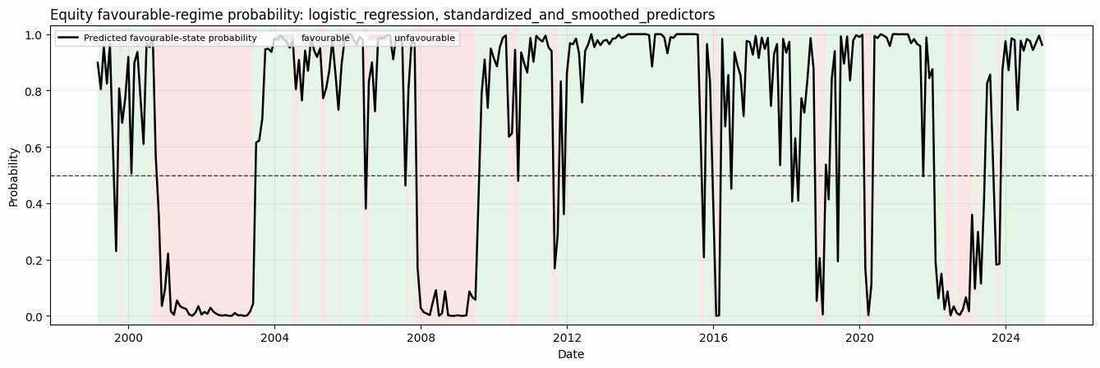

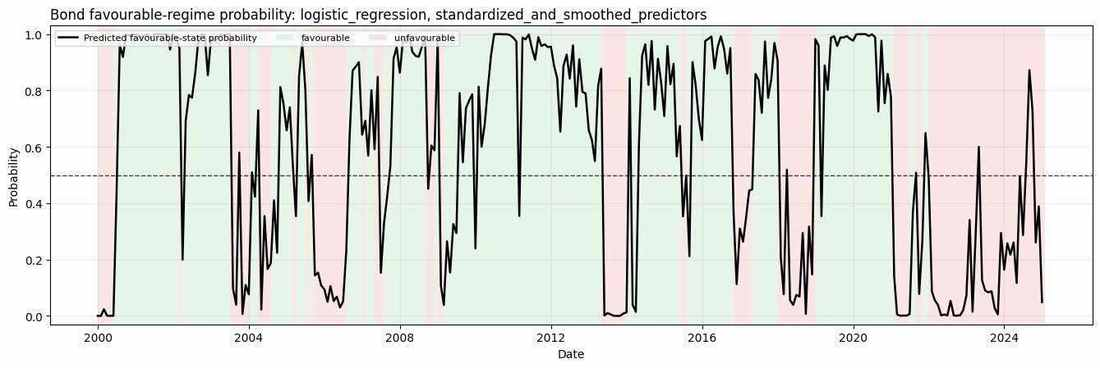

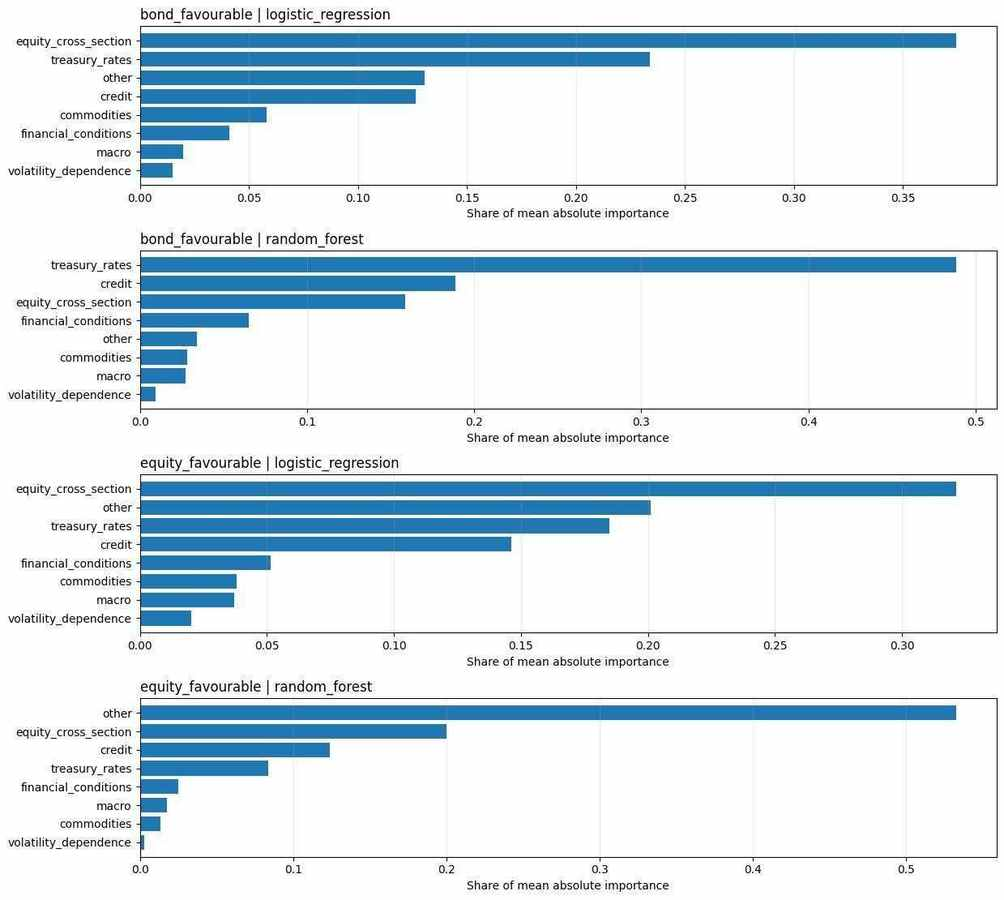

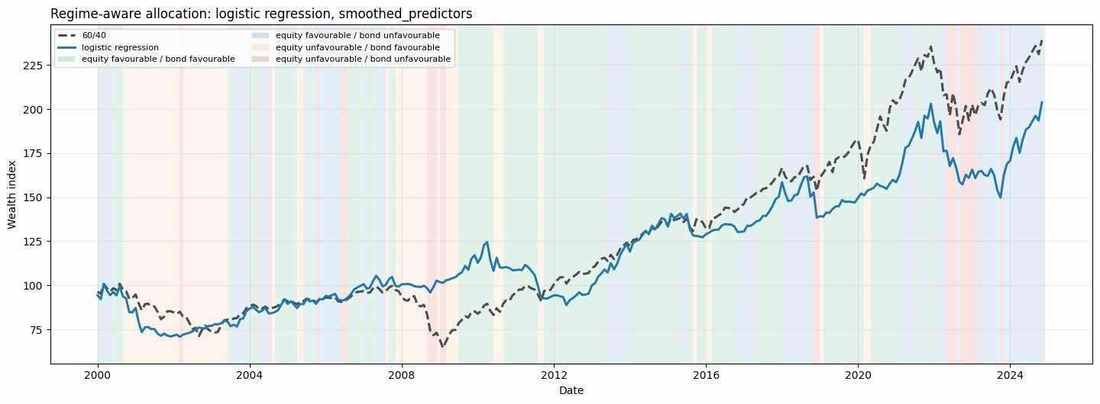

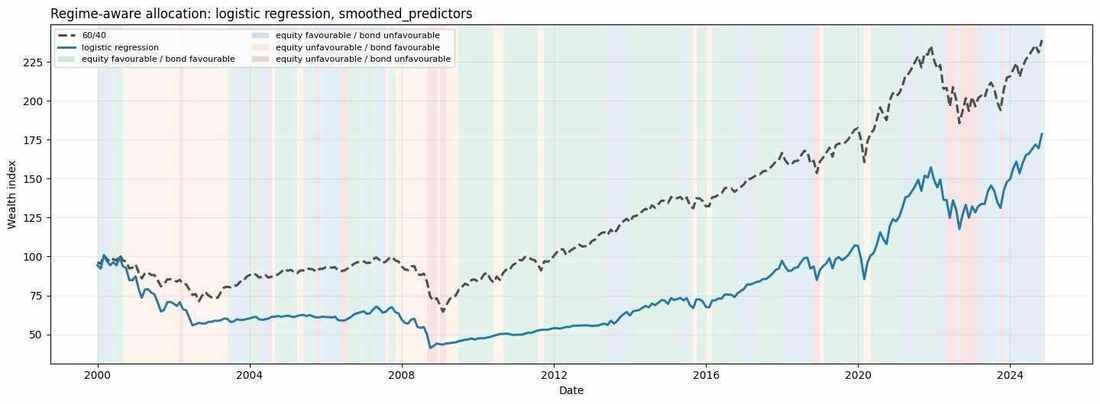

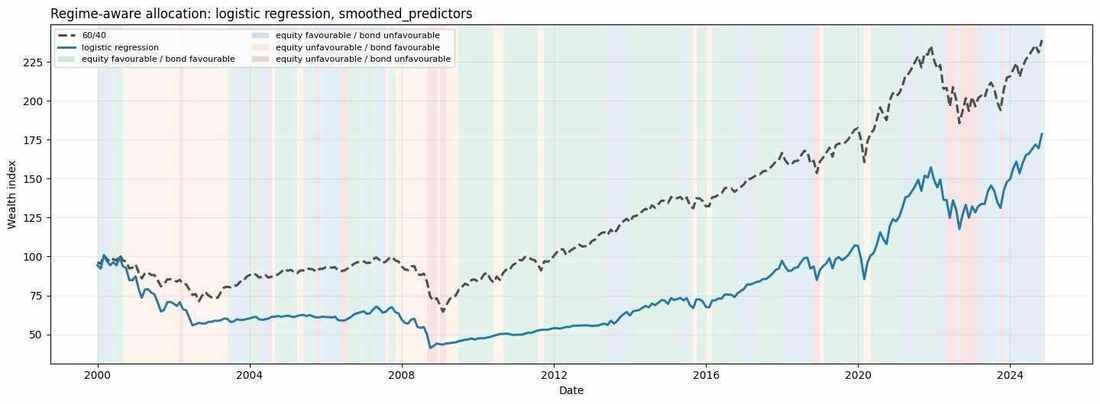

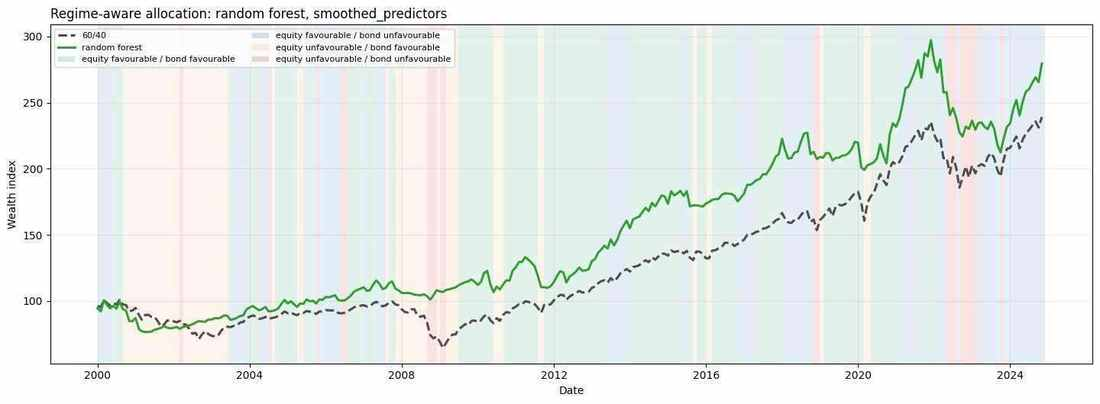

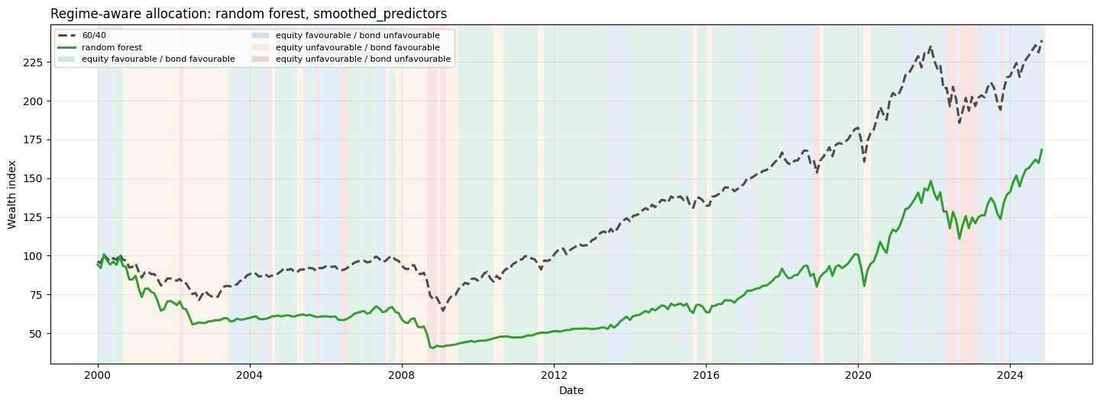

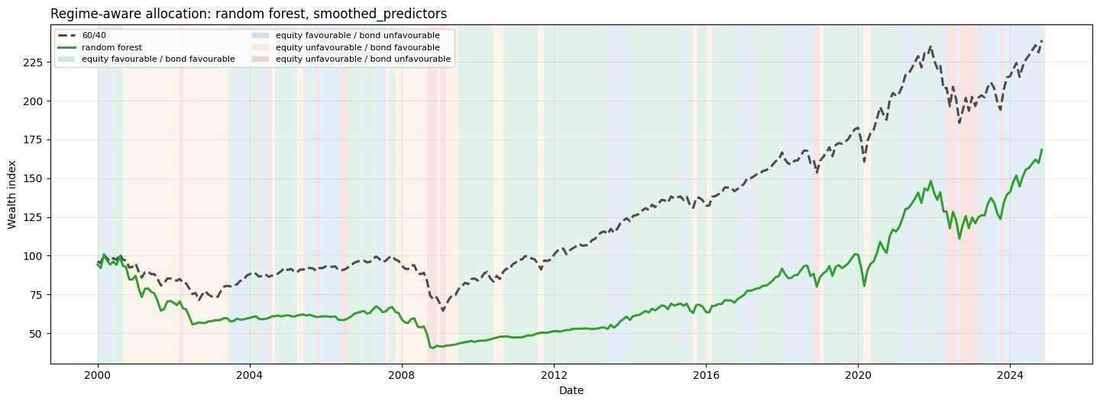

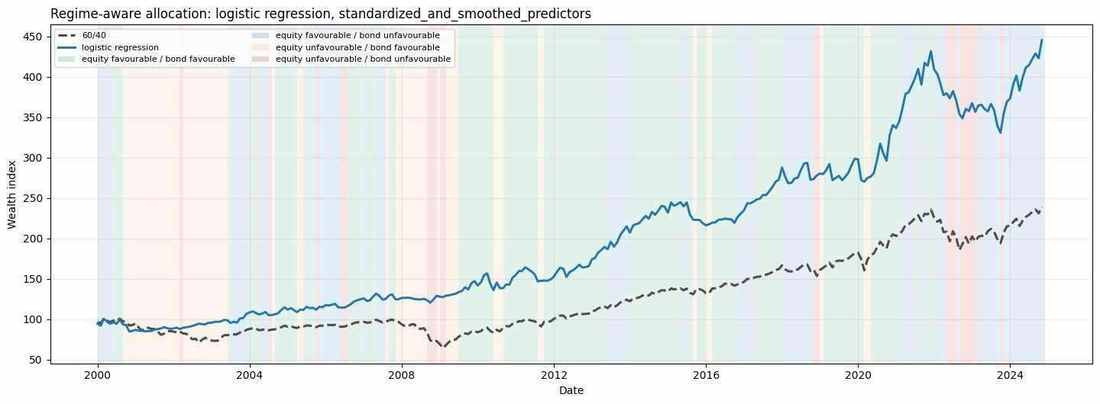

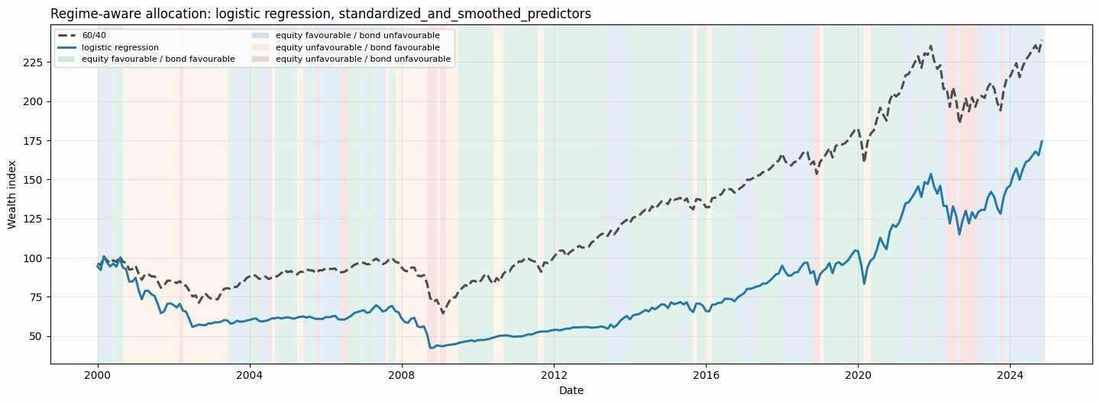

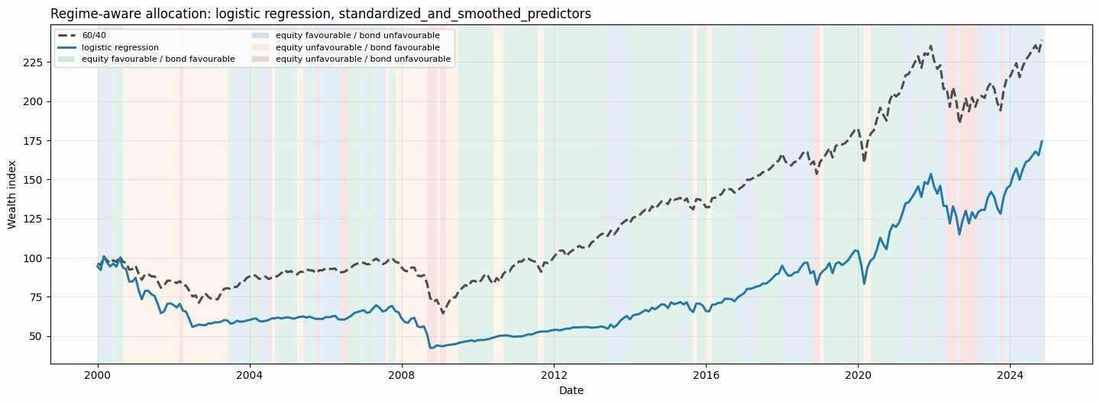

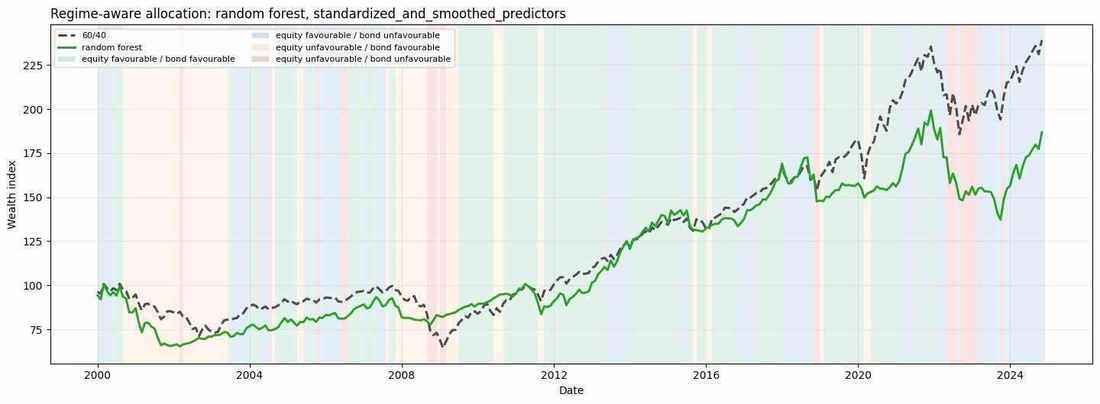

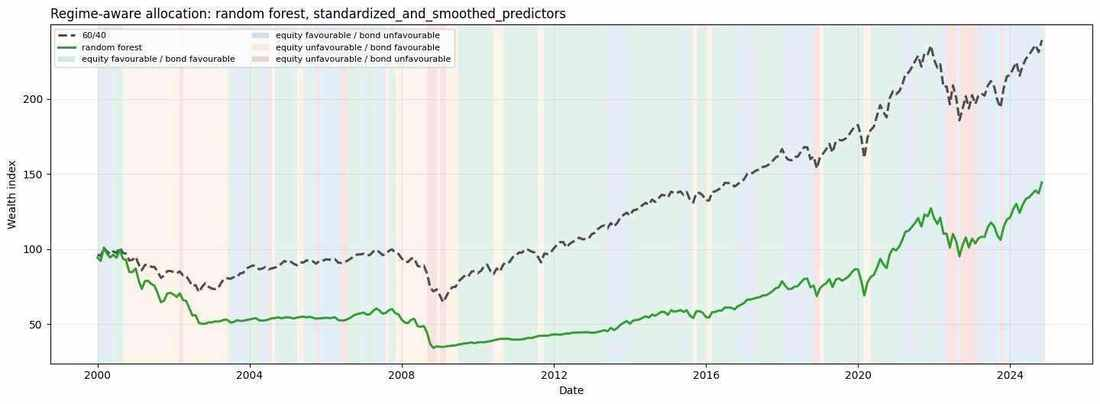

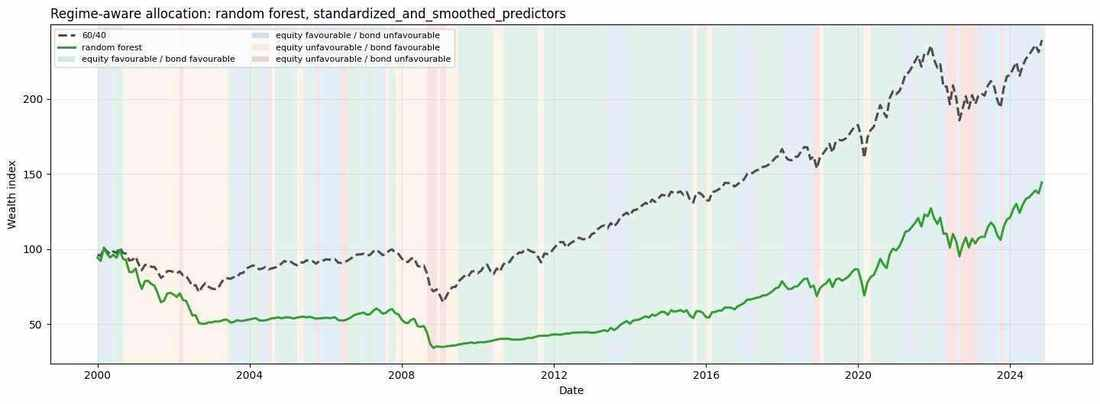

,feature_design,model,target,asset,n_oos_months,first_oos,last_oos,positive_share,prob_mean,prob_std,oos_auc,oos_balanced_accuracy,oos_brier,oos_log_loss,oos_net_sharpe,oos_buyhold_sharpe,oos_turnover
0,smoothed_predictors,logistic_regression,bond_favourable_h1,bond,301,1999-12-31,2024-12-31,0.634551,0.586381,0.387144,0.887720,0.824084,0.131350,0.466948,0.494085,0.545501,0.119601
1,smoothed_predictors,random_forest,bond_favourable_h1,bond,301,1999-12-31,2024-12-31,0.634551,0.567574,0.242522,0.860590,0.791028,0.146734,0.467285,0.611256,0.545501,0.102990
2,smoothed_predictors,logistic_regression,equity_favourable_h1,equity,311,1999-02-28,2024-12-31,0.726688,0.653206,0.384512,0.909266,0.839511,0.105029,0.352522,0.575722,0.359093,0.112540
3,smoothed_predictors,random_forest,equity_favourable_h1,equity,311,1999-02-28,2024-12-31,0.726688,0.620659,0.295439,0.895055,0.838053,0.115187,0.382208,0.570915,0.359093,0.080386
4,standardized_and_smoothed_predictors,logistic_regression,bond_favourable_h1,bond,301,1999-12-31,2024-12-31,0.634551,0.586630,0.375927,0.893289,0.821466,0.124914,0.464154,0.631401,0.545501,0.166113
5,standardized_and_smoothed_predictors,random_forest,bond_favourable_h1,bond,301,1999-12-31,2024-12-31,0.634551,0.580959,0.227336,0.879914,0.805355,0.140637,0.453487,0.607575,0.545501,0.119601
6,standardized_and_smoothed_predictors,logistic_regression,equity_favourable_h1,equity,311,1999-02-28,2024-12-31,0.726688,0.667581,0.390961,0.923686,0.856455,0.094673,0.329869,0.690459,0.359093,0.131833
7,standardized_and_smoothed_predictors,random_forest,equity_favourable_h1,equity,311,1999-02-28,2024-12-31,0.726688,0.626628,0.281006,0.903280,0.843935,0.112311,0.375440,0.526026,0.359093,0.093248


,feature_design,model,allocation_pair,budget_mode,target_vol,vol_gap,ann_return,ann_vol,sharpe,max_drawdown,cvar_1pct_monthly,final_wealth,ann_turnover,avg_w_eq,avg_w_bd,avg_w_cash,tcost_one_way,gamma,tau,prob_smooth_halflife,strategy
0,smoothed_predictors,logistic_regression,independent_equity_bond,cash_allowed,0.100000,0.000171,0.057925,0.099829,0.580245,-0.245889,-0.098933,372.783599,1.587692,0.647090,0.268027,0.084883,0.000500,0.500000,3.000000,0.000000,logistic_regression__smoothed_predictors__inde...
1,smoothed_predictors,logistic_regression,independent_equity_bond,cash_allowed,0.150000,0.003586,0.050983,0.153586,0.331952,-0.621704,-0.135986,264.310288,0.040134,1.000000,0.000000,0.000000,0.002500,0.250000,3.000000,6.000000,logistic_regression__smoothed_predictors__inde...
2,smoothed_predictors,logistic_regression,independent_equity_bond,cash_allowed,0.200000,0.046414,0.050983,0.153586,0.331952,-0.621704,-0.135986,264.310288,0.040134,1.000000,0.000000,0.000000,0.002500,0.250000,3.000000,6.000000,logistic_regression__smoothed_predictors__inde...
3,smoothed_predictors,logistic_regression,independent_equity_bond,cash_allowed,0.250000,0.096414,0.050983,0.153586,0.331952,-0.621704,-0.135986,264.310288,0.040134,1.000000,0.000000,0.000000,0.002500,0.250000,3.000000,6.000000,logistic_regression__smoothed_predictors__inde...
4,smoothed_predictors,logistic_regression,independent_equity_bond,cash_allowed,0.300000,0.146414,0.050983,0.153586,0.331952,-0.621704,-0.135986,264.310288,0.040134,1.000000,0.000000,0.000000,0.002500,0.250000,3.000000,6.000000,logistic_regression__smoothed_predictors__inde...
5,smoothed_predictors,logistic_regression,independent_equity_bond,fully_invested,0.100000,0.000147,0.033616,0.099853,0.336655,-0.296464,-0.092575,203.770314,1.146221,0.624548,0.375452,-0.000000,0.001000,0.500000,3.000000,0.000000,logistic_regression__smoothed_predictors__inde...
6,smoothed_predictors,logistic_regression,independent_equity_bond,fully_invested,0.150000,0.020621,0.031789,0.129379,0.245705,-0.590523,-0.130878,178.630908,0.353177,0.674916,0.325084,-0.000000,0.001000,0.250000,3.000000,6.000000,logistic_regression__smoothed_predictors__inde...
7,smoothed_predictors,logistic_regression,independent_equity_bond,fully_invested,0.200000,0.070621,0.031789,0.129379,0.245705,-0.590523,-0.130878,178.630908,0.353177,0.674916,0.325084,-0.000000,0.001000,0.250000,3.000000,6.000000,logistic_regression__smoothed_predictors__inde...
8,smoothed_predictors,logistic_regression,independent_equity_bond,fully_invested,0.250000,0.120621,0.031789,0.129379,0.245705,-0.590523,-0.130878,178.630908,0.353177,0.674916,0.325084,-0.000000,0.001000,0.250000,3.000000,6.000000,logistic_regression__smoothed_predictors__inde...
9,smoothed_predictors,logistic_regression,independent_equity_bond,fully_invested,0.300000,0.170621,0.031789,0.129379,0.245705,-0.590523,-0.130878,178.630908,0.353177,0.674916,0.325084,-0.000000,0.001000,0.250000,3.000000,6.000000,logistic_regression__smoothed_predictors__inde...


,feature_design,strategy,model,allocation_pair,budget_mode,n_months,ann_return,ann_vol,sharpe,max_drawdown,cvar_1pct_monthly,final_wealth,ann_turnover,avg_w_eq,avg_w_bd,avg_w_cash,tcost_one_way,gamma,tau,prob_smooth_halflife
0,smoothed_predictors,random_forest__smoothed_predictors__independen...,random_forest,independent_equity_bond,cash_allowed,299,0.031580,0.036025,0.876630,-0.062700,-0.031521,215.926390,1.436789,0.181070,0.596321,0.222609,0.000500,8.000000,0.000000,0.000000
1,smoothed_predictors,logistic_regression__smoothed_predictors__inde...,logistic_regression,independent_equity_bond,fully_invested,299,0.038667,0.051271,0.754165,-0.209512,-0.043043,253.278264,1.165485,0.243880,0.756120,-0.000000,0.000500,8.000000,1.000000,0.000000
2,standardized_and_smoothed_predictors,logistic_regression__standardized_and_smoothed...,logistic_regression,independent_equity_bond,cash_allowed,299,0.025587,0.027667,0.924831,-0.039702,-0.022500,187.273349,0.657391,0.136522,0.506355,0.357124,0.000500,12.000000,5.000000,0.000000
3,standardized_and_smoothed_predictors,logistic_regression__standardized_and_smoothed...,logistic_regression,independent_equity_bond,fully_invested,299,0.040173,0.051895,0.774126,-0.212559,-0.042671,262.725365,2.379130,0.267425,0.732575,-0.000000,0.000500,8.000000,0.000000,0.000000


In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, log_loss, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 800)
pd.set_option("display.width", 720)
pd.set_option("display.max_rows", 1200)
pd.set_option("display.float_format", lambda x: f"{x:0.6f}")

EPS = 1e-12
FINAL_MAJORITY_SCOPE = "all_models"
BOND_FEATURE_GROUP = "return_downside_sharpe_vol"

STUDENT_OUTPUT_DIR = ALLOCATION_OUTPUT_DIR
FIGURE_DIR = PROJECT_DIR / "paper" / "figs"
STUDENT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

STUDENT_FEATURE_DESIGNS = {
    "smoothed_predictors": "student columns ending in _z_smooth",
    "standardized_and_smoothed_predictors": "student columns ending in _z or _z_smooth",
}

STUDENT_MODELS = ["logistic_regression", "random_forest"]
MODEL_RANDOM_SEEDS = [101, 111, 121]
MODEL_MIN_TRAIN_MONTHS = 96
MODEL_VALIDATION_MONTHS = 36
MODEL_EVAL_THRESHOLD = 0.50

TRANSACTION_COST_ONE_WAY = 0.0005
MOMENT_SHRINKAGE_K = 36.0
WEIGHT_STEP = 0.02
STARTING_WEALTH = 100.0
MAX_EQUITY_WEIGHT = 1.0
MAX_BOND_WEIGHT = 1.0
MAX_TOTAL_RISKY_WEIGHT = 1.0

ALLOCATION_BUDGET_MODES = ["fully_invested", "cash_allowed"]
GAMMA_GRID = [0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0]
TAU_GRID = [0.0, 1.0, 3.0, 5.0]
TRANSACTION_COST_GRID = [0.0005, 0.0010, 0.0025, 0.0050]
PROBABILITY_SMOOTHING_HALFLIFE_GRID = [0, 3, 6]
TARGET_VOLATILITY_GRID = [0.10, 0.15, 0.20, 0.25, 0.30]
SELECTED_ALLOCATION_TARGET_VOLS = [0.10, 0.15, 0.20]

LOGISTIC_GRID = [
    {"model": "logistic_regression", "model_name": "logistic_l2_C0p03_balanced", "C": 0.03, "class_weight": "balanced"},
    {"model": "logistic_regression", "model_name": "logistic_l2_C0p05_balanced", "C": 0.05, "class_weight": "balanced"},
    {"model": "logistic_regression", "model_name": "logistic_l2_C0p10_balanced", "C": 0.10, "class_weight": "balanced"},
    {"model": "logistic_regression", "model_name": "logistic_l2_C0p25_balanced", "C": 0.25, "class_weight": "balanced"},
    {"model": "logistic_regression", "model_name": "logistic_l2_C0p50_balanced", "C": 0.50, "class_weight": "balanced"},
    {"model": "logistic_regression", "model_name": "logistic_l2_C1p00_balanced", "C": 1.00, "class_weight": "balanced"},
]

RANDOM_FOREST_GRID = [
    {"model": "random_forest", "model_name": "random_forest_d2_leaf10", "n_estimators": 500, "max_depth": 2, "min_samples_leaf": 10, "max_features": "sqrt", "class_weight": "balanced_subsample"},
    {"model": "random_forest", "model_name": "random_forest_d2_leaf20", "n_estimators": 500, "max_depth": 2, "min_samples_leaf": 20, "max_features": "sqrt", "class_weight": "balanced_subsample"},
    {"model": "random_forest", "model_name": "random_forest_d3_leaf10", "n_estimators": 500, "max_depth": 3, "min_samples_leaf": 10, "max_features": "sqrt", "class_weight": "balanced_subsample"},
    {"model": "random_forest", "model_name": "random_forest_d3_leaf20", "n_estimators": 500, "max_depth": 3, "min_samples_leaf": 20, "max_features": "sqrt", "class_weight": "balanced_subsample"},
    {"model": "random_forest", "model_name": "random_forest_d4_leaf20", "n_estimators": 500, "max_depth": 4, "min_samples_leaf": 20, "max_features": "sqrt", "class_weight": "balanced_subsample"},
]

MODEL_GRID = {
    "logistic_regression": LOGISTIC_GRID,
    "random_forest": RANDOM_FOREST_GRID,
}

TARGET_SPECS = [
    {
        "target": "equity_favourable",
        "asset": "equity",
        "feature_group": "return_sortino",
        "state_col": f"equity_return_sortino_{FINAL_MAJORITY_SCOPE}_state",
        "prob_col": f"equity_return_sortino_{FINAL_MAJORITY_SCOPE}_vote_prob",
        "strength_col": f"equity_return_sortino_{FINAL_MAJORITY_SCOPE}_vote_strength",
        "excess_col": f"equity_return_sortino_{FINAL_MAJORITY_SCOPE}_excess",
        "return_col_h1": "equity_ret_h1",
        "label": "Equity favourable state",
    },
    {
        "target": "bond_favourable",
        "asset": "bond",
        "feature_group": BOND_FEATURE_GROUP,
        "state_col": f"bond_{BOND_FEATURE_GROUP}_{FINAL_MAJORITY_SCOPE}_state",
        "prob_col": f"bond_{BOND_FEATURE_GROUP}_{FINAL_MAJORITY_SCOPE}_vote_prob",
        "strength_col": f"bond_{BOND_FEATURE_GROUP}_{FINAL_MAJORITY_SCOPE}_vote_strength",
        "excess_col": f"bond_{BOND_FEATURE_GROUP}_{FINAL_MAJORITY_SCOPE}_excess",
        "return_col_h1": "bond_ret_h1",
        "label": "Bond favourable state",
    },
]

ALLOCATION_PAIR = {
    "pair": "independent_equity_bond",
    "equity_target": "equity_favourable_h1",
    "bond_target": "bond_favourable_h1",
    "label": "Independent equity and bond favourable states",
}

LINE_COLORS = {
    "60/40": "#4d4d4d",
    "logistic_regression": "#1f77b4",
    "random_forest": "#2ca02c",
}

STATE_COLORS = {
    "both_favourable": "#2ca25f",
    "equity_favourable_only": "#3182bd",
    "bond_favourable_only": "#fdae6b",
    "both_unfavourable": "#de2d26",
}


def month_end(s):
    return pd.to_datetime(s, errors="coerce").dt.to_period("M").dt.to_timestamp("M")


def ann_return(x):
    x = pd.Series(x).dropna().astype(float)
    return float(12.0 * x.mean()) if len(x) else np.nan


def ann_vol(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 2:
        return np.nan
    sd = x.std(ddof=1)
    return float(np.sqrt(12.0) * sd) if np.isfinite(sd) else np.nan


def ann_sharpe(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 2:
        return np.nan
    sd = x.std(ddof=1)
    if not np.isfinite(sd) or sd <= EPS:
        return np.nan
    return float(np.sqrt(12.0) * x.mean() / sd)


def max_drawdown_from_returns(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    wealth = (1.0 + x).cumprod()
    peak = wealth.cummax()
    return float((wealth / peak - 1.0).min())


def cvar_left_tail(x, alpha=0.01):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    q = x.quantile(alpha)
    tail = x.loc[x <= q]
    return float(tail.mean()) if len(tail) else np.nan


def balanced_accuracy_binary(y_true, y_pred):
    y_true = pd.Series(y_true).astype(int).to_numpy()
    y_pred = pd.Series(y_pred).astype(int).to_numpy()
    if len(y_true) == 0:
        return np.nan
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp = cm[0, 0], cm[0, 1]
    fn, tp = cm[1, 0], cm[1, 1]
    r0 = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    r1 = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    vals = [v for v in [r0, r1] if np.isfinite(v)]
    return float(np.mean(vals)) if vals else np.nan


def classification_metrics(y_true, p_hat):
    y = pd.Series(y_true).reset_index(drop=True)
    p = pd.Series(p_hat).reset_index(drop=True)
    m = y.notna() & p.notna()
    y = y.loc[m].astype(int).to_numpy()
    p = p.loc[m].astype(float).clip(EPS, 1.0 - EPS).to_numpy()
    out = {"n": int(len(y)), "auc": np.nan, "accuracy": np.nan, "balanced_accuracy": np.nan, "brier": np.nan, "log_loss": np.nan}
    if len(y) == 0:
        return out
    pred = (p >= MODEL_EVAL_THRESHOLD).astype(int)
    out["accuracy"] = float(accuracy_score(y, pred))
    out["balanced_accuracy"] = balanced_accuracy_binary(y, pred)
    out["brier"] = float(brier_score_loss(y, p))
    if len(np.unique(y)) == 2:
        out["auc"] = float(roc_auc_score(y, p))
        out["log_loss"] = float(log_loss(y, p, labels=[0, 1]))
    return out


def good_state_signal(p_hat):
    return (np.asarray(p_hat, dtype=float) >= MODEL_EVAL_THRESHOLD).astype(float)


def timing_rule_metrics(asset_ret_h1, p_hat):
    x = pd.DataFrame({"ret": pd.Series(asset_ret_h1).astype(float).to_numpy(), "p_hat": np.asarray(p_hat, dtype=float)})
    x = x.replace([np.inf, -np.inf], np.nan).dropna()
    out = {"signal_share": np.nan, "turnover": np.nan, "net_sharpe": np.nan, "buyhold_sharpe": np.nan, "drawdown_improvement": np.nan, "vol_reduction": np.nan}
    if len(x) < 2:
        return out
    signal = pd.Series(good_state_signal(x["p_hat"]), index=x.index).astype(float)
    turnover = signal.diff().abs()
    if len(turnover):
        turnover.iloc[0] = signal.iloc[0]
    turnover = turnover.fillna(0.0)
    net = signal * x["ret"] - TRANSACTION_COST_ONE_WAY * turnover
    buyhold = x["ret"]
    net_sharpe = ann_sharpe(net)
    buyhold_sharpe = ann_sharpe(buyhold)
    net_dd = max_drawdown_from_returns(net)
    buyhold_dd = max_drawdown_from_returns(buyhold)
    net_vol = ann_vol(net)
    buyhold_vol = ann_vol(buyhold)
    out["signal_share"] = float(signal.mean())
    out["turnover"] = float(turnover.mean())
    out["net_sharpe"] = net_sharpe
    out["buyhold_sharpe"] = buyhold_sharpe
    out["drawdown_improvement"] = net_dd - buyhold_dd if np.isfinite(net_dd) and np.isfinite(buyhold_dd) else np.nan
    out["vol_reduction"] = buyhold_vol - net_vol if np.isfinite(net_vol) and np.isfinite(buyhold_vol) else np.nan
    return out


def safe_colname(x):
    s = str(x).replace(".", "p").replace("-", "m")
    return "".join(ch if ch.isalnum() or ch == "_" else "_" for ch in s).strip("_")


def feature_block_from_name(feature):
    s = str(feature).lower()
    if s.startswith("ff_") or "factor" in s or "small" in s or "value" in s or "industry" in s:
        return "equity_cross_section"
    if "tsy" in s or "bond" in s or "curve" in s or "dgs" in s or "rate" in s:
        return "treasury_rates"
    if "credit" in s or "baa" in s or "aaa" in s or "hy" in s or "ig" in s:
        return "credit"
    if "cmdty" in s or "commodity" in s:
        return "commodities"
    if "nfci" in s or "anfci" in s or "financial" in s:
        return "financial_conditions"
    if "vix" in s or "vol" in s or "rv_" in s or "rho" in s or "corr" in s or "lambda" in s:
        return "volatility_dependence"
    if "inflation" in s or "cfnai" in s or "sentiment" in s or "macro" in s:
        return "macro"
    return "other"


def student_feature_cols(df, feature_design):
    cols = []
    for c in df.columns:
        if c == "date":
            continue
        s = str(c)
        if feature_design == "smoothed_predictors" and s.endswith("_z_smooth"):
            cols.append(c)
        if feature_design == "standardized_and_smoothed_predictors" and (s.endswith("_z") or s.endswith("_z_smooth")):
            cols.append(c)
    return cols


def load_monthly_returns():
    candidate_paths = [
        RAW_DATA_DIR / "base_panel_monthly_through_2026_04.parquet",
        RAW_DATA_DIR / "base_panel_monthly_through_2025_12.parquet",
        RAW_DATA_DIR / "Monthly Base Panel through 2024-11.parquet",
        RAW_DATA_DIR / "base_panel_monthly.parquet",
    ]
    for p in candidate_paths:
        if p.exists():
            x = pd.read_parquet(p).copy()
            x["date"] = month_end(x["date"])
            for c in ["sprtrn_sp500", "agg_ret", "rf"]:
                if c not in x.columns:
                    x[c] = np.nan
                x[c] = pd.to_numeric(x[c], errors="coerce")
            out = x[["date", "sprtrn_sp500", "agg_ret", "rf"]].copy()
            out = out.dropna(subset=["date", "sprtrn_sp500", "agg_ret", "rf"]).sort_values("date").drop_duplicates("date", keep="last")
            out["equity_excess"] = out["sprtrn_sp500"] - out["rf"]
            out["bond_excess"] = out["agg_ret"] - out["rf"]
            out["equity_ret_h1"] = out["equity_excess"].shift(-1)
            out["bond_ret_h1"] = out["bond_excess"].shift(-1)
            out["return_source"] = str(p)
            return out.reset_index(drop=True)
    out = majority_vote_labels_wide[["date"]].copy()
    out["equity_excess"] = pd.to_numeric(majority_vote_labels_wide[TARGET_SPECS[0]["excess_col"]], errors="coerce")
    out["bond_excess"] = pd.to_numeric(majority_vote_labels_wide[TARGET_SPECS[1]["excess_col"]], errors="coerce")
    out["equity_ret_h1"] = out["equity_excess"].shift(-1)
    out["bond_ret_h1"] = out["bond_excess"].shift(-1)
    out["return_source"] = "teacher_label_excess_returns"
    return out


def build_prediction_targets_h1():
    h1 = majority_vote_prediction_targets_h1.copy()
    h1["date"] = month_end(h1["date"])
    h1 = h1.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)
    out = h1[["date"]].copy()
    for spec in TARGET_SPECS:
        target = spec["target"]
        out[f"{target}_h1"] = pd.to_numeric(h1[spec["state_col"]], errors="coerce")
        out[f"{target}_vote_prob_h1"] = pd.to_numeric(h1[spec["prob_col"]], errors="coerce")
        out[f"{target}_vote_strength_h1"] = pd.to_numeric(h1[spec["strength_col"]], errors="coerce")
    return out


def build_historical_label_return_panel(targets_h1, returns):
    out = targets_h1[["date", "equity_favourable_h1", "bond_favourable_h1"]].copy()
    out = out.merge(returns[["date", "equity_ret_h1", "bond_ret_h1"]], on="date", how="left")
    return out.sort_values("date").reset_index(drop=True)


def build_prediction_base(student_df, targets_h1, returns, feature_design):
    student = student_df.copy()
    student["date"] = month_end(student["date"])
    student = student.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)
    fcols = student_feature_cols(student, feature_design)
    target_cols = [f"{spec['target']}_h1" for spec in TARGET_SPECS]
    x = student.merge(targets_h1, on="date", how="inner")
    x = x.merge(returns[["date", "equity_excess", "bond_excess", "equity_ret_h1", "bond_ret_h1"]], on="date", how="left")
    x = x.dropna(subset=target_cols, how="all")
    x = x.loc[x[fcols].notna().any(axis=1)].copy()
    x["year"] = x["date"].dt.year
    return x.sort_values("date").reset_index(drop=True), fcols, target_cols


def target_meta(target_cols):
    meta = {}
    specs = {s["target"]: s for s in TARGET_SPECS}
    for c in target_cols:
        target = str(c).replace("_h1", "")
        spec = specs[target]
        meta[c] = {
            "target": target,
            "asset": spec["asset"],
            "feature_group": spec["feature_group"],
            "return_col_h1": spec["return_col_h1"],
            "label": spec["label"],
            "target_design": "next_month_majority_vote_label",
        }
    return meta


student_predictor_panel = student_ensemble_feature_panel.copy()
returns = load_monthly_returns()
prediction_targets_h1 = build_prediction_targets_h1()
historical_label_return_panel = build_historical_label_return_panel(prediction_targets_h1, returns)

prediction_base_by_feature_design = {}
feature_cols_by_feature_design = {}
for feature_design in STUDENT_FEATURE_DESIGNS:
    base, fcols, target_cols_h1 = build_prediction_base(student_predictor_panel, prediction_targets_h1, returns, feature_design)
    prediction_base_by_feature_design[feature_design] = base.copy()
    feature_cols_by_feature_design[feature_design] = list(fcols)

target_meta_h1 = target_meta(target_cols_h1)


def build_estimator(params, seed):
    if params["model"] == "logistic_regression":
        clf = LogisticRegression(
            penalty="l2",
            C=params["C"],
            class_weight=params["class_weight"],
            solver="lbfgs",
            max_iter=3000,
            random_state=seed,
        )
        return Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", clf)])
    clf = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        class_weight=params["class_weight"],
        random_state=seed,
        n_jobs=1,
        bootstrap=True,
    )
    return Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", clf)])


def probability_of_favourable_state(pipe, X):
    model = pipe.named_steps["model"]
    probs = pipe.predict_proba(X)
    classes = list(model.classes_)
    if 1 in classes:
        return probs[:, classes.index(1)]
    return np.zeros(len(X), dtype=float)


def choose_model(validation_table):
    x = validation_table.copy()
    x["auc_rank"] = x["val_auc"].fillna(-999.0)
    x["balanced_accuracy_rank"] = x["val_balanced_accuracy"].fillna(-999.0)
    x["brier_rank"] = x["val_brier"].fillna(999.0)
    x["net_sharpe_rank"] = x["val_timing_net_sharpe"].fillna(-999.0)
    x["drawdown_rank"] = x["val_timing_drawdown_improvement"].fillna(-999.0)
    x["vol_reduction_rank"] = x["val_timing_vol_reduction"].fillna(-999.0)
    x = x.sort_values(
        ["auc_rank", "balanced_accuracy_rank", "brier_rank", "net_sharpe_rank", "drawdown_rank", "vol_reduction_rank", "model_name"],
        ascending=[False, False, True, False, False, False, True],
    )
    return str(x.iloc[0]["model_name"])


def model_importance(pipe, feature_cols, model_name):
    model = pipe.named_steps["model"]
    if model_name == "logistic_regression" and hasattr(model, "coef_"):
        signed = np.asarray(model.coef_[0], dtype=float)
        importance = np.abs(signed)
    elif model_name == "random_forest" and hasattr(model, "feature_importances_"):
        importance = np.asarray(model.feature_importances_, dtype=float)
        signed = importance.copy()
    else:
        signed = np.zeros(len(feature_cols), dtype=float)
        importance = np.zeros(len(feature_cols), dtype=float)
    if len(signed) != len(feature_cols):
        signed = np.zeros(len(feature_cols), dtype=float)
    if len(importance) != len(feature_cols):
        importance = np.zeros(len(feature_cols), dtype=float)
    return signed, importance


def run_student_model(feature_design, model_name, df, feature_cols, target_cols, meta):
    grid = MODEL_GRID[model_name]
    result_rows = []
    selected_rows = []
    prediction_parts = []
    importance_parts = []
    seed_rows = []
    unique_dates = df["date"].sort_values().drop_duplicates().reset_index(drop=True)
    first_test_idx = MODEL_MIN_TRAIN_MONTHS + MODEL_VALIDATION_MONTHS

    for target_col in target_cols:
        asset = meta[target_col]["asset"]
        feature_group = meta[target_col]["feature_group"]
        ret_col = meta[target_col]["return_col_h1"]
        valid_dates = df.loc[df[target_col].notna(), "date"].sort_values().drop_duplicates().reset_index(drop=True)
        test_dates = valid_dates.iloc[first_test_idx:].tolist() if len(valid_dates) > first_test_idx else []
        target_prediction_parts = []

        for test_date in test_dates:
            date_index = unique_dates[unique_dates.eq(test_date)]
            if len(date_index) == 0:
                continue
            test_idx = int(date_index.index[0])
            train_end_idx = test_idx - MODEL_VALIDATION_MONTHS
            if train_end_idx < MODEL_MIN_TRAIN_MONTHS:
                continue

            train_dates = unique_dates.iloc[:train_end_idx]
            validation_dates = unique_dates.iloc[train_end_idx:test_idx]
            work_cols = ["date", "year", ret_col, target_col] + list(feature_cols)
            train = df.loc[df["date"].isin(train_dates), work_cols].dropna(subset=[target_col]).copy()
            validation = df.loc[df["date"].isin(validation_dates), work_cols].dropna(subset=[target_col]).copy()
            test = df.loc[df["date"].eq(test_date), work_cols].dropna(subset=[target_col]).copy()

            train = train.loc[train[feature_cols].notna().any(axis=1)].copy()
            validation = validation.loc[validation[feature_cols].notna().any(axis=1)].copy()
            test = test.loc[test[feature_cols].notna().any(axis=1)].copy()

            if len(train) < MODEL_MIN_TRAIN_MONTHS or len(validation) < MODEL_VALIDATION_MONTHS or test.empty:
                continue

            y_train = train[target_col].astype(int)
            y_validation = validation[target_col].astype(int)
            y_test = test[target_col].astype(int)
            if y_train.nunique() < 2:
                continue

            X_train = train[feature_cols]
            X_validation = validation[feature_cols]
            X_test = test[feature_cols]
            validation_rows = []

            for params in grid:
                seed_predictions = []
                for seed in MODEL_RANDOM_SEEDS:
                    pipe = build_estimator(params, seed)
                    pipe.fit(X_train, y_train)
                    p_seed = probability_of_favourable_state(pipe, X_validation)
                    seed_predictions.append(p_seed)
                    m_seed = classification_metrics(y_validation, p_seed)
                    seed_rows.append({
                        "feature_design": feature_design,
                        "model": model_name,
                        "target": target_col,
                        "asset": asset,
                        "feature_group": feature_group,
                        "test_date": test_date,
                        "model_name": params["model_name"],
                        "seed": int(seed),
                        "split": "validation",
                        "n": m_seed["n"],
                        "auc": m_seed["auc"],
                        "accuracy": m_seed["accuracy"],
                        "balanced_accuracy": m_seed["balanced_accuracy"],
                        "brier": m_seed["brier"],
                        "log_loss": m_seed["log_loss"],
                    })

                p_validation = np.mean(np.column_stack(seed_predictions), axis=1)
                m_validation = classification_metrics(y_validation, p_validation)
                timing = timing_rule_metrics(validation[ret_col].to_numpy(dtype=float), p_validation)
                row = {
                    "feature_design": feature_design,
                    "model": model_name,
                    "target": target_col,
                    "asset": asset,
                    "feature_group": feature_group,
                    "test_date": test_date,
                    "model_name": params["model_name"],
                    "threshold": float(MODEL_EVAL_THRESHOLD),
                    "n_train": int(len(train)),
                    "n_validation": int(len(validation)),
                    "n_test": int(len(test)),
                    "train_positive_share": float(y_train.mean()),
                    "validation_positive_share": float(y_validation.mean()),
                    "test_positive_share": float(y_test.mean()),
                    "val_auc": m_validation["auc"],
                    "val_accuracy": m_validation["accuracy"],
                    "val_balanced_accuracy": m_validation["balanced_accuracy"],
                    "val_brier": m_validation["brier"],
                    "val_log_loss": m_validation["log_loss"],
                    "val_timing_signal_share": timing["signal_share"],
                    "val_timing_turnover": timing["turnover"],
                    "val_timing_net_sharpe": timing["net_sharpe"],
                    "val_timing_buyhold_sharpe": timing["buyhold_sharpe"],
                    "val_timing_drawdown_improvement": timing["drawdown_improvement"],
                    "val_timing_vol_reduction": timing["vol_reduction"],
                }
                for k, v in params.items():
                    if k not in row:
                        row[k] = v
                validation_rows.append(row)

            validation_table = pd.DataFrame(validation_rows)
            if validation_table.empty:
                continue

            selected_name = choose_model(validation_table)
            selected_params = next(p for p in grid if p["model_name"] == selected_name)
            train_validation = pd.concat([train, validation], axis=0).sort_values("date").reset_index(drop=True)
            X_train_validation = train_validation[feature_cols]
            y_train_validation = train_validation[target_col].astype(int)
            if y_train_validation.nunique() < 2:
                continue

            test_seed_predictions = []
            importance_rows = []
            for seed in MODEL_RANDOM_SEEDS:
                pipe = build_estimator(selected_params, seed)
                pipe.fit(X_train_validation, y_train_validation)
                p_seed_test = probability_of_favourable_state(pipe, X_test)
                test_seed_predictions.append(p_seed_test)
                m_test_seed = classification_metrics(y_test, p_seed_test)
                seed_rows.append({
                    "feature_design": feature_design,
                    "model": model_name,
                    "target": target_col,
                    "asset": asset,
                    "feature_group": feature_group,
                    "test_date": test_date,
                    "model_name": selected_name,
                    "seed": int(seed),
                    "split": "test_selected_model",
                    "n": m_test_seed["n"],
                    "auc": m_test_seed["auc"],
                    "accuracy": m_test_seed["accuracy"],
                    "balanced_accuracy": m_test_seed["balanced_accuracy"],
                    "brier": m_test_seed["brier"],
                    "log_loss": m_test_seed["log_loss"],
                })
                signed, importance = model_importance(pipe, feature_cols, model_name)
                importance_rows.append(pd.DataFrame({
                    "feature_design": feature_design,
                    "model": model_name,
                    "target": target_col,
                    "asset": asset,
                    "feature_group": feature_group,
                    "test_date": test_date,
                    "selected_model": selected_name,
                    "seed": int(seed),
                    "feature": feature_cols,
                    "signed_importance": signed,
                    "abs_importance": np.abs(signed) if model_name == "logistic_regression" else importance,
                    "importance": importance,
                }))

            p_test = np.mean(np.column_stack(test_seed_predictions), axis=1)
            m_test = classification_metrics(y_test, p_test)
            signal = good_state_signal(p_test)

            for _, r in validation_table.iterrows():
                row = r.to_dict()
                selected = row["model_name"] == selected_name
                row["selected_model"] = bool(selected)
                row["test_auc"] = m_test["auc"] if selected else np.nan
                row["test_accuracy"] = m_test["accuracy"] if selected else np.nan
                row["test_balanced_accuracy"] = m_test["balanced_accuracy"] if selected else np.nan
                row["test_brier"] = m_test["brier"] if selected else np.nan
                row["test_log_loss"] = m_test["log_loss"] if selected else np.nan
                result_rows.append(row)
                if selected:
                    selected_rows.append(row)

            pred = test[["date", "year", target_col, ret_col]].copy().rename(columns={target_col: "y"})
            pred["p_hat"] = p_test
            pred["signal"] = signal
            pred["threshold"] = MODEL_EVAL_THRESHOLD
            pred["feature_design"] = feature_design
            pred["model"] = model_name
            pred["selected_model"] = selected_name
            pred["target"] = target_col
            pred["asset"] = asset
            pred["feature_group"] = feature_group
            pred["n_train_validation"] = int(len(train_validation))
            pred["train_start"] = train_validation["date"].min()
            pred["train_end"] = train_validation["date"].max()
            target_prediction_parts.append(pred)

            if importance_rows:
                importance_parts.append(pd.concat(importance_rows, axis=0, ignore_index=True))

        if target_prediction_parts:
            prediction_parts.append(pd.concat(target_prediction_parts, axis=0, ignore_index=True))

    result_table = pd.DataFrame(result_rows)
    selected_model_table = pd.DataFrame(selected_rows)
    prediction_panel = pd.concat(prediction_parts, axis=0, ignore_index=True).sort_values(["feature_design", "model", "target", "date"]).reset_index(drop=True) if prediction_parts else pd.DataFrame()
    feature_importance = pd.concat(importance_parts, axis=0, ignore_index=True) if importance_parts else pd.DataFrame()
    seed_diagnostics = pd.DataFrame(seed_rows)

    return result_table, selected_model_table, prediction_panel, feature_importance, seed_diagnostics


def summarize_student_predictions(prediction_panel, base_by_feature_design, meta):
    rows = []
    if prediction_panel.empty:
        return pd.DataFrame()
    for (feature_design, model_name, target_col), g in prediction_panel.groupby(["feature_design", "model", "target"], dropna=False):
        ret_col = meta[target_col]["return_col_h1"]
        base = base_by_feature_design[feature_design]
        x = g[["date", "y", "p_hat", "signal"]].merge(base[["date", ret_col]].drop_duplicates("date"), on="date", how="left")
        x = x.dropna(subset=["y", "p_hat"]).copy()
        if x.empty:
            continue
        metrics = classification_metrics(x["y"], x["p_hat"])
        signal = x["signal"].astype(float)
        turnover = signal.diff().abs()
        if len(turnover):
            turnover.iloc[0] = signal.iloc[0]
        turnover = turnover.fillna(0.0)
        gross = signal * x[ret_col].astype(float)
        net = gross - TRANSACTION_COST_ONE_WAY * turnover
        buyhold = x[ret_col].astype(float)
        net_sharpe = ann_sharpe(net)
        buyhold_sharpe = ann_sharpe(buyhold)
        net_dd = max_drawdown_from_returns(net)
        buyhold_dd = max_drawdown_from_returns(buyhold)
        net_vol = ann_vol(net)
        buyhold_vol = ann_vol(buyhold)
        rows.append({
            "feature_design": feature_design,
            "model": model_name,
            "target": target_col,
            "asset": meta[target_col]["asset"],
            "feature_group": meta[target_col]["feature_group"],
            "n_oos_months": int(len(x)),
            "first_oos": x["date"].min(),
            "last_oos": x["date"].max(),
            "positive_share": float(x["y"].mean()),
            "prob_mean": float(x["p_hat"].mean()),
            "prob_std": float(x["p_hat"].std(ddof=1)),
            "oos_auc": metrics["auc"],
            "oos_accuracy": metrics["accuracy"],
            "oos_balanced_accuracy": metrics["balanced_accuracy"],
            "oos_brier": metrics["brier"],
            "oos_log_loss": metrics["log_loss"],
            "oos_signal_share": float(signal.mean()),
            "oos_turnover": float(turnover.mean()),
            "oos_net_ann_return": ann_return(net),
            "oos_net_ann_vol": net_vol,
            "oos_net_sharpe": net_sharpe,
            "oos_net_max_drawdown": net_dd,
            "oos_buyhold_ann_return": ann_return(buyhold),
            "oos_buyhold_ann_vol": buyhold_vol,
            "oos_buyhold_sharpe": buyhold_sharpe,
            "oos_buyhold_max_drawdown": buyhold_dd,
            "oos_sharpe_lift_vs_buyhold": net_sharpe - buyhold_sharpe if np.isfinite(net_sharpe) and np.isfinite(buyhold_sharpe) else np.nan,
            "oos_drawdown_improvement_vs_buyhold": net_dd - buyhold_dd if np.isfinite(net_dd) and np.isfinite(buyhold_dd) else np.nan,
            "oos_vol_reduction_vs_buyhold": buyhold_vol - net_vol if np.isfinite(net_vol) and np.isfinite(buyhold_vol) else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["feature_design", "target", "model"]).reset_index(drop=True)


def summarize_student_feature_importance(feature_importance):
    if feature_importance.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    x = feature_importance.copy()
    x["feature_block"] = x["feature"].map(feature_block_from_name)
    x["rank_in_fit"] = x.groupby(["feature_design", "model", "target", "test_date", "seed"], dropna=False)["abs_importance"].rank(method="first", ascending=False)
    x["is_top10"] = x["rank_in_fit"].le(10)
    x["is_top20"] = x["rank_in_fit"].le(20)
    x["positive"] = x["signed_importance"].gt(0)
    x["negative"] = x["signed_importance"].lt(0)
    feature_summary = (
        x.groupby(["feature_design", "model", "target", "asset", "feature_group", "feature", "feature_block"], dropna=False)
        .agg(
            n_fits=("abs_importance", "count"),
            mean_signed_importance=("signed_importance", "mean"),
            mean_abs_importance=("abs_importance", "mean"),
            median_abs_importance=("abs_importance", "median"),
            importance_std=("abs_importance", "std"),
            positive_share=("positive", "mean"),
            negative_share=("negative", "mean"),
            top10_frequency=("is_top10", "mean"),
            top20_frequency=("is_top20", "mean"),
        )
        .reset_index()
    )
    feature_summary["sign_consistency"] = feature_summary[["positive_share", "negative_share"]].max(axis=1)
    feature_summary = feature_summary.sort_values(["feature_design", "model", "target", "mean_abs_importance"], ascending=[True, True, True, False]).reset_index(drop=True)
    block_summary = (
        feature_summary.groupby(["feature_design", "model", "target", "asset", "feature_group", "feature_block"], dropna=False)
        .agg(
            n_features=("feature", "nunique"),
            total_mean_abs_importance=("mean_abs_importance", "sum"),
            avg_mean_abs_importance=("mean_abs_importance", "mean"),
            max_mean_abs_importance=("mean_abs_importance", "max"),
            avg_top20_frequency=("top20_frequency", "mean"),
        )
        .reset_index()
    )
    block_summary["block_share_of_importance"] = block_summary.groupby(["feature_design", "model", "target"], dropna=False)["total_mean_abs_importance"].transform(lambda z: z / max(float(z.sum()), EPS))
    block_summary = block_summary.sort_values(["feature_design", "model", "target", "block_share_of_importance"], ascending=[True, True, True, False]).reset_index(drop=True)
    logit_coefficients = x.loc[x["model"].eq("logistic_regression")].copy()
    return feature_summary, block_summary, logit_coefficients


def build_pair_prediction_panel(prediction_panel, feature_design, model_name):
    x = prediction_panel.loc[prediction_panel["feature_design"].eq(feature_design) & prediction_panel["model"].eq(model_name)].copy()
    pair_id = ALLOCATION_PAIR["pair"]
    base = x[["date", "year"]].drop_duplicates().sort_values("date").reset_index(drop=True)
    wide = base.copy()
    mapping = [("equity", ALLOCATION_PAIR["equity_target"]), ("bond", ALLOCATION_PAIR["bond_target"])]
    for short, target_col in mapping:
        g = x.loc[x["target"].eq(target_col)].copy()
        if g.empty:
            continue
        h = g[["date", "y", "p_hat", "signal", "selected_model", "threshold"]].copy()
        h = h.rename(columns={
            "y": f"y_{short}_{pair_id}",
            "p_hat": f"p_{short}_{pair_id}",
            "signal": f"signal_{short}_{pair_id}",
            "selected_model": f"model_{short}_{pair_id}",
            "threshold": f"threshold_{short}_{pair_id}",
        })
        wide = wide.merge(h, on="date", how="left")
    wide["feature_design"] = feature_design
    wide["model"] = model_name
    wide["allocation_pair"] = pair_id
    return wide


def probability_mixture_moments(p1, moments):
    p1 = float(np.clip(p1, 0.0, 1.0))
    p0 = 1.0 - p1
    mu0 = moments[0]["mu"]
    mu1 = moments[1]["mu"]
    var0 = moments[0]["var"]
    var1 = moments[1]["var"]
    mu = p0 * mu0 + p1 * mu1
    second = p0 * (var0 + mu0 ** 2) + p1 * (var1 + mu1 ** 2)
    return float(mu), float(max(second - mu ** 2, 1e-6))


def initial_moments_from_pre_oos(historical_panel, first_prediction_date):
    pre = historical_panel.loc[historical_panel["date"].lt(first_prediction_date)].copy()
    z = pre[["equity_ret_h1", "bond_ret_h1"]].replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    mu_eq = float(z["equity_ret_h1"].mean()) if len(z) else 0.0
    mu_bd = float(z["bond_ret_h1"].mean()) if len(z) else 0.0
    var_eq = max(float(z["equity_ret_h1"].var(ddof=1)), 1e-6) if len(z) >= 2 else 1e-6
    var_bd = max(float(z["bond_ret_h1"].var(ddof=1)), 1e-6) if len(z) >= 2 else 1e-6
    rho = 0.0
    if len(z) >= 3:
        rho = float(z["equity_ret_h1"].corr(z["bond_ret_h1"]))
    rho = float(np.clip(rho if np.isfinite(rho) else 0.0, -0.95, 0.95))
    return {"eq": {"mu": mu_eq, "var": var_eq}, "bd": {"mu": mu_bd, "var": var_bd}, "rho": rho, "n_obs": int(len(z))}


def moment_dict_from_arrays(y, r, initial_mu, initial_var):
    y = np.asarray(y, dtype=float)
    r = np.asarray(r, dtype=float)
    valid = np.isfinite(y) & np.isfinite(r)
    out = {}
    for state in [0, 1]:
        rs = r[valid & (y == float(state))]
        n = int(len(rs))
        mu_raw = float(np.mean(rs)) if n > 0 else float(initial_mu)
        var_raw = float(np.var(rs, ddof=1)) if n >= 2 else float(initial_var)
        w = n / (n + MOMENT_SHRINKAGE_K) if (n + MOMENT_SHRINKAGE_K) > 0 else 0.0
        mu = w * mu_raw + (1.0 - w) * float(initial_mu)
        var = w * var_raw + (1.0 - w) * float(initial_var)
        out[state] = {"n": n, "weight": float(w), "mu": float(mu), "var": float(max(var, EPS)), "mu_raw": mu_raw, "var_raw": var_raw}
    return out


def corr_from_arrays(eq_ret, bd_ret, initial_rho):
    eq_ret = np.asarray(eq_ret, dtype=float)
    bd_ret = np.asarray(bd_ret, dtype=float)
    valid = np.isfinite(eq_ret) & np.isfinite(bd_ret)
    x = eq_ret[valid]
    y = bd_ret[valid]
    n = int(len(x))
    rho_emp = float(initial_rho)
    if n >= 3:
        rho_emp = float(np.corrcoef(x, y)[0, 1])
    rho_emp = rho_emp if np.isfinite(rho_emp) else float(initial_rho)
    w = n / (n + MOMENT_SHRINKAGE_K) if (n + MOMENT_SHRINKAGE_K) > 0 else 0.0
    rho = w * rho_emp + (1.0 - w) * float(initial_rho)
    return float(np.clip(rho, -0.999, 0.999)), n, float(w), rho_emp


def precompute_allocation_moments(panel, historical_panel, initial_moments):
    dates = pd.to_datetime(panel["date"], errors="coerce").dropna().sort_values().drop_duplicates().tolist()
    hist = historical_panel[["date", "equity_favourable_h1", "bond_favourable_h1", "equity_ret_h1", "bond_ret_h1"]].copy()
    hist["date"] = pd.to_datetime(hist["date"], errors="coerce")
    hist = hist.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
    h_dates = hist["date"].to_numpy(dtype="datetime64[ns]")
    eq_state = pd.to_numeric(hist["equity_favourable_h1"], errors="coerce").to_numpy(dtype=float)
    bd_state = pd.to_numeric(hist["bond_favourable_h1"], errors="coerce").to_numpy(dtype=float)
    eq_ret = pd.to_numeric(hist["equity_ret_h1"], errors="coerce").to_numpy(dtype=float)
    bd_ret = pd.to_numeric(hist["bond_ret_h1"], errors="coerce").to_numpy(dtype=float)
    out = {}
    for dt in dates:
        d64 = np.datetime64(pd.Timestamp(dt).to_datetime64())
        m = h_dates < d64
        eq_mom = moment_dict_from_arrays(eq_state[m], eq_ret[m], initial_moments["eq"]["mu"], initial_moments["eq"]["var"])
        bd_mom = moment_dict_from_arrays(bd_state[m], bd_ret[m], initial_moments["bd"]["mu"], initial_moments["bd"]["var"])
        rho, rho_n, rho_weight, rho_empirical = corr_from_arrays(eq_ret[m], bd_ret[m], initial_moments["rho"])
        out[pd.Timestamp(dt)] = {"eq_mom": eq_mom, "bd_mom": bd_mom, "rho": rho, "rho_n_obs": rho_n, "rho_weight": rho_weight, "rho_empirical": rho_empirical}
    return out


def smooth_probability(s, halflife):
    x = pd.to_numeric(pd.Series(s), errors="coerce").astype(float)
    if halflife is None or float(halflife) <= 0:
        return x
    return x.ewm(halflife=float(halflife), adjust=False, min_periods=1).mean()


def build_monthly_allocation_inputs(panel, moment_lookup, prob_halflife):
    pair_id = ALLOCATION_PAIR["pair"]
    cols = ["date", "equity_ret_h1", "bond_ret_h1", f"y_equity_{pair_id}", f"p_equity_{pair_id}", f"y_bond_{pair_id}", f"p_bond_{pair_id}"]
    x = panel[cols].copy().replace([np.inf, -np.inf], np.nan).sort_values("date").reset_index(drop=True)
    x["date"] = pd.to_datetime(x["date"], errors="coerce")
    x[f"p_equity_{pair_id}"] = smooth_probability(x[f"p_equity_{pair_id}"], prob_halflife)
    x[f"p_bond_{pair_id}"] = smooth_probability(x[f"p_bond_{pair_id}"], prob_halflife)
    rows = []
    for _, row in x.iterrows():
        date = pd.Timestamp(row["date"])
        if date not in moment_lookup:
            continue
        if not np.isfinite(row[f"p_equity_{pair_id}"]) or not np.isfinite(row[f"p_bond_{pair_id}"]):
            continue
        if not np.isfinite(row["equity_ret_h1"]) or not np.isfinite(row["bond_ret_h1"]):
            continue
        m = moment_lookup[date]
        mu_eq, var_eq = probability_mixture_moments(row[f"p_equity_{pair_id}"], m["eq_mom"])
        mu_bd, var_bd = probability_mixture_moments(row[f"p_bond_{pair_id}"], m["bd_mom"])
        sd_eq = np.sqrt(max(var_eq, 1e-8))
        sd_bd = np.sqrt(max(var_bd, 1e-8))
        rho = float(m["rho"])
        rows.append({
            "date": date,
            "p_eq": float(row[f"p_equity_{pair_id}"]),
            "p_bd": float(row[f"p_bond_{pair_id}"]),
            "mu_eq": float(mu_eq),
            "mu_bd": float(mu_bd),
            "sd_eq": float(sd_eq),
            "sd_bd": float(sd_bd),
            "rho": rho,
            "cov00": float(sd_eq ** 2),
            "cov01": float(rho * sd_eq * sd_bd),
            "cov11": float(sd_bd ** 2),
            "equity_ret_h1": float(row["equity_ret_h1"]),
            "bond_ret_h1": float(row["bond_ret_h1"]),
            "eq_n_state0": int(m["eq_mom"][0]["n"]),
            "eq_n_state1": int(m["eq_mom"][1]["n"]),
            "bd_n_state0": int(m["bd_mom"][0]["n"]),
            "bd_n_state1": int(m["bd_mom"][1]["n"]),
            "eq_weight_state0": float(m["eq_mom"][0]["weight"]),
            "eq_weight_state1": float(m["eq_mom"][1]["weight"]),
            "bd_weight_state0": float(m["bd_mom"][0]["weight"]),
            "bd_weight_state1": float(m["bd_mom"][1]["weight"]),
            "rho_n_obs": int(m["rho_n_obs"]),
            "rho_weight": float(m["rho_weight"]),
            "rho_empirical": float(m["rho_empirical"]),
        })
    return pd.DataFrame(rows)


def make_weight_grid(budget_mode):
    grid = np.arange(0.0, 1.0 + 0.5 * WEIGHT_STEP, WEIGHT_STEP)
    rows = []
    for w_eq in grid:
        for w_bd in grid:
            total = w_eq + w_bd
            keep = False
            if budget_mode == "fully_invested":
                keep = abs(total - 1.0) <= 0.5 * WEIGHT_STEP + 1e-10
            if budget_mode == "cash_allowed":
                keep = total <= MAX_TOTAL_RISKY_WEIGHT + EPS
            if keep and w_eq <= MAX_EQUITY_WEIGHT + EPS and w_bd <= MAX_BOND_WEIGHT + EPS:
                rows.append((float(w_eq), float(w_bd)))
    return np.asarray(rows, dtype=float)


WEIGHT_GRIDS = {mode: make_weight_grid(mode) for mode in ALLOCATION_BUDGET_MODES}


def allocation_param_frame(budget_mode, prob_halflife):
    rows = []
    for gamma in GAMMA_GRID:
        for tau in TAU_GRID:
            for tcost in TRANSACTION_COST_GRID:
                rows.append({"budget_mode": budget_mode, "gamma": float(gamma), "tau": float(tau), "tcost_one_way": float(tcost), "prob_smooth_halflife": float(prob_halflife)})
    return pd.DataFrame(rows)


def simulate_allocation_param_block(monthly_inputs, feature_design, model_name, budget_mode, prob_halflife):
    pair_id = ALLOCATION_PAIR["pair"]
    m = monthly_inputs.copy().sort_values("date").reset_index(drop=True)
    if m.empty:
        return pd.DataFrame()
    params = allocation_param_frame(budget_mode, prob_halflife)
    n_param = len(params)
    W = WEIGHT_GRIDS[budget_mode]
    W_eq = W[:, 0]
    W_bd = W[:, 1]
    gamma = params["gamma"].to_numpy(dtype=float)
    tau = params["tau"].to_numpy(dtype=float)
    tcost_one_way = params["tcost_one_way"].to_numpy(dtype=float)
    prev_w_eq = np.full(n_param, 0.60 if budget_mode == "fully_invested" else 0.0, dtype=float)
    prev_w_bd = np.full(n_param, 0.40 if budget_mode == "fully_invested" else 0.0, dtype=float)
    out_parts = []

    for _, row in m.iterrows():
        mu_eq = float(row["mu_eq"])
        mu_bd = float(row["mu_bd"])
        cov00 = float(row["cov00"])
        cov01 = float(row["cov01"])
        cov11 = float(row["cov11"])
        ret_term = W_eq * mu_eq + W_bd * mu_bd
        risk_term = cov00 * W_eq ** 2 + 2.0 * cov01 * W_eq * W_bd + cov11 * W_bd ** 2
        turnover = np.abs(W_eq[None, :] - prev_w_eq[:, None]) + np.abs(W_bd[None, :] - prev_w_bd[:, None])
        obj = ret_term[None, :] - gamma[:, None] * risk_term[None, :] - tau[:, None] * tcost_one_way[:, None] * turnover
        idx = np.nanargmax(obj, axis=1)
        w_eq = W_eq[idx]
        w_bd = W_bd[idx]
        w_cash = 1.0 - w_eq - w_bd
        selected_turnover = np.abs(w_eq - prev_w_eq) + np.abs(w_bd - prev_w_bd)
        selected_tcost = tcost_one_way * selected_turnover
        gross_ret = w_eq * float(row["equity_ret_h1"]) + w_bd * float(row["bond_ret_h1"])
        net_ret = gross_ret - selected_tcost
        selected_obj = obj[np.arange(n_param), idx]
        part = params.copy()
        part["feature_design"] = feature_design
        part["date"] = row["date"]
        part["model"] = model_name
        part["allocation_pair"] = pair_id
        part["p_eq"] = float(row["p_eq"])
        part["p_bd"] = float(row["p_bd"])
        part["mu_eq"] = mu_eq
        part["mu_bd"] = mu_bd
        part["sd_eq"] = float(row["sd_eq"])
        part["sd_bd"] = float(row["sd_bd"])
        part["rho"] = float(row["rho"])
        part["w_eq"] = w_eq
        part["w_bd"] = w_bd
        part["w_cash"] = w_cash
        part["turnover"] = selected_turnover
        part["tcost"] = selected_tcost
        part["equity_ret_h1"] = float(row["equity_ret_h1"])
        part["bond_ret_h1"] = float(row["bond_ret_h1"])
        part["strategy_gross_ret"] = gross_ret
        part["strategy_net_ret"] = net_ret
        part["objective"] = selected_obj
        part["shrink_k"] = float(MOMENT_SHRINKAGE_K)
        part["eq_n_state0"] = int(row["eq_n_state0"])
        part["eq_n_state1"] = int(row["eq_n_state1"])
        part["bd_n_state0"] = int(row["bd_n_state0"])
        part["bd_n_state1"] = int(row["bd_n_state1"])
        part["eq_weight_state0"] = float(row["eq_weight_state0"])
        part["eq_weight_state1"] = float(row["eq_weight_state1"])
        part["bd_weight_state0"] = float(row["bd_weight_state0"])
        part["bd_weight_state1"] = float(row["bd_weight_state1"])
        part["rho_n_obs"] = int(row["rho_n_obs"])
        part["rho_weight"] = float(row["rho_weight"])
        part["rho_empirical"] = float(row["rho_empirical"])
        part["strategy"] = (
            model_name
            + "__" + feature_design
            + "__" + pair_id
            + "__" + part["budget_mode"].astype(str)
            + "__g" + part["gamma"].map(safe_colname)
            + "__tau" + part["tau"].map(safe_colname)
            + "__c" + part["tcost_one_way"].map(safe_colname)
            + "__phl" + part["prob_smooth_halflife"].map(safe_colname)
        )
        out_parts.append(part)
        prev_w_eq = w_eq
        prev_w_bd = w_bd

    return pd.concat(out_parts, axis=0, ignore_index=True, sort=False) if out_parts else pd.DataFrame()


def build_6040_benchmark(date_index):
    bench = returns[["date", "equity_ret_h1", "bond_ret_h1"]].copy().dropna()
    bench["date"] = pd.to_datetime(bench["date"])
    bench = bench[bench["date"].isin(date_index)].copy().sort_values("date").reset_index(drop=True)
    bench["ret_60_40_gross"] = 0.60 * bench["equity_ret_h1"] + 0.40 * bench["bond_ret_h1"]
    turnover = np.zeros(len(bench), dtype=float)
    if len(bench) > 0:
        turnover[0] = 1.0
    for i in range(1, len(bench)):
        prev_eq_ret = float(bench.loc[i - 1, "equity_ret_h1"])
        prev_bd_ret = float(bench.loc[i - 1, "bond_ret_h1"])
        growth = 0.60 * (1.0 + prev_eq_ret) + 0.40 * (1.0 + prev_bd_ret)
        if np.isfinite(growth) and abs(growth) > EPS:
            drift_eq = 0.60 * (1.0 + prev_eq_ret) / growth
            drift_bd = 0.40 * (1.0 + prev_bd_ret) / growth
            turnover[i] = abs(0.60 - drift_eq) + abs(0.40 - drift_bd)
    bench["turnover_60_40"] = turnover
    bench["tcost_60_40"] = TRANSACTION_COST_ONE_WAY * bench["turnover_60_40"]
    bench["ret_60_40_net"] = bench["ret_60_40_gross"] - bench["tcost_60_40"]
    bench["wealth_60_40"] = STARTING_WEALTH * (1.0 + bench["ret_60_40_net"]).cumprod()
    return bench


def strategy_summary(ret, turnover, tcost_paid, w_eq, w_bd, w_cash, strategy, model_name, allocation_pair, feature_design, budget_mode, gamma, tau, tcost_one_way, prob_halflife):
    r = pd.Series(ret).dropna().astype(float)
    turnover = pd.Series(turnover).reindex(r.index).fillna(0.0).astype(float)
    tcost_paid = pd.Series(tcost_paid).reindex(r.index).fillna(0.0).astype(float)
    w_eq = pd.Series(w_eq).reindex(r.index).astype(float)
    w_bd = pd.Series(w_bd).reindex(r.index).astype(float)
    w_cash = pd.Series(w_cash).reindex(r.index).astype(float)
    wealth = STARTING_WEALTH * (1.0 + r).cumprod() if len(r) else pd.Series(dtype=float)
    return {
        "feature_design": feature_design,
        "strategy": strategy,
        "model": model_name,
        "allocation_pair": allocation_pair,
        "budget_mode": budget_mode,
        "n_months": int(len(r)),
        "first_date": r.index.min() if isinstance(r.index, pd.DatetimeIndex) and len(r) else pd.NaT,
        "last_date": r.index.max() if isinstance(r.index, pd.DatetimeIndex) and len(r) else pd.NaT,
        "ann_return": ann_return(r),
        "ann_vol": ann_vol(r),
        "sharpe": ann_sharpe(r),
        "max_drawdown": max_drawdown_from_returns(r),
        "cvar_1pct_monthly": cvar_left_tail(r),
        "final_wealth": float(wealth.iloc[-1]) if len(wealth) else np.nan,
        "avg_monthly_turnover": float(turnover.mean()) if len(turnover) else np.nan,
        "ann_turnover": float(12.0 * turnover.mean()) if len(turnover) else np.nan,
        "avg_tcost_paid_monthly": float(tcost_paid.mean()) if len(tcost_paid) else np.nan,
        "ann_tcost_drag": float(12.0 * tcost_paid.mean()) if len(tcost_paid) else np.nan,
        "avg_w_eq": float(w_eq.mean()) if len(w_eq) else np.nan,
        "avg_w_bd": float(w_bd.mean()) if len(w_bd) else np.nan,
        "avg_w_cash": float(w_cash.mean()) if len(w_cash) else np.nan,
        "gamma": float(gamma) if np.isfinite(gamma) else np.nan,
        "tau": float(tau) if np.isfinite(tau) else np.nan,
        "tcost_one_way": float(tcost_one_way) if np.isfinite(tcost_one_way) else np.nan,
        "prob_smooth_halflife": float(prob_halflife) if np.isfinite(prob_halflife) else np.nan,
        "shrink_k": float(MOMENT_SHRINKAGE_K),
    }


def summarize_allocation(results, benchmark, feature_design):
    rows = []
    if len(benchmark):
        b = benchmark.copy().set_index("date")
        rows.append(strategy_summary(
            ret=b["ret_60_40_net"],
            turnover=b["turnover_60_40"],
            tcost_paid=b["tcost_60_40"],
            w_eq=pd.Series(0.60, index=b.index),
            w_bd=pd.Series(0.40, index=b.index),
            w_cash=pd.Series(0.00, index=b.index),
            strategy="monthly_rebalanced_60_40",
            model_name="60/40",
            allocation_pair="benchmark",
            feature_design=feature_design,
            budget_mode="fully_invested",
            gamma=np.nan,
            tau=np.nan,
            tcost_one_way=np.nan,
            prob_halflife=np.nan,
        ))
    for strategy, g in results.groupby("strategy"):
        h = g.copy().sort_values("date").set_index("date")
        rows.append(strategy_summary(
            ret=h["strategy_net_ret"],
            turnover=h["turnover"],
            tcost_paid=h["tcost"],
            w_eq=h["w_eq"],
            w_bd=h["w_bd"],
            w_cash=h["w_cash"],
            strategy=strategy,
            model_name=str(h["model"].iloc[0]),
            allocation_pair=str(h["allocation_pair"].iloc[0]),
            feature_design=str(h["feature_design"].iloc[0]),
            budget_mode=str(h["budget_mode"].iloc[0]),
            gamma=float(h["gamma"].iloc[0]),
            tau=float(h["tau"].iloc[0]),
            tcost_one_way=float(h["tcost_one_way"].iloc[0]),
            prob_halflife=float(h["prob_smooth_halflife"].iloc[0]),
        ))
    return pd.DataFrame(rows).sort_values("sharpe", ascending=False).reset_index(drop=True)


def allocation_shrinkage_summary(results):
    if results.empty:
        return pd.DataFrame()
    return (
        results.groupby(["feature_design", "model", "allocation_pair", "budget_mode", "gamma", "tau", "tcost_one_way", "prob_smooth_halflife"], as_index=False)
        .agg(
            n_months=("date", "count"),
            first_date=("date", "min"),
            last_date=("date", "max"),
            shrink_k=("shrink_k", "first"),
            min_eq_n_state0=("eq_n_state0", "min"),
            min_eq_n_state1=("eq_n_state1", "min"),
            min_bd_n_state0=("bd_n_state0", "min"),
            min_bd_n_state1=("bd_n_state1", "min"),
            avg_eq_weight_state0=("eq_weight_state0", "mean"),
            avg_eq_weight_state1=("eq_weight_state1", "mean"),
            avg_bd_weight_state0=("bd_weight_state0", "mean"),
            avg_bd_weight_state1=("bd_weight_state1", "mean"),
            avg_rho_weight=("rho_weight", "mean"),
            avg_monthly_turnover=("turnover", "mean"),
            ann_turnover=("turnover", lambda x: 12.0 * float(pd.Series(x).mean())),
        )
        .sort_values(["feature_design", "allocation_pair", "budget_mode", "model", "gamma", "tau", "tcost_one_way", "prob_smooth_halflife"])
        .reset_index(drop=True)
    )


def select_by_target_vol(summary):
    x = summary.loc[summary["model"].isin(STUDENT_MODELS)].copy()
    rows = []
    for keys, g in x.groupby(["feature_design", "model", "allocation_pair", "budget_mode"], dropna=False):
        for target_vol in TARGET_VOLATILITY_GRID:
            h = g.copy()
            h["target_vol"] = float(target_vol)
            h["vol_gap"] = (h["ann_vol"] - float(target_vol)).abs()
            h = h.sort_values(["vol_gap", "sharpe", "ann_return"], ascending=[True, False, False])
            if len(h):
                rows.append(h.iloc[0].to_dict())
    return pd.DataFrame(rows).sort_values(["feature_design", "model", "allocation_pair", "budget_mode", "target_vol"]).reset_index(drop=True) if rows else pd.DataFrame()


def gamma_vol_map(summary):
    x = summary.loc[summary["model"].isin(STUDENT_MODELS)].copy()
    if x.empty:
        return pd.DataFrame()
    return (
        x.groupby(["feature_design", "model", "allocation_pair", "budget_mode", "gamma"], dropna=False)
        .agg(
            median_ann_vol=("ann_vol", "median"),
            min_ann_vol=("ann_vol", "min"),
            max_ann_vol=("ann_vol", "max"),
            median_avg_w_eq=("avg_w_eq", "median"),
            median_ann_turnover=("ann_turnover", "median"),
            best_sharpe=("sharpe", "max"),
        )
        .reset_index()
        .sort_values(["feature_design", "allocation_pair", "budget_mode", "model", "gamma"])
    )


def turnover_cost_summary(summary):
    x = summary.loc[summary["model"].isin(STUDENT_MODELS)].copy()
    if x.empty:
        return pd.DataFrame()
    return (
        x.groupby(["feature_design", "model", "allocation_pair", "budget_mode", "tau", "tcost_one_way", "prob_smooth_halflife"], dropna=False)
        .agg(
            n_strategies=("strategy", "count"),
            median_ann_turnover=("ann_turnover", "median"),
            median_tcost_drag=("ann_tcost_drag", "median"),
            median_ann_vol=("ann_vol", "median"),
            median_avg_w_eq=("avg_w_eq", "median"),
            best_sharpe=("sharpe", "max"),
        )
        .reset_index()
        .sort_values(["feature_design", "allocation_pair", "budget_mode", "model", "tau", "tcost_one_way", "prob_smooth_halflife"])
    )


def run_allocation_for_model(feature_design, model_name, pair_panel):
    panel = pair_panel.copy()
    panel["date"] = pd.to_datetime(panel["date"])
    panel = panel.merge(returns[["date", "equity_ret_h1", "bond_ret_h1"]], on="date", how="left")
    first_prediction_date = panel["date"].dropna().min()
    initial_moments = initial_moments_from_pre_oos(historical_label_return_panel, first_prediction_date)
    moment_lookup = precompute_allocation_moments(panel, historical_label_return_panel, initial_moments)
    result_parts = []
    for prob_halflife in PROBABILITY_SMOOTHING_HALFLIFE_GRID:
        monthly_inputs = build_monthly_allocation_inputs(panel, moment_lookup, prob_halflife)
        for budget_mode in ALLOCATION_BUDGET_MODES:
            result_parts.append(simulate_allocation_param_block(monthly_inputs, feature_design, model_name, budget_mode, prob_halflife))
    results = pd.concat([x for x in result_parts if len(x)], axis=0, ignore_index=True, sort=False) if result_parts else pd.DataFrame()
    common_dates = sorted(set(results["date"].dropna().tolist())) if len(results) else []
    benchmark = build_6040_benchmark(common_dates)
    if len(results) and len(benchmark):
        results = results[results["date"].isin(benchmark["date"])].copy()
        results["wealth"] = results.groupby("strategy")["strategy_net_ret"].transform(lambda r: STARTING_WEALTH * (1.0 + r).cumprod())
    summary = summarize_allocation(results, benchmark, feature_design)
    shrinkage = allocation_shrinkage_summary(results)
    return results, summary, shrinkage, benchmark, initial_moments


student_result_parts = []
student_selected_model_parts = []
student_prediction_parts = []
student_importance_parts = []
student_seed_parts = []

for feature_design in STUDENT_FEATURE_DESIGNS:
    prediction_base = prediction_base_by_feature_design[feature_design]
    feature_cols = feature_cols_by_feature_design[feature_design]
    for model_name in STUDENT_MODELS:
        result_table_part, selected_model_part, prediction_part, importance_part, seed_part = run_student_model(
            feature_design=feature_design,
            model_name=model_name,
            df=prediction_base,
            feature_cols=feature_cols,
            target_cols=target_cols_h1,
            meta=target_meta_h1,
        )
        student_result_parts.append(result_table_part)
        student_selected_model_parts.append(selected_model_part)
        student_prediction_parts.append(prediction_part)
        student_importance_parts.append(importance_part)
        student_seed_parts.append(seed_part)

student_result_table = pd.concat(student_result_parts, axis=0, ignore_index=True, sort=False).sort_values(["feature_design", "model", "target", "test_date", "model_name"]).reset_index(drop=True)
student_selected_model_table = pd.concat(student_selected_model_parts, axis=0, ignore_index=True, sort=False).sort_values(["feature_design", "model", "target", "test_date"]).reset_index(drop=True)
student_oos_prediction_panel_long = pd.concat(student_prediction_parts, axis=0, ignore_index=True, sort=False).sort_values(["feature_design", "model", "target", "date"]).reset_index(drop=True)
student_feature_importance_long = pd.concat(student_importance_parts, axis=0, ignore_index=True, sort=False).sort_values(["feature_design", "model", "target", "test_date", "seed", "feature"]).reset_index(drop=True)
student_seed_diagnostics = pd.concat(student_seed_parts, axis=0, ignore_index=True, sort=False).sort_values(["feature_design", "model", "target", "test_date", "model_name", "seed", "split"]).reset_index(drop=True)
student_forecast_summary = summarize_student_predictions(student_oos_prediction_panel_long, prediction_base_by_feature_design, target_meta_h1)
student_feature_importance_summary, student_feature_block_importance_summary, student_logit_coefficients_long = summarize_student_feature_importance(student_feature_importance_long)
student_feature_importance_top = (
    student_feature_importance_summary
    .sort_values(["feature_design", "model", "target", "mean_abs_importance"], ascending=[True, True, True, False])
    .groupby(["feature_design", "model", "target"], as_index=False)
    .head(30)
    .reset_index(drop=True)
    if len(student_feature_importance_summary) else pd.DataFrame()
)

student_prediction_panels_by_model_pair = {}
allocation_result_parts = []
allocation_summary_parts = []
allocation_shrinkage_parts = []
allocation_benchmarks = {}
allocation_initial_moments = {}

for feature_design in STUDENT_FEATURE_DESIGNS:
    for model_name in STUDENT_MODELS:
        pair_panel = build_pair_prediction_panel(student_oos_prediction_panel_long, feature_design, model_name)
        student_prediction_panels_by_model_pair[(feature_design, model_name, ALLOCATION_PAIR["pair"])] = pair_panel.copy()
        results, summary, shrinkage, benchmark, initial_moments = run_allocation_for_model(feature_design, model_name, pair_panel)
        allocation_result_parts.append(results)
        allocation_summary_parts.append(summary)
        allocation_shrinkage_parts.append(shrinkage)
        allocation_benchmarks[(feature_design, model_name, ALLOCATION_PAIR["pair"])] = benchmark
        allocation_initial_moments[(feature_design, model_name, ALLOCATION_PAIR["pair"])] = initial_moments

allocation_results_long = pd.concat(allocation_result_parts, axis=0, ignore_index=True, sort=False).sort_values(["feature_design", "model", "allocation_pair", "budget_mode", "gamma", "tau", "tcost_one_way", "prob_smooth_halflife", "date"]).reset_index(drop=True)
allocation_strategy_summary = pd.concat(allocation_summary_parts, axis=0, ignore_index=True, sort=False).sort_values(["feature_design", "allocation_pair", "budget_mode", "sharpe"], ascending=[True, True, True, False]).reset_index(drop=True)
allocation_moment_shrinkage_summary = pd.concat(allocation_shrinkage_parts, axis=0, ignore_index=True, sort=False).sort_values(["feature_design", "allocation_pair", "budget_mode", "model", "gamma", "tau", "tcost_one_way", "prob_smooth_halflife"]).reset_index(drop=True)
allocation_target_vol_selection = select_by_target_vol(allocation_strategy_summary)
allocation_gamma_vol_map = gamma_vol_map(allocation_strategy_summary)
allocation_turnover_cost_summary = turnover_cost_summary(allocation_strategy_summary)


def contiguous_spans(mask_series):
    mask_series = mask_series.fillna(False).astype(bool)
    spans = []
    start = None
    prev_date = None
    for dt, val in zip(mask_series.index, mask_series.values):
        if val and start is None:
            start = dt
        if (not val) and start is not None:
            spans.append((start, prev_date))
            start = None
        prev_date = dt
    if start is not None:
        spans.append((start, prev_date))
    return spans


def add_binary_label_shading(ax, data):
    g = data.copy().sort_values("date")
    g["date"] = pd.to_datetime(g["date"])
    for state, color, label in [(1.0, "#b7e4bd", "favourable"), (0.0, "#f5b5b5", "unfavourable")]:
        spans = contiguous_spans(pd.Series(g["y"].eq(state).values, index=g["date"]))
        for start, end in spans:
            ax.axvspan(start, end + pd.offsets.MonthEnd(1), color=color, alpha=0.35, lw=0, zorder=0)
    return [Patch(facecolor="#b7e4bd", edgecolor="none", alpha=0.35, label="favourable"), Patch(facecolor="#f5b5b5", edgecolor="none", alpha=0.35, label="unfavourable")]


def best_probability_path(target_col):
    rows = student_forecast_summary.loc[student_forecast_summary["target"].eq(target_col)].copy()
    rows = rows.sort_values(["oos_auc", "oos_balanced_accuracy", "oos_brier"], ascending=[False, False, True])
    if rows.empty:
        return pd.DataFrame(), {}
    row = rows.iloc[0].to_dict()
    g = student_oos_prediction_panel_long.loc[
        student_oos_prediction_panel_long["target"].eq(target_col)
        & student_oos_prediction_panel_long["feature_design"].eq(row["feature_design"])
        & student_oos_prediction_panel_long["model"].eq(row["model"])
    ].copy()
    return g.sort_values("date").reset_index(drop=True), row


def plot_probability_path(target_col, filename, title):
    data, selected = best_probability_path(target_col)
    if data.empty:
        return None
    fig, ax = plt.subplots(figsize=(13.5, 4.6))
    shade_handles = add_binary_label_shading(ax, data)
    ax.plot(data["date"], data["p_hat"], color="black", lw=1.8, label="Predicted favourable-state probability", zorder=3)
    ax.axhline(MODEL_EVAL_THRESHOLD, color="black", linestyle="--", lw=1.0, alpha=0.75)
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(f"{title}: {selected.get('model', '')}, {selected.get('feature_design', '')}", loc="left")
    ax.set_xlabel("Date")
    ax.set_ylabel("Probability")
    ax.grid(True, alpha=0.25)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + shade_handles, labels + [h.get_label() for h in shade_handles], loc="upper left", ncol=3, fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def plot_feature_block_importance():
    x = student_feature_block_importance_summary.copy()
    x = x.loc[x["feature_design"].eq("standardized_and_smoothed_predictors")].copy()
    x = x.sort_values(["target", "model", "block_share_of_importance"], ascending=[True, True, False])
    if x.empty:
        return None
    top = x.groupby(["target", "model"], as_index=False).head(10).reset_index(drop=True)
    top["panel"] = top["target"].str.replace("_h1", "") + " | " + top["model"]
    panels = list(top["panel"].drop_duplicates())
    fig, axes = plt.subplots(len(panels), 1, figsize=(12.5, max(4.0, 2.8 * len(panels))))
    axes = np.atleast_1d(axes)
    for ax, panel in zip(axes, panels):
        h = top.loc[top["panel"].eq(panel)].sort_values("block_share_of_importance", ascending=True)
        ax.barh(h["feature_block"], h["block_share_of_importance"])
        ax.set_title(panel, loc="left")
        ax.set_xlabel("Share of mean absolute importance")
        ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "feature_block_importance.jpg", dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def state_background(date_index):
    bg = historical_label_return_panel[["date", "equity_favourable_h1", "bond_favourable_h1"]].copy()
    bg["date"] = pd.to_datetime(bg["date"])
    bg = bg[bg["date"].isin(date_index)].sort_values("date").reset_index(drop=True)
    bg["state_background"] = "missing"
    bg.loc[bg["equity_favourable_h1"].eq(1.0) & bg["bond_favourable_h1"].eq(1.0), "state_background"] = "both_favourable"
    bg.loc[bg["equity_favourable_h1"].eq(1.0) & bg["bond_favourable_h1"].eq(0.0), "state_background"] = "equity_favourable_only"
    bg.loc[bg["equity_favourable_h1"].eq(0.0) & bg["bond_favourable_h1"].eq(1.0), "state_background"] = "bond_favourable_only"
    bg.loc[bg["equity_favourable_h1"].eq(0.0) & bg["bond_favourable_h1"].eq(0.0), "state_background"] = "both_unfavourable"
    return bg


def add_stock_bond_state_spans(ax, bg):
    specs = [
        ("both_favourable", "equity favourable / bond favourable"),
        ("equity_favourable_only", "equity favourable / bond unfavourable"),
        ("bond_favourable_only", "equity unfavourable / bond favourable"),
        ("both_unfavourable", "equity unfavourable / bond unfavourable"),
    ]
    handles = []
    for state, label in specs:
        spans = contiguous_spans(pd.Series(bg["state_background"].eq(state).values, index=bg["date"]))
        for start, end in spans:
            ax.axvspan(start, end + pd.offsets.MonthEnd(1), color=STATE_COLORS[state], alpha=0.13, lw=0, zorder=0)
        handles.append(Patch(facecolor=STATE_COLORS[state], edgecolor="none", alpha=0.22, label=label))
    return handles


def plot_selected_allocation(row, filename):
    strategy = row["strategy"]
    feature_design = row["feature_design"]
    model_name = row["model"]
    g = allocation_results_long.loc[allocation_results_long["strategy"].eq(strategy)].copy().sort_values("date")
    benchmark = allocation_benchmarks[(feature_design, model_name, ALLOCATION_PAIR["pair"])]
    if g.empty or benchmark.empty:
        return None
    fig, ax = plt.subplots(figsize=(14.5, 5.4))
    ax.plot(benchmark["date"], benchmark["wealth_60_40"], color=LINE_COLORS["60/40"], linestyle="--", lw=2.2, label="60/40", zorder=3)
    ax.plot(g["date"], g["wealth"], color=LINE_COLORS.get(model_name, None), lw=2.1, label=model_name.replace("_", " "), zorder=4)
    bg = state_background(benchmark["date"])
    state_handles = add_stock_bond_state_spans(ax, bg)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + state_handles, labels + [h.get_label() for h in state_handles], loc="upper left", ncol=2, fontsize=8, frameon=True)
    ax.set_title(f"Regime-aware allocation: {model_name.replace('_', ' ')}, {feature_design}", loc="left")
    ax.set_xlabel("Date")
    ax.set_ylabel("Wealth index")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


plot_probability_path("equity_favourable_h1", "equity_prediction_probabilities.jpg", "Equity favourable-regime probability")
plot_probability_path("bond_favourable_h1", "bond_prediction_probabilities.jpg", "Bond favourable-regime probability")
plot_feature_block_importance()

selected_allocation_plots = allocation_target_vol_selection.loc[
    allocation_target_vol_selection["budget_mode"].eq("fully_invested")
    & allocation_target_vol_selection["target_vol"].isin(SELECTED_ALLOCATION_TARGET_VOLS)
].copy()
selected_allocation_plots = selected_allocation_plots.sort_values(["feature_design", "model", "target_vol"]).head(12)
for _, row in selected_allocation_plots.iterrows():
    file_name = (
        "allocation_"
        + safe_colname(row["feature_design"])
        + "_"
        + safe_colname(row["model"])
        + "_target_vol_"
        + safe_colname(row["target_vol"])
        + ".jpg"
    )
    plot_selected_allocation(row, file_name)


def save_frame(df, name):
    df.to_pickle(STUDENT_OUTPUT_DIR / f"{name}.pkl")
    df.to_csv(STUDENT_OUTPUT_DIR / f"{name}.csv", index=False)


save_frame(student_result_table, "student_model_grid_results")
save_frame(student_selected_model_table, "student_selected_models")
save_frame(student_oos_prediction_panel_long, "student_oos_prediction_panel")
save_frame(student_forecast_summary, "student_forecast_summary")
save_frame(student_feature_importance_long, "student_feature_importance_long")
save_frame(student_feature_importance_summary, "student_feature_importance_summary")
save_frame(student_feature_block_importance_summary, "student_feature_block_importance_summary")
save_frame(student_logit_coefficients_long, "student_logit_coefficients_long")
save_frame(student_seed_diagnostics, "student_seed_diagnostics")
save_frame(allocation_results_long, "allocation_results_long")
save_frame(allocation_strategy_summary, "allocation_strategy_summary")
save_frame(allocation_target_vol_selection, "allocation_target_vol_selection")
save_frame(allocation_gamma_vol_map, "allocation_gamma_vol_map")
save_frame(allocation_turnover_cost_summary, "allocation_turnover_cost_summary")
save_frame(allocation_moment_shrinkage_summary, "allocation_moment_shrinkage_summary")
save_frame(prediction_targets_h1, "prediction_targets_h1")
save_frame(historical_label_return_panel, "historical_label_return_panel")

student_allocation_results = {
    "student_result_table": student_result_table,
    "student_selected_model_table": student_selected_model_table,
    "student_oos_prediction_panel_long": student_oos_prediction_panel_long,
    "student_forecast_summary": student_forecast_summary,
    "student_feature_importance_long": student_feature_importance_long,
    "student_feature_importance_summary": student_feature_importance_summary,
    "student_feature_block_importance_summary": student_feature_block_importance_summary,
    "student_logit_coefficients_long": student_logit_coefficients_long,
    "student_seed_diagnostics": student_seed_diagnostics,
    "allocation_results_long": allocation_results_long,
    "allocation_strategy_summary": allocation_strategy_summary,
    "allocation_target_vol_selection": allocation_target_vol_selection,
    "allocation_gamma_vol_map": allocation_gamma_vol_map,
    "allocation_turnover_cost_summary": allocation_turnover_cost_summary,
    "allocation_moment_shrinkage_summary": allocation_moment_shrinkage_summary,
    "prediction_base_by_feature_design": prediction_base_by_feature_design,
    "feature_cols_by_feature_design": feature_cols_by_feature_design,
    "prediction_targets_h1": prediction_targets_h1,
    "historical_label_return_panel": historical_label_return_panel,
}
pd.to_pickle(student_allocation_results, STUDENT_OUTPUT_DIR / "student_allocation_results.pkl")

forecast_display_cols = [
    "feature_design", "model", "target", "asset", "n_oos_months", "first_oos", "last_oos",
    "positive_share", "prob_mean", "prob_std", "oos_auc", "oos_balanced_accuracy",
    "oos_brier", "oos_log_loss", "oos_net_sharpe", "oos_buyhold_sharpe", "oos_turnover",
]
allocation_display_cols = [
    "feature_design", "model", "allocation_pair", "budget_mode", "target_vol", "vol_gap",
    "ann_return", "ann_vol", "sharpe", "max_drawdown", "cvar_1pct_monthly", "final_wealth",
    "ann_turnover", "avg_w_eq", "avg_w_bd", "avg_w_cash", "tcost_one_way", "gamma", "tau",
    "prob_smooth_halflife", "strategy",
]
best_strategy_cols = [
    "feature_design", "strategy", "model", "allocation_pair", "budget_mode", "n_months", "ann_return",
    "ann_vol", "sharpe", "max_drawdown", "cvar_1pct_monthly", "final_wealth", "ann_turnover",
    "avg_w_eq", "avg_w_bd", "avg_w_cash", "tcost_one_way", "gamma", "tau", "prob_smooth_halflife",
]

display(student_forecast_summary[[c for c in forecast_display_cols if c in student_forecast_summary.columns]])
display(allocation_target_vol_selection[[c for c in allocation_display_cols if c in allocation_target_vol_selection.columns]])
display(
    allocation_strategy_summary.loc[allocation_strategy_summary["model"].isin(STUDENT_MODELS)]
    .sort_values(["feature_design", "allocation_pair", "budget_mode", "sharpe"], ascending=[True, True, True, False])
    .groupby(["feature_design", "allocation_pair", "budget_mode"], as_index=False)
    .head(1)
    .reset_index(drop=True)[[c for c in best_strategy_cols if c in allocation_strategy_summary.columns]]
)


## Article Tables and Figures

This block collects the selected teacher, student, and allocation results into report-ready tables and figures. The exported objects are the ones used by the final article and appendix.

The emphasis is presentation consistency: readable names, stable file paths, article-style captions, and output formats suitable for LaTeX inclusion. The numerical content comes from the fitted labels, forecasts, and allocation backtests produced above.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 520)
pd.set_option("display.max_rows", 600)
pd.set_option("display.float_format", lambda x: f"{x:0.6f}")

targets = [f"{x['target']}_h1" for x in TARGET_SPECS]
models = list(STUDENT_MODELS)
allocation_pair = ALLOCATION_PAIR["pair"]
budget_mode = "cash_allowed"
target_volatilities = [0.10, 0.15, 0.20]

name_map = {
    "equity_favourable_h1": "Equity favourable state",
    "bond_favourable_h1": "Bond favourable state",
    "smoothed_predictors": "Smoothed predictors",
    "standardized_and_smoothed_predictors": "Standardized and smoothed predictors",
    "logistic_regression": "Logistic regression",
    "random_forest": "Random forest",
    "fully_invested": "Fully invested",
    "cash_allowed": "Cash allowed",
}


def clean_name(x):
    s = str(x).replace(".", "p").replace("-", "m")
    return "_".join("".join(ch if ch.isalnum() or ch == "_" else "_" for ch in s).split("_"))


def keep_columns(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()


def add_names(df):
    out = df.copy()
    for c in ["target", "feature_design", "model", "budget_mode"]:
        if c in out.columns:
            out[f"{c}_name"] = out[c].map(name_map).fillna(out[c].astype(str))
    return out


def write_table(df, name):
    df.to_csv(STUDENT_OUTPUT_DIR / f"{name}.csv", index=False, float_format="%.6f")
    df.to_pickle(STUDENT_OUTPUT_DIR / f"{name}.pkl")


def selected_columns(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()


forecast_metrics = student_forecast_summary.loc[
    student_forecast_summary["target"].isin(targets)
    & student_forecast_summary["model"].isin(models)
].copy()
forecast_metrics = add_names(forecast_metrics).sort_values(["target", "feature_design", "model"]).reset_index(drop=True)

selected_model_history = student_selected_model_table.loc[
    student_selected_model_table["target"].isin(targets)
    & student_selected_model_table["model"].isin(models)
].copy()
selected_model_history = add_names(selected_model_history).sort_values(["target", "feature_design", "model", "test_date"]).reset_index(drop=True)

feature_importance = student_feature_importance_summary.loc[
    student_feature_importance_summary["target"].isin(targets)
    & student_feature_importance_summary["model"].isin(models)
].copy()
feature_importance["importance_rank"] = (
    feature_importance
    .groupby(["feature_design", "model", "target"], dropna=False)["mean_abs_importance"]
    .rank(method="first", ascending=False)
    .astype(int)
)
feature_importance["importance_share"] = (
    feature_importance["mean_abs_importance"]
    / feature_importance.groupby(["feature_design", "model", "target"], dropna=False)["mean_abs_importance"].transform("sum")
)
feature_importance = add_names(feature_importance).sort_values(["feature_design", "model", "target", "importance_rank"]).reset_index(drop=True)
feature_importance_top = (
    feature_importance
    .groupby(["feature_design", "model", "target"], as_index=False)
    .head(20)
    .reset_index(drop=True)
)

feature_block_importance = student_feature_block_importance_summary.loc[
    student_feature_block_importance_summary["target"].isin(targets)
    & student_feature_block_importance_summary["model"].isin(models)
].copy()
feature_block_importance = add_names(feature_block_importance).sort_values(
    ["feature_design", "model", "target", "block_share_of_importance"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

allocation_summary = allocation_strategy_summary.loc[
    allocation_strategy_summary["allocation_pair"].eq(allocation_pair)
    & allocation_strategy_summary["model"].isin(models)
].copy()
allocation_summary = add_names(allocation_summary).sort_values(
    ["feature_design", "model", "budget_mode", "sharpe"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

allocation_target_volatility = allocation_target_vol_selection.loc[
    allocation_target_vol_selection["allocation_pair"].eq(allocation_pair)
    & allocation_target_vol_selection["model"].isin(models)
    & allocation_target_vol_selection["budget_mode"].eq(budget_mode)
    & allocation_target_vol_selection["target_vol"].isin(target_volatilities)
].copy()
allocation_target_volatility = add_names(allocation_target_volatility).sort_values(
    ["feature_design", "model", "target_vol", "vol_gap", "sharpe"],
    ascending=[True, True, True, True, False],
).reset_index(drop=True)

best_strategy_by_design = (
    allocation_summary
    .sort_values(["feature_design", "model", "budget_mode", "sharpe", "ann_return", "ann_turnover"], ascending=[True, True, True, False, False, True])
    .groupby(["feature_design", "model", "budget_mode"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

near_best_low_turnover_parts = []
for _, g in allocation_summary.groupby(["feature_design", "model", "budget_mode"], dropna=False):
    h = g.copy()
    h = h.loc[h["sharpe"].ge(0.975 * h["sharpe"].max())].copy()
    h = h.sort_values(["ann_turnover", "sharpe", "ann_return"], ascending=[True, False, False]).head(1)
    near_best_low_turnover_parts.append(h)
near_best_low_turnover = pd.concat(near_best_low_turnover_parts, axis=0, ignore_index=True, sort=False) if near_best_low_turnover_parts else pd.DataFrame()

paths_for_weight_table = pd.concat(
    [
        allocation_target_volatility[["strategy"]],
        best_strategy_by_design[["strategy"]],
        near_best_low_turnover[["strategy"]] if len(near_best_low_turnover) else pd.DataFrame(columns=["strategy"]),
    ],
    axis=0,
    ignore_index=True,
).dropna().drop_duplicates()

selected_allocation_paths = allocation_results_long.loc[
    allocation_results_long["strategy"].isin(paths_for_weight_table["strategy"])
].copy()
state_panel = historical_label_return_panel[["date", "equity_favourable_h1", "bond_favourable_h1"]].copy()
state_panel["date"] = pd.to_datetime(state_panel["date"])
selected_allocation_paths["date"] = pd.to_datetime(selected_allocation_paths["date"])
selected_allocation_paths = selected_allocation_paths.merge(state_panel, on="date", how="left")
selected_allocation_paths["state_pair"] = "missing"
selected_allocation_paths.loc[
    selected_allocation_paths["equity_favourable_h1"].eq(1) & selected_allocation_paths["bond_favourable_h1"].eq(1),
    "state_pair",
] = "equity_favourable_bond_favourable"
selected_allocation_paths.loc[
    selected_allocation_paths["equity_favourable_h1"].eq(1) & selected_allocation_paths["bond_favourable_h1"].eq(0),
    "state_pair",
] = "equity_favourable_bond_unfavourable"
selected_allocation_paths.loc[
    selected_allocation_paths["equity_favourable_h1"].eq(0) & selected_allocation_paths["bond_favourable_h1"].eq(1),
    "state_pair",
] = "equity_unfavourable_bond_favourable"
selected_allocation_paths.loc[
    selected_allocation_paths["equity_favourable_h1"].eq(0) & selected_allocation_paths["bond_favourable_h1"].eq(0),
    "state_pair",
] = "equity_unfavourable_bond_unfavourable"

conditional_allocation_weights = (
    selected_allocation_paths
    .groupby(["feature_design", "model", "budget_mode", "gamma", "tau", "tcost_one_way", "prob_smooth_halflife", "strategy", "state_pair"], dropna=False)
    .agg(
        n_months=("date", "count"),
        avg_w_eq=("w_eq", "mean"),
        avg_w_bd=("w_bd", "mean"),
        avg_w_cash=("w_cash", "mean"),
        avg_turnover=("turnover", "mean"),
        avg_net_return=("strategy_net_ret", "mean"),
    )
    .reset_index()
    .sort_values(["feature_design", "model", "strategy", "state_pair"])
    .reset_index(drop=True)
)

allocation_parameter_sensitivity = allocation_gamma_vol_map.loc[
    allocation_gamma_vol_map["allocation_pair"].eq(allocation_pair)
    & allocation_gamma_vol_map["model"].isin(models)
].copy().sort_values(["feature_design", "model", "budget_mode", "gamma"]).reset_index(drop=True)

allocation_turnover_sensitivity = allocation_turnover_cost_summary.loc[
    allocation_turnover_cost_summary["allocation_pair"].eq(allocation_pair)
    & allocation_turnover_cost_summary["model"].isin(models)
].copy().sort_values(["feature_design", "model", "budget_mode", "tau", "tcost_one_way", "prob_smooth_halflife"]).reset_index(drop=True)

moment_shrinkage = allocation_moment_shrinkage_summary.loc[
    allocation_moment_shrinkage_summary["allocation_pair"].eq(allocation_pair)
    & allocation_moment_shrinkage_summary["model"].isin(models)
].copy().sort_values(["feature_design", "model", "budget_mode", "gamma", "tau", "tcost_one_way", "prob_smooth_halflife"]).reset_index(drop=True)

write_table(forecast_metrics, "forecast_metrics")
write_table(selected_model_history, "selected_model_history")
write_table(feature_importance_top, "feature_importance_top")
write_table(feature_block_importance, "feature_block_importance")
write_table(allocation_target_volatility, "allocation_target_volatility")
write_table(best_strategy_by_design, "best_strategy_by_design")
write_table(near_best_low_turnover, "near_best_low_turnover")
write_table(conditional_allocation_weights, "conditional_allocation_weights")
write_table(allocation_parameter_sensitivity, "allocation_parameter_sensitivity")
write_table(allocation_turnover_sensitivity, "allocation_turnover_sensitivity")
write_table(moment_shrinkage, "moment_shrinkage")


def spans(mask, dates):
    out = []
    start = None
    previous = None
    for date, value in zip(dates, mask):
        if bool(value) and start is None:
            start = date
        if (not bool(value)) and start is not None:
            out.append((start, previous))
            start = None
        previous = date
    if start is not None:
        out.append((start, previous))
    return out


def add_state_background(ax, dates):
    bg = state_panel.loc[state_panel["date"].isin(pd.to_datetime(dates))].copy().sort_values("date")
    colors = {
        "both": "#2ca25f",
        "equity": "#3182bd",
        "bond": "#fdae6b",
        "neither": "#de2d26",
    }
    specs = [
        ("both", bg["equity_favourable_h1"].eq(1) & bg["bond_favourable_h1"].eq(1), "equity favourable / bond favourable"),
        ("equity", bg["equity_favourable_h1"].eq(1) & bg["bond_favourable_h1"].eq(0), "equity favourable / bond unfavourable"),
        ("bond", bg["equity_favourable_h1"].eq(0) & bg["bond_favourable_h1"].eq(1), "equity unfavourable / bond favourable"),
        ("neither", bg["equity_favourable_h1"].eq(0) & bg["bond_favourable_h1"].eq(0), "equity unfavourable / bond unfavourable"),
    ]
    handles = []
    for key, mask, label in specs:
        for start, end in spans(mask.to_numpy(), bg["date"].to_numpy()):
            ax.axvspan(pd.Timestamp(start), pd.Timestamp(end) + pd.offsets.MonthEnd(1), color=colors[key], alpha=0.10, lw=0, zorder=0)
        handles.append(Patch(facecolor=colors[key], edgecolor="none", alpha=0.22, label=label))
    return handles


def probability_column(df):
    for c in ["p_hat", "p_mean", "probability", "predicted_probability"]:
        if c in df.columns:
            return c
    return "p_hat"


def plot_prediction_target(target, filename):
    available = forecast_metrics.loc[forecast_metrics["target"].eq(target)].copy()
    available = available.sort_values(["oos_auc", "oos_balanced_accuracy", "oos_brier"], ascending=[False, False, True])
    if available.empty:
        return None
    row = available.iloc[0]
    d = student_oos_prediction_panel_long.loc[
        student_oos_prediction_panel_long["target"].eq(target)
        & student_oos_prediction_panel_long["feature_design"].eq(row["feature_design"])
        & student_oos_prediction_panel_long["model"].eq(row["model"])
    ].copy().sort_values("date")
    if d.empty:
        return None
    p_col = probability_column(d)
    fig, ax = plt.subplots(figsize=(14.5, 4.8))
    add_state_background(ax, d["date"])
    ax.plot(d["date"], d[p_col], lw=1.8, label=name_map.get(row["model"], row["model"]))
    if "y" in d.columns:
        ax.step(d["date"], d["y"], where="post", lw=1.0, alpha=0.65, label="realized state")
    ax.axhline(0.5, lw=1.0, ls="--", color="black", alpha=0.55)
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(name_map.get(target, target), loc="left")
    ax.set_xlabel("Date")
    ax.set_ylabel("Probability")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def plot_feature_blocks():
    d = feature_block_importance.loc[
        feature_block_importance["feature_design"].eq("standardized_and_smoothed_predictors")
    ].copy()
    d = d.sort_values(["target", "model", "block_share_of_importance"], ascending=[True, True, False])
    top = d.groupby(["target", "model"], as_index=False).head(10).reset_index(drop=True)
    panels = top[["target", "model"]].drop_duplicates().reset_index(drop=True)
    if top.empty:
        return None
    fig, axes = plt.subplots(len(panels), 1, figsize=(12.5, max(4.0, 2.9 * len(panels))))
    axes = np.atleast_1d(axes)
    for ax, (_, panel) in zip(axes, panels.iterrows()):
        h = top.loc[top["target"].eq(panel["target"]) & top["model"].eq(panel["model"])].sort_values("block_share_of_importance", ascending=True)
        ax.barh(h["feature_block"], h["block_share_of_importance"])
        ax.set_title(f"{name_map.get(panel['target'], panel['target'])}: {name_map.get(panel['model'], panel['model'])}", loc="left")
        ax.set_xlabel("Share of mean absolute importance")
        ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "feature_block_importance.jpg", dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def plot_allocation_path(row):
    strategy = row["strategy"]
    feature_design = row["feature_design"]
    model_name = row["model"]
    d = allocation_results_long.loc[allocation_results_long["strategy"].eq(strategy)].copy().sort_values("date")
    key = (feature_design, model_name, allocation_pair)
    benchmark = allocation_benchmarks[key].copy()
    if d.empty or benchmark.empty:
        return None
    fig, ax = plt.subplots(figsize=(14.5, 5.2))
    state_handles = add_state_background(ax, benchmark["date"])
    ax.plot(benchmark["date"], benchmark["wealth_60_40"], lw=2.1, ls="--", color="#4d4d4d", label="60/40", zorder=3)
    ax.plot(d["date"], d["wealth"], lw=2.1, label=name_map.get(model_name, model_name), zorder=4)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + state_handles, labels + [h.get_label() for h in state_handles], loc="upper left", ncol=2, fontsize=8, frameon=True)
    ax.set_title(f"{name_map.get(model_name, model_name)}: {name_map.get(feature_design, feature_design)}, target volatility {row['target_vol']:.0%}", loc="left")
    ax.set_xlabel("Date")
    ax.set_ylabel("Wealth index")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    filename = "allocation_" + clean_name(feature_design) + "_" + clean_name(model_name) + "_target_vol_" + clean_name(row["target_vol"]) + ".jpg"
    fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


probability_figures = {
    "equity": plot_prediction_target("equity_favourable_h1", "equity_prediction_probabilities.jpg"),
    "bond": plot_prediction_target("bond_favourable_h1", "bond_prediction_probabilities.jpg"),
}
feature_block_figure = plot_feature_blocks()

allocation_rows_for_figures = allocation_target_volatility.sort_values(["feature_design", "model", "target_vol"]).head(12)
allocation_figures = [plot_allocation_path(row) for _, row in allocation_rows_for_figures.iterrows()]

forecast_display_cols = [
    "target_name", "feature_design_name", "model_name", "n_oos_months", "first_oos", "last_oos",
    "positive_share", "prob_mean", "prob_std", "oos_auc", "oos_balanced_accuracy",
    "oos_brier", "oos_log_loss", "oos_net_sharpe", "oos_buyhold_sharpe", "oos_turnover",
]
allocation_display_cols = [
    "feature_design_name", "model_name", "budget_mode_name", "target_vol", "vol_gap",
    "ann_return", "ann_vol", "sharpe", "max_drawdown", "cvar_1pct_monthly", "final_wealth",
    "ann_turnover", "avg_w_eq", "avg_w_bd", "avg_w_cash", "tcost_one_way", "gamma", "tau", "prob_smooth_halflife",
]
best_strategy_display_cols = [
    "feature_design_name", "model_name", "budget_mode_name", "n_months", "ann_return",
    "ann_vol", "sharpe", "max_drawdown", "cvar_1pct_monthly", "final_wealth", "ann_turnover",
    "avg_w_eq", "avg_w_bd", "avg_w_cash", "tcost_one_way", "gamma", "tau", "prob_smooth_halflife",
]

outputs = {
    "forecast_metrics": forecast_metrics,
    "selected_model_history": selected_model_history,
    "feature_importance_top": feature_importance_top,
    "feature_block_importance": feature_block_importance,
    "allocation_target_volatility": allocation_target_volatility,
    "best_strategy_by_design": best_strategy_by_design,
    "near_best_low_turnover": near_best_low_turnover,
    "conditional_allocation_weights": conditional_allocation_weights,
    "allocation_parameter_sensitivity": allocation_parameter_sensitivity,
    "allocation_turnover_sensitivity": allocation_turnover_sensitivity,
    "moment_shrinkage": moment_shrinkage,
}

display(selected_columns(forecast_metrics, forecast_display_cols))
display(selected_columns(allocation_target_volatility, allocation_display_cols))
display(selected_columns(best_strategy_by_design, best_strategy_display_cols))
display(conditional_allocation_weights)


## Full Article Output Rebuild

This cell rebuilds the article and appendix figures and tables from the saved teacher labels, student forecasts, and allocation results. It is included with its displayed outputs so the generated article objects can be inspected directly in the notebook.


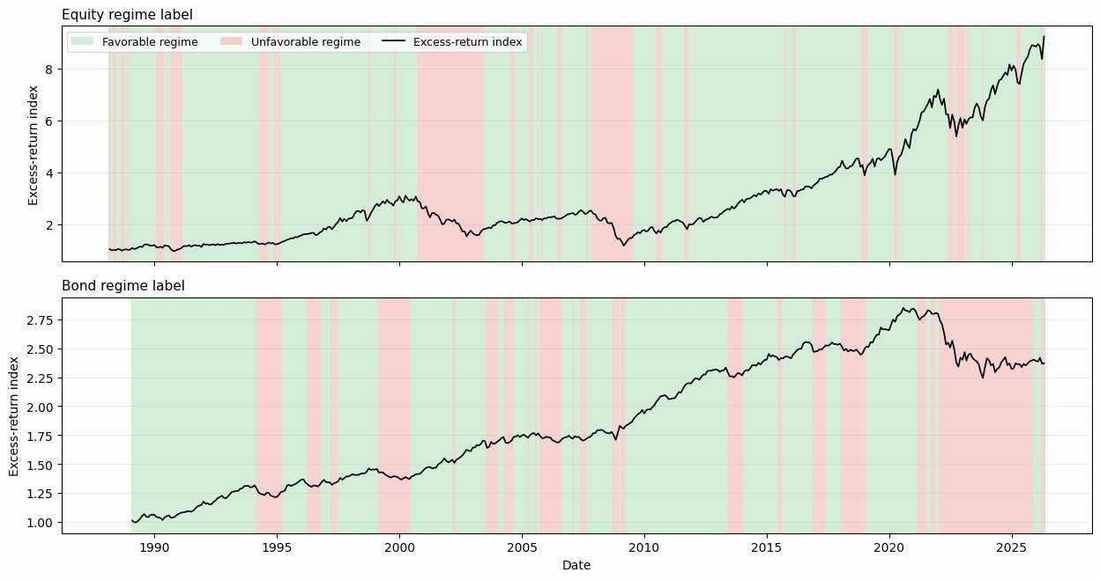

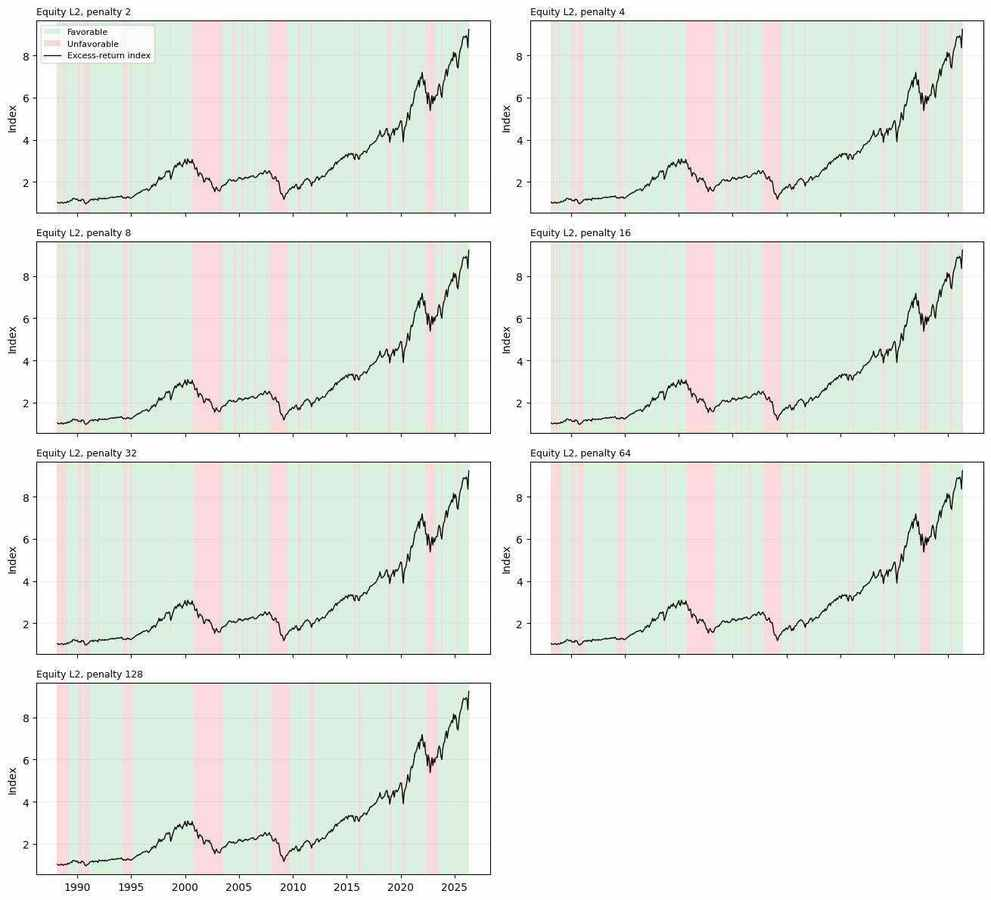

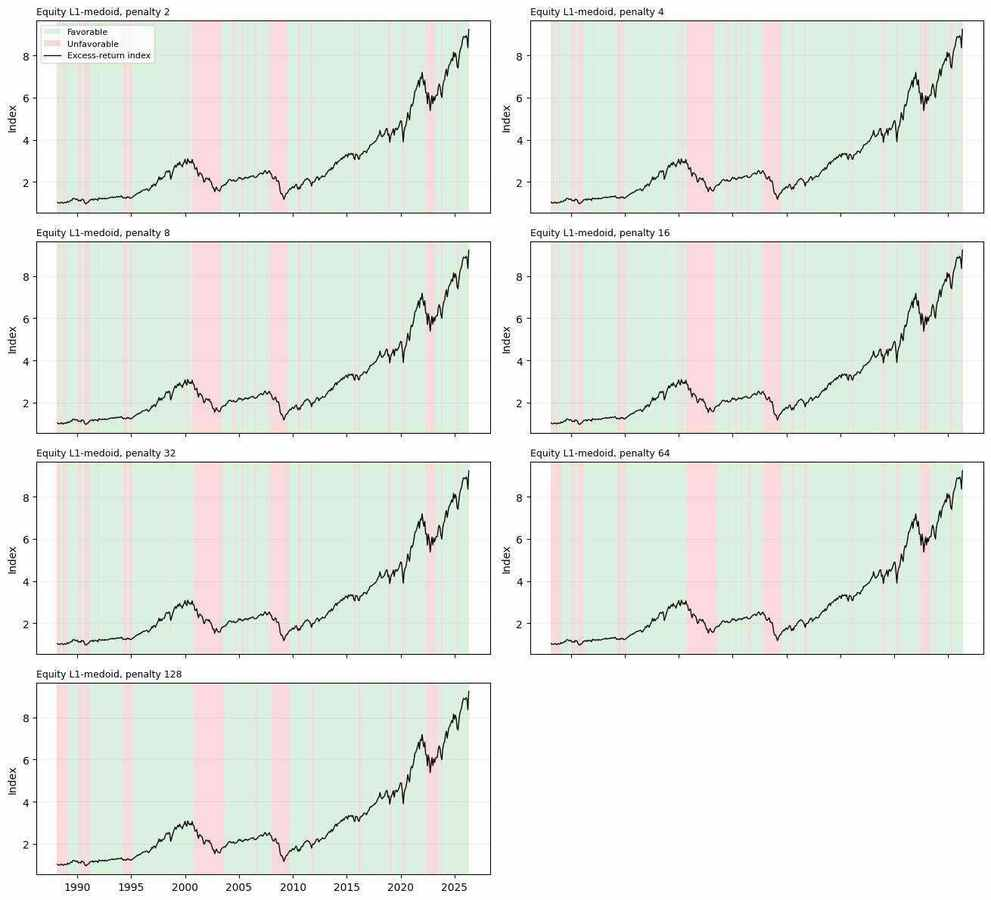

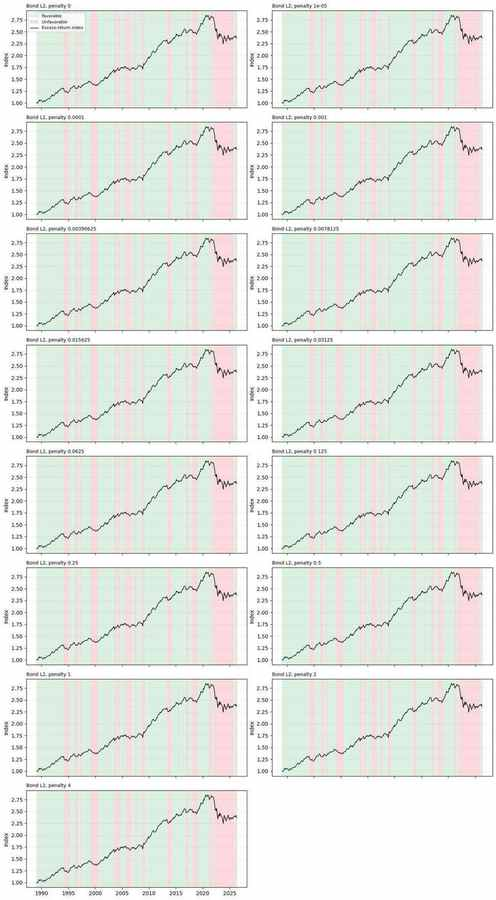

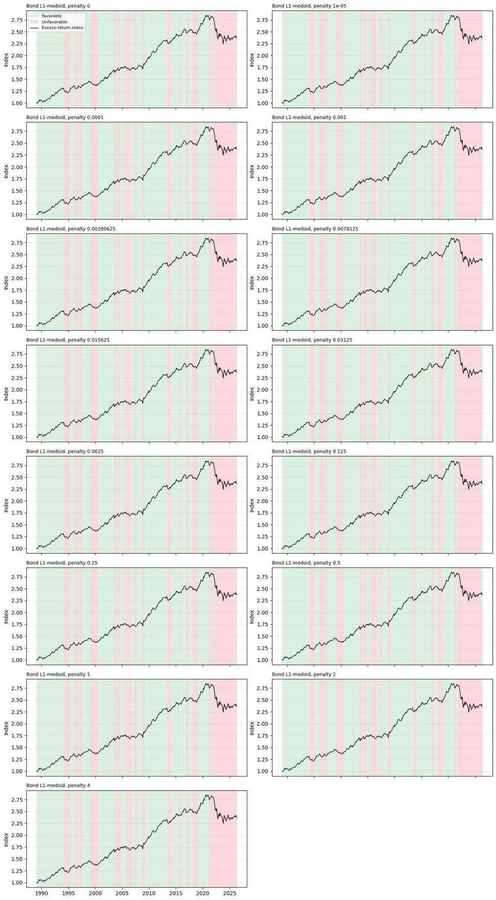

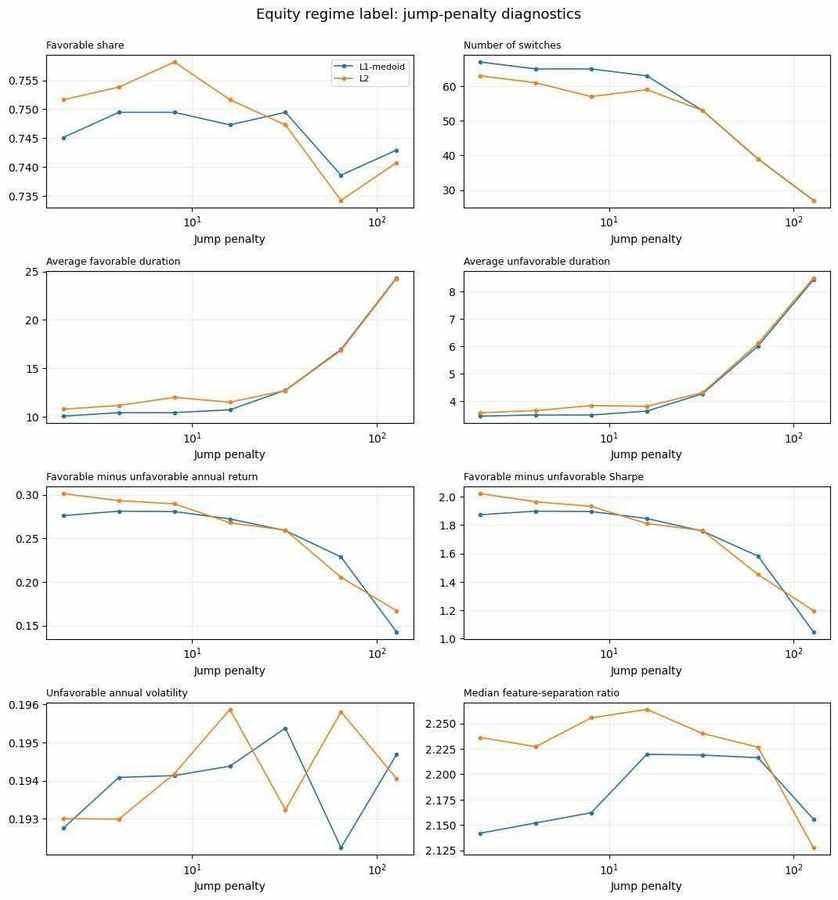

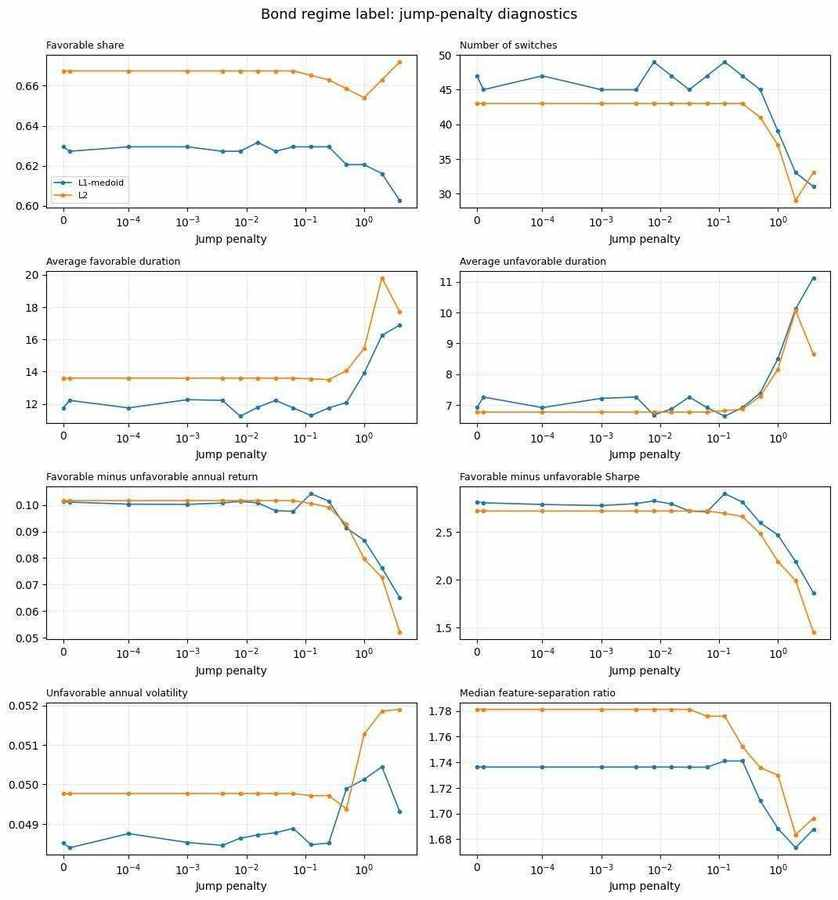

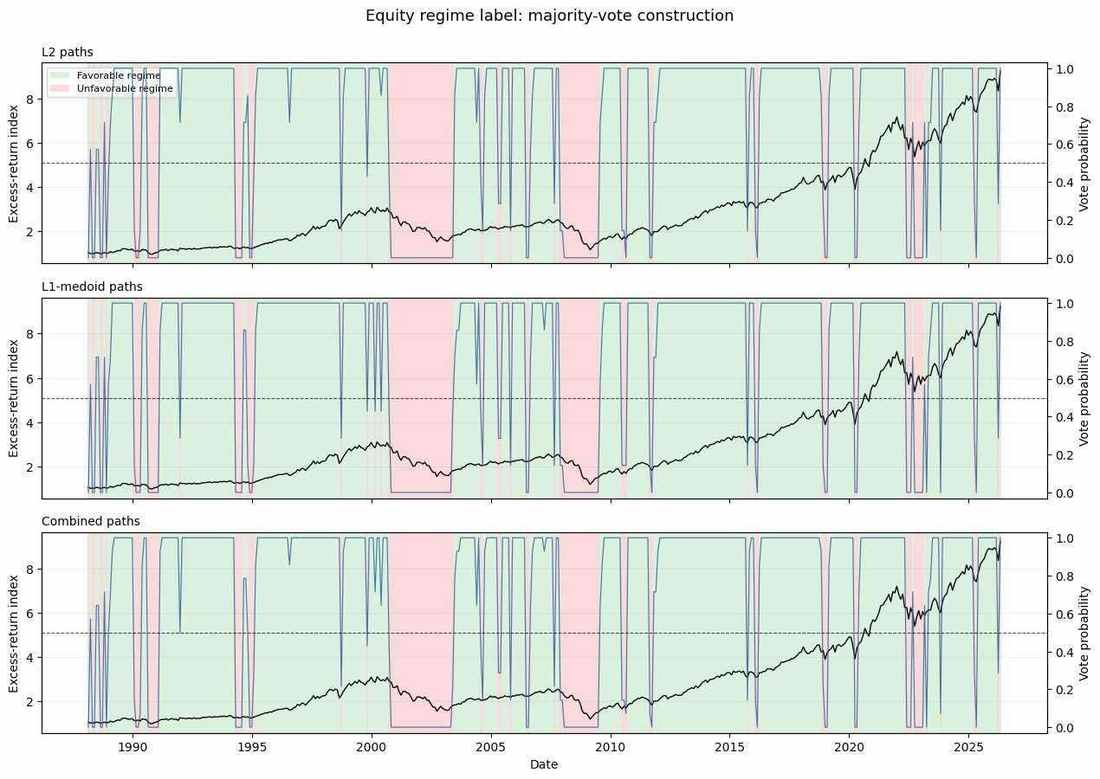

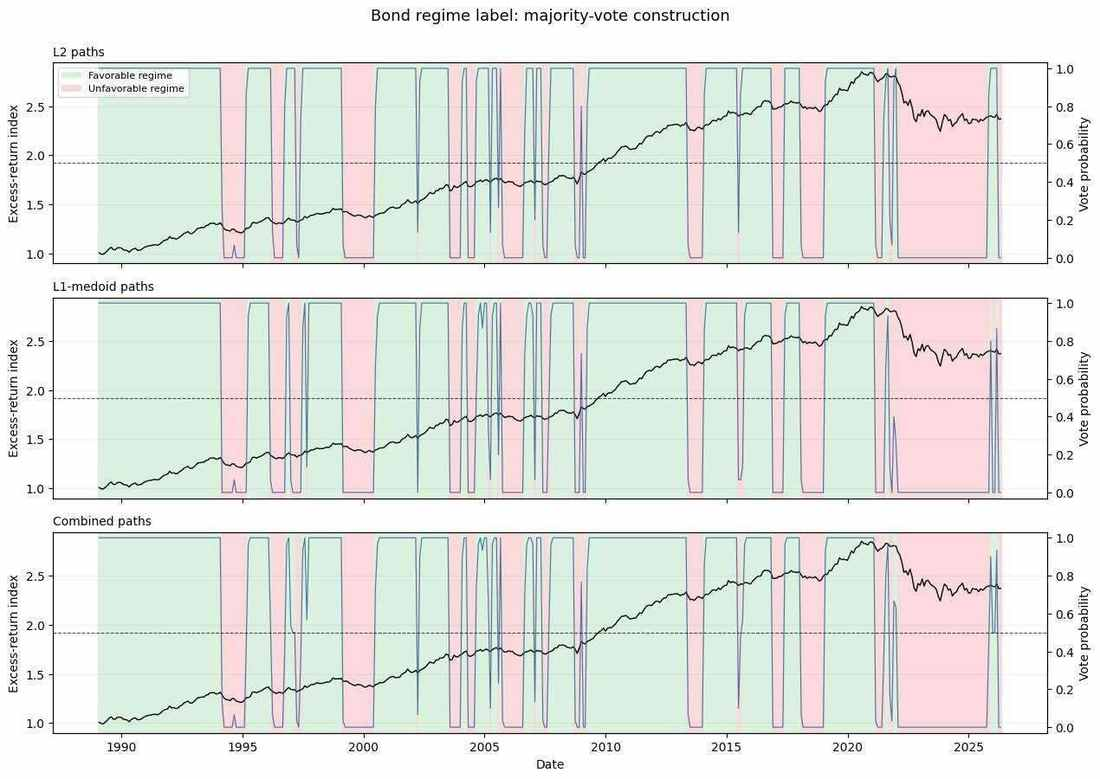

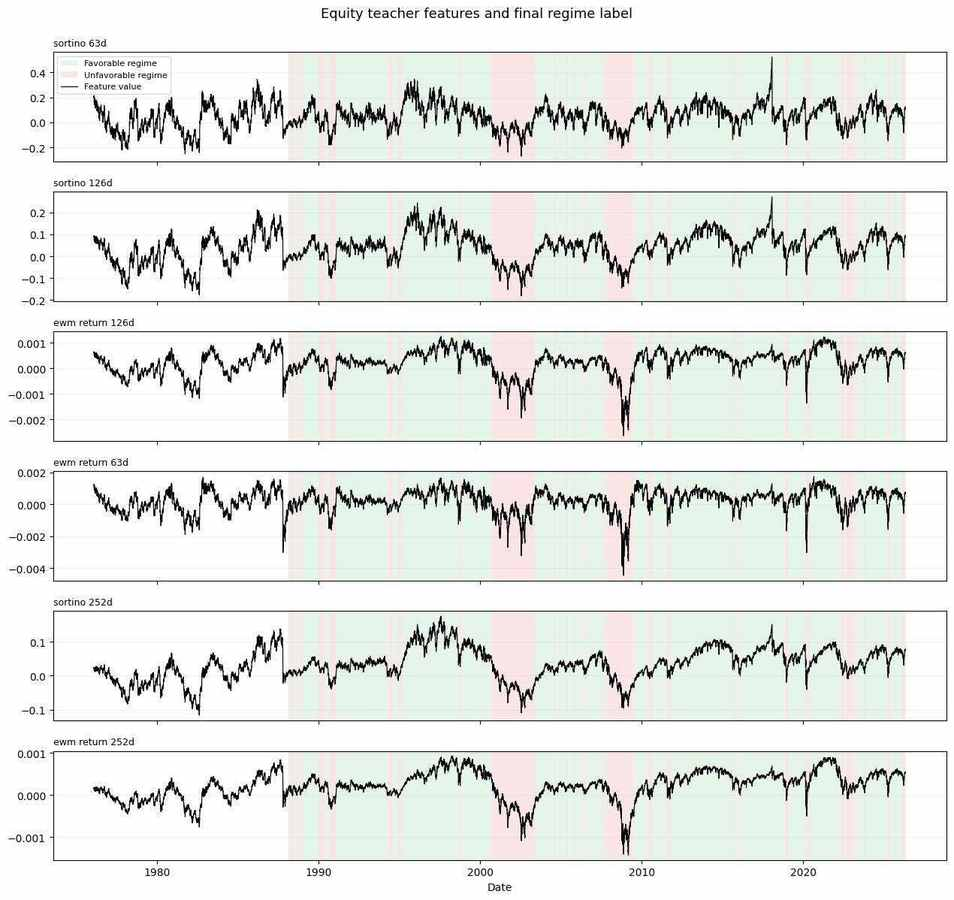

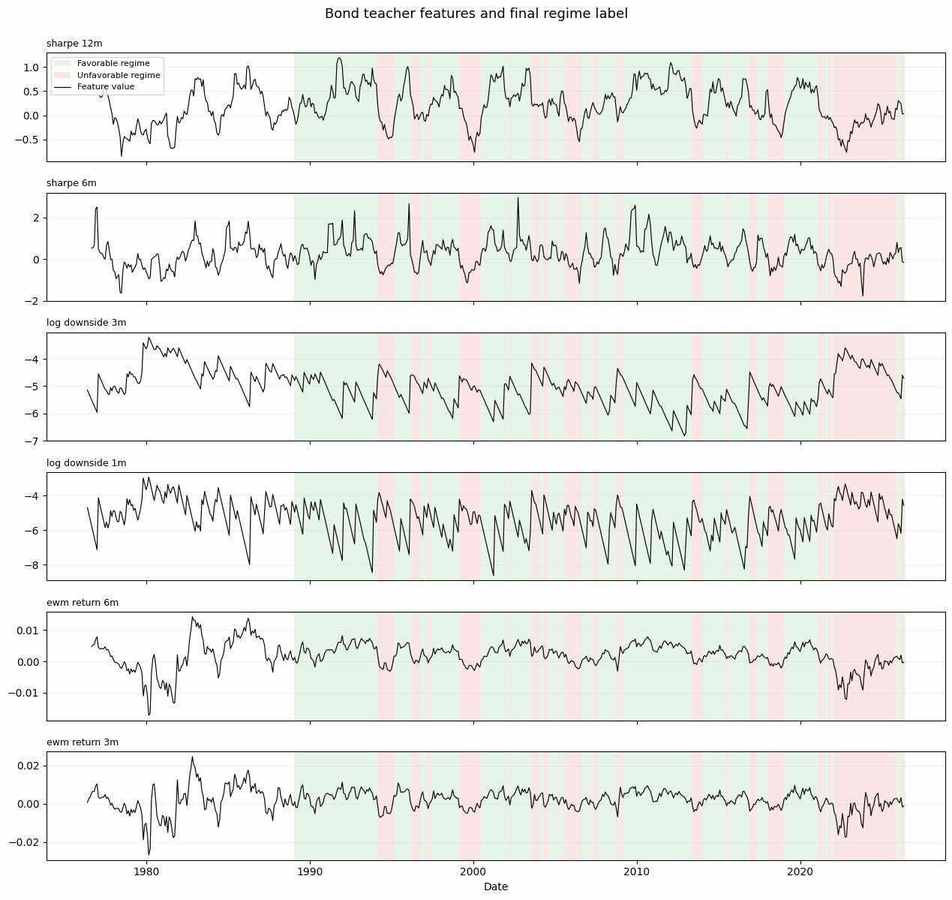

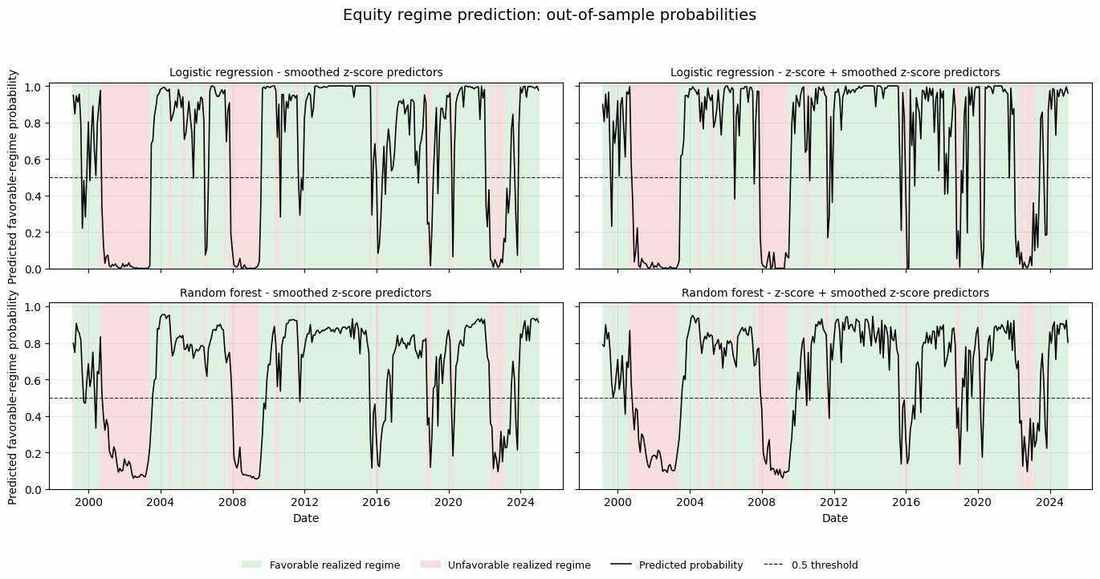

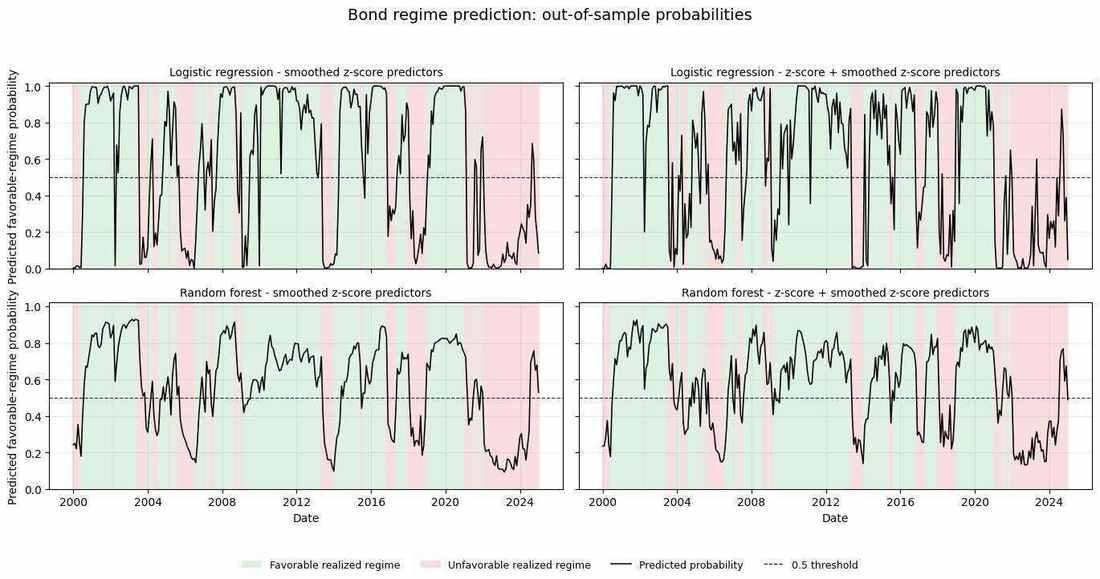

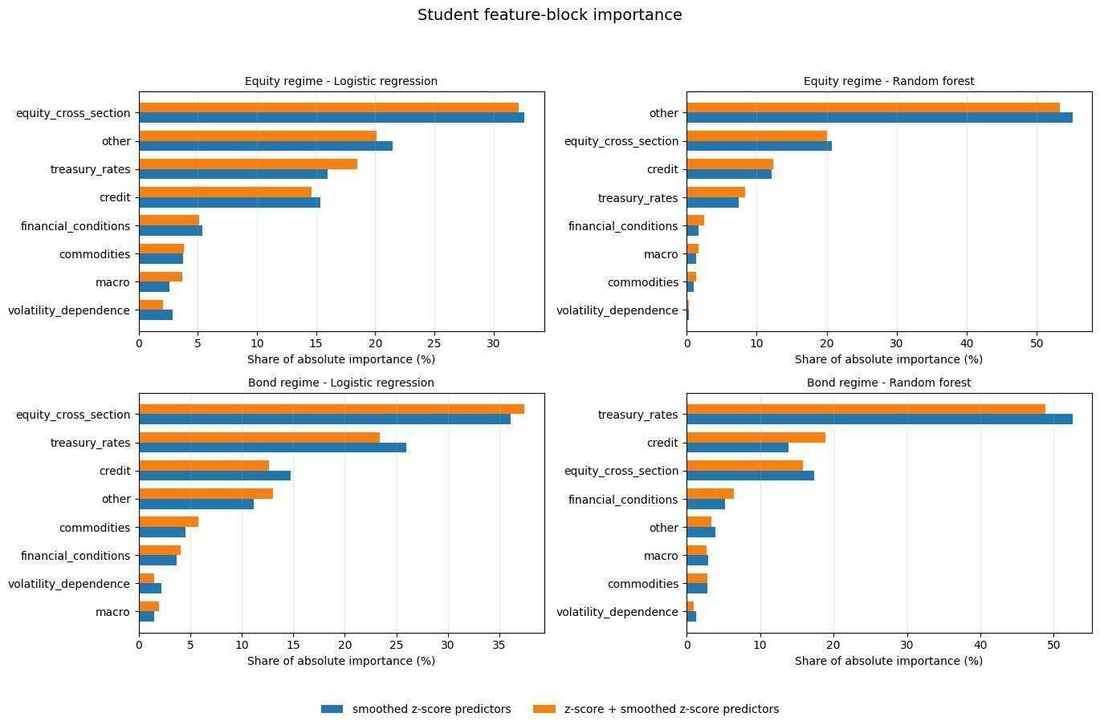

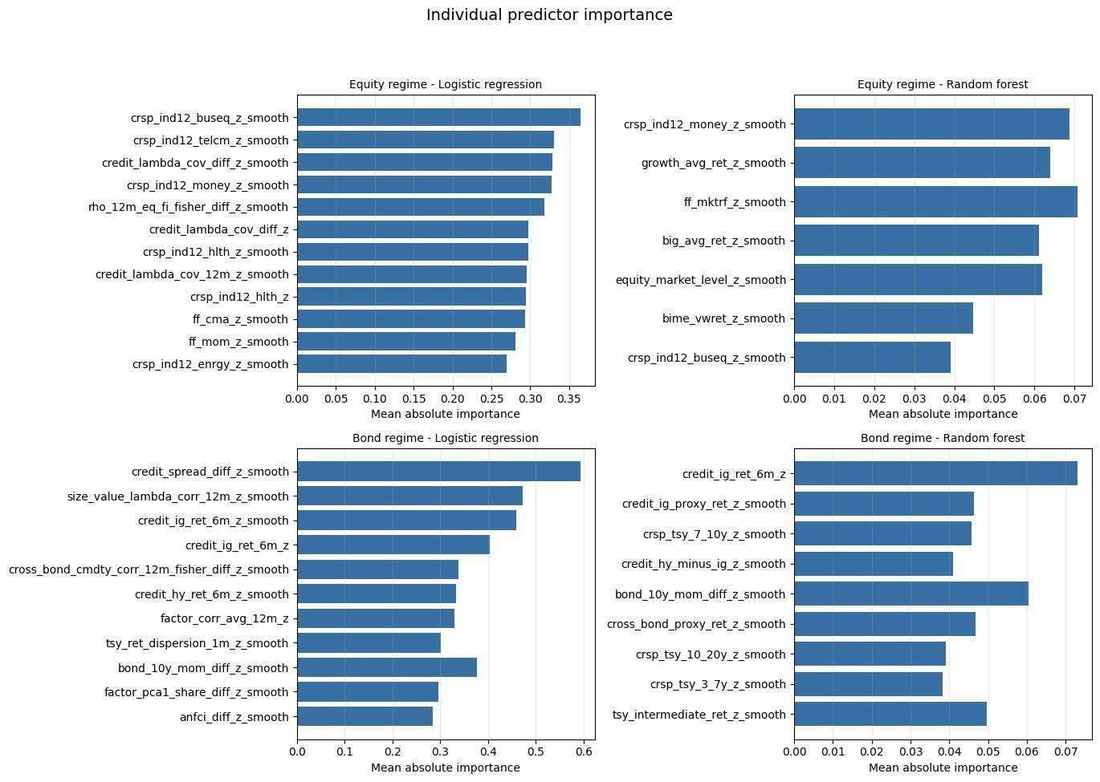

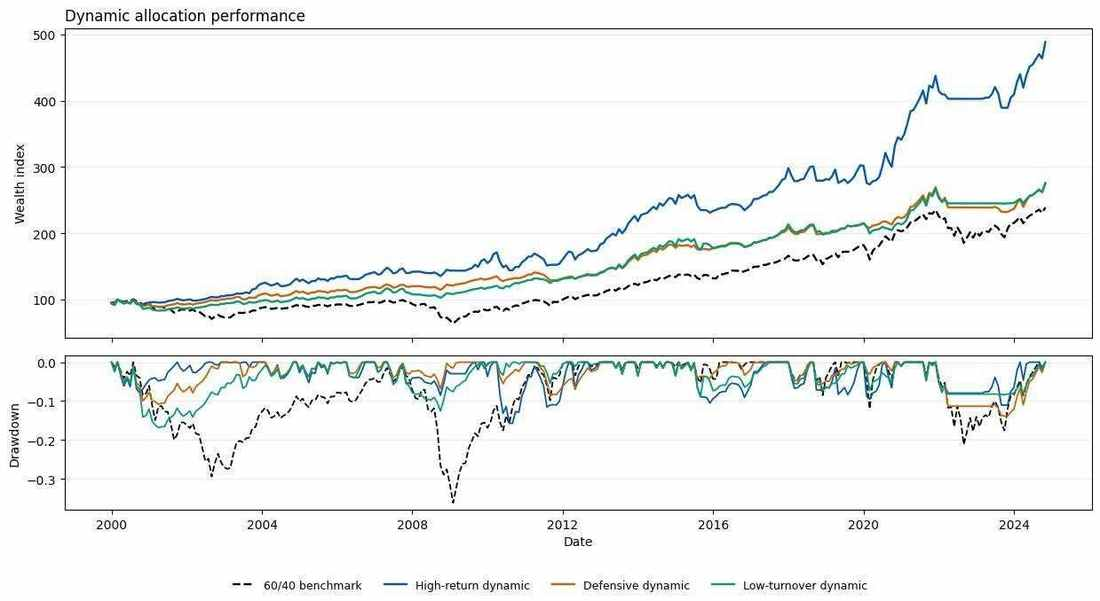

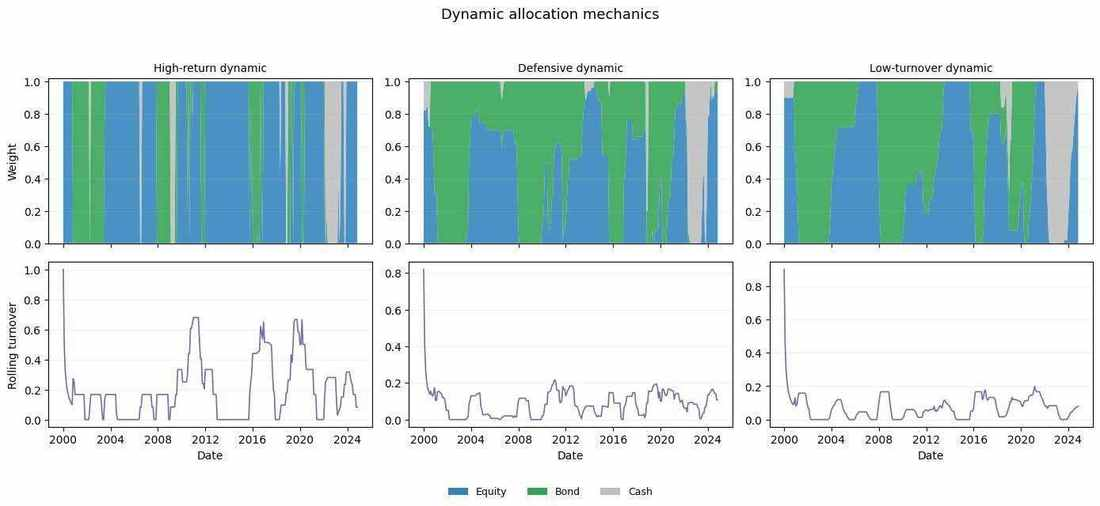

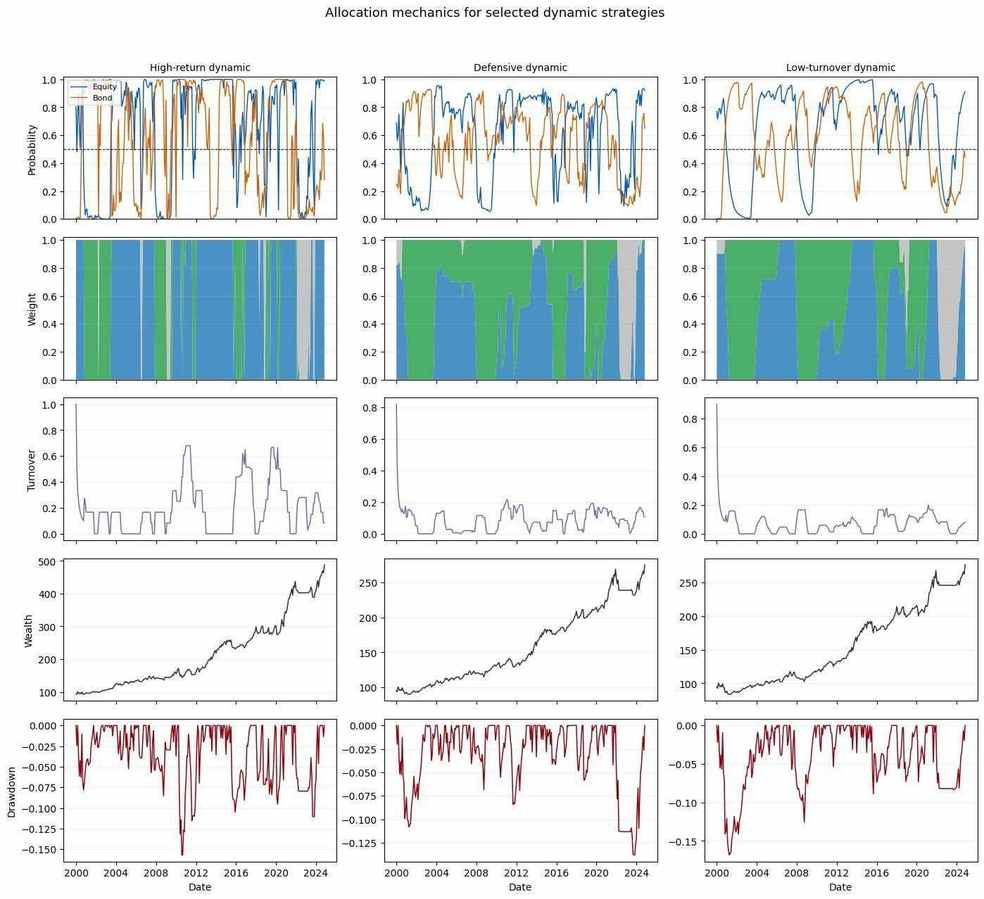

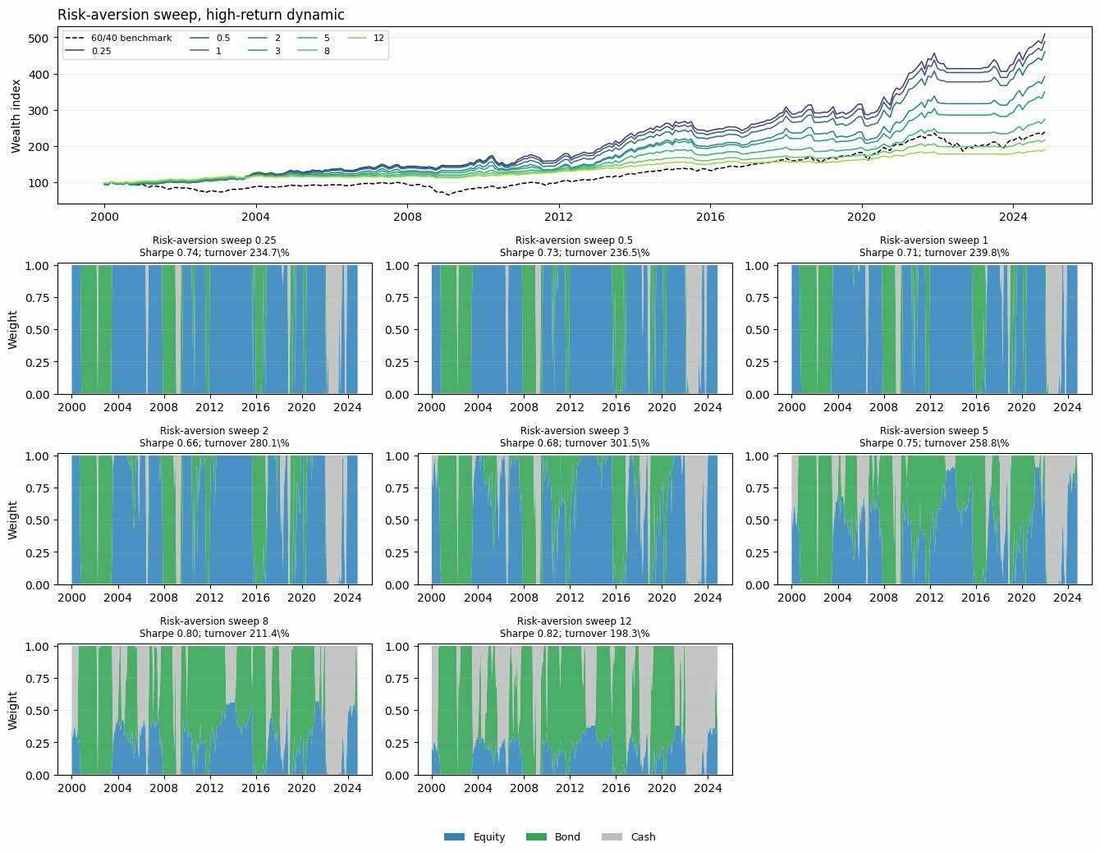

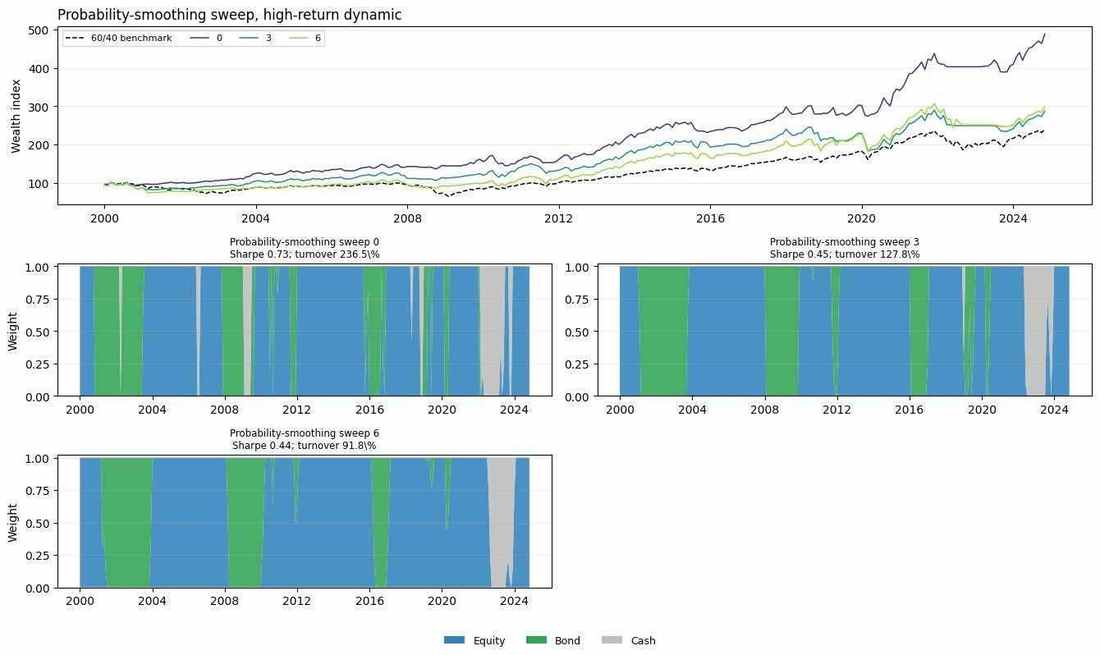

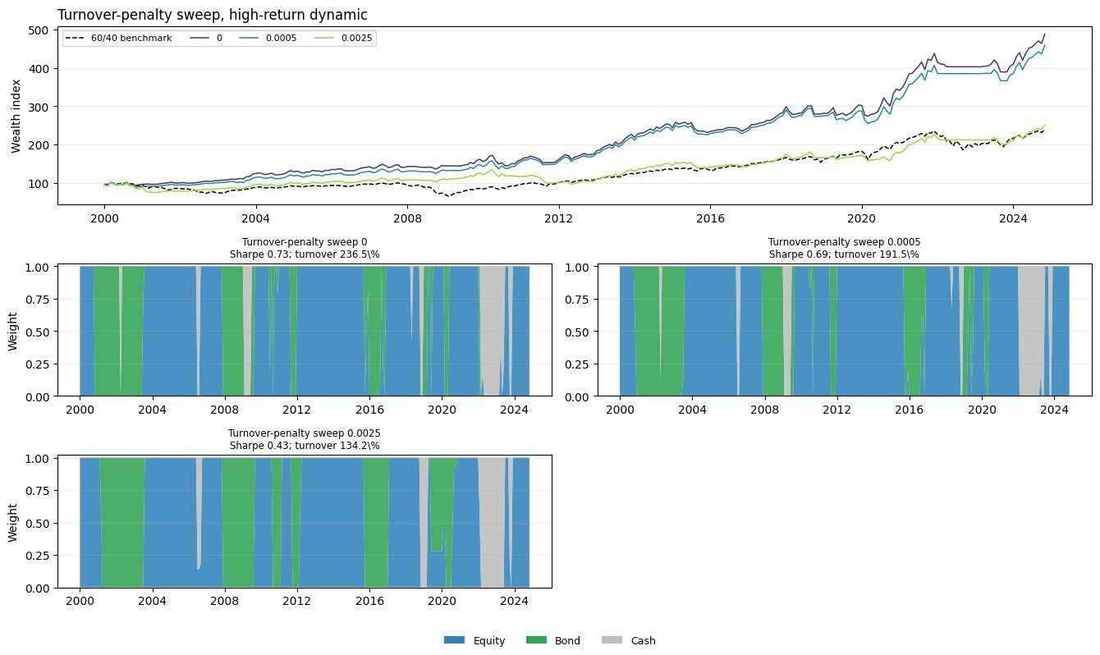

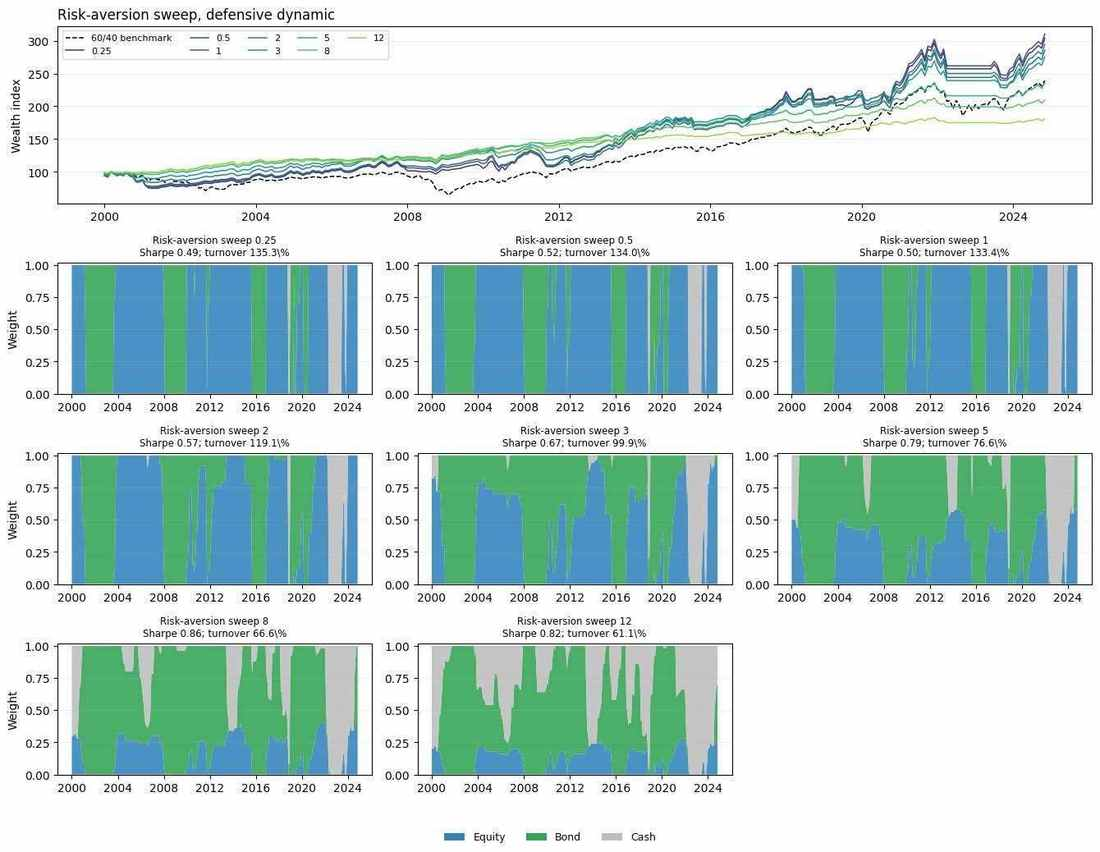

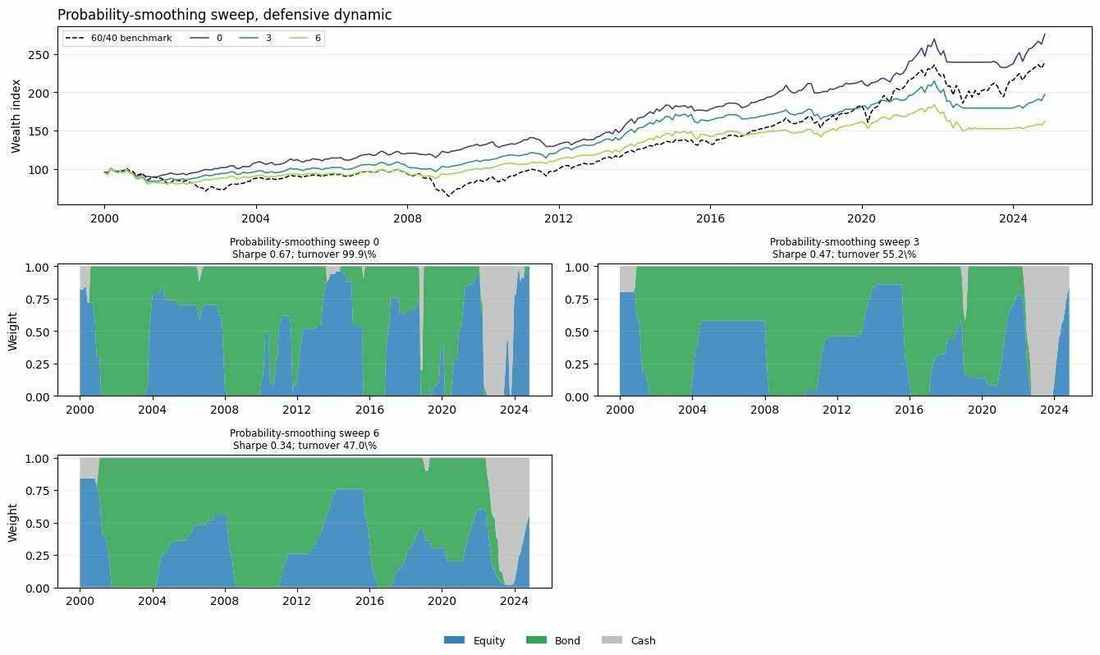

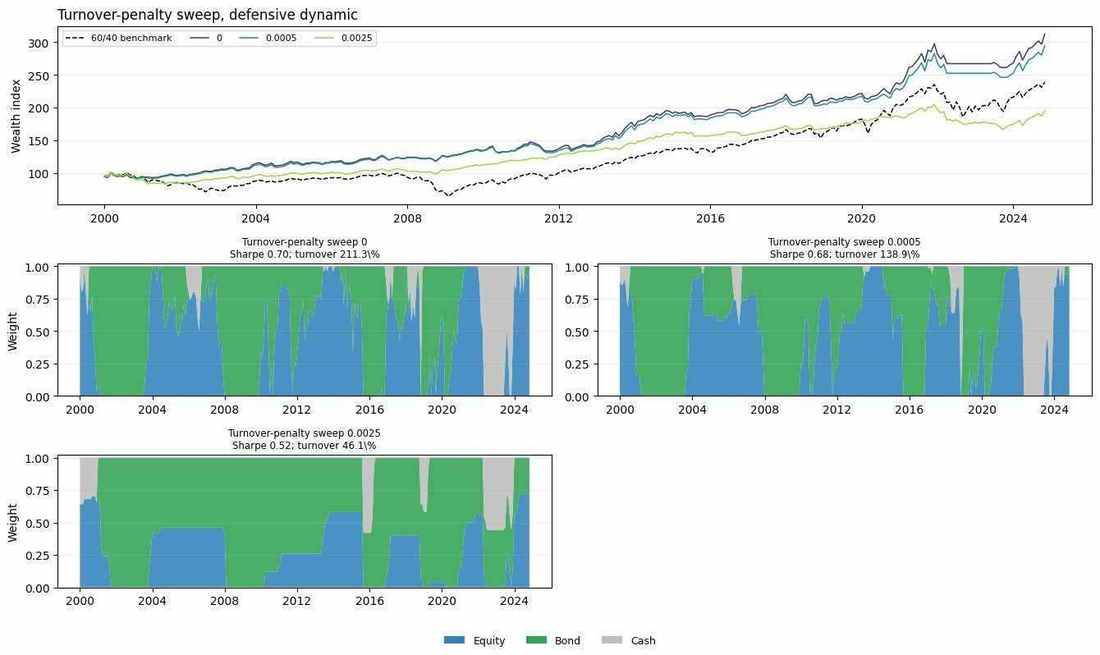

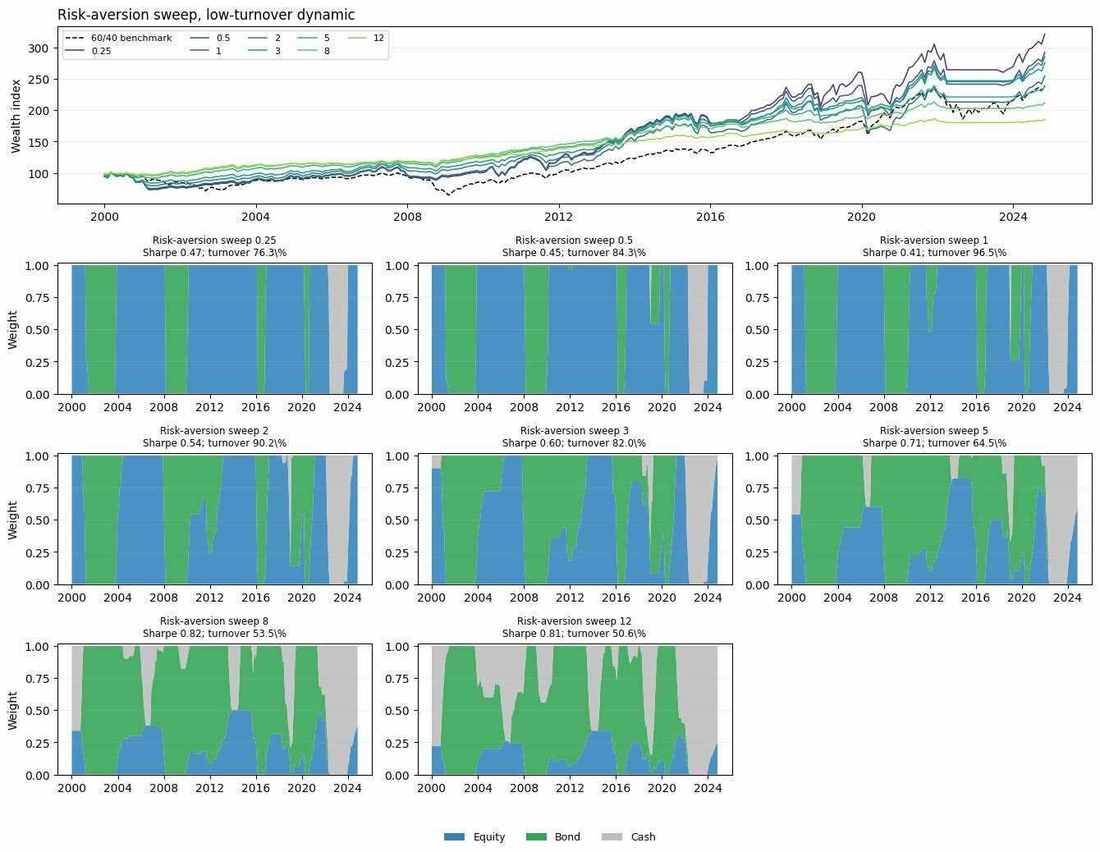

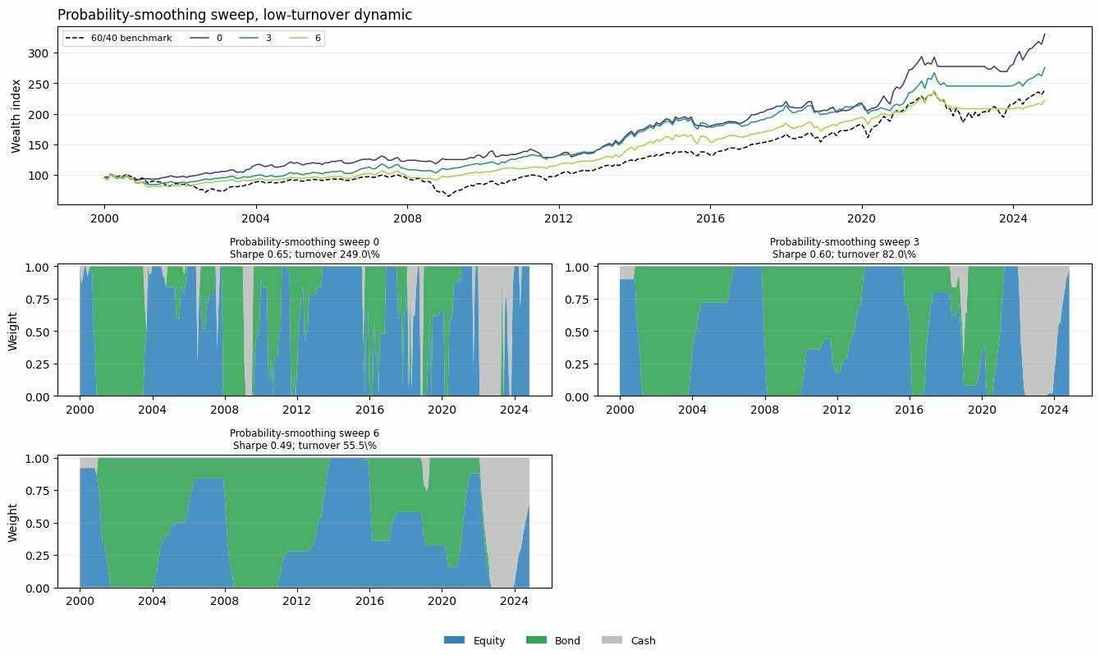

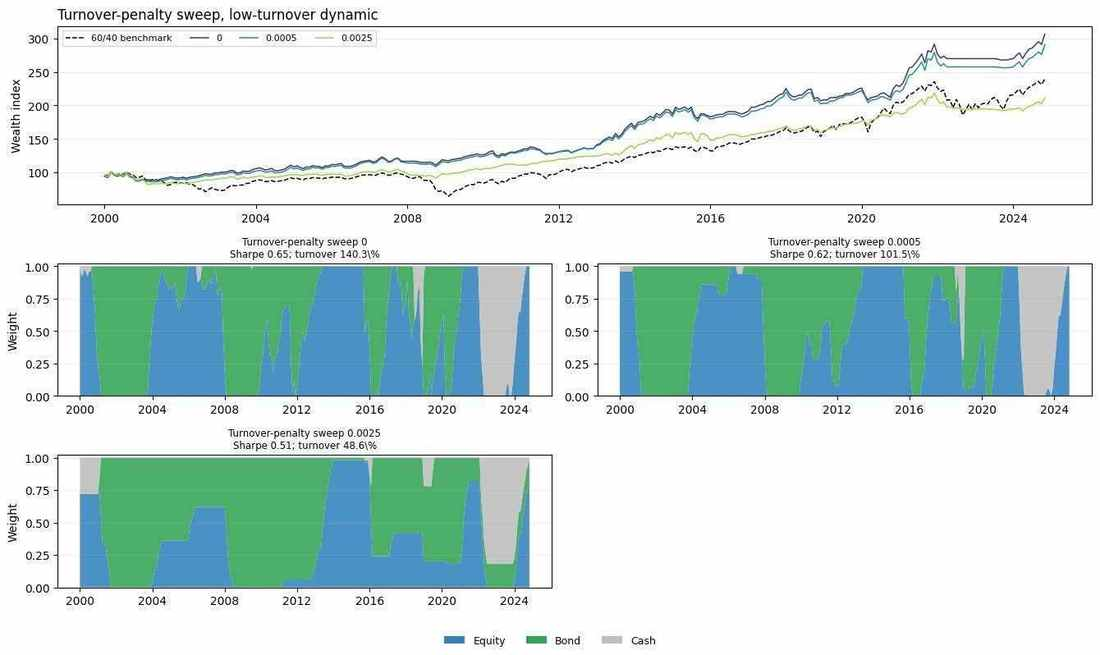

,type,file,exists
0,figure,C:\Users\marce\Desktop\MLFCS_RLMM_26\marcel_sh...,True
1,figure,C:\Users\marce\Desktop\MLFCS_RLMM_26\marcel_sh...,True
2,figure,C:\Users\marce\Desktop\MLFCS_RLMM_26\marcel_sh...,True
3,figure,C:\Users\marce\Desktop\MLFCS_RLMM_26\marcel_sh...,True
4,figure,C:\Users\marce\Desktop\MLFCS_RLMM_26\marcel_sh...,True
5,figure,C:\Users\marce\Desktop\MLFCS_RLMM_26\marcel_sh...,True
6,figure,C:\Users\marce\Desktop\MLFCS_RLMM_26\marcel_sh...,True
7,figure,C:\Users\marce\Desktop\MLFCS_RLMM_26\marcel_sh...,True
8,figure,C:\Users\marce\Desktop\MLFCS_RLMM_26\marcel_sh...,True
9,figure,C:\Users\marce\Desktop\MLFCS_RLMM_26\marcel_sh...,True


In [13]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

pd.set_option("display.max_columns", 260)
pd.set_option("display.width", 560)
pd.set_option("display.max_rows", 1000)
pd.set_option("display.float_format", lambda x: f"{x:0.6f}")

PAPER_ROOT = Path(r"C:\Users\marce\Desktop\MLFCS_RLMM_26\marcel_share_folder\marcel_share_folder")
FIG_DIR = PAPER_ROOT / "figs"
TAB_DIR = PAPER_ROOT / "tabs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

STATE_COLORS = {1: "#b7e4bd", 0: "#f5b5b5"}
WEIGHT_COLORS = {"Equity": "#3182bd", "Bond": "#31a354", "Cash": "#bdbdbd"}
MODEL_LABEL = {"LOGIT": "Logistic regression", "RF": "Random forest"}
FEATURE_LABEL = {
    "z_smooth_only": "smoothed z-score predictors",
    "z_plus_zsmooth": "z-score + smoothed z-score predictors",
    "z_only": "z-score predictors",
    "standardized_and_smoothed_predictors": "z-score + smoothed z-score predictors",
    "smoothed_predictors": "smoothed z-score predictors",
}
FEATURE_CANONICAL = {
    "smoothed_predictors": "z_smooth_only",
    "standardized_and_smoothed_predictors": "z_plus_zsmooth",
    "z_smooth_only": "z_smooth_only",
    "z_plus_zsmooth": "z_plus_zsmooth",
    "z_only": "z_only",
}
TARGET_LABEL = {
    "eq_return_sortino_state_h1": "Equity regime",
    "equity_favourable_h1": "Equity regime",
    "bd_bond_canonical_state_h1": "Bond regime",
    "bond_favourable_h1": "Bond regime",
}
TARGET_ALIASES = {
    "eq_return_sortino_state_h1": ["eq_return_sortino_state_h1", "equity_favourable_h1"],
    "equity_favourable_h1": ["equity_favourable_h1", "eq_return_sortino_state_h1"],
    "bd_bond_canonical_state_h1": ["bd_bond_canonical_state_h1", "bond_favourable_h1"],
    "bond_favourable_h1": ["bond_favourable_h1", "bd_bond_canonical_state_h1"],
}

ROLE_SPECS = [
    {
        "role": "High-return dynamic",
        "short": "High-return",
        "family": "LOGIT",
        "model": "Logistic regression",
        "feature_design": "z_smooth_only",
        "predictor_set": "smoothed z-score",
        "gamma": 0.5,
        "lambda_turnover": 0.0,
        "tcost_one_way": 0.0005,
        "prob_smooth_halflife": 0.0,
    },
    {
        "role": "Defensive dynamic",
        "short": "Defensive",
        "family": "RF",
        "model": "Random forest",
        "feature_design": "z_smooth_only",
        "predictor_set": "smoothed z-score",
        "gamma": 3.0,
        "lambda_turnover": 0.001,
        "tcost_one_way": 0.0005,
        "prob_smooth_halflife": 0.0,
    },
    {
        "role": "Low-turnover dynamic",
        "short": "Low-turnover",
        "family": "LOGIT",
        "model": "Logistic regression",
        "feature_design": "z_plus_zsmooth",
        "predictor_set": "z-score + smoothed z-score",
        "gamma": 3.0,
        "lambda_turnover": 0.001,
        "tcost_one_way": 0.0005,
        "prob_smooth_halflife": 3.0,
    },
]


def _g(name, default=None):
    return globals().get(name, default)


def _df(*names):
    for name in names:
        obj = _g(name)
        if isinstance(obj, pd.DataFrame):
            return obj.copy()
    return pd.DataFrame()


def _target_filter(df, target):
    if "target" not in df.columns:
        return df.iloc[0:0].copy(), target
    for candidate in TARGET_ALIASES.get(target, [target]):
        out = df[df["target"].eq(candidate)].copy()
        if not out.empty:
            return out, candidate
    return df.iloc[0:0].copy(), target


def _normalize_feature_design(df):
    if "feature_design" in df.columns:
        df["feature_design"] = df["feature_design"].astype(str).replace(FEATURE_CANONICAL)
    return df


def _num(s):
    return pd.to_numeric(s, errors="coerce")


def _close(a, b, tol=1e-10):
    return np.isclose(_num(a), float(b), atol=tol, rtol=0.0)


def _match_numeric(a, b):
    exact = _close(a, b)
    if bool(np.asarray(exact).any()):
        return exact
    vals = pd.Series(_num(a)).dropna().drop_duplicates().sort_values()
    if vals.empty:
        return exact
    dist = (vals - float(b)).abs()
    nearest = vals.loc[dist.eq(dist.min())].max()
    return _close(a, nearest)


def _safe_date(x):
    return pd.to_datetime(x, errors="coerce")


def _wealth(ret, start=100.0):
    return start * (1.0 + _num(ret).fillna(0.0)).cumprod()


def _drawdown(wealth):
    w = _num(wealth)
    return w / w.cummax() - 1.0


def _ann_return(r):
    r = _num(r).dropna()
    if len(r) == 0:
        return np.nan
    return (1.0 + r).prod() ** (12.0 / len(r)) - 1.0


def _ann_vol(r):
    r = _num(r).dropna()
    return float(r.std(ddof=1) * np.sqrt(12.0)) if len(r) > 1 else np.nan


def _sharpe(r):
    ar = _ann_return(r)
    av = _ann_vol(r)
    return ar / av if pd.notna(av) and av > 0 else np.nan


def _cvar(r, q=0.01):
    r = _num(r).dropna()
    if len(r) == 0:
        return np.nan
    cutoff = r.quantile(q)
    tail = r[r <= cutoff]
    return float(tail.mean()) if len(tail) else float(cutoff)


def _pct(x, decimals=1):
    return "" if pd.isna(x) else f"{100.0 * float(x):.{decimals}f}\\%"


def _numfmt(x, decimals=2):
    return "" if pd.isna(x) else f"{float(x):.{decimals}f}"


def _bps(x):
    return f"{int(round(float(x) * 10000))}\\,bps"


def _latex_escape(x):
    return (
        str(x)
        .replace("\\", r"\textbackslash{}")
        .replace("&", r"\&")
        .replace("%", r"\%")
        .replace("$", r"\$")
        .replace("#", r"\#")
        .replace("_", r"\_")
        .replace("{", r"\{")
        .replace("}", r"\}")
    )


def _save_fig(fig, stem, formats=("jpg", "png", "pdf"), dpi=300, show=True):
    for ext in formats:
        kwargs = {"bbox_inches": "tight"}
        if ext in {"jpg", "jpeg", "png"}:
            kwargs["dpi"] = dpi
        fig.savefig(FIG_DIR / f"{stem}.{ext}", **kwargs)
    if show:
        plt.show()
    plt.close(fig)


def _date_edges(dates):
    d = _safe_date(pd.Series(dates)).dropna().sort_values().reset_index(drop=True)
    if len(d) == 0:
        return [], []
    if len(d) == 1:
        return [d.iloc[0] - pd.offsets.MonthBegin(1)], [d.iloc[0] + pd.offsets.MonthEnd(1)]
    mids = d.iloc[:-1] + (d.iloc[1:].to_numpy() - d.iloc[:-1].to_numpy()) / 2
    left = [d.iloc[0] - (mids.iloc[0] - d.iloc[0])] + list(mids)
    right = list(mids) + [d.iloc[-1] + (d.iloc[-1] - mids.iloc[-1])]
    return left, right


def _shade_binary(ax, df, date_col, state_col, alpha=0.45):
    if df.empty or date_col not in df.columns or state_col not in df.columns:
        return
    x = df[[date_col, state_col]].dropna().copy()
    if x.empty:
        return
    x[date_col] = _safe_date(x[date_col])
    x[state_col] = _num(x[state_col]).round().astype(int)
    x = x.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)
    left, right = _date_edges(x[date_col])
    x["left"] = left
    x["right"] = right
    x["run"] = (x[state_col] != x[state_col].shift()).cumsum()
    for _, g in x.groupby("run", sort=True):
        st = int(g[state_col].iloc[0])
        ax.axvspan(g["left"].iloc[0], g["right"].iloc[-1], color=STATE_COLORS.get(st, "#eeeeee"), alpha=alpha, lw=0, zorder=0)


def _final_label_data(asset, feature_group, label):
    long = _df("majority_vote_labels_long")
    if long.empty:
        raise RuntimeError("Missing majority_vote_labels_long")
    x = long[
        long["asset"].eq(asset)
        & long["feature_group"].eq(feature_group)
        & long["majority_scope"].eq("all_models")
    ].copy()
    if x.empty:
        raise RuntimeError(f"Missing final majority label for {asset}/{feature_group}")
    x["date"] = _safe_date(x["date"])
    x = x.dropna(subset=["date", "majority_state", "asset_excess"]).sort_values("date")
    x["label"] = label
    x["cumulative_excess_index"] = (1.0 + _num(x["asset_excess"]).fillna(0.0)).cumprod()
    return x[["date", "label", "majority_state", "vote_prob", "vote_strength", "n_teachers", "asset_excess", "cumulative_excess_index"]]


def build_teacher_regime_labels():
    data = pd.concat(
        [
            _final_label_data("equity", "return_sortino", "Equity regime label"),
            _final_label_data("bond", "return_downside_sharpe_vol", "Bond regime label"),
        ],
        ignore_index=True,
    )
    fig, axes = plt.subplots(2, 1, figsize=(12.5, 6.7), sharex=True)
    for ax, label in zip(axes, ["Equity regime label", "Bond regime label"]):
        g = data[data["label"].eq(label)].copy()
        ax.plot(g["date"], g["cumulative_excess_index"], color="black", lw=1.25, zorder=3)
        _shade_binary(ax, g, "date", "majority_state", alpha=0.62)
        ax.set_title(label, loc="left", fontsize=11)
        ax.set_ylabel("Excess-return index")
        ax.grid(axis="y", alpha=0.25)
    axes[0].legend(
        handles=[
            Patch(facecolor=STATE_COLORS[1], alpha=0.62, label="Favorable regime"),
            Patch(facecolor=STATE_COLORS[0], alpha=0.62, label="Unfavorable regime"),
            Line2D([0], [0], color="black", lw=1.25, label="Excess-return index"),
        ],
        loc="upper left",
        ncol=3,
        frameon=True,
        fontsize=9,
    )
    axes[-1].set_xlabel("Date")
    fig.tight_layout()
    _save_fig(fig, "teacher_regime_labels")


def _path_title(asset, feature_group, family, lam):
    model = "L2" if str(family) == "standard_l2_jump_model" else "L1-medoid"
    return f"{asset.title()} {model}, penalty {lam:g}"


def build_teacher_path_figure(asset, feature_group, family, stem):
    labels = _df("teacher_monthly_labels_long")
    if labels.empty:
        raise RuntimeError("Missing teacher_monthly_labels_long")
    x = labels[
        labels["asset"].eq(asset)
        & labels["feature_group"].eq(feature_group)
        & labels["model_family"].eq(family)
    ].copy()
    if x.empty:
        raise RuntimeError(f"Missing teacher path rows for {asset}/{feature_group}/{family}")
    x["date"] = _safe_date(x["date"])
    x["lambda"] = _num(x["lambda"])
    lambdas = sorted(x["lambda"].dropna().unique())
    n = len(lambdas)
    ncols = 2
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13.2, max(3.0 * nrows, 5.5)), sharex=True)
    axes = np.asarray(axes).ravel()
    for ax, lam in zip(axes, lambdas):
        g = x[_close(x["lambda"], lam)].copy().sort_values("date")
        g = g.dropna(subset=["date", "state", "asset_excess"])
        g["level"] = _wealth(g["asset_excess"], start=1.0)
        ax.plot(g["date"], g["level"], color="black", lw=1.0, zorder=3)
        _shade_binary(ax, g, "date", "state", alpha=0.50)
        ax.set_title(_path_title(asset, feature_group, family, lam), loc="left", fontsize=9)
        ax.set_ylabel("Index")
        ax.grid(axis="y", alpha=0.20)
    for ax in axes[n:]:
        ax.axis("off")
    axes[0].legend(
        handles=[
            Patch(facecolor=STATE_COLORS[1], alpha=0.50, label="Favorable"),
            Patch(facecolor=STATE_COLORS[0], alpha=0.50, label="Unfavorable"),
            Line2D([0], [0], color="black", lw=1.0, label="Excess-return index"),
        ],
        loc="upper left",
        fontsize=8,
        frameon=True,
    )
    fig.tight_layout()
    _save_fig(fig, stem)


def build_teacher_lambda_diagnostics(asset, feature_group, stem):
    diag = _df("teacher_path_diagnostics")
    if diag.empty:
        raise RuntimeError("Missing teacher_path_diagnostics")
    x = diag[diag["asset"].eq(asset) & diag["feature_group"].eq(feature_group)].copy()
    if x.empty:
        raise RuntimeError(f"Missing lambda diagnostics for {asset}/{feature_group}")
    x["lambda"] = _num(x["lambda"])
    metrics = [
        ("good_share", "Favorable share"),
        ("n_switches", "Number of switches"),
        ("mean_good_spell_length", "Average favorable duration"),
        ("mean_bad_spell_length", "Average unfavorable duration"),
        ("good_minus_bad_ann_return", "Favorable minus unfavorable annual return"),
        ("good_minus_bad_sharpe", "Favorable minus unfavorable Sharpe"),
        ("state_bad_ann_vol", "Unfavorable annual volatility"),
        ("median_centroid_separation", "Median feature-separation ratio"),
    ]
    fig, axes = plt.subplots(4, 2, figsize=(10.8, 11.5))
    axes = axes.ravel()
    for ax, (col, title) in zip(axes, metrics):
        if col not in x.columns:
            ax.axis("off")
            continue
        for family, g in x.groupby("model_family", dropna=False):
            g = g.sort_values("lambda")
            label = "L2" if str(family) == "standard_l2_jump_model" else "L1-medoid"
            ax.plot(g["lambda"], _num(g[col]), marker="o", lw=1.2, ms=3.0, label=label)
        if (x["lambda"] > 0).any():
            ax.set_xscale("symlog", linthresh=1e-4)
        ax.set_title(title, loc="left", fontsize=9)
        ax.set_xlabel("Jump penalty")
        ax.grid(True, alpha=0.25)
    axes[0].legend(loc="best", fontsize=8)
    fig.suptitle(f"{asset.title()} regime label: jump-penalty diagnostics", y=0.995, fontsize=13)
    fig.tight_layout()
    _save_fig(fig, stem)


def build_majority_vote_scopes(asset, feature_group, stem):
    long = _df("majority_vote_labels_long")
    if long.empty:
        raise RuntimeError("Missing majority_vote_labels_long")
    x = long[long["asset"].eq(asset) & long["feature_group"].eq(feature_group)].copy()
    x["date"] = _safe_date(x["date"])
    scope_order = ["l2_only", "l1_medoids_only", "all_models"]
    scope_title = {"l2_only": "L2 paths", "l1_medoids_only": "L1-medoid paths", "all_models": "Combined paths"}
    scopes = [s for s in scope_order if s in set(x["majority_scope"])]
    fig, axes = plt.subplots(len(scopes), 1, figsize=(12.8, 3.0 * len(scopes)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, scope in zip(axes, scopes):
        g = x[x["majority_scope"].eq(scope)].dropna(subset=["date", "majority_state", "asset_excess"]).sort_values("date").copy()
        g["level"] = _wealth(g["asset_excess"], start=1.0)
        ax.plot(g["date"], g["level"], color="black", lw=1.0, zorder=3)
        _shade_binary(ax, g, "date", "majority_state", alpha=0.50)
        ax2 = ax.twinx()
        ax2.plot(g["date"], g["vote_prob"], color="#2f5f9f", lw=0.85, alpha=0.85)
        ax2.axhline(0.5, color="black", lw=0.75, ls="--", alpha=0.70)
        ax2.set_ylim(-0.03, 1.03)
        ax2.set_ylabel("Vote probability")
        ax.set_ylabel("Excess-return index")
        ax.set_title(scope_title.get(scope, scope), loc="left", fontsize=10)
        ax.grid(axis="y", alpha=0.20)
    axes[0].legend(
        handles=[
            Patch(facecolor=STATE_COLORS[1], alpha=0.50, label="Favorable regime"),
            Patch(facecolor=STATE_COLORS[0], alpha=0.50, label="Unfavorable regime"),
        ],
        loc="upper left",
        frameon=True,
        fontsize=8,
    )
    axes[-1].set_xlabel("Date")
    fig.suptitle(f"{asset.title()} regime label: majority-vote construction", y=0.995, fontsize=13)
    fig.tight_layout()
    _save_fig(fig, stem)


def _teacher_feature_source(asset, feature_group):
    daily = _df("teacher_daily_features_long", "daily_teacher_features")
    monthly = _df("teacher_monthly_features_long", "monthly_teacher_features")
    if asset == "equity":
        src = daily
    else:
        src = monthly
    if src.empty:
        raise RuntimeError(f"Missing feature panel for {asset}")
    x = src[src["asset"].eq(asset) & src["feature_group"].eq(feature_group)].copy()
    x["date"] = _safe_date(x["date"])
    return x.dropna(subset=["date"]).sort_values("date")


def build_teacher_feature_figure(asset, feature_group, stem, top_n=6):
    feats = _teacher_feature_source(asset, feature_group)
    labels = _final_label_data(
        asset,
        feature_group,
        "Equity regime label" if asset == "equity" else "Bond regime label",
    )[["date", "majority_state"]].copy()
    sep = _df("teacher_feature_separation_summary")
    if not sep.empty:
        cand = sep[sep["asset"].eq(asset) & sep["feature_group"].eq(feature_group)].copy()
        rank_col = "median_sep" if "median_sep" in cand.columns else "centroid_separation_ratio"
        feature_cols = [c for c in cand.sort_values(rank_col, ascending=False)["feature"].astype(str).tolist() if c in feats.columns]
    else:
        non_feature = {"date", "asset", "teacher_panel", "feature_group", "source_frequency", "label_source", "feature_source", "excess_return", "excess_return_source", "n_daily_obs"}
        feature_cols = [c for c in feats.columns if c not in non_feature and pd.api.types.is_numeric_dtype(feats[c])]
    feature_cols = list(dict.fromkeys(feature_cols))[:top_n]
    if not feature_cols:
        raise RuntimeError(f"No plottable features found for {asset}/{feature_group}")
    plot_df = feats[["date"] + feature_cols].copy()
    plot_df = plot_df.merge(labels, on="date", how="left")
    n = len(feature_cols)
    fig, axes = plt.subplots(n, 1, figsize=(12.8, max(2.0 * n, 6.0)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, feature_cols):
        g = plot_df[["date", col, "majority_state"]].dropna(subset=["date", col]).copy()
        ax.plot(g["date"], _num(g[col]), color="black", lw=0.85, zorder=3)
        _shade_binary(ax, g.dropna(subset=["majority_state"]), "date", "majority_state", alpha=0.35)
        ax.set_title(col.replace("_", " "), loc="left", fontsize=9)
        ax.grid(axis="y", alpha=0.20)
    axes[0].legend(
        handles=[
            Patch(facecolor=STATE_COLORS[1], alpha=0.35, label="Favorable regime"),
            Patch(facecolor=STATE_COLORS[0], alpha=0.35, label="Unfavorable regime"),
            Line2D([0], [0], color="black", lw=0.85, label="Feature value"),
        ],
        loc="upper left",
        frameon=True,
        fontsize=8,
    )
    axes[-1].set_xlabel("Date")
    fig.suptitle(f"{asset.title()} teacher features and final regime label", y=0.995, fontsize=13)
    fig.tight_layout()
    _save_fig(fig, stem)


def _prediction_data():
    panel = _df("prediction_panel", "student_oos_prediction_panel_long")
    metrics = _df("prediction_metrics", "student_forecast_summary")
    if panel.empty:
        raise RuntimeError("Missing prediction_panel or student_oos_prediction_panel_long")
    panel = panel.copy()
    if "date" not in panel.columns and "test_date" in panel.columns:
        panel["date"] = panel["test_date"]
    panel["date"] = _safe_date(panel["date"])
    if "family" not in panel.columns and "model" in panel.columns:
        panel["family"] = panel["model"].astype(str).str.upper().replace({"LOGISTIC_REGRESSION": "LOGIT", "RANDOM_FOREST": "RF"})
    if "p_mean" not in panel.columns:
        for c in ["p_hat", "prob", "predicted_probability", "p"]:
            if c in panel.columns:
                panel["p_mean"] = _num(panel[c])
                break
    if "y_true" not in panel.columns:
        for c in ["y", "actual", "realized", "target_value"]:
            if c in panel.columns:
                panel["y_true"] = _num(panel[c])
                break
    if "feature_design" not in panel.columns and "predictor_set" in panel.columns:
        panel["feature_design"] = panel["predictor_set"]
    panel = _normalize_feature_design(panel)
    if metrics.empty:
        metrics = pd.DataFrame()
    return panel, metrics


def build_prediction_probability_grid(target, stem, title):
    panel, _ = _prediction_data()
    x, chosen_target = _target_filter(panel, target)
    if x.empty:
        raise RuntimeError(f"Missing prediction rows for {target}")
    families = [f for f in ["LOGIT", "RF"] if f in set(x["family"])]
    designs = [d for d in ["z_smooth_only", "z_plus_zsmooth"] if d in set(x["feature_design"])]
    if not designs:
        designs = list(x["feature_design"].dropna().drop_duplicates())[:2]
    fig, axes = plt.subplots(len(families), len(designs), figsize=(13.8, 7.2), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(len(families), len(designs))
    for i, fam in enumerate(families):
        for j, design in enumerate(designs):
            ax = axes[i, j]
            g = x[x["family"].eq(fam) & x["feature_design"].eq(design)].dropna(subset=["date", "p_mean"]).sort_values("date").copy()
            if g.empty:
                ax.axis("off")
                continue
            _shade_binary(ax, g.dropna(subset=["y_true"]), "date", "y_true", alpha=0.45)
            ax.plot(g["date"], _num(g["p_mean"]), color="black", lw=1.15, zorder=4)
            ax.axhline(0.5, color="black", lw=0.85, ls="--", alpha=0.80)
            ax.set_ylim(0, 1.02)
            ax.set_title(f"{MODEL_LABEL.get(fam, fam)} - {FEATURE_LABEL.get(design, design)}", fontsize=10)
            ax.grid(True, alpha=0.25)
            if j == 0:
                ax.set_ylabel("Predicted favorable-regime probability")
            if i == len(families) - 1:
                ax.set_xlabel("Date")
    handles = [
        Patch(facecolor=STATE_COLORS[1], alpha=0.45, label="Favorable realized regime"),
        Patch(facecolor=STATE_COLORS[0], alpha=0.45, label="Unfavorable realized regime"),
        Line2D([0], [0], color="black", lw=1.15, label="Predicted probability"),
        Line2D([0], [0], color="black", lw=0.85, ls="--", label="0.5 threshold"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, fontsize=9)
    fig.suptitle(title, y=0.985, fontsize=14)
    fig.tight_layout(rect=[0, 0.07, 1, 0.95])
    _save_fig(fig, stem)


def _importance_data():
    imp = _df("feature_importance_summary", "feature_importance_top_table", "student_feature_importance_summary")
    if imp.empty:
        raise RuntimeError("Missing feature_importance_summary or student_feature_importance_summary")
    if "family" not in imp.columns and "model" in imp.columns:
        imp["family"] = imp["model"].astype(str).str.upper().replace({"LOGISTIC_REGRESSION": "LOGIT", "RANDOM_FOREST": "RF"})
    if "mean_abs_importance" not in imp.columns:
        for c in ["importance", "abs_importance", "mean_abs_coef", "block_share_of_importance"]:
            if c in imp.columns:
                imp["mean_abs_importance"] = _num(imp[c])
                break
    imp = _normalize_feature_design(imp)
    return imp


def build_feature_importance_figures():
    imp = _importance_data()
    scenarios = [
        ("eq_return_sortino_state_h1", "LOGIT"),
        ("eq_return_sortino_state_h1", "RF"),
        ("bd_bond_canonical_state_h1", "LOGIT"),
        ("bd_bond_canonical_state_h1", "RF"),
    ]
    designs = [d for d in ["z_smooth_only", "z_plus_zsmooth"] if d in set(imp.get("feature_design", pd.Series(dtype=str)))]
    if not designs and "feature_design" in imp.columns:
        designs = list(imp["feature_design"].dropna().drop_duplicates())[:2]

    fig, axes = plt.subplots(2, 2, figsize=(13.8, 9.0))
    axes = axes.ravel()
    for ax, (target, fam) in zip(axes, scenarios):
        target_imp, chosen_target = _target_filter(imp, target)
        h = target_imp[target_imp["family"].eq(fam)].copy()
        if h.empty or "feature_block" not in h.columns:
            ax.axis("off")
            continue
        block_rows = []
        for design in designs:
            d = h[h["feature_design"].eq(design)].copy() if "feature_design" in h.columns else h.copy()
            b = d.groupby("feature_block", dropna=False)["mean_abs_importance"].sum()
            total = b.sum()
            if total > 0:
                b = 100.0 * b / total
            for block, value in b.items():
                block_rows.append({"feature_block": block, "feature_design": design, "value": value})
        bdf = pd.DataFrame(block_rows)
        order = bdf.groupby("feature_block")["value"].max().sort_values(ascending=True).tail(10).index.tolist()
        ypos = np.arange(len(order))
        width = 0.36
        for k, design in enumerate(designs):
            vals = bdf[bdf["feature_design"].eq(design)].set_index("feature_block")["value"].reindex(order).fillna(0)
            ax.barh(ypos + (k - 0.5) * width, vals.values, height=width, label=FEATURE_LABEL.get(design, design))
        ax.set_yticks(ypos)
        ax.set_yticklabels([str(v) for v in order])
        ax.set_xlabel("Share of absolute importance (%)")
        ax.set_title(f"{TARGET_LABEL.get(chosen_target, target)} - {MODEL_LABEL.get(fam, fam)}", fontsize=10)
        ax.grid(axis="x", alpha=0.25)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=max(1, len(labels)), frameon=False, fontsize=10)
    fig.suptitle("Student feature-block importance", y=0.99, fontsize=14)
    fig.tight_layout(rect=[0, 0.06, 1, 0.95])
    _save_fig(fig, "feature_block_importance")

    fig, axes = plt.subplots(2, 2, figsize=(13.8, 10.0))
    axes = axes.ravel()
    for ax, (target, fam) in zip(axes, scenarios):
        target_imp, chosen_target = _target_filter(imp, target)
        h = target_imp[target_imp["family"].eq(fam)].copy()
        if h.empty or "feature" not in h.columns:
            ax.axis("off")
            continue
        top = h.sort_values("mean_abs_importance", ascending=False).head(12).sort_values("mean_abs_importance")
        ax.barh(top["feature"].astype(str), _num(top["mean_abs_importance"]), color="#386fa4")
        ax.set_xlabel("Mean absolute importance")
        ax.set_title(f"{TARGET_LABEL.get(chosen_target, target)} - {MODEL_LABEL.get(fam, fam)}", fontsize=10)
        ax.grid(axis="x", alpha=0.25)
    fig.suptitle("Individual predictor importance", y=0.99, fontsize=14)
    fig.tight_layout(rect=[0, 0.02, 1, 0.95])
    _save_fig(fig, "individual_predictor_importance")


def _summary():
    s = _df("l1_turnover_allocation_strategy_summary", "allocation_strategy_summary")
    if s.empty:
        raise RuntimeError("Missing l1_turnover_allocation_strategy_summary")
    s = _normalize_feature_design(s)
    if "family" not in s.columns and "model" in s.columns:
        s["family"] = s["model"].astype(str).str.upper().replace({"LOGISTIC_REGRESSION": "LOGIT", "LOGISTIC REGRESSION": "LOGIT", "RANDOM_FOREST": "RF", "RANDOM FOREST": "RF"})
    if "lambda_turnover" not in s.columns and "lambda_trade" in s.columns:
        s["lambda_turnover"] = _num(s["lambda_trade"])
    if "lambda_turnover" not in s.columns and "effective_trade_penalty" in s.columns and "tcost_one_way" in s.columns:
        s["lambda_turnover"] = _num(s["effective_trade_penalty"]) - _num(s["tcost_one_way"])
    if "lambda_turnover" not in s.columns and "tau" in s.columns and "tcost_one_way" in s.columns:
        s["lambda_turnover"] = _num(s["tau"]) * _num(s["tcost_one_way"])
    if "lambda_turnover" not in s.columns and "tau" in s.columns:
        s["lambda_turnover"] = _num(s["tau"])
    if "tau" not in s.columns and "lambda_turnover" in s.columns:
        s["tau"] = _num(s["lambda_turnover"])
    return s


def _paths():
    r = _df("l1_turnover_allocation_results_long", "allocation_results_long")
    if r.empty:
        raise RuntimeError("Missing l1_turnover_allocation_results_long")
    r = _normalize_feature_design(r)
    if "family" not in r.columns and "model" in r.columns:
        r["family"] = r["model"].astype(str).str.upper().replace({"LOGISTIC_REGRESSION": "LOGIT", "LOGISTIC REGRESSION": "LOGIT", "RANDOM_FOREST": "RF", "RANDOM FOREST": "RF"})
    if "lambda_turnover" not in r.columns and "lambda_trade" in r.columns:
        r["lambda_turnover"] = _num(r["lambda_trade"])
    if "lambda_turnover" not in r.columns and "effective_trade_penalty" in r.columns and "tcost_one_way" in r.columns:
        r["lambda_turnover"] = _num(r["effective_trade_penalty"]) - _num(r["tcost_one_way"])
    if "lambda_turnover" not in r.columns and "tau" in r.columns and "tcost_one_way" in r.columns:
        r["lambda_turnover"] = _num(r["tau"]) * _num(r["tcost_one_way"])
    if "lambda_turnover" not in r.columns and "tau" in r.columns:
        r["lambda_turnover"] = _num(r["tau"])
    if "tau" not in r.columns and "lambda_turnover" in r.columns:
        r["tau"] = _num(r["lambda_turnover"])
    r["date"] = _safe_date(r["date"])
    if "wealth" not in r.columns and "strategy_net_ret" in r.columns:
        group_col = "strategy_name" if "strategy_name" in r.columns else ("strategy" if "strategy" in r.columns else None)
        if group_col is not None:
            r["wealth"] = r.groupby(group_col, dropna=False)["strategy_net_ret"].transform(lambda x: _wealth(x))
        else:
            r["wealth"] = _wealth(r["strategy_net_ret"])
    for c in ["w_eq", "w_bd", "w_cash", "turnover"]:
        if c not in r.columns:
            r[c] = np.nan
    return r


def _filter_role(df, spec, vary=None, value=None):
    x = df.copy()
    mask = pd.Series(True, index=x.index)
    mask = mask & x["family"].eq(spec["family"])
    mask = mask & x["feature_design"].eq(spec["feature_design"])
    if "allocation_pair" in x.columns:
        mask = mask & x["allocation_pair"].isin(["return_sortino_vs_bond", "independent_equity_bond"])
    if "budget_mode" in x.columns:
        mask = mask & x["budget_mode"].eq("cash_allowed")
    fixed = ["gamma", "lambda_turnover", "tcost_one_way", "prob_smooth_halflife"]
    for col in fixed:
        if col == vary:
            continue
        if col in x.columns:
            sub = x.loc[mask, col]
            col_mask = pd.Series(False, index=x.index)
            if len(sub):
                col_mask.loc[sub.index] = _match_numeric(sub, spec[col])
            mask = mask & col_mask
    if vary is not None and value is not None and vary in x.columns:
        sub = x.loc[mask, vary]
        col_mask = pd.Series(False, index=x.index)
        if len(sub):
            col_mask.loc[sub.index] = _match_numeric(sub, value)
        mask = mask & col_mask
    return x[mask].copy()


def _role_row(spec):
    x = _filter_role(_summary(), spec)
    if x.empty:
        raise RuntimeError(f"Missing selected strategy row for {spec['role']}")
    return x.sort_values(["sharpe", "ann_return"], ascending=[False, False]).iloc[0]


def _role_path(row):
    r = _paths()
    if "strategy_name" in r.columns and "strategy_name" in row.index:
        g = r[r["strategy_name"].astype(str).eq(str(row["strategy_name"]))].copy()
    elif "strategy" in r.columns and "strategy" in row.index:
        g = r[r["strategy"].astype(str).eq(str(row["strategy"]))].copy()
    else:
        g = _filter_role(r, row.to_dict())
    if g.empty:
        raise RuntimeError("Missing allocation path for selected strategy")
    return g.sort_values("date")


def _benchmark():
    b = _df("l1_turnover_benchmark", "allocation_benchmark", "benchmark")
    if b.empty:
        return b
    b["date"] = _safe_date(b["date"])
    if "wealth_60_40" not in b.columns:
        ret_col = next((c for c in ["ret_60_40_net", "ret_60_40", "ret_6040", "benchmark_ret", "net_ret_60_40"] if c in b.columns), None)
        if ret_col:
            b["wealth_60_40"] = _wealth(b[ret_col])
    if "ret_60_40" not in b.columns:
        ret_col = next((c for c in ["ret_60_40_net", "ret_6040", "benchmark_ret", "net_ret_60_40"] if c in b.columns), None)
        if ret_col:
            b["ret_60_40"] = b[ret_col]
    if "ret_60_40" not in b.columns and "wealth_60_40" in b.columns:
        b["ret_60_40"] = _num(b["wealth_60_40"]).pct_change().fillna(0.0)
    return b.sort_values("date")


def build_allocation_summary_tables():
    bench = _benchmark()
    rows = []
    if not bench.empty and "ret_60_40" in bench.columns:
        ret = _num(bench["ret_60_40"]).dropna()
        wealth = _wealth(ret)
        rows.append({
            "Role": "60/40 benchmark",
            "Model": r"\mbox{-{}-}",
            "Predictor set": r"\mbox{-{}-}",
            "Ann. return": _ann_return(ret),
            "Ann. vol.": _ann_vol(ret),
            "Sharpe": _sharpe(ret),
            "Max. drawdown": float(_drawdown(wealth).min()),
            "Ann. turnover": float(_num(bench.get("turnover_60_40", pd.Series(0.196971, index=bench.index))).mean() * 12.0) if "turnover_60_40" in bench.columns else 0.196971,
            "Final wealth": float(wealth.iloc[-1]),
        })
    else:
        rows.append({"Role": "60/40 benchmark", "Model": r"\mbox{-{}-}", "Predictor set": r"\mbox{-{}-}"})
    for spec in ROLE_SPECS:
        row = _role_row(spec)
        rows.append({
            "Role": spec["role"],
            "Model": spec["model"],
            "Predictor set": spec["predictor_set"],
            "Ann. return": row.get("ann_return", np.nan),
            "Ann. vol.": row.get("ann_vol", np.nan),
            "Sharpe": row.get("sharpe", np.nan),
            "Max. drawdown": row.get("max_drawdown", np.nan),
            "Ann. turnover": row.get("ann_turnover", np.nan),
            "Final wealth": row.get("final_wealth", np.nan),
        })
    out = pd.DataFrame(rows)
    out.to_csv(TAB_DIR / "allocation_summary_focused.csv", index=False)
    lines = [
        r"\begin{table}[!htbp]",
        r"\centering",
        r"\caption{Allocation performance summary}",
        r"\label{tab:allocation-performance-summary}",
        r"\small",
        r"\setlength{\tabcolsep}{5pt}",
        r"\renewcommand{\arraystretch}{1.18}",
        r"\begin{adjustbox}{center,max width=\linewidth}",
        r"\begin{tabular}{lllrrrrrr}",
        r"\toprule",
        r"Role & Model & Predictor set & Ann.\ ret. & Ann.\ vol. & Sharpe & Max DD & Ann.\ turn. & Final \\",
        r"\midrule",
    ]
    for r in rows:
        lines.append(
            f"{_latex_escape(r['Role'])} & {r['Model'] if str(r['Model']).startswith(r'\\mbox') else _latex_escape(r['Model'])} & "
            f"{r['Predictor set'] if str(r['Predictor set']).startswith(r'\\mbox') else _latex_escape(r['Predictor set'])} & "
            f"{_pct(r.get('Ann. return'))} & {_pct(r.get('Ann. vol.'))} & {_numfmt(r.get('Sharpe'))} & "
            f"{_pct(r.get('Max. drawdown'))} & {_pct(r.get('Ann. turnover'))} & {_numfmt(r.get('Final wealth'))} \\\\"
        )
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{adjustbox}",
        r"\vspace{0.65em}",
        r"\begin{minipage}{0.94\linewidth}",
        r"\footnotesize",
        r"\emph{Note.} Dynamic strategy returns are net of transaction costs. The 60/40 benchmark is rebalanced monthly and reported net of the same one-way transaction-cost convention. The benchmark and dynamic strategies are evaluated using the same monthly return, drawdown, turnover, and final-wealth definitions.",
        r"\end{minipage}",
        r"\end{table}",
    ]
    (TAB_DIR / "allocation_summary_focused.tex").write_text("\n".join(lines), encoding="utf-8")

    spec_lines = [
        r"\begin{table}[!htbp]",
        r"\centering",
        r"\caption{Selected dynamic allocation specifications}",
        r"\label{tab:allocation-selected-strategies}",
        r"\small",
        r"\setlength{\tabcolsep}{3pt}",
        r"\renewcommand{\arraystretch}{1.15}",
        r"\begin{adjustbox}{center,max width=\linewidth}",
        r"\begin{tabular}{lllccccrrrrr}",
        r"\toprule",
        r"Role & Model & Predictor set & $\gamma$ & $\tau$ & Cost & Sm. & Ann.\ ret. & Sharpe & Max DD & Turn. & Final \\",
        r"\midrule",
    ]
    spec_csv = []
    for spec in ROLE_SPECS:
        row = _role_row(spec)
        spec_csv.append({
            "Role": spec["role"],
            "Model": spec["model"],
            "Predictor set": spec["predictor_set"],
            "Risk aversion": spec["gamma"],
            "Turnover penalty": spec["lambda_turnover"],
            "Transaction cost": spec["tcost_one_way"],
            "Smoothing": spec["prob_smooth_halflife"],
            "Ann. return": row.get("ann_return", np.nan),
            "Sharpe": row.get("sharpe", np.nan),
            "Max. drawdown": row.get("max_drawdown", np.nan),
            "Ann. turnover": row.get("ann_turnover", np.nan),
            "Final wealth": row.get("final_wealth", np.nan),
        })
        model_short = "Logistic" if spec["family"] == "LOGIT" else "Random forest"
        spec_lines.append(
            f"{_latex_escape(spec['short'])} & {_latex_escape(model_short)} & {_latex_escape(spec['predictor_set'])} & "
            f"{spec['gamma']:g} & {spec['lambda_turnover']:g} & {_bps(spec['tcost_one_way'])} & {spec['prob_smooth_halflife']:g} & "
            f"{_pct(row.get('ann_return'))} & {_numfmt(row.get('sharpe'))} & {_pct(row.get('max_drawdown'))} & "
            f"{_pct(row.get('ann_turnover'))} & {_numfmt(row.get('final_wealth'), 1)} \\\\"
        )
    pd.DataFrame(spec_csv).to_csv(TAB_DIR / "allocation_selected_strategies_appendix.csv", index=False)
    spec_lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{adjustbox}",
        r"\vspace{0.65em}",
        r"\begin{minipage}{0.94\linewidth}",
        r"\footnotesize",
        r"\emph{Note.} Parameter settings for the three dynamic strategies shown in the main allocation figures. ``Role'' abbreviates High-return/Defensive/Low-turnover dynamic; ``Logistic''\ is logistic regression; predictor sets are smoothed z-score and z-score $+$ smoothed z-score. $\gamma$ is risk aversion, $\tau$ the turnover penalty, ``Sm.''\ the probability-smoothing half-life (months), ``Turn.''\ annual turnover, ``Final''\ terminal wealth (start $=100$).",
        r"\end{minipage}",
        r"\end{table}",
    ]
    (TAB_DIR / "allocation_selected_strategies_appendix.tex").write_text("\n".join(spec_lines), encoding="utf-8")


def build_allocation_wealth_drawdown():
    bench = _benchmark()
    role_rows = [(spec, _role_row(spec)) for spec in ROLE_SPECS]
    fig, axes = plt.subplots(2, 1, figsize=(12.5, 6.8), sharex=True, gridspec_kw={"height_ratios": [2.0, 1.0]})
    if not bench.empty and "wealth_60_40" in bench.columns:
        axes[0].plot(bench["date"], bench["wealth_60_40"], color="black", ls="--", lw=1.7, label="60/40 benchmark")
        axes[1].plot(bench["date"], _drawdown(bench["wealth_60_40"]), color="black", ls="--", lw=1.3)
    colors = ["#0057b8", "#d55e00", "#009e73"]
    for color, (spec, row) in zip(colors, role_rows):
        g = _role_path(row)
        axes[0].plot(g["date"], g["wealth"], color=color, lw=1.7, label=spec["role"])
        axes[1].plot(g["date"], _drawdown(g["wealth"]), color=color, lw=1.3)
    axes[0].set_title("Dynamic allocation performance", loc="left", fontsize=12)
    axes[0].set_ylabel("Wealth index")
    axes[0].grid(axis="y", alpha=0.25)
    axes[1].set_ylabel("Drawdown")
    axes[1].set_xlabel("Date")
    axes[1].grid(axis="y", alpha=0.25)
    fig.legend(loc="lower center", ncol=4, frameon=False, fontsize=9)
    fig.tight_layout(rect=[0, 0.06, 1, 1])
    _save_fig(fig, "allocation_wealth_drawdown_focused")


def build_allocation_mechanics():
    role_rows = [(spec, _role_row(spec)) for spec in ROLE_SPECS]
    fig, axes = plt.subplots(2, 3, figsize=(14.0, 6.3), sharex="col")
    for j, (spec, row) in enumerate(role_rows):
        g = _role_path(row)
        ax_w = axes[0, j]
        ax_t = axes[1, j]
        ax_w.stackplot(
            g["date"], g["w_eq"].clip(0, 1), g["w_bd"].clip(0, 1), g["w_cash"].clip(0, 1),
            colors=[WEIGHT_COLORS["Equity"], WEIGHT_COLORS["Bond"], WEIGHT_COLORS["Cash"]],
            labels=["Equity", "Bond", "Cash"], alpha=0.88, linewidth=0,
        )
        ax_w.set_ylim(0, 1.02)
        ax_w.set_title(spec["role"], fontsize=10)
        ax_w.set_ylabel("Weight" if j == 0 else "")
        ax_w.grid(axis="y", alpha=0.20)
        roll = _num(g["turnover"]).rolling(12, min_periods=1).mean()
        ax_t.plot(g["date"], roll, color="#756bb1", lw=1.2)
        ax_t.set_ylabel("Rolling turnover" if j == 0 else "")
        ax_t.set_xlabel("Date")
        ax_t.grid(axis="y", alpha=0.20)
    handles = [
        Patch(facecolor=WEIGHT_COLORS["Equity"], label="Equity"),
        Patch(facecolor=WEIGHT_COLORS["Bond"], label="Bond"),
        Patch(facecolor=WEIGHT_COLORS["Cash"], label="Cash"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, fontsize=9)
    fig.suptitle("Dynamic allocation mechanics", y=0.995, fontsize=13)
    fig.tight_layout(rect=[0, 0.06, 1, 0.96])
    _save_fig(fig, "allocation_mechanics_focused")


def build_allocation_mechanics_appendix():
    role_rows = [(spec, _role_row(spec)) for spec in ROLE_SPECS]
    fig, axes = plt.subplots(5, 3, figsize=(14.0, 12.8), sharex="col")
    for j, (spec, row) in enumerate(role_rows):
        g = _role_path(row)
        axes[0, j].plot(g["date"], g["p_eq"], color="#0057b8", lw=1.0, label="Equity")
        axes[0, j].plot(g["date"], g["p_bd"], color="#d55e00", lw=1.0, label="Bond")
        axes[0, j].axhline(0.5, color="black", ls="--", lw=0.75)
        axes[0, j].set_ylim(0, 1.02)
        axes[0, j].set_title(spec["role"], fontsize=10)
        axes[0, j].set_ylabel("Probability" if j == 0 else "")
        axes[0, j].grid(axis="y", alpha=0.20)
        axes[1, j].stackplot(g["date"], g["w_eq"].clip(0, 1), g["w_bd"].clip(0, 1), g["w_cash"].clip(0, 1), colors=[WEIGHT_COLORS["Equity"], WEIGHT_COLORS["Bond"], WEIGHT_COLORS["Cash"]], alpha=0.88, linewidth=0)
        axes[1, j].set_ylim(0, 1.02)
        axes[1, j].set_ylabel("Weight" if j == 0 else "")
        axes[1, j].grid(axis="y", alpha=0.20)
        axes[2, j].plot(g["date"], _num(g["turnover"]).rolling(12, min_periods=1).mean(), color="#756bb1", lw=1.1)
        axes[2, j].set_ylabel("Turnover" if j == 0 else "")
        axes[2, j].grid(axis="y", alpha=0.20)
        axes[3, j].plot(g["date"], g["wealth"], color="#333333", lw=1.1)
        axes[3, j].set_ylabel("Wealth" if j == 0 else "")
        axes[3, j].grid(axis="y", alpha=0.20)
        axes[4, j].plot(g["date"], _drawdown(g["wealth"]), color="#99000d", lw=1.1)
        axes[4, j].set_ylabel("Drawdown" if j == 0 else "")
        axes[4, j].set_xlabel("Date")
        axes[4, j].grid(axis="y", alpha=0.20)
    axes[0, 0].legend(loc="upper left", fontsize=8, frameon=True)
    fig.suptitle("Allocation mechanics for selected dynamic strategies", y=0.995, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    _save_fig(fig, "allocation_mechanics_appendix")


def _sweep_rows(spec, param):
    s = _summary()
    x = _filter_role(s, spec, vary=param)
    x = x.dropna(subset=[param]).copy()
    x[param] = _num(x[param])
    x = x.sort_values(param)
    x = x.drop_duplicates(param, keep="first")
    return x


def _sweep_table(spec, param, label):
    x = _sweep_rows(spec, param)
    rows = []
    for _, r in x.iterrows():
        rows.append({
            label: r[param],
            "Ann. return": _pct(r.get("ann_return")),
            "Ann. vol.": _pct(r.get("ann_vol")),
            "Sharpe": _numfmt(r.get("sharpe")),
            "Max. drawdown": _pct(r.get("max_drawdown")),
            "Monthly CVaR 1%": _pct(r.get("cvar_1pct_monthly")),
            "Final wealth": _numfmt(r.get("final_wealth")),
            "Ann. turnover": _pct(r.get("ann_turnover")),
        })
    return pd.DataFrame(rows)


def _write_simple_sweep_table(df, stem, caption, label_col):
    df.to_csv(TAB_DIR / f"{stem}.csv", index=False)
    cols = list(df.columns)
    align = "l" + "r" * (len(cols) - 1)
    table_label = stem
    table_label = table_label.replace("allocation_sweep_risk_aversion_", "allocation-risk-aversion-")
    table_label = table_label.replace("allocation_sweep_smoothing_", "allocation-smoothing-")
    table_label = table_label.replace("allocation_sweep_turnover_penalty_", "allocation-turnover-penalty-")
    table_label = table_label.replace("_", "-")
    lines = [
        r"\begin{table}[!htbp]",
        r"\centering",
        rf"\caption{{{caption}}}",
        rf"\label{{tab:{table_label}}}",
        r"\small",
        r"\setlength{\tabcolsep}{5pt}",
        r"\renewcommand{\arraystretch}{1.12}",
        r"\begin{adjustbox}{center,max width=\linewidth}",
        rf"\begin{{tabular}}{{{align}}}",
        r"\toprule",
        " & ".join(_latex_escape(c) for c in cols) + r" \\",
        r"\midrule",
    ]
    for _, row in df.iterrows():
        parts = []
        for c in cols:
            v = row[c]
            if c == label_col and isinstance(v, (int, float, np.number)):
                parts.append(f"{float(v):g}")
            else:
                parts.append(_latex_escape(v))
        lines.append(" & ".join(parts) + r" \\")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{adjustbox}", r"\end{table}"]
    (TAB_DIR / f"{stem}.tex").write_text("\n".join(lines), encoding="utf-8")


def build_strategy_sweep_figure(spec, param, stem, title, shown_values=None):
    x = _sweep_rows(spec, param)
    if shown_values is not None:
        keep = []
        for v in shown_values:
            m = x[_close(x[param], v)]
            if len(m):
                keep.append(m.iloc[0])
        x = pd.DataFrame(keep)
    if x.empty:
        raise RuntimeError(f"Missing sweep rows for {spec['role']} {param}")
    n = len(x)
    ncols = 3 if n > 4 else 2
    nrows = int(math.ceil(n / ncols))
    fig = plt.figure(figsize=(13.5, 3.2 + 2.4 * nrows))
    gs = fig.add_gridspec(nrows + 1, ncols, height_ratios=[1.35] + [1.0] * nrows)
    ax_top = fig.add_subplot(gs[0, :])
    bench = _benchmark()
    if not bench.empty and "wealth_60_40" in bench.columns:
        ax_top.plot(bench["date"], bench["wealth_60_40"], color="black", ls="--", lw=1.1, label="60/40 benchmark")
    cmap = plt.cm.viridis(np.linspace(0.15, 0.85, n))
    path_cache = []
    for color, (_, row) in zip(cmap, x.iterrows()):
        g = _role_path(row)
        path_cache.append((row, g, color))
        ax_top.plot(g["date"], g["wealth"], color=color, lw=1.1, label=f"{float(row[param]):g}")
    ax_top.set_title(title, loc="left", fontsize=12)
    ax_top.set_ylabel("Wealth index")
    ax_top.grid(axis="y", alpha=0.25)
    ax_top.legend(loc="upper left", ncol=min(n + 1, 5), fontsize=8, frameon=True)
    for k, (row, g, color) in enumerate(path_cache):
        ax = fig.add_subplot(gs[1 + k // ncols, k % ncols])
        ax.stackplot(g["date"], g["w_eq"].clip(0, 1), g["w_bd"].clip(0, 1), g["w_cash"].clip(0, 1), colors=[WEIGHT_COLORS["Equity"], WEIGHT_COLORS["Bond"], WEIGHT_COLORS["Cash"]], alpha=0.88, linewidth=0)
        ax.set_ylim(0, 1.02)
        ax.set_title(f"{title.split(',')[0].split(':')[0]} {float(row[param]):g}\nSharpe {_numfmt(row.get('sharpe'))}; turnover {_pct(row.get('ann_turnover'))}", fontsize=8.5)
        ax.grid(axis="y", alpha=0.20)
        if k % ncols == 0:
            ax.set_ylabel("Weight")
    for k in range(n, nrows * ncols):
        fig.add_subplot(gs[1 + k // ncols, k % ncols]).axis("off")
    handles = [Patch(facecolor=WEIGHT_COLORS["Equity"], label="Equity"), Patch(facecolor=WEIGHT_COLORS["Bond"], label="Bond"), Patch(facecolor=WEIGHT_COLORS["Cash"], label="Cash")]
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, fontsize=9)
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    _save_fig(fig, stem)


def build_allocation_sweeps():
    sweep_jobs = [
        ("gamma", "Risk aversion", "Risk-aversion", "allocation_sweep_risk_aversion", None),
        ("prob_smooth_halflife", "Smoothing half-life", "Probability-smoothing", "allocation_sweep_smoothing", None),
        ("lambda_turnover", "Turnover penalty", "Turnover-penalty", "allocation_sweep_turnover_penalty", [0, 0.0005, 0.001, 0.0025, 0.005]),
    ]
    for spec in ROLE_SPECS:
        suffix = spec["role"].replace("-return dynamic", "_return").replace("-turnover dynamic", "_turnover").replace(" dynamic", "").replace("-", "_").replace(" ", "_").lower()
        for param, label_col, caption_prefix, prefix, shown_values in sweep_jobs:
            stem = f"{prefix}_{suffix}"
            caption = f"{caption_prefix} sweep, {spec['role'].lower()}"
            tbl = _sweep_table(spec, param, label_col)
            _write_simple_sweep_table(tbl, stem, caption, label_col)
            build_strategy_sweep_figure(spec, param, stem, caption, shown_values=shown_values)

    rows = []
    costs = [0.0005, 0.0010, 0.0025]
    lambdas = [0.0, 0.0005, 0.001, 0.0025, 0.005, 0.01]
    s = _summary()
    for spec in ROLE_SPECS:
        for lam in lambdas:
            row = {"Strategy": spec["role"], "Turnover penalty": lam}
            for c in costs:
                spec2 = dict(spec)
                spec2["lambda_turnover"] = lam
                spec2["tcost_one_way"] = c
                m = _filter_role(s, spec2)
                row[f"{int(round(c * 10000))} bps"] = float(m.sort_values("sharpe", ascending=False).iloc[0]["sharpe"]) if len(m) else np.nan
            rows.append(row)
    ct = pd.DataFrame(rows)
    ct.to_csv(TAB_DIR / "allocation_sweep_cost_turnover_controlled.csv", index=False)
    lines = [
        r"\begin{table}[!htbp]",
        r"\centering",
        r"\caption{Transaction-cost and turnover-penalty sensitivity}",
        r"\label{tab:allocation-cost-turnover-sensitivity}",
        r"\small",
        r"\setlength{\tabcolsep}{6pt}",
        r"\renewcommand{\arraystretch}{1.12}",
        r"\begin{adjustbox}{center,max width=\linewidth}",
        r"\begin{tabular}{llrrr}",
        r"\toprule",
        r"Strategy & Turnover penalty & 5 bps & 10 bps & 25 bps \\",
        r"\midrule",
    ]
    for _, r in ct.iterrows():
        lines.append(
            f"{_latex_escape(r['Strategy'])} & {float(r['Turnover penalty']):0.4f} & "
            f"{_numfmt(r['5 bps'])} & {_numfmt(r['10 bps'])} & {_numfmt(r['25 bps'])} \\\\"
        )
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{adjustbox}",
        r"\vspace{0.55em}",
        r"\begin{minipage}{0.94\linewidth}",
        r"\footnotesize",
        r"\emph{Note.} Entries are Sharpe ratios. For each dynamic strategy, the model, predictor set, risk aversion, and smoothing half-life are fixed at the strategy-specific baseline values in Table~\ref{tab:allocation-selected-strategies}.",
        r"\end{minipage}",
        r"\end{table}",
    ]
    (TAB_DIR / "allocation_sweep_cost_turnover_controlled.tex").write_text("\n".join(lines), encoding="utf-8")


def run_article_and_appendix_output_rebuild():
    required = [
        ("majority_vote_labels_long", majority_vote_labels_long if "majority_vote_labels_long" in globals() else None),
        ("teacher_monthly_labels_long", teacher_monthly_labels_long if "teacher_monthly_labels_long" in globals() else None),
        ("prediction data", None if _df("prediction_panel", "student_oos_prediction_panel_long").empty else True),
        ("feature importance data", None if _df("feature_importance_summary", "feature_importance_top_table", "student_feature_importance_summary").empty else True),
        ("allocation strategy summary", None if _df("l1_turnover_allocation_strategy_summary", "allocation_strategy_summary").empty else True),
        ("allocation results long", None if _df("l1_turnover_allocation_results_long", "allocation_results_long").empty else True),
    ]
    missing = [name for name, obj in required if obj is None]
    if missing:
        raise RuntimeError("Cannot rebuild article outputs. Missing: " + ", ".join(missing))

    build_teacher_regime_labels()
    build_teacher_path_figure("equity", "return_sortino", "standard_l2_jump_model", "fig_teacher_equity_l2_paths")
    build_teacher_path_figure("equity", "return_sortino", "robust_l1_medoids_jump_model", "fig_teacher_equity_l1_paths")
    build_teacher_path_figure("bond", "return_downside_sharpe_vol", "standard_l2_jump_model", "fig_teacher_bond_l2_paths")
    build_teacher_path_figure("bond", "return_downside_sharpe_vol", "robust_l1_medoids_jump_model", "fig_teacher_bond_l1_paths")
    build_teacher_lambda_diagnostics("equity", "return_sortino", "fig_teacher_equity_lambda_diagnostics")
    build_teacher_lambda_diagnostics("bond", "return_downside_sharpe_vol", "fig_teacher_bond_lambda_diagnostics")
    build_majority_vote_scopes("equity", "return_sortino", "fig_teacher_equity_majority_vote_scopes")
    build_majority_vote_scopes("bond", "return_downside_sharpe_vol", "fig_teacher_bond_majority_vote_scopes")
    build_teacher_feature_figure("equity", "return_sortino", "fig_teacher_equity_features")
    build_teacher_feature_figure("bond", "return_downside_sharpe_vol", "fig_teacher_bond_features")

    build_prediction_probability_grid("eq_return_sortino_state_h1", "equity_prediction_probabilities", "Equity regime prediction: out-of-sample probabilities")
    build_prediction_probability_grid("bd_bond_canonical_state_h1", "bond_prediction_probabilities", "Bond regime prediction: out-of-sample probabilities")
    build_feature_importance_figures()

    build_allocation_summary_tables()
    build_allocation_wealth_drawdown()
    build_allocation_mechanics()
    build_allocation_mechanics_appendix()
    build_allocation_sweeps()

    expected_figs = [
        "teacher_regime_labels.pdf",
        "equity_prediction_probabilities.jpg",
        "bond_prediction_probabilities.jpg",
        "feature_block_importance.jpg",
        "individual_predictor_importance.jpg",
        "allocation_wealth_drawdown_focused.jpg",
        "allocation_mechanics_focused.jpg",
        "fig_teacher_equity_l2_paths.pdf",
        "fig_teacher_equity_l1_paths.pdf",
        "fig_teacher_bond_l2_paths.pdf",
        "fig_teacher_bond_l1_paths.pdf",
        "fig_teacher_equity_lambda_diagnostics.jpg",
        "fig_teacher_bond_lambda_diagnostics.jpg",
        "fig_teacher_equity_majority_vote_scopes.pdf",
        "fig_teacher_bond_majority_vote_scopes.pdf",
        "fig_teacher_equity_features.pdf",
        "fig_teacher_bond_features.pdf",
        "allocation_mechanics_appendix.jpg",
        "allocation_sweep_risk_aversion_high_return.jpg",
        "allocation_sweep_risk_aversion_defensive.jpg",
        "allocation_sweep_risk_aversion_low_turnover.jpg",
        "allocation_sweep_smoothing_high_return.jpg",
        "allocation_sweep_smoothing_defensive.jpg",
        "allocation_sweep_smoothing_low_turnover.jpg",
        "allocation_sweep_turnover_penalty_high_return.jpg",
        "allocation_sweep_turnover_penalty_defensive.jpg",
        "allocation_sweep_turnover_penalty_low_turnover.jpg",
    ]
    expected_tabs = [
        "allocation_summary_focused.tex",
        "allocation_selected_strategies_appendix.tex",
        "allocation_sweep_risk_aversion_high_return.tex",
        "allocation_sweep_risk_aversion_defensive.tex",
        "allocation_sweep_risk_aversion_low_turnover.tex",
        "allocation_sweep_smoothing_high_return.tex",
        "allocation_sweep_smoothing_defensive.tex",
        "allocation_sweep_smoothing_low_turnover.tex",
        "allocation_sweep_turnover_penalty_high_return.tex",
        "allocation_sweep_turnover_penalty_defensive.tex",
        "allocation_sweep_turnover_penalty_low_turnover.tex",
        "allocation_sweep_cost_turnover_controlled.tex",
    ]
    report = pd.DataFrame(
        [{"type": "figure", "file": str(FIG_DIR / f), "exists": (FIG_DIR / f).exists()} for f in expected_figs]
        + [{"type": "table", "file": str(TAB_DIR / f), "exists": (TAB_DIR / f).exists()} for f in expected_tabs]
    )
    display(report)
    if not report["exists"].all():
        missing = report.loc[~report["exists"], "file"].tolist()
        raise RuntimeError("Missing expected article outputs: " + repr(missing))


run_article_and_appendix_output_rebuild()



## Reproducibility Notes

The notebook is intended to be run from top to bottom after the required data files are available. The displayed outputs provide an execution record for the submitted version, and the exported tables and figures feed the final report.
